# Artificial Neural Networks and Deep Learning Project
## Multi-task computer vision on PASCAL VOC2012

**Author:** Tanjim Hossain


## Project overview and evaluation protocol

This notebook addresses the three computer-vision tasks in the assignment using PASCAL VOC2012:

1. **Multi-label image classification:** three scratch CNN iterations, three standalone Xception-feature heads, an extended frozen-Xception classifier and last block fine tuning.
2. **Binary semantic segmentation:** a baseline encoder-decoder and an improved U-Net with skip connections.
3. **Object detection:** an improved two-slot YOLO-style detector with an ImageNet-pretrained Xception backbone and class-aware non-maximum suppression.

Model development used only training and internal-validation data. The official holdout was accessed exactly once per task after the winning model and decision rule had been locked. The final headline results are **PR-AUC 0.81444 / ROC-AUC 0.95471** for classification, **foreground IoU 0.51007 / Dice 0.67556** for segmentation, and **VOC mAP@0.50 0.19000** for detection.

# 0. Getting started
## Kaggle execution environment and reproducibility

The project was executed in Kaggle with Python 3.12.13, TensorFlow 2.20.0, Keras 3.13.2, and two NVIDIA Tesla T4 GPUs. Step 1 fixes the random seed, detects the attached VOC2012 root automatically, and validates the image, XML-annotation, segmentation-mask, and official split files before modelling. The shared variable `path_to_VOC_folder` retains the template-compatible dataset-root interface.

## Kaggle environment, reproducibility, and VOC2012 integrity check

This section verifies the computational environment, fixes the random seed, locates the attached VOC2012 dataset, and validates the image, annotation, segmentation-mask, and official split files before modelling.

In [ ]:
# Step 01: validate the runtime and locate PASCAL VOC2012.
#
# Set VOC_ROOT to the extracted VOC2012 directory for local execution.
# When VOC_ROOT is not set, Kaggle input storage is searched automatically.

from pathlib import Path
import os
import platform
import random
import sys

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf


# Reproducibility configuration
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    determinism_status = "enabled"
except Exception as exc:
    determinism_status = f"not enabled ({type(exc).__name__})"

AUTOTUNE = tf.data.AUTOTUNE
OUTPUT_DIR = Path(
    os.environ.get(
        "ANNDL_OUTPUT_DIR",
        "/kaggle/working/anndl_outputs" if Path("/kaggle/working").exists() else "outputs",
    )
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Locate and validate VOC2012 dataset
env_voc_root = os.environ.get("VOC_ROOT")
input_root = Path("/kaggle/input")
required_directories = (
    "Annotations",
    "ImageSets",
    "JPEGImages",
    "SegmentationClass",
)

if not input_root.exists() and not env_voc_root:
    raise FileNotFoundError(
        "VOC2012 was not found. Set VOC_ROOT to the extracted VOC2012 directory "
        "or attach the dataset as Kaggle input."
    )

priority_candidates = []
if env_voc_root:
    priority_candidates.append(Path(env_voc_root).expanduser())

priority_candidates += [
    input_root
    / "datasets"
    / "tanjimhossain1"
    / "tanjim-hossain"
    / "VOCdevkit"
    / "VOC2012",
    input_root / "tanjim-hossain" / "VOCdevkit" / "VOC2012",
]
discovered_candidates = (
    sorted(path for path in input_root.rglob("VOC2012") if path.is_dir())
    if input_root.exists()
    else []
)

all_candidates = []
for candidate in priority_candidates + discovered_candidates:
    if candidate not in all_candidates:
        all_candidates.append(candidate)

valid_candidates = [
    candidate
    for candidate in all_candidates
    if all((candidate / directory).is_dir() for directory in required_directories)
]

if not valid_candidates:
    available_mounts = (
        sorted(path.name for path in input_root.iterdir())
        if input_root.exists()
        else []
    )
    raise FileNotFoundError(
        f"No complete VOC2012 folder was found. Set VOC_ROOT to the extracted dataset directory "
        "or attach the dataset in Kaggle. "
        f"Current input mounts: {available_mounts}"
    )

VOC_ROOT = valid_candidates[0]
path_to_VOC_folder = str(VOC_ROOT) 


# Validate file coverage and official split files
image_ids = {path.stem for path in (VOC_ROOT / "JPEGImages").glob("*.jpg")}
annotation_ids = {path.stem for path in (VOC_ROOT / "Annotations").glob("*.xml")}
segmentation_ids = {
    path.stem for path in (VOC_ROOT / "SegmentationClass").glob("*.png")
}


def read_split_ids(split_path):
    """Read the image id from either plain or class-specific VOC split lines."""
    if not split_path.is_file():
        return None
    return [line.split()[0] for line in split_path.read_text().splitlines() if line.strip()]


split_paths = {
    "classification_train": VOC_ROOT / "ImageSets" / "Main" / "train.txt",
    "classification_val": VOC_ROOT / "ImageSets" / "Main" / "val.txt",
    "classification_trainval": VOC_ROOT / "ImageSets" / "Main" / "trainval.txt",
    "segmentation_train": VOC_ROOT / "ImageSets" / "Segmentation" / "train.txt",
    "segmentation_val": VOC_ROOT / "ImageSets" / "Segmentation" / "val.txt",
    "segmentation_trainval": VOC_ROOT
    / "ImageSets"
    / "Segmentation"
    / "trainval.txt",
}
split_ids = {name: read_split_ids(path) for name, path in split_paths.items()}

split_summary = pd.DataFrame(
    {
        "split": list(split_paths),
        "file_exists": [path.is_file() for path in split_paths.values()],
        "n_image_ids": [
            len(split_ids[name]) if split_ids[name] is not None else np.nan
            for name in split_paths
        ],
    }
)

main_train = set(split_ids["classification_train"] or [])
main_val = set(split_ids["classification_val"] or [])
seg_train = set(split_ids["segmentation_train"] or [])
seg_val = set(split_ids["segmentation_val"] or [])

print("=== Runtime ===")
print(f"Python: {platform.python_version()}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")
print(f"GPU devices: {[device.name for device in tf.config.list_physical_devices('GPU')]}")
print(f"Deterministic operations: {determinism_status}")

print("\n=== VOC2012 root ===")
print(VOC_ROOT)
print(f"JPEG images: {len(image_ids):,}")
print(f"XML annotations: {len(annotation_ids):,}")
print(f"Segmentation masks: {len(segmentation_ids):,}")
print(f"Images without XML: {len(image_ids - annotation_ids):,}")
print(f"XML without image: {len(annotation_ids - image_ids):,}")

print("\n=== Official split files ===")
print(split_summary.to_string(index=False))
print(f"Classification train/val overlap: {len(main_train & main_val)}")
print(f"Segmentation train/val overlap: {len(seg_train & seg_val)}")

assert image_ids, "No JPEG images were found."
assert annotation_ids, "No XML annotations were found."
assert not (image_ids - annotation_ids), "Some images have no XML annotation."
assert not (annotation_ids - image_ids), "Some XML annotations have no image."
assert not (main_train & main_val), "Official classification train and val overlap."
assert not (seg_train & seg_val), "Official segmentation train and val overlap."

print("\nVALIDATION PASSED: Kaggle runtime and VOC2012 structure are ready.")


=== Runtime ===
Python: 3.12.13
TensorFlow: 2.20.0
Keras: 3.13.2
GPU devices: ['/physical_device:GPU:0', '/physical_device:GPU:1']
Deterministic operations: enabled

=== VOC2012 root ===
/kaggle/input/datasets/tanjimhossain1/tanjim-hossain/VOCdevkit/VOC2012
JPEG images: 17,125
XML annotations: 17,125
Segmentation masks: 2,913
Images without XML: 0
XML without image: 0

=== Official split files ===
                  split  file_exists  n_image_ids
   classification_train         True         5717
     classification_val         True         5823
classification_trainval         True        11540
     segmentation_train         True         1464
       segmentation_val         True         1449
  segmentation_trainval         True         2913
Classification train/val overlap: 0
Segmentation train/val overlap: 0

VALIDATION PASSED: Kaggle runtime and VOC2012 structure are ready.


# 1. Image classification

## Multi-label preprocessing and evaluation protocol

Each VOC2012 image may contain more than one of the 20 object classes, so the target is a 20-dimensional multi-hot vector and the models use sigmoid outputs with binary cross-entropy. Steps 2–3 construct leakage-safe development splits, audit class prevalence, and build the `tf.data` pipeline. The official VOC validation split remains reserved as the one-time final classification holdout.


=== Classification data audit ===
Classes: 20
Official train pool: 5,717
Official val reserved as final holdout: 5,823
Unknown XML labels: []
Audit issue counts: {'train_pool_missing_xml': 0, 'train_pool_missing_images': 0, 'train_pool_empty_labels': 0, 'holdout_missing_xml': 0, 'holdout_missing_images': 0, 'holdout_empty_labels': 0}

=== Leakage-safe development split ===
              split  n_images  mean_labels_per_image  min_labels_per_image  max_labels_per_image
              train      4574                  1.549                 1.000                 6.000
internal_validation      1143                  1.557                 1.000                 5.000
      final_holdout      5823                  1.521                 1.000                 6.000
Maximum train-vs-internal-val prevalence gap: 0.629 percentage points
Maximum official-train-vs-holdout prevalence shift: 0.864 percentage points

=== Per-class distribution ===
      class  train_n  val_n  holdout_n train_% val_% holdo

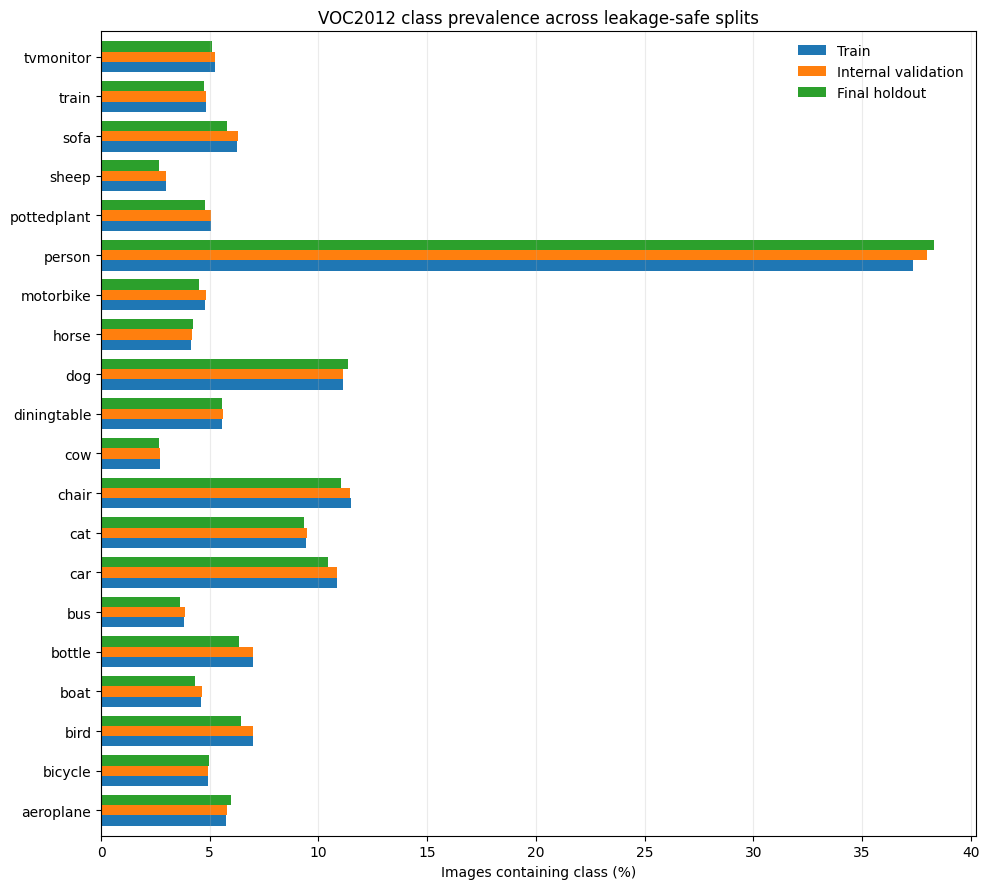


Saved figure: /kaggle/working/anndl_outputs/step02_class_prevalence.png
SPLIT VALIDATION PASSED: classification arrays are ready.


In [ ]:
#Step 02: build and audit leakage-safe VOC2012 classification splits.

from pathlib import Path
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# The 20 PASCAL VOC object categories
VOC_CLASSES = (
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor",
)
CLASS_TO_INDEX = {class_name: index for index, class_name in enumerate(VOC_CLASSES)}
N_CLASSES = len(VOC_CLASSES)


def read_voc_ids(file_path):
    """Read image identifiers from a VOC split file."""
    return [
        line.split()[0]
        for line in Path(file_path).read_text().splitlines()
        if line.strip()
    ]


def labels_from_xml(image_ids, voc_root):
    """Create one multi-hot row per image from the corresponding VOC XML file."""
    label_matrix = np.zeros((len(image_ids), N_CLASSES), dtype=np.float32)
    empty_label_ids = []
    unknown_labels = set()
    missing_xml_ids = []
    missing_image_ids = []

    for row_index, image_id in enumerate(image_ids):
        xml_path = voc_root / "Annotations" / f"{image_id}.xml"
        image_path = voc_root / "JPEGImages" / f"{image_id}.jpg"

        if not xml_path.is_file():
            missing_xml_ids.append(image_id)
            continue
        if not image_path.is_file():
            missing_image_ids.append(image_id)

        root = ET.parse(xml_path).getroot()
        image_classes = {
            obj.findtext("name", default="").strip()
            for obj in root.findall("object")
        }

        for class_name in image_classes:
            if class_name in CLASS_TO_INDEX:
                label_matrix[row_index, CLASS_TO_INDEX[class_name]] = 1.0
            elif class_name:
                unknown_labels.add(class_name)

        if label_matrix[row_index].sum() == 0:
            empty_label_ids.append(image_id)

    audit = {
        "missing_xml_ids": missing_xml_ids,
        "missing_image_ids": missing_image_ids,
        "empty_label_ids": empty_label_ids,
        "unknown_labels": sorted(unknown_labels),
    }
    return label_matrix, audit


def iterative_multilabel_train_val_split(labels, val_fraction=0.20, seed=42):
    """Deterministically balance multiple labels across train and validation.

    This is a dependency-free, two-way implementation of iterative
    stratification. Rare labels are allocated first, while remaining split
    capacity is enforced so that the requested split sizes are exact.
    """
    labels = np.asarray(labels, dtype=np.int8)
    if labels.ndim != 2:
        raise ValueError("labels must be a two-dimensional multi-hot matrix.")
    if not 0.0 < val_fraction < 1.0:
        raise ValueError("val_fraction must be strictly between 0 and 1.")

    n_samples = labels.shape[0]
    target_val_size = int(round(n_samples * val_fraction))
    target_sizes = np.array(
        [n_samples - target_val_size, target_val_size], dtype=np.int64
    )
    remaining_capacity = target_sizes.copy()

    total_label_counts = labels.sum(axis=0).astype(np.float64)
    desired_label_counts = np.vstack(
        [
            total_label_counts * (1.0 - val_fraction),
            total_label_counts * val_fraction,
        ]
    )

    rng = np.random.default_rng(seed)
    assignment = np.full(n_samples, -1, dtype=np.int8)
    unassigned = np.ones(n_samples, dtype=bool)

    while unassigned.any():
        remaining_label_counts = labels[unassigned].sum(axis=0)
        available_labels = np.flatnonzero(remaining_label_counts > 0)
        if available_labels.size == 0:
            break

        # Allocate the currently rarest label first.
        rarest_label = available_labels[
            np.argmin(remaining_label_counts[available_labels])
        ]
        candidate_indices = np.flatnonzero(
            unassigned & (labels[:, rarest_label] == 1)
        )
        rng.shuffle(candidate_indices)

        for sample_index in candidate_indices:
            if not unassigned[sample_index]:
                continue

            available_splits = np.flatnonzero(remaining_capacity > 0)
            label_need = desired_label_counts[available_splits, rarest_label]
            best_splits = available_splits[np.isclose(label_need, label_need.max())]

            if best_splits.size > 1:
                capacity_ratio = (
                    remaining_capacity[best_splits] / target_sizes[best_splits]
                )
                best_splits = best_splits[
                    np.isclose(capacity_ratio, capacity_ratio.max())
                ]

            chosen_split = int(rng.choice(best_splits))
            assignment[sample_index] = chosen_split
            unassigned[sample_index] = False
            remaining_capacity[chosen_split] -= 1
            desired_label_counts[chosen_split] -= labels[sample_index]

    # This branch also handles any all-zero rows
    leftover_indices = np.flatnonzero(unassigned)
    rng.shuffle(leftover_indices)
    for sample_index in leftover_indices:
        available_splits = np.flatnonzero(remaining_capacity > 0)
        capacity_ratio = remaining_capacity[available_splits] / target_sizes[available_splits]
        best_splits = available_splits[
            np.isclose(capacity_ratio, capacity_ratio.max())
        ]
        chosen_split = int(rng.choice(best_splits))
        assignment[sample_index] = chosen_split
        remaining_capacity[chosen_split] -= 1

    if np.any(assignment < 0) or np.any(remaining_capacity != 0):
        raise RuntimeError("Iterative stratification did not allocate every sample.")

    train_indices = np.flatnonzero(assignment == 0)
    val_indices = np.flatnonzero(assignment == 1)
    return train_indices, val_indices


# Split policy:
# - official VOC train -> development pool, split into train/internal validation
# - official VOC val   -> untouched final holdout for one-time final evaluation
main_split_dir = VOC_ROOT / "ImageSets" / "Main"
official_train_ids = read_voc_ids(main_split_dir / "train.txt")
official_holdout_ids = read_voc_ids(main_split_dir / "val.txt")

official_train_labels, train_pool_audit = labels_from_xml(
    official_train_ids, VOC_ROOT
)
official_holdout_labels, holdout_audit = labels_from_xml(
    official_holdout_ids, VOC_ROOT
)

train_indices, internal_val_indices = iterative_multilabel_train_val_split(
    official_train_labels,
    val_fraction=0.20,
    seed=SEED,
)

train_ids = np.asarray(official_train_ids)[train_indices]
val_ids = np.asarray(official_train_ids)[internal_val_indices]
test_ids = np.asarray(official_holdout_ids) 

train_paths = np.asarray(
    [str(VOC_ROOT / "JPEGImages" / f"{image_id}.jpg") for image_id in train_ids]
)
val_paths = np.asarray(
    [str(VOC_ROOT / "JPEGImages" / f"{image_id}.jpg") for image_id in val_ids]
)
test_paths = np.asarray(
    [str(VOC_ROOT / "JPEGImages" / f"{image_id}.jpg") for image_id in test_ids]
)

train_labels = official_train_labels[train_indices].astype(np.float32)
val_labels = official_train_labels[internal_val_indices].astype(np.float32)
test_labels = official_holdout_labels.astype(np.float32)


# Integrity checks
all_audit_issues = {
    "train_pool_missing_xml": len(train_pool_audit["missing_xml_ids"]),
    "train_pool_missing_images": len(train_pool_audit["missing_image_ids"]),
    "train_pool_empty_labels": len(train_pool_audit["empty_label_ids"]),
    "holdout_missing_xml": len(holdout_audit["missing_xml_ids"]),
    "holdout_missing_images": len(holdout_audit["missing_image_ids"]),
    "holdout_empty_labels": len(holdout_audit["empty_label_ids"]),
}
unknown_labels = sorted(
    set(train_pool_audit["unknown_labels"]) | set(holdout_audit["unknown_labels"])
)

assert len(official_train_ids) == len(set(official_train_ids)), (
    "Duplicate image IDs exist in the official training split."
)
assert len(official_holdout_ids) == len(set(official_holdout_ids)), (
    "Duplicate image IDs exist in the official holdout split."
)
assert set(train_ids).isdisjoint(set(val_ids)), "Train/validation leakage found."
assert set(train_ids).isdisjoint(set(test_ids)), "Train/holdout leakage found."
assert set(val_ids).isdisjoint(set(test_ids)), "Validation/holdout leakage found."
assert not any(all_audit_issues.values()), f"Dataset audit failed: {all_audit_issues}"
assert not unknown_labels, f"Unknown XML labels found: {unknown_labels}"
assert train_labels.shape == (len(train_paths), N_CLASSES)
assert val_labels.shape == (len(val_paths), N_CLASSES)
assert test_labels.shape == (len(test_paths), N_CLASSES)
assert np.all(train_labels.sum(axis=0) > 0), "A class is absent from training."
assert np.all(val_labels.sum(axis=0) > 0), "A class is absent from validation."
assert np.all(test_labels.sum(axis=0) > 0), "A class is absent from holdout."


# Bounded table.
split_summary = pd.DataFrame(
    {
        "split": ["train", "internal_validation", "final_holdout"],
        "n_images": [len(train_ids), len(val_ids), len(test_ids)],
        "mean_labels_per_image": [
            train_labels.sum(axis=1).mean(),
            val_labels.sum(axis=1).mean(),
            test_labels.sum(axis=1).mean(),
        ],
        "min_labels_per_image": [
            train_labels.sum(axis=1).min(),
            val_labels.sum(axis=1).min(),
            test_labels.sum(axis=1).min(),
        ],
        "max_labels_per_image": [
            train_labels.sum(axis=1).max(),
            val_labels.sum(axis=1).max(),
            test_labels.sum(axis=1).max(),
        ],
    }
)

class_distribution = pd.DataFrame(
    {
        "class": VOC_CLASSES,
        "train_n": train_labels.sum(axis=0).astype(int),
        "val_n": val_labels.sum(axis=0).astype(int),
        "holdout_n": test_labels.sum(axis=0).astype(int),
        "train_%": 100.0 * train_labels.mean(axis=0),
        "val_%": 100.0 * val_labels.mean(axis=0),
        "holdout_%": 100.0 * test_labels.mean(axis=0),
    }
)

max_internal_gap_pp = float(
    np.max(np.abs(train_labels.mean(axis=0) - val_labels.mean(axis=0))) * 100.0
)
official_train_prevalence = official_train_labels.mean(axis=0)
max_holdout_shift_pp = float(
    np.max(np.abs(official_train_prevalence - test_labels.mean(axis=0))) * 100.0
)

print("=== Classification data audit ===")
print(f"Classes: {N_CLASSES}")
print(f"Official train pool: {len(official_train_ids):,}")
print(f"Official val reserved as final holdout: {len(official_holdout_ids):,}")
print(f"Unknown XML labels: {unknown_labels}")
print(f"Audit issue counts: {all_audit_issues}")

print("\n=== Leakage-safe development split ===")
print(split_summary.to_string(index=False, float_format=lambda value: f"{value:.3f}"))
print(f"Maximum train-vs-internal-val prevalence gap: {max_internal_gap_pp:.3f} percentage points")
print(f"Maximum official-train-vs-holdout prevalence shift: {max_holdout_shift_pp:.3f} percentage points")

print("\n=== Per-class distribution ===")
print(
    class_distribution.to_string(
        index=False,
        formatters={
            "train_%": lambda value: f"{value:.2f}",
            "val_%": lambda value: f"{value:.2f}",
            "holdout_%": lambda value: f"{value:.2f}",
        },
    )
)


# One compact figure
plot_frame = class_distribution.set_index("class")[["train_%", "val_%", "holdout_%"]]
ax = plot_frame.plot.barh(figsize=(10, 9), width=0.78)
ax.set_title("VOC2012 class prevalence across leakage-safe splits")
ax.set_xlabel("Images containing class (%)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
ax.legend(["Train", "Internal validation", "Final holdout"], frameon=False)
plt.tight_layout()

split_figure_path = OUTPUT_DIR / "step02_class_prevalence.png"
plt.savefig(split_figure_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"\nSaved figure: {split_figure_path}")
print("SPLIT VALIDATION PASSED: classification arrays are ready.")


### Classification input pipeline

The development data use a reproducible multi-label-aware split, while the official VOC validation split remains untouched as the final holdout. Images are decoded and resized to 180 × 180 pixels but remain in the raw [0, 255] scale. Model-specific preprocessing will be applied exactly once inside each model.

I0000 00:00:1785671374.129457      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785671374.132559      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


=== Classification tf.data pipeline ===
Image size: (180, 180)
Batch size: 32
Training samples / batches: 4,574 / 143
Internal-validation samples / batches: 1,143 / 36
Final-holdout samples / batches: 5,823 / 182
First-batch image shape: (32, 180, 180, 3)
First-batch label shape: (32, 20)
First-batch pixel range: [0.000, 255.000]
First-batch label values: [0.0, 1.0]
Normalization location: model only (not the dataset pipeline)


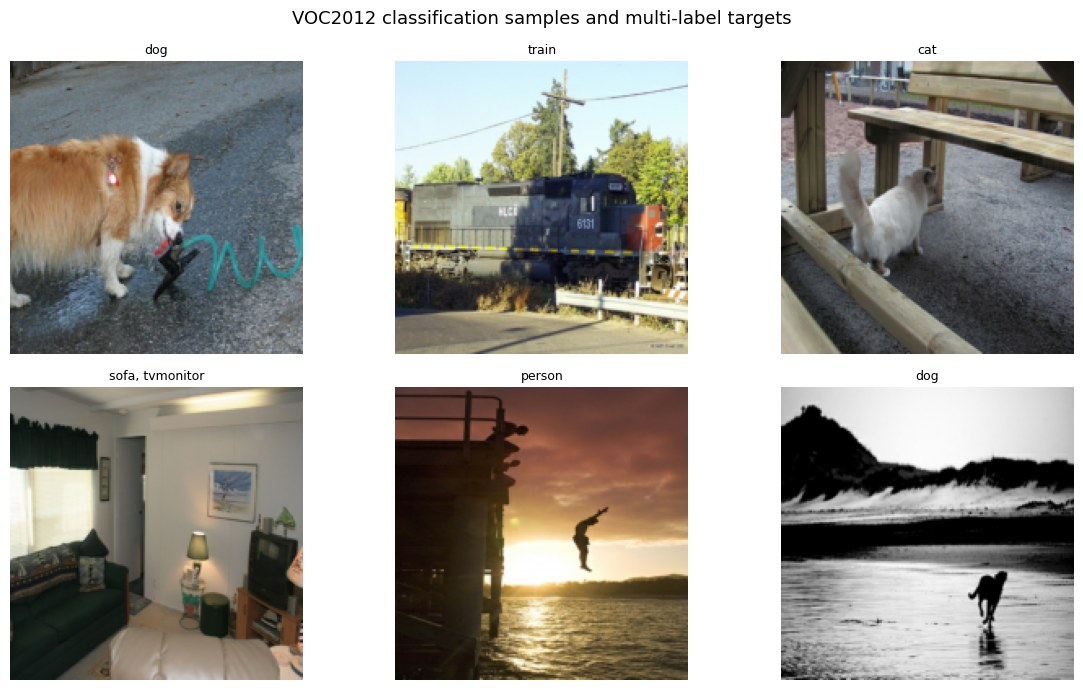

Saved figure: /kaggle/working/anndl_outputs/step03_classification_pipeline_examples.png
PIPELINE VALIDATION PASSED: raw images and multi-label targets are ready.


In [ ]:
#Step 03: build and validate the VOC2012 classification tf.data pipeline.

import math
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


# Keep the shared dataset in raw pixel scale. Each model will own exactly one
# model-specific preprocessing layer (Rescaling for scratch CNNs and
# xception.preprocess_input for pretrained Xception models).
CLASSIFICATION_IMAGE_SIZE = (180, 180)
CLASSIFICATION_BATCH_SIZE = 32


def load_classification_image(image_path, label):
    """Decode and resize one image without normalising its pixel values."""
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(
        image,
        CLASSIFICATION_IMAGE_SIZE,
        method="bilinear",
        antialias=True,
    )
    image = tf.cast(image, tf.float32)
    # Anti-aliased interpolation can introduce tiny floating-point excursions
    # just below 0 or just above 255. Clip those numerical artefacts while
    # deliberately keeping the dataset in the raw [0, 255] pixel scale.
    image = tf.clip_by_value(image, 0.0, 255.0)
    label = tf.cast(label, tf.float32)
    return image, label


def build_classification_dataset(image_paths, labels, training=False):
    """Create a deterministic, reusable classification input pipeline."""
    image_paths = np.asarray(image_paths)
    labels = np.asarray(labels, dtype=np.float32)

    if len(image_paths) != len(labels):
        raise ValueError("The number of image paths and label rows must match.")
    if labels.ndim != 2 or labels.shape[1] != N_CLASSES:
        raise ValueError(f"Labels must have shape (n_images, {N_CLASSES}).")

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(
        load_classification_image,
        num_parallel_calls=AUTOTUNE,
        deterministic=True,
    )

    # Cache decoded/resized images before shuffling. This avoids repeating JPEG
    # decoding across the many model iterations while reshuffling every epoch.
    dataset = dataset.cache()
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(image_paths),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.batch(
        CLASSIFICATION_BATCH_SIZE,
        drop_remainder=False,
    )
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset


train_ds = build_classification_dataset(train_paths, train_labels, training=True)
val_ds = build_classification_dataset(val_paths, val_labels, training=False)
test_ds = build_classification_dataset(test_paths, test_labels, training=False)


# Fail early if the model would receive incorrectly scaled or malformed data.
train_batch_images, train_batch_labels = next(iter(train_ds))
batch_min = float(tf.reduce_min(train_batch_images).numpy())
batch_max = float(tf.reduce_max(train_batch_images).numpy())
unique_batch_labels = np.unique(train_batch_labels.numpy())

expected_batches = {
    "train": math.ceil(len(train_paths) / CLASSIFICATION_BATCH_SIZE),
    "internal_validation": math.ceil(len(val_paths) / CLASSIFICATION_BATCH_SIZE),
    "final_holdout": math.ceil(len(test_paths) / CLASSIFICATION_BATCH_SIZE),
}
observed_batches = {
    "train": int(tf.data.experimental.cardinality(train_ds).numpy()),
    "internal_validation": int(tf.data.experimental.cardinality(val_ds).numpy()),
    "final_holdout": int(tf.data.experimental.cardinality(test_ds).numpy()),
}

assert train_batch_images.shape[1:] == (*CLASSIFICATION_IMAGE_SIZE, 3)
assert train_batch_labels.shape[1] == N_CLASSES
assert train_batch_images.dtype == tf.float32
assert train_batch_labels.dtype == tf.float32
assert np.isfinite(train_batch_images.numpy()).all()
assert 0.0 <= batch_min <= batch_max <= 255.0
assert batch_max > 1.0, (
    "Images appear to have been normalised in the dataset. "
    "They must remain in the raw [0, 255] scale."
)
assert set(unique_batch_labels.tolist()).issubset({0.0, 1.0})
assert observed_batches == expected_batches

print("=== Classification tf.data pipeline ===")
print(f"Image size: {CLASSIFICATION_IMAGE_SIZE}")
print(f"Batch size: {CLASSIFICATION_BATCH_SIZE}")
print(f"Training samples / batches: {len(train_paths):,} / {observed_batches['train']}")
print(
    "Internal-validation samples / batches: "
    f"{len(val_paths):,} / {observed_batches['internal_validation']}"
)
print(
    "Final-holdout samples / batches: "
    f"{len(test_paths):,} / {observed_batches['final_holdout']}"
)
print(f"First-batch image shape: {tuple(train_batch_images.shape)}")
print(f"First-batch label shape: {tuple(train_batch_labels.shape)}")
print(f"First-batch pixel range: [{batch_min:.3f}, {batch_max:.3f}]")
print(f"First-batch label values: {unique_batch_labels.tolist()}")
print("Normalization location: model only (not the dataset pipeline)")


# Bounded visual sanity check: confirm that labels and decoded images align.
n_examples = min(6, int(train_batch_images.shape[0]))
figure, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = np.asarray(axes).reshape(-1)

for example_index, axis in enumerate(axes):
    if example_index >= n_examples:
        axis.axis("off")
        continue

    image = tf.clip_by_value(
        train_batch_images[example_index], 0.0, 255.0
    ).numpy().astype(np.uint8)
    positive_indices = np.flatnonzero(train_batch_labels[example_index].numpy() > 0.5)
    positive_names = [VOC_CLASSES[index] for index in positive_indices]

    axis.imshow(image)
    axis.set_title(
        textwrap.fill(", ".join(positive_names), width=28),
        fontsize=9,
    )
    axis.axis("off")

figure.suptitle("VOC2012 classification samples and multi-label targets", fontsize=13)
figure.tight_layout()
pipeline_figure_path = OUTPUT_DIR / "step03_classification_pipeline_examples.png"
figure.savefig(pipeline_figure_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved figure: {pipeline_figure_path}")
print("PIPELINE VALIDATION PASSED: raw images and multi-label targets are ready.")


## Model

### 1.1 Scratch CNN experiments

Three convolutional architectures are developed from scratch. The sequence deliberately starts with a high-capacity baseline, then introduces regularisation and efficient convolutions, and finally tests residual separable blocks. The comparison is used to diagnose overfitting and justify the selected scratch model.


## Part 1.1 — Iteration 1: High-capacity baseline CNN

The first scratch CNN intentionally uses high model capacity without data augmentation, dropout, or weight regularisation. This establishes an overfitting baseline against which the following improved iterations can be compared. Model development uses only the training and internal-validation sets; the official VOC validation split remains untouched as the final holdout.

=== Iteration 1: deliberately overfitting baseline CNN ===
Model: voc2012_overfit_baseline_cnn
Input shape: (None, 180, 180, 3)
Output shape: (None, 20)
Trainable parameters: 16,258,900
Model-side rescaled probe range: [0.0000, 1.0000]
Regularisation: none
Data augmentation: none
Final holdout status: untouched (not used for training or tuning)
Saved model summary: /kaggle/working/anndl_outputs/step04_baseline_model_summary.txt
Epoch 1/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - binary_accuracy: 0.8983 - loss: 0.3876 - pr_auc: 0.0907 - roc_auc: 0.5330
Epoch 1: val_loss improved from None to 0.23224, saving model to /kaggle/working/anndl_outputs/step04_baseline_best.keras

Epoch 1: finished saving model to /kaggle/working/anndl_outputs/step04_baseline_best.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - binary_accuracy: 0.9178 - loss: 0.2777 - pr_auc: 0.1081 - roc_auc: 0.5985 - val_binary_accuracy: 0.9229 - val_loss: 0.2322 - val_pr_auc: 0.1836 - val_roc_auc: 0.7274
Epoch 2/25
143

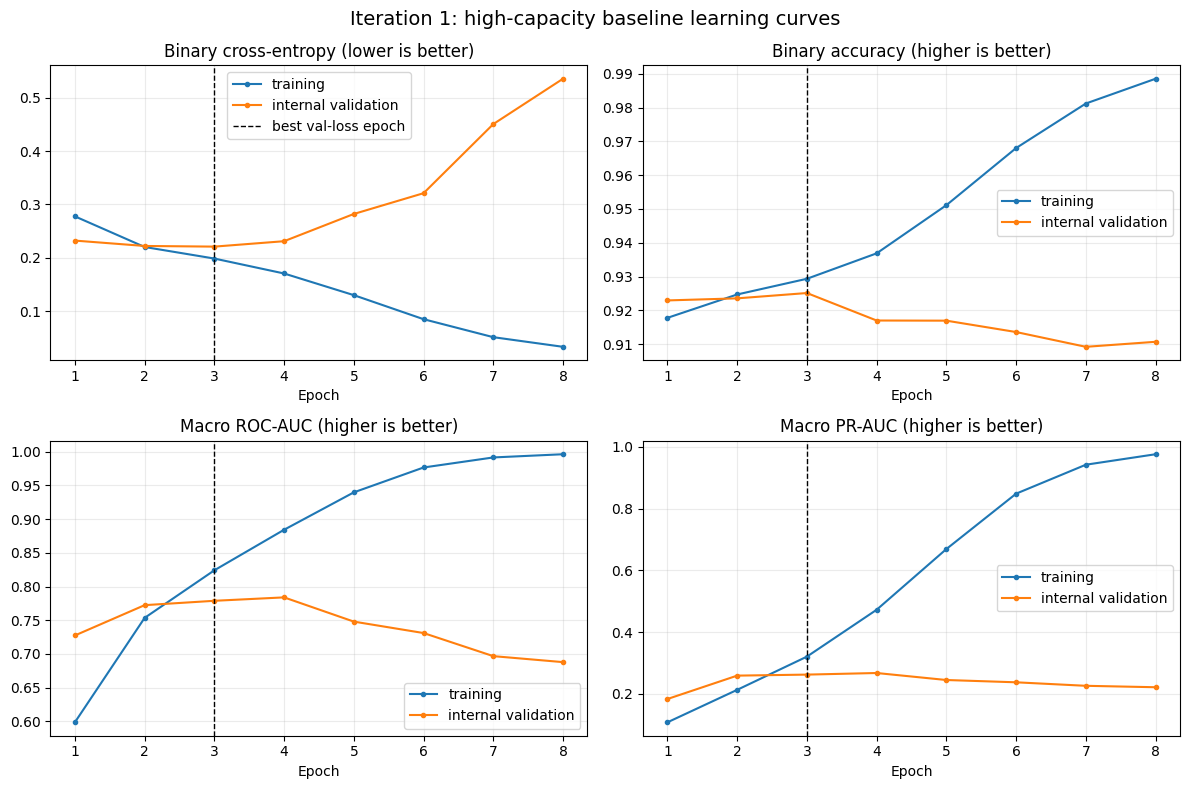

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - binary_accuracy: 0.9251 - loss: 0.2209 - pr_auc: 0.2626 - roc_auc: 0.7788

=== Baseline training diagnosis ===
Epochs run: 8
Best internal-validation loss epoch: 3
Best internal-validation loss: 0.22095
Last-epoch internal-validation loss: 0.53556
Validation-loss rebound after best epoch: +0.31461
Training-loss change after best epoch: -0.16542
Overfitting pattern observed: True

=== Best-checkpoint internal-validation metrics ===
binary_accuracy: 0.92511
loss: 0.22095
pr_auc: 0.26261
roc_auc: 0.77880

Saved best checkpoint: /kaggle/working/anndl_outputs/step04_baseline_best.keras
Saved history: /kaggle/working/anndl_outputs/step04_baseline_history.csv
Saved learning curves: /kaggle/working/anndl_outputs/step04_baseline_learning_curves.png
Saved metrics record: /kaggle/working/anndl_outputs/step04_baseline_internal_val_metrics.json
FINAL HOLDOUT REMAINS UNTOUCHED.


In [ ]:
#Step 04: train a deliberately over-parameterised scratch CNN baseline.

import gc
import json
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf


# ---------------------------------------------------------------------------
# 1. Validate
# ---------------------------------------------------------------------------
required_objects = (
    "SEED",
    "OUTPUT_DIR",
    "N_CLASSES",
    "VOC_CLASSES",
    "CLASSIFICATION_IMAGE_SIZE",
    "train_ds",
    "val_ds",
    "test_ds",
)
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run Steps 01--03 before this cell. Missing objects: "
        + ", ".join(missing_objects)
    )

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

gc.collect()
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

BASELINE_MAX_EPOCHS = 25
BASELINE_EARLY_STOPPING_PATIENCE = 5
baseline_checkpoint_path = OUTPUT_DIR / "step04_baseline_best.keras"
baseline_history_path = OUTPUT_DIR / "step04_baseline_history.csv"
baseline_figure_path = OUTPUT_DIR / "step04_baseline_learning_curves.png"
baseline_summary_path = OUTPUT_DIR / "step04_baseline_model_summary.txt"
baseline_metrics_path = OUTPUT_DIR / "step04_baseline_internal_val_metrics.json"


# ---------------------------------------------------------------------------
# 2. Deliberately high-capacity baseline: no augmentation or regularisation
# ---------------------------------------------------------------------------
def build_overfit_baseline_cnn():
    """Build a scratch multi-label CNN intended to expose overfitting."""
    inputs = keras.Input(
        shape=(*CLASSIFICATION_IMAGE_SIZE, 3),
        name="image",
    )

    # The tf.data pipeline remains in [0, 255]. Normalisation happens once here.
    x = keras.layers.Rescaling(1.0 / 255.0, name="baseline_rescaling")(inputs)

    for block_index, filters in enumerate((32, 64, 128, 256), start=1):
        x = keras.layers.Conv2D(
            filters,
            kernel_size=3,
            padding="same",
            activation="relu",
            kernel_initializer="he_normal",
            name=f"baseline_conv_{block_index}",
        )(x)
        x = keras.layers.MaxPooling2D(
            pool_size=2,
            name=f"baseline_pool_{block_index}",
        )(x)

    # Flatten + a wide dense layer intentionally creates many trainable
    # parameters. Dropout, data augmentation, L2 and batch normalisation are
    # omitted so that the next iteration can demonstrate their effect.
    x = keras.layers.Flatten(name="baseline_flatten")(x)
    x = keras.layers.Dense(
        512,
        activation="relu",
        kernel_initializer="he_normal",
        name="baseline_dense",
    )(x)
    outputs = keras.layers.Dense(
        N_CLASSES,
        activation="sigmoid",
        name="multilabel_probabilities",
    )(x)

    model = keras.Model(inputs, outputs, name="voc2012_overfit_baseline_cnn")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.BinaryAccuracy(
                name="binary_accuracy",
                threshold=0.5,
            ),
            keras.metrics.AUC(
                name="roc_auc",
                curve="ROC",
                multi_label=True,
                num_labels=N_CLASSES,
            ),
            keras.metrics.AUC(
                name="pr_auc",
                curve="PR",
                multi_label=True,
                num_labels=N_CLASSES,
            ),
        ],
    )
    return model


baseline_model = build_overfit_baseline_cnn()

# Confirm that raw [0, 255] inputs become [0, 1] exactly once inside the model.
probe_images, _ = next(iter(val_ds.take(1)))
rescaling_probe = keras.Model(
    baseline_model.input,
    baseline_model.get_layer("baseline_rescaling").output,
)
rescaled_probe = rescaling_probe(probe_images, training=False)
rescaled_min = float(tf.reduce_min(rescaled_probe).numpy())
rescaled_max = float(tf.reduce_max(rescaled_probe).numpy())
assert 0.0 <= rescaled_min <= rescaled_max <= 1.0
assert baseline_model.output_shape == (None, N_CLASSES)

summary_lines = []
baseline_model.summary(print_fn=summary_lines.append)
baseline_summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

print("=== Iteration 1: deliberately overfitting baseline CNN ===")
print(f"Model: {baseline_model.name}")
print(f"Input shape: {baseline_model.input_shape}")
print(f"Output shape: {baseline_model.output_shape}")
print(f"Trainable parameters: {baseline_model.count_params():,}")
print(
    "Model-side rescaled probe range: "
    f"[{rescaled_min:.4f}, {rescaled_max:.4f}]"
)
print("Regularisation: none")
print("Data augmentation: none")
print("Final holdout status: untouched (not used for training or tuning)")
print(f"Saved model summary: {baseline_summary_path}")


# ---------------------------------------------------------------------------
# 3. Train on the development set and monitor the internal validation set
# ---------------------------------------------------------------------------
baseline_callbacks = [
    keras.callbacks.TerminateOnNaN(),
    keras.callbacks.ModelCheckpoint(
        filepath=baseline_checkpoint_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        min_delta=1e-4,
        patience=BASELINE_EARLY_STOPPING_PATIENCE,
        restore_best_weights=False,
        verbose=1,
    ),
]

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_MAX_EPOCHS,
    callbacks=baseline_callbacks,
    verbose=1,
)


# ---------------------------------------------------------------------------
# 4. Record learning curves and an objective overfitting diagnostic
# ---------------------------------------------------------------------------
baseline_history_df = pd.DataFrame(baseline_history.history)
baseline_history_df.index = np.arange(1, len(baseline_history_df) + 1)
baseline_history_df.index.name = "epoch"
baseline_history_df.to_csv(baseline_history_path)

required_history_columns = {
    "loss",
    "val_loss",
    "binary_accuracy",
    "val_binary_accuracy",
    "roc_auc",
    "val_roc_auc",
    "pr_auc",
    "val_pr_auc",
}
missing_history_columns = required_history_columns - set(baseline_history_df.columns)
if missing_history_columns:
    raise RuntimeError(
        "Unexpected Keras history keys: " + ", ".join(sorted(missing_history_columns))
    )

best_epoch = int(baseline_history_df["val_loss"].idxmin())
last_epoch = int(baseline_history_df.index[-1])
best_val_loss = float(baseline_history_df.loc[best_epoch, "val_loss"])
last_val_loss = float(baseline_history_df.loc[last_epoch, "val_loss"])
best_epoch_train_loss = float(baseline_history_df.loc[best_epoch, "loss"])
last_train_loss = float(baseline_history_df.loc[last_epoch, "loss"])
validation_loss_rebound = last_val_loss - best_val_loss
train_loss_change_after_best = last_train_loss - best_epoch_train_loss

overfitting_pattern_observed = bool(
    best_epoch < last_epoch
    and validation_loss_rebound > 1e-4
    and train_loss_change_after_best < 0.0
)

metric_panels = (
    ("loss", "Binary cross-entropy", "lower is better"),
    ("binary_accuracy", "Binary accuracy", "higher is better"),
    ("roc_auc", "Macro ROC-AUC", "higher is better"),
    ("pr_auc", "Macro PR-AUC", "higher is better"),
)

figure, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, (metric_name, title, direction) in zip(axes.ravel(), metric_panels):
    axis.plot(
        baseline_history_df.index,
        baseline_history_df[metric_name],
        marker="o",
        markersize=3,
        label="training",
    )
    axis.plot(
        baseline_history_df.index,
        baseline_history_df[f"val_{metric_name}"],
        marker="o",
        markersize=3,
        label="internal validation",
    )
    axis.axvline(
        best_epoch,
        color="black",
        linestyle="--",
        linewidth=1,
        label="best val-loss epoch" if metric_name == "loss" else None,
    )
    axis.set_title(f"{title} ({direction})")
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.25)
    axis.legend()

figure.suptitle(
    "Iteration 1: high-capacity baseline learning curves",
    fontsize=14,
)
figure.tight_layout()
figure.savefig(baseline_figure_path, dpi=180, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------------
# 5. Reload the best checkpoint and evaluate internal validation only
# ---------------------------------------------------------------------------
baseline_model = keras.models.load_model(baseline_checkpoint_path)
baseline_internal_val_metrics = baseline_model.evaluate(
    val_ds,
    verbose=1,
    return_dict=True,
)
baseline_internal_val_metrics = {
    key: float(value) for key, value in baseline_internal_val_metrics.items()
}

baseline_record = {
    "model": baseline_model.name,
    "selection_metric": "val_loss",
    "best_epoch": best_epoch,
    "epochs_run": last_epoch,
    "best_val_loss_from_history": best_val_loss,
    "last_val_loss": last_val_loss,
    "validation_loss_rebound": validation_loss_rebound,
    "train_loss_change_after_best_epoch": train_loss_change_after_best,
    "overfitting_pattern_observed": overfitting_pattern_observed,
    "internal_validation_metrics_at_best_checkpoint": baseline_internal_val_metrics,
    "final_holdout_evaluated": False,
}
baseline_metrics_path.write_text(
    json.dumps(baseline_record, indent=2),
    encoding="utf-8",
)

print("\n=== Baseline training diagnosis ===")
print(f"Epochs run: {last_epoch}")
print(f"Best internal-validation loss epoch: {best_epoch}")
print(f"Best internal-validation loss: {best_val_loss:.5f}")
print(f"Last-epoch internal-validation loss: {last_val_loss:.5f}")
print(f"Validation-loss rebound after best epoch: {validation_loss_rebound:+.5f}")
print(f"Training-loss change after best epoch: {train_loss_change_after_best:+.5f}")
print(f"Overfitting pattern observed: {overfitting_pattern_observed}")

print("\n=== Best-checkpoint internal-validation metrics ===")
for metric_name, metric_value in baseline_internal_val_metrics.items():
    print(f"{metric_name}: {metric_value:.5f}")

print(f"\nSaved best checkpoint: {baseline_checkpoint_path}")
print(f"Saved history: {baseline_history_path}")
print(f"Saved learning curves: {baseline_figure_path}")
print(f"Saved metrics record: {baseline_metrics_path}")
print("FINAL HOLDOUT REMAINS UNTOUCHED.")


## Part 1.1 — Iteration 2: Regularised efficient CNN

The second iteration addresses the severe overfitting observed in the high-capacity baseline. The Flatten-based classification head is replaced with global average pooling, while mild data augmentation, L2 regularisation, batch normalisation, spatial and dense dropout, and depthwise-separable convolutions are introduced. Model development continues to use only the training and internal-validation sets; the final holdout remains untouched.

=== Iteration 2: regularized scratch CNN ===
Model: voc2012_regularized_cnn
Input shape: (None, 180, 180, 3)
Output shape: (None, 20)
Trainable and non-trainable parameters: 681,108
Baseline parameters: 16,258,900
Parameter reduction vs baseline: 95.8%
Model-side rescaled probe range: [0.0000, 1.0000]
Augmentation: flip, rotation, zoom, translation, contrast
Regularisation: L2, batch normalization, spatial dropout, dense dropout, global average pooling
Efficient convolution: depthwise separable
Final holdout status: untouched (not used for training or tuning)
Saved model summary: /kaggle/working/anndl_outputs/step05_regularized_model_summary.txt
Epoch 1/35


E0000 00:00:1785671884.228284      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/voc2012_regularized_cnn_1/regularized_block1_spatial_dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - bce: 0.4337 - binary_accuracy: 0.8134 - loss: 0.8628 - pr_auc: 0.0859 - roc_auc: 0.5319
Epoch 1: val_bce improved from None to 0.26168, saving model to /kaggle/working/anndl_outputs/step05_regularized_best.keras

Epoch 1: finished saving model to /kaggle/working/anndl_outputs/step05_regularized_best.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 166ms/step - bce: 0.3226 - binary_accuracy: 0.8856 - loss: 0.7315 - pr_auc: 0.0918 - roc_auc: 0.5653 - val_bce: 0.2617 - val_binary_accuracy: 0.9221 - val_loss: 0.6262 - val_pr_auc: 0.0779 - val_roc_auc: 0.5000 - learning_rate: 0.0010
Epoch 2/35
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - bce: 0.2551 - binary_accuracy: 0.9206 - loss: 0.5975 - pr_auc: 0.1306 - roc_auc: 0.6396
Epoch 2: val_bce did not improve from 0.26168
143/143 ━━━━━━━━━━━━━━━━━━━━ 23s 158ms/step - bce: 0.2539 - binary_accuracy: 0.9201 - loss: 0.5749 - pr_auc: 0.1240 - roc_auc: 0.6429 - val_bce: 0.2758 - val_binary_accuracy: 0.9221 - val_lo

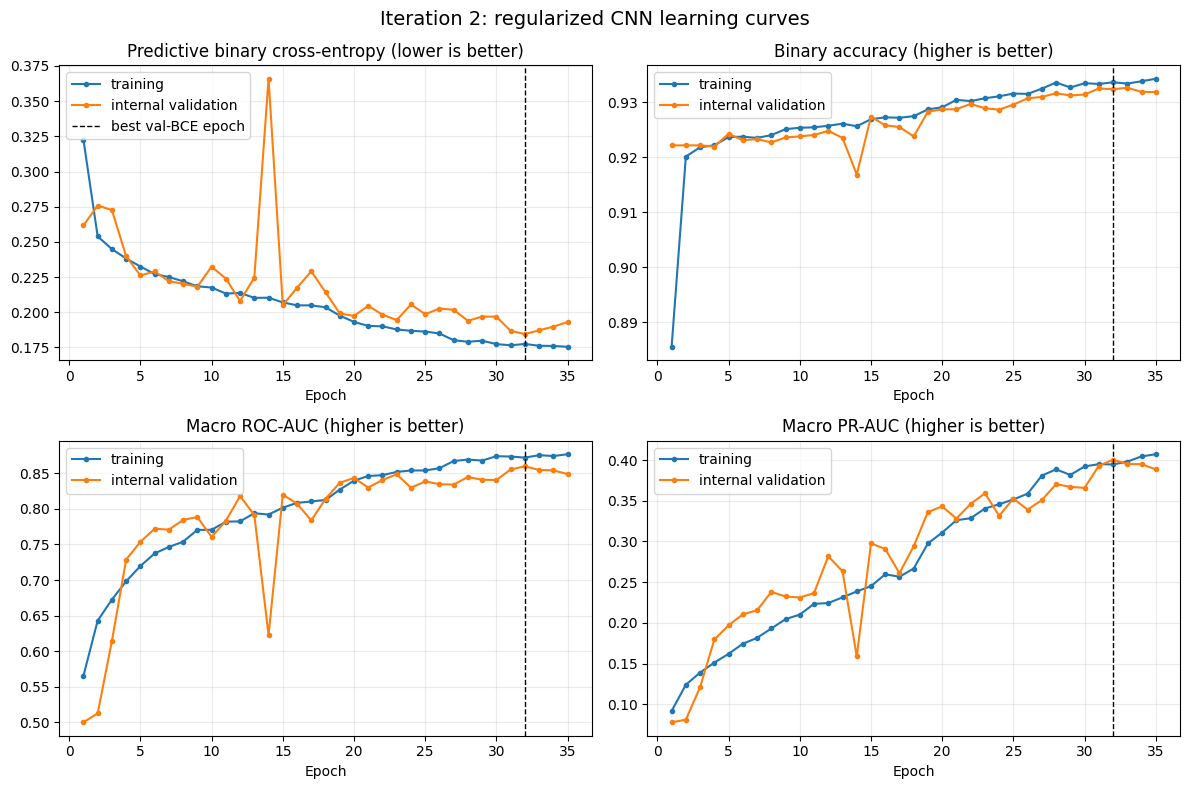

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - bce: 0.1845 - binary_accuracy: 0.9323 - loss: 0.2048 - pr_auc: 0.4004 - roc_auc: 0.8599

=== Regularized-CNN training diagnosis ===
Epochs run: 35
Best internal-validation BCE epoch: 32
Best internal-validation BCE: 0.18454
Last-epoch internal-validation BCE: 0.19305
Validation-BCE rebound after best epoch: +0.00851
Training-BCE change after best epoch: -0.00203
Overfitting pattern observed: True

=== Best-checkpoint internal-validation metrics ===
bce: 0.18454
binary_accuracy: 0.93233
loss: 0.20480
pr_auc: 0.40043
roc_auc: 0.85991

=== Iteration 2 minus Iteration 1 (internal validation) ===
predictive_bce: -0.03641 (lower is better)
binary_accuracy: +0.00722 (higher is better)
roc_auc: +0.08111 (higher is better)
pr_auc: +0.13782 (higher is better)

=== Baseline vs regularized comparison ===
    iteration  parameters  best_epoch  predictive_bce  binary_accuracy  roc_auc  pr_auc
   1_baseline    16258900           3         0.22095          0.9

In [ ]:
#Step 05: train a regularised scratch CNN (classification iteration 2).

import gc
import json
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf


# ---------------------------------------------------------------------------
# 1. Validate notebook 
# ---------------------------------------------------------------------------
required_objects = (
    "SEED",
    "OUTPUT_DIR",
    "N_CLASSES",
    "VOC_CLASSES",
    "CLASSIFICATION_IMAGE_SIZE",
    "train_ds",
    "val_ds",
    "test_ds",
)
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run Steps 01--04 before this cell. Missing objects: "
        + ", ".join(missing_objects)
    )

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

baseline_checkpoint_path = OUTPUT_DIR / "step04_baseline_best.keras"
baseline_metrics_path = OUTPUT_DIR / "step04_baseline_internal_val_metrics.json"
if not baseline_checkpoint_path.exists() or not baseline_metrics_path.exists():
    raise FileNotFoundError(
        "The Step 04 baseline checkpoint/metrics record is missing. "
        "Run Step 04 successfully before this cell."
    )

with baseline_metrics_path.open("r", encoding="utf-8") as file:
    baseline_record = json.load(file)

baseline_internal_metrics = baseline_record[
    "internal_validation_metrics_at_best_checkpoint"
]
baseline_required_metric_names = {
    "loss",
    "binary_accuracy",
    "roc_auc",
    "pr_auc",
}
if baseline_required_metric_names - set(baseline_internal_metrics):
    raise RuntimeError("The Step 04 baseline metrics record is incomplete.")

# Release the large in-memory baseline before constructing iteration 2.
if "baseline_model" in globals():
    del baseline_model
gc.collect()
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)


# ---------------------------------------------------------------------------
# 2. Experiment configuration and output paths
# ---------------------------------------------------------------------------
REGULARIZED_MAX_EPOCHS = 35
REGULARIZED_EARLY_STOPPING_PATIENCE = 7
REGULARIZED_L2 = 1e-4

regularized_checkpoint_path = OUTPUT_DIR / "step05_regularized_best.keras"
regularized_history_path = OUTPUT_DIR / "step05_regularized_history.csv"
regularized_figure_path = OUTPUT_DIR / "step05_regularized_learning_curves.png"
regularized_summary_path = OUTPUT_DIR / "step05_regularized_model_summary.txt"
regularized_metrics_path = OUTPUT_DIR / "step05_regularized_internal_val_metrics.json"
regularized_comparison_path = OUTPUT_DIR / "step05_baseline_vs_regularized.csv"


# ---------------------------------------------------------------------------
# 3. Regularised architecture
# ---------------------------------------------------------------------------
def build_regularized_cnn():
    """Build iteration 2 with augmentation and explicit regularisation."""
    l2_regularizer = keras.regularizers.l2(REGULARIZED_L2)

    augmentation = keras.Sequential(
        [
            keras.layers.RandomFlip(
                "horizontal",
                seed=SEED + 1,
            ),
            keras.layers.RandomRotation(
                factor=0.05,
                fill_mode="reflect",
                seed=SEED + 2,
            ),
            keras.layers.RandomZoom(
                height_factor=(-0.10, 0.10),
                width_factor=(-0.10, 0.10),
                fill_mode="reflect",
                seed=SEED + 3,
            ),
            keras.layers.RandomTranslation(
                height_factor=0.05,
                width_factor=0.05,
                fill_mode="reflect",
                seed=SEED + 4,
            ),
            keras.layers.RandomContrast(
                factor=0.10,
                seed=SEED + 5,
            ),
        ],
        name="regularized_augmentation",
    )

    inputs = keras.Input(
        shape=(*CLASSIFICATION_IMAGE_SIZE, 3),
        name="image",
    )
    x = augmentation(inputs)

    # The shared tf.data pipeline remains in [0, 255]. Scale exactly once.
    x = keras.layers.Rescaling(
        1.0 / 255.0,
        name="regularized_rescaling",
    )(x)

    # A small conventional stem learns low-level edges and colour patterns.
    x = keras.layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        kernel_regularizer=l2_regularizer,
        name="regularized_stem_conv",
    )(x)
    x = keras.layers.BatchNormalization(name="regularized_stem_bn")(x)
    x = keras.layers.Activation("relu", name="regularized_stem_relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=2, name="regularized_stem_pool")(x)

    # Depthwise-separable blocks retain useful capacity with far fewer weights
    # than standard convolutions. Spatial dropout increases gradually with depth.
    for block_index, (filters, dropout_rate) in enumerate(
        ((64, 0.05), (128, 0.10), (256, 0.15), (512, 0.20)),
        start=1,
    ):
        for convolution_index in (1, 2):
            x = keras.layers.SeparableConv2D(
                filters,
                kernel_size=3,
                padding="same",
                use_bias=False,
                depthwise_initializer="he_normal",
                pointwise_initializer="he_normal",
                depthwise_regularizer=l2_regularizer,
                pointwise_regularizer=l2_regularizer,
                name=(
                    f"regularized_block{block_index}_"
                    f"sepconv{convolution_index}"
                ),
            )(x)
            x = keras.layers.BatchNormalization(
                name=f"regularized_block{block_index}_bn{convolution_index}"
            )(x)
            x = keras.layers.Activation(
                "relu",
                name=f"regularized_block{block_index}_relu{convolution_index}",
            )(x)

        x = keras.layers.MaxPooling2D(
            pool_size=2,
            name=f"regularized_block{block_index}_pool",
        )(x)
        x = keras.layers.SpatialDropout2D(
            dropout_rate,
            name=f"regularized_block{block_index}_spatial_dropout",
        )(x)

    # Global pooling replaces the baseline's 16M-parameter Flatten/Dense head.
    x = keras.layers.GlobalAveragePooling2D(
        name="regularized_global_average_pooling"
    )(x)
    x = keras.layers.Dense(
        256,
        use_bias=False,
        kernel_initializer="he_normal",
        kernel_regularizer=l2_regularizer,
        name="regularized_dense",
    )(x)
    x = keras.layers.BatchNormalization(name="regularized_dense_bn")(x)
    x = keras.layers.Activation("relu", name="regularized_dense_relu")(x)
    x = keras.layers.Dropout(
        0.45,
        seed=SEED + 6,
        name="regularized_dense_dropout",
    )(x)

    outputs = keras.layers.Dense(
        N_CLASSES,
        activation="sigmoid",
        kernel_regularizer=l2_regularizer,
        name="multilabel_probabilities",
    )(x)

    model = keras.Model(inputs, outputs, name="voc2012_regularized_cnn")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            # This unpenalised predictive BCE is comparable with the baseline's
            # loss. Keras `loss` below also contains the L2 penalty.
            keras.metrics.BinaryCrossentropy(name="bce"),
            keras.metrics.BinaryAccuracy(
                name="binary_accuracy",
                threshold=0.5,
            ),
            keras.metrics.AUC(
                name="roc_auc",
                curve="ROC",
                multi_label=True,
                num_labels=N_CLASSES,
            ),
            keras.metrics.AUC(
                name="pr_auc",
                curve="PR",
                multi_label=True,
                num_labels=N_CLASSES,
            ),
        ],
    )
    return model


regularized_model = build_regularized_cnn()
assert regularized_model.output_shape == (None, N_CLASSES)

# Verify that inference-time preprocessing scales raw images exactly once.
probe_images, _ = next(iter(val_ds.take(1)))
rescaling_probe = keras.Model(
    regularized_model.input,
    regularized_model.get_layer("regularized_rescaling").output,
)
rescaled_probe = rescaling_probe(probe_images, training=False)
rescaled_min = float(tf.reduce_min(rescaled_probe).numpy())
rescaled_max = float(tf.reduce_max(rescaled_probe).numpy())
assert 0.0 <= rescaled_min <= rescaled_max <= 1.0

summary_lines = []
regularized_model.summary(print_fn=summary_lines.append)
regularized_summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

baseline_model_for_count = keras.models.load_model(baseline_checkpoint_path)
baseline_parameter_count = int(baseline_model_for_count.count_params())
del baseline_model_for_count
gc.collect()

regularized_parameter_count = int(regularized_model.count_params())
parameter_reduction_fraction = 1.0 - (
    regularized_parameter_count / baseline_parameter_count
)

print("=== Iteration 2: regularized scratch CNN ===")
print(f"Model: {regularized_model.name}")
print(f"Input shape: {regularized_model.input_shape}")
print(f"Output shape: {regularized_model.output_shape}")
print(f"Trainable and non-trainable parameters: {regularized_parameter_count:,}")
print(f"Baseline parameters: {baseline_parameter_count:,}")
print(f"Parameter reduction vs baseline: {parameter_reduction_fraction:.1%}")
print(
    "Model-side rescaled probe range: "
    f"[{rescaled_min:.4f}, {rescaled_max:.4f}]"
)
print("Augmentation: flip, rotation, zoom, translation, contrast")
print(
    "Regularisation: L2, batch normalization, spatial dropout, "
    "dense dropout, global average pooling"
)
print("Efficient convolution: depthwise separable")
print("Final holdout status: untouched (not used for training or tuning)")
print(f"Saved model summary: {regularized_summary_path}")


# ---------------------------------------------------------------------------
# 4. Train with adaptive learning rate and validation-based checkpointing
# ---------------------------------------------------------------------------
regularized_callbacks = [
    keras.callbacks.TerminateOnNaN(),
    keras.callbacks.ModelCheckpoint(
        filepath=regularized_checkpoint_path,
        monitor="val_bce",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_bce",
        mode="min",
        factor=0.3,
        patience=3,
        min_delta=1e-4,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_bce",
        mode="min",
        min_delta=1e-4,
        patience=REGULARIZED_EARLY_STOPPING_PATIENCE,
        restore_best_weights=False,
        verbose=1,
    ),
]

regularized_history = regularized_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=REGULARIZED_MAX_EPOCHS,
    callbacks=regularized_callbacks,
    verbose=1,
)


# ---------------------------------------------------------------------------
# 5. Save learning curves and diagnose generalisation
# ---------------------------------------------------------------------------
regularized_history_df = pd.DataFrame(regularized_history.history)
regularized_history_df.index = np.arange(1, len(regularized_history_df) + 1)
regularized_history_df.index.name = "epoch"
regularized_history_df.to_csv(regularized_history_path)

required_history_columns = {
    "loss",
    "val_loss",
    "bce",
    "val_bce",
    "binary_accuracy",
    "val_binary_accuracy",
    "roc_auc",
    "val_roc_auc",
    "pr_auc",
    "val_pr_auc",
}
missing_history_columns = required_history_columns - set(regularized_history_df)
if missing_history_columns:
    raise RuntimeError(
        "Unexpected Keras history keys: "
        + ", ".join(sorted(missing_history_columns))
    )

best_epoch = int(regularized_history_df["val_bce"].idxmin())
last_epoch = int(regularized_history_df.index[-1])
best_val_bce = float(regularized_history_df.loc[best_epoch, "val_bce"])
last_val_bce = float(regularized_history_df.loc[last_epoch, "val_bce"])
best_epoch_train_bce = float(regularized_history_df.loc[best_epoch, "bce"])
last_train_bce = float(regularized_history_df.loc[last_epoch, "bce"])
validation_bce_rebound = last_val_bce - best_val_bce
train_bce_change_after_best = last_train_bce - best_epoch_train_bce

overfitting_pattern_observed = bool(
    best_epoch < last_epoch
    and validation_bce_rebound > 1e-4
    and train_bce_change_after_best < 0.0
)

metric_panels = (
    ("bce", "Predictive binary cross-entropy", "lower is better"),
    ("binary_accuracy", "Binary accuracy", "higher is better"),
    ("roc_auc", "Macro ROC-AUC", "higher is better"),
    ("pr_auc", "Macro PR-AUC", "higher is better"),
)

figure, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, (metric_name, title, direction) in zip(axes.ravel(), metric_panels):
    axis.plot(
        regularized_history_df.index,
        regularized_history_df[metric_name],
        marker="o",
        markersize=3,
        label="training",
    )
    axis.plot(
        regularized_history_df.index,
        regularized_history_df[f"val_{metric_name}"],
        marker="o",
        markersize=3,
        label="internal validation",
    )
    axis.axvline(
        best_epoch,
        color="black",
        linestyle="--",
        linewidth=1,
        label="best val-BCE epoch" if metric_name == "bce" else None,
    )
    axis.set_title(f"{title} ({direction})")
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.25)
    axis.legend()

figure.suptitle("Iteration 2: regularized CNN learning curves", fontsize=14)
figure.tight_layout()
figure.savefig(regularized_figure_path, dpi=180, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------------
# 6. Evaluate only the best checkpoint on internal validation
# ---------------------------------------------------------------------------
regularized_model = keras.models.load_model(regularized_checkpoint_path)
regularized_internal_metrics = regularized_model.evaluate(
    val_ds,
    verbose=1,
    return_dict=True,
)
regularized_internal_metrics = {
    key: float(value) for key, value in regularized_internal_metrics.items()
}

metric_deltas = {
    "predictive_bce": (
        regularized_internal_metrics["bce"]
        - float(baseline_internal_metrics["loss"])
    ),
    "binary_accuracy": (
        regularized_internal_metrics["binary_accuracy"]
        - float(baseline_internal_metrics["binary_accuracy"])
    ),
    "roc_auc": (
        regularized_internal_metrics["roc_auc"]
        - float(baseline_internal_metrics["roc_auc"])
    ),
    "pr_auc": (
        regularized_internal_metrics["pr_auc"]
        - float(baseline_internal_metrics["pr_auc"])
    ),
}

comparison_df = pd.DataFrame(
    [
        {
            "iteration": "1_baseline",
            "parameters": baseline_parameter_count,
            "best_epoch": int(baseline_record["best_epoch"]),
            "predictive_bce": float(baseline_internal_metrics["loss"]),
            "binary_accuracy": float(
                baseline_internal_metrics["binary_accuracy"]
            ),
            "roc_auc": float(baseline_internal_metrics["roc_auc"]),
            "pr_auc": float(baseline_internal_metrics["pr_auc"]),
        },
        {
            "iteration": "2_regularized",
            "parameters": regularized_parameter_count,
            "best_epoch": best_epoch,
            "predictive_bce": regularized_internal_metrics["bce"],
            "binary_accuracy": regularized_internal_metrics[
                "binary_accuracy"
            ],
            "roc_auc": regularized_internal_metrics["roc_auc"],
            "pr_auc": regularized_internal_metrics["pr_auc"],
        },
    ]
)
comparison_df.to_csv(regularized_comparison_path, index=False)

regularized_record = {
    "model": regularized_model.name,
    "selection_metric": "val_bce",
    "best_epoch": best_epoch,
    "epochs_run": last_epoch,
    "best_val_bce_from_history": best_val_bce,
    "last_val_bce": last_val_bce,
    "validation_bce_rebound": validation_bce_rebound,
    "train_bce_change_after_best_epoch": train_bce_change_after_best,
    "overfitting_pattern_observed": overfitting_pattern_observed,
    "parameter_count": regularized_parameter_count,
    "baseline_parameter_count": baseline_parameter_count,
    "parameter_reduction_fraction": parameter_reduction_fraction,
    "internal_validation_metrics_at_best_checkpoint": (
        regularized_internal_metrics
    ),
    "internal_validation_metric_delta_vs_baseline": metric_deltas,
    "final_holdout_evaluated": False,
}
regularized_metrics_path.write_text(
    json.dumps(regularized_record, indent=2),
    encoding="utf-8",
)

print("\n=== Regularized-CNN training diagnosis ===")
print(f"Epochs run: {last_epoch}")
print(f"Best internal-validation BCE epoch: {best_epoch}")
print(f"Best internal-validation BCE: {best_val_bce:.5f}")
print(f"Last-epoch internal-validation BCE: {last_val_bce:.5f}")
print(f"Validation-BCE rebound after best epoch: {validation_bce_rebound:+.5f}")
print(f"Training-BCE change after best epoch: {train_bce_change_after_best:+.5f}")
print(f"Overfitting pattern observed: {overfitting_pattern_observed}")

print("\n=== Best-checkpoint internal-validation metrics ===")
for metric_name, metric_value in regularized_internal_metrics.items():
    print(f"{metric_name}: {metric_value:.5f}")

print("\n=== Iteration 2 minus Iteration 1 (internal validation) ===")
for metric_name in ("predictive_bce", "binary_accuracy", "roc_auc", "pr_auc"):
    direction = (
        "lower is better" if metric_name == "predictive_bce" else "higher is better"
    )
    print(f"{metric_name}: {metric_deltas[metric_name]:+.5f} ({direction})")

print("\n=== Baseline vs regularized comparison ===")
print(comparison_df.to_string(index=False, float_format=lambda value: f"{value:.5f}"))

print(f"\nSaved best checkpoint: {regularized_checkpoint_path}")
print(f"Saved history: {regularized_history_path}")
print(f"Saved learning curves: {regularized_figure_path}")
print(f"Saved metrics record: {regularized_metrics_path}")
print(f"Saved comparison table: {regularized_comparison_path}")
print("FINAL HOLDOUT REMAINS UNTOUCHED.")


## Part 1.1 — Iteration 3: Residual separable CNN

The third iteration investigates whether residual connections can further improve the regularised scratch classifier. Four depthwise-separable blocks use projection shortcuts to preserve information and support gradient propagation through the deeper architecture. The augmentation, L2 regularisation, batch normalisation, dropout and predictive-BCE evaluation protocol are retained. The final holdout remains untouched.

=== Iteration 3: residual separable CNN ===
Model: voc2012_residual_cnn
Input shape: (None, 180, 180, 3)
Output shape: (None, 20)
Trainable and non-trainable parameters: 643,348
Iteration 2 parameters: 681,108
Baseline parameters: 16,258,900
Model-side rescaled probe range: [0.0000, 1.0000]
Architecture: four residual depthwise-separable blocks
Residual projection: 1x1 strided Conv2D plus elementwise addition
Regularisation: augmentation, L2, batch normalization, dropout
Initial learning rate: 0.0003
Final holdout status: untouched (not used for training or tuning)
Saved model summary: /kaggle/working/anndl_outputs/step06_residual_model_summary.txt
Epoch 1/40


E0000 00:00:1785673361.521866      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/voc2012_residual_cnn_1/residual_block1_spatial_dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - bce: 0.5650 - binary_accuracy: 0.7177 - loss: 1.1202 - pr_auc: 0.0872 - roc_auc: 0.5276
Epoch 1: val_bce improved from None to 0.26196, saving model to /kaggle/working/anndl_outputs/step06_residual_best.keras

Epoch 1: finished saving model to /kaggle/working/anndl_outputs/step06_residual_best.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 39s 201ms/step - bce: 0.4224 - binary_accuracy: 0.8245 - loss: 0.9705 - pr_auc: 0.0887 - roc_auc: 0.5484 - val_bce: 0.2620 - val_binary_accuracy: 0.9221 - val_loss: 0.7943 - val_pr_auc: 0.0880 - val_roc_auc: 0.5124 - learning_rate: 3.0000e-04
Epoch 2/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - bce: 0.2692 - binary_accuracy: 0.9171 - loss: 0.7930 - pr_auc: 0.1155 - roc_auc: 0.6148
Epoch 2: val_bce did not improve from 0.26196
143/143 ━━━━━━━━━━━━━━━━━━━━ 28s 192ms/step - bce: 0.2628 - binary_accuracy: 0.9185 - loss: 0.7778 - pr_auc: 0.1192 - roc_auc: 0.6249 - val_bce: 0.2787 - val_binary_accuracy: 0.9221 - val_loss

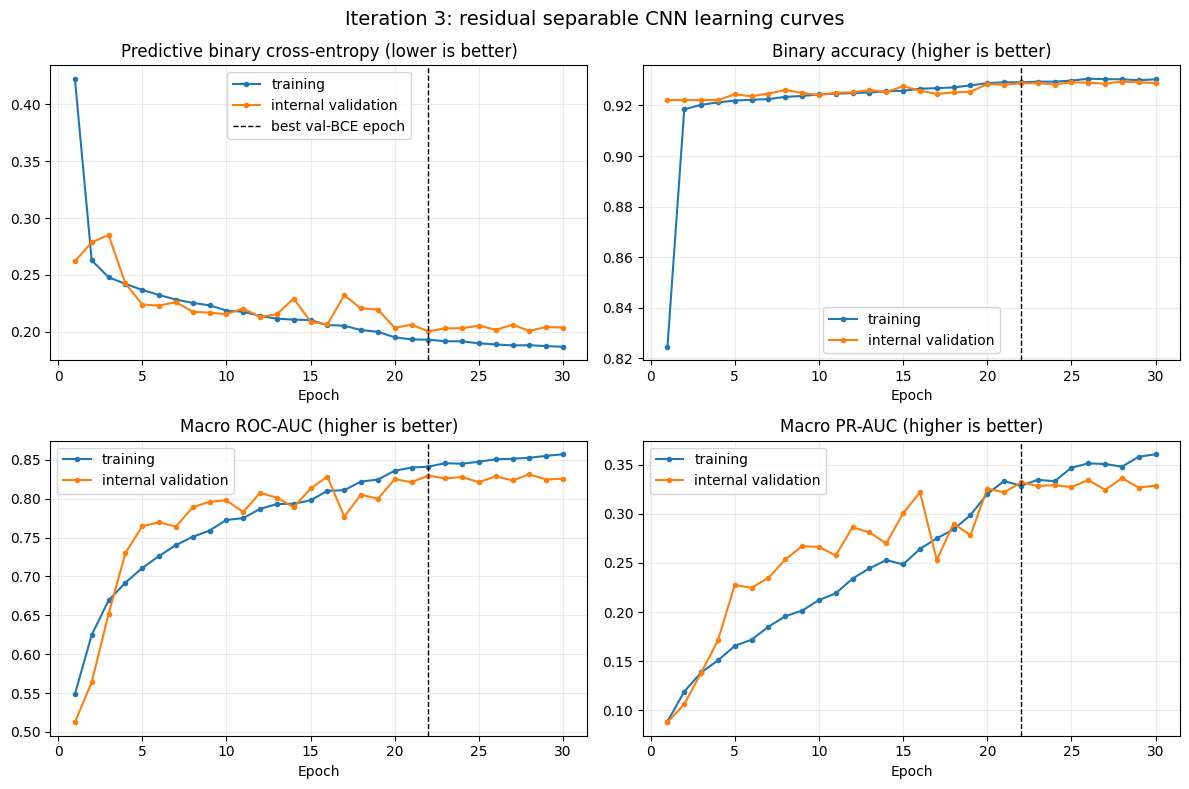

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - bce: 0.2004 - binary_accuracy: 0.9288 - loss: 0.3331 - pr_auc: 0.3319 - roc_auc: 0.8298

=== Residual-CNN training diagnosis ===
Epochs run: 30
Best internal-validation BCE epoch: 22
Best internal-validation BCE: 0.20043
Last-epoch internal-validation BCE: 0.20378
Validation-BCE rebound after best epoch: +0.00336
Training-BCE change after best epoch: -0.00629
Overfitting pattern observed: True

=== Best-checkpoint internal-validation metrics ===
bce: 0.20043
binary_accuracy: 0.92878
loss: 0.33313
pr_auc: 0.33187
roc_auc: 0.82978

=== Iteration 3 minus Iteration 2 (internal validation) ===
predictive_bce: +0.01589 (lower is better)
binary_accuracy: -0.00354 (higher is better)
roc_auc: -0.03013 (higher is better)
pr_auc: -0.06856 (higher is better)

=== All scratch-CNN iterations ===
    iteration  parameters  best_epoch  predictive_bce  binary_accuracy  roc_auc  pr_auc  selected_by_internal_val_bce
   1_baseline    16258900           3         0

In [ ]:
#Step 06: train a residual separable CNN (classification iteration 3)

import gc
import json
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf


# ---------------------------------------------------------------------------
# 1. Validate notebook state and recover Iterations 1 and 2
# ---------------------------------------------------------------------------
required_objects = (
    "SEED",
    "OUTPUT_DIR",
    "N_CLASSES",
    "VOC_CLASSES",
    "CLASSIFICATION_IMAGE_SIZE",
    "train_ds",
    "val_ds",
    "test_ds",
)
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run Steps 01--05 before this cell. Missing objects: "
        + ", ".join(missing_objects)
    )

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

baseline_checkpoint_path = OUTPUT_DIR / "step04_baseline_best.keras"
baseline_metrics_path = OUTPUT_DIR / "step04_baseline_internal_val_metrics.json"
regularized_checkpoint_path = OUTPUT_DIR / "step05_regularized_best.keras"
regularized_metrics_path = OUTPUT_DIR / "step05_regularized_internal_val_metrics.json"

required_files = (
    baseline_checkpoint_path,
    baseline_metrics_path,
    regularized_checkpoint_path,
    regularized_metrics_path,
)
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Run Steps 04 and 05 successfully before Step 06. Missing files: "
        + ", ".join(missing_files)
    )

with baseline_metrics_path.open("r", encoding="utf-8") as file:
    baseline_record = json.load(file)
with regularized_metrics_path.open("r", encoding="utf-8") as file:
    regularized_record = json.load(file)

baseline_internal_metrics = baseline_record[
    "internal_validation_metrics_at_best_checkpoint"
]
regularized_internal_metrics = regularized_record[
    "internal_validation_metrics_at_best_checkpoint"
]

if "loss" not in baseline_internal_metrics:
    raise RuntimeError("The Step 04 baseline metrics record is incomplete.")

required_regularized_metrics = {
    "bce",
    "binary_accuracy",
    "roc_auc",
    "pr_auc",
}
if required_regularized_metrics - set(regularized_internal_metrics):
    raise RuntimeError("The Step 05 regularized metrics record is incomplete.")

# Release the previous model before constructing Iteration 3.
for model_variable_name in ("baseline_model", "regularized_model"):
    if model_variable_name in globals():
        del globals()[model_variable_name]
gc.collect()
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)


# ---------------------------------------------------------------------------
# 2. Experiment configuration and output paths
# ---------------------------------------------------------------------------
RESIDUAL_MAX_EPOCHS = 40
RESIDUAL_EARLY_STOPPING_PATIENCE = 8
RESIDUAL_L2 = 1e-4
RESIDUAL_INITIAL_LEARNING_RATE = 3e-4

residual_checkpoint_path = OUTPUT_DIR / "step06_residual_best.keras"
residual_history_path = OUTPUT_DIR / "step06_residual_history.csv"
residual_figure_path = OUTPUT_DIR / "step06_residual_learning_curves.png"
residual_summary_path = OUTPUT_DIR / "step06_residual_model_summary.txt"
residual_metrics_path = OUTPUT_DIR / "step06_residual_internal_val_metrics.json"
scratch_comparison_path = OUTPUT_DIR / "step06_all_scratch_iterations.csv"
scratch_selection_path = OUTPUT_DIR / "step06_scratch_model_selection.json"


# ---------------------------------------------------------------------------
# 3. Residual depthwise-separable architecture
# ---------------------------------------------------------------------------
def build_residual_cnn():
    """Build a compact mini-Xception-style multi-label classifier."""
    l2_regularizer = keras.regularizers.l2(RESIDUAL_L2)

    augmentation = keras.Sequential(
        [
            keras.layers.RandomFlip("horizontal", seed=SEED + 1),
            keras.layers.RandomRotation(
                factor=0.05,
                fill_mode="reflect",
                seed=SEED + 2,
            ),
            keras.layers.RandomZoom(
                height_factor=(-0.10, 0.10),
                width_factor=(-0.10, 0.10),
                fill_mode="reflect",
                seed=SEED + 3,
            ),
            keras.layers.RandomTranslation(
                height_factor=0.05,
                width_factor=0.05,
                fill_mode="reflect",
                seed=SEED + 4,
            ),
            keras.layers.RandomContrast(factor=0.10, seed=SEED + 5),
        ],
        name="residual_augmentation",
    )

    inputs = keras.Input(
        shape=(*CLASSIFICATION_IMAGE_SIZE, 3),
        name="image",
    )
    x = augmentation(inputs)

    # The tf.data images remain in [0, 255]. Scale exactly once in the model.
    x = keras.layers.Rescaling(
        1.0 / 255.0,
        name="residual_rescaling",
    )(x)

    x = keras.layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        kernel_regularizer=l2_regularizer,
        name="residual_stem_conv",
    )(x)
    x = keras.layers.BatchNormalization(name="residual_stem_bn")(x)
    x = keras.layers.Activation("relu", name="residual_stem_relu")(x)
    x = keras.layers.MaxPooling2D(
        pool_size=2,
        name="residual_stem_pool",
    )(x)

    # Each block uses two separable convolutions on the main branch. A 1x1
    # projection shortcut downsamples the noiseless branch and matches the
    # channel count before elementwise addition.
    for block_index, (filters, dropout_rate) in enumerate(
        ((64, 0.05), (128, 0.08), (256, 0.12), (384, 0.16)),
        start=1,
    ):
        shortcut = keras.layers.Conv2D(
            filters,
            kernel_size=1,
            strides=2,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            kernel_regularizer=l2_regularizer,
            name=f"residual_block{block_index}_shortcut_conv",
        )(x)
        shortcut = keras.layers.BatchNormalization(
            name=f"residual_block{block_index}_shortcut_bn"
        )(shortcut)

        for convolution_index in (1, 2):
            x = keras.layers.SeparableConv2D(
                filters,
                kernel_size=3,
                padding="same",
                use_bias=False,
                depthwise_initializer="he_normal",
                pointwise_initializer="he_normal",
                depthwise_regularizer=l2_regularizer,
                pointwise_regularizer=l2_regularizer,
                name=(
                    f"residual_block{block_index}_"
                    f"sepconv{convolution_index}"
                ),
            )(x)
            x = keras.layers.BatchNormalization(
                name=f"residual_block{block_index}_bn{convolution_index}"
            )(x)
            if convolution_index == 1:
                x = keras.layers.Activation(
                    "relu",
                    name=f"residual_block{block_index}_relu1",
                )(x)

        x = keras.layers.MaxPooling2D(
            pool_size=3,
            strides=2,
            padding="same",
            name=f"residual_block{block_index}_pool",
        )(x)
        # Regularise the transformed branch while leaving the projection
        # shortcut intact, so the additive path can still carry information.
        x = keras.layers.SpatialDropout2D(
            dropout_rate,
            name=f"residual_block{block_index}_spatial_dropout",
        )(x)
        x = keras.layers.Add(
            name=f"residual_block{block_index}_add"
        )([x, shortcut])
        x = keras.layers.Activation(
            "relu",
            name=f"residual_block{block_index}_output_relu",
        )(x)

    x = keras.layers.GlobalAveragePooling2D(
        name="residual_global_average_pooling"
    )(x)
    x = keras.layers.Dense(
        256,
        use_bias=False,
        kernel_initializer="he_normal",
        kernel_regularizer=l2_regularizer,
        name="residual_dense",
    )(x)
    x = keras.layers.BatchNormalization(name="residual_dense_bn")(x)
    x = keras.layers.Activation("relu", name="residual_dense_relu")(x)
    x = keras.layers.Dropout(
        0.40,
        seed=SEED + 6,
        name="residual_dense_dropout",
    )(x)

    outputs = keras.layers.Dense(
        N_CLASSES,
        activation="sigmoid",
        kernel_regularizer=l2_regularizer,
        name="multilabel_probabilities",
    )(x)

    model = keras.Model(inputs, outputs, name="voc2012_residual_cnn")
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=RESIDUAL_INITIAL_LEARNING_RATE
        ),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            # Predictive BCE excludes L2 penalties and is therefore comparable
            # across all three scratch iterations.
            keras.metrics.BinaryCrossentropy(name="bce"),
            keras.metrics.BinaryAccuracy(
                name="binary_accuracy",
                threshold=0.5,
            ),
            keras.metrics.AUC(
                name="roc_auc",
                curve="ROC",
                multi_label=True,
                num_labels=N_CLASSES,
            ),
            keras.metrics.AUC(
                name="pr_auc",
                curve="PR",
                multi_label=True,
                num_labels=N_CLASSES,
            ),
        ],
    )
    return model


residual_model = build_residual_cnn()
assert residual_model.output_shape == (None, N_CLASSES)

# Verify that inference-time preprocessing scales raw images exactly once.
probe_images, _ = next(iter(val_ds.take(1)))
rescaling_probe = keras.Model(
    residual_model.input,
    residual_model.get_layer("residual_rescaling").output,
)
rescaled_probe = rescaling_probe(probe_images, training=False)
rescaled_min = float(tf.reduce_min(rescaled_probe).numpy())
rescaled_max = float(tf.reduce_max(rescaled_probe).numpy())
assert 0.0 <= rescaled_min <= rescaled_max <= 1.0

summary_lines = []
residual_model.summary(print_fn=summary_lines.append)
residual_summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

residual_parameter_count = int(residual_model.count_params())
regularized_parameter_count = int(regularized_record["parameter_count"])
baseline_parameter_count = int(regularized_record["baseline_parameter_count"])

print("=== Iteration 3: residual separable CNN ===")
print(f"Model: {residual_model.name}")
print(f"Input shape: {residual_model.input_shape}")
print(f"Output shape: {residual_model.output_shape}")
print(
    "Trainable and non-trainable parameters: "
    f"{residual_parameter_count:,}"
)
print(f"Iteration 2 parameters: {regularized_parameter_count:,}")
print(f"Baseline parameters: {baseline_parameter_count:,}")
print(
    "Model-side rescaled probe range: "
    f"[{rescaled_min:.4f}, {rescaled_max:.4f}]"
)
print("Architecture: four residual depthwise-separable blocks")
print("Residual projection: 1x1 strided Conv2D plus elementwise addition")
print("Regularisation: augmentation, L2, batch normalization, dropout")
print(f"Initial learning rate: {RESIDUAL_INITIAL_LEARNING_RATE:g}")
print("Final holdout status: untouched (not used for training or tuning)")
print(f"Saved model summary: {residual_summary_path}")


# ---------------------------------------------------------------------------
# 4. Train with validation-BCE checkpointing and adaptive learning rate
# ---------------------------------------------------------------------------
residual_callbacks = [
    keras.callbacks.TerminateOnNaN(),
    keras.callbacks.ModelCheckpoint(
        filepath=residual_checkpoint_path,
        monitor="val_bce",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_bce",
        mode="min",
        factor=0.3,
        patience=3,
        min_delta=1e-4,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_bce",
        mode="min",
        min_delta=1e-4,
        patience=RESIDUAL_EARLY_STOPPING_PATIENCE,
        restore_best_weights=False,
        verbose=1,
    ),
]

residual_history = residual_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=RESIDUAL_MAX_EPOCHS,
    callbacks=residual_callbacks,
    verbose=1,
)


# ---------------------------------------------------------------------------
# 5. Save learning curves and diagnose generalisation
# ---------------------------------------------------------------------------
residual_history_df = pd.DataFrame(residual_history.history)
residual_history_df.index = np.arange(1, len(residual_history_df) + 1)
residual_history_df.index.name = "epoch"
residual_history_df.to_csv(residual_history_path)

required_history_columns = {
    "loss",
    "val_loss",
    "bce",
    "val_bce",
    "binary_accuracy",
    "val_binary_accuracy",
    "roc_auc",
    "val_roc_auc",
    "pr_auc",
    "val_pr_auc",
}
missing_history_columns = required_history_columns - set(residual_history_df)
if missing_history_columns:
    raise RuntimeError(
        "Unexpected Keras history keys: "
        + ", ".join(sorted(missing_history_columns))
    )

best_epoch = int(residual_history_df["val_bce"].idxmin())
last_epoch = int(residual_history_df.index[-1])
best_val_bce = float(residual_history_df.loc[best_epoch, "val_bce"])
last_val_bce = float(residual_history_df.loc[last_epoch, "val_bce"])
best_epoch_train_bce = float(residual_history_df.loc[best_epoch, "bce"])
last_train_bce = float(residual_history_df.loc[last_epoch, "bce"])
validation_bce_rebound = last_val_bce - best_val_bce
train_bce_change_after_best = last_train_bce - best_epoch_train_bce

overfitting_pattern_observed = bool(
    best_epoch < last_epoch
    and validation_bce_rebound > 1e-4
    and train_bce_change_after_best < 0.0
)

metric_panels = (
    ("bce", "Predictive binary cross-entropy", "lower is better"),
    ("binary_accuracy", "Binary accuracy", "higher is better"),
    ("roc_auc", "Macro ROC-AUC", "higher is better"),
    ("pr_auc", "Macro PR-AUC", "higher is better"),
)

figure, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, (metric_name, title, direction) in zip(axes.ravel(), metric_panels):
    axis.plot(
        residual_history_df.index,
        residual_history_df[metric_name],
        marker="o",
        markersize=3,
        label="training",
    )
    axis.plot(
        residual_history_df.index,
        residual_history_df[f"val_{metric_name}"],
        marker="o",
        markersize=3,
        label="internal validation",
    )
    axis.axvline(
        best_epoch,
        color="black",
        linestyle="--",
        linewidth=1,
        label="best val-BCE epoch" if metric_name == "bce" else None,
    )
    axis.set_title(f"{title} ({direction})")
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.25)
    axis.legend()

figure.suptitle("Iteration 3: residual separable CNN learning curves", fontsize=14)
figure.tight_layout()
figure.savefig(residual_figure_path, dpi=180, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------------
# 6. Evaluate the best checkpoint on internal validation only
# ---------------------------------------------------------------------------
residual_model = keras.models.load_model(residual_checkpoint_path)
residual_internal_metrics = residual_model.evaluate(
    val_ds,
    verbose=1,
    return_dict=True,
)
residual_internal_metrics = {
    key: float(value) for key, value in residual_internal_metrics.items()
}

metric_deltas_vs_iteration2 = {
    "predictive_bce": (
        residual_internal_metrics["bce"]
        - float(regularized_internal_metrics["bce"])
    ),
    "binary_accuracy": (
        residual_internal_metrics["binary_accuracy"]
        - float(regularized_internal_metrics["binary_accuracy"])
    ),
    "roc_auc": (
        residual_internal_metrics["roc_auc"]
        - float(regularized_internal_metrics["roc_auc"])
    ),
    "pr_auc": (
        residual_internal_metrics["pr_auc"]
        - float(regularized_internal_metrics["pr_auc"])
    ),
}

comparison_df = pd.DataFrame(
    [
        {
            "iteration": "1_baseline",
            "parameters": baseline_parameter_count,
            "best_epoch": int(baseline_record["best_epoch"]),
            "predictive_bce": float(baseline_internal_metrics["loss"]),
            "binary_accuracy": float(
                baseline_internal_metrics["binary_accuracy"]
            ),
            "roc_auc": float(baseline_internal_metrics["roc_auc"]),
            "pr_auc": float(baseline_internal_metrics["pr_auc"]),
        },
        {
            "iteration": "2_regularized",
            "parameters": regularized_parameter_count,
            "best_epoch": int(regularized_record["best_epoch"]),
            "predictive_bce": float(regularized_internal_metrics["bce"]),
            "binary_accuracy": float(
                regularized_internal_metrics["binary_accuracy"]
            ),
            "roc_auc": float(regularized_internal_metrics["roc_auc"]),
            "pr_auc": float(regularized_internal_metrics["pr_auc"]),
        },
        {
            "iteration": "3_residual",
            "parameters": residual_parameter_count,
            "best_epoch": best_epoch,
            "predictive_bce": residual_internal_metrics["bce"],
            "binary_accuracy": residual_internal_metrics[
                "binary_accuracy"
            ],
            "roc_auc": residual_internal_metrics["roc_auc"],
            "pr_auc": residual_internal_metrics["pr_auc"],
        },
    ]
)

comparison_df["selected_by_internal_val_bce"] = False
selected_row_index = comparison_df["predictive_bce"].idxmin()
comparison_df.loc[selected_row_index, "selected_by_internal_val_bce"] = True
comparison_df.to_csv(scratch_comparison_path, index=False)

selected_iteration = str(comparison_df.loc[selected_row_index, "iteration"])
checkpoint_by_iteration = {
    "1_baseline": baseline_checkpoint_path,
    "2_regularized": regularized_checkpoint_path,
    "3_residual": residual_checkpoint_path,
}
selected_checkpoint_path = checkpoint_by_iteration[selected_iteration]

residual_record = {
    "model": residual_model.name,
    "selection_metric": "val_bce",
    "best_epoch": best_epoch,
    "epochs_run": last_epoch,
    "best_val_bce_from_history": best_val_bce,
    "last_val_bce": last_val_bce,
    "validation_bce_rebound": validation_bce_rebound,
    "train_bce_change_after_best_epoch": train_bce_change_after_best,
    "overfitting_pattern_observed": overfitting_pattern_observed,
    "parameter_count": residual_parameter_count,
    "initial_learning_rate": RESIDUAL_INITIAL_LEARNING_RATE,
    "internal_validation_metrics_at_best_checkpoint": residual_internal_metrics,
    "internal_validation_metric_delta_vs_iteration2": (
        metric_deltas_vs_iteration2
    ),
    "final_holdout_evaluated": False,
}
residual_metrics_path.write_text(
    json.dumps(residual_record, indent=2),
    encoding="utf-8",
)

selection_record = {
    "selection_scope": "three scratch-CNN iterations",
    "selection_metric": "internal_validation_predictive_bce",
    "selected_iteration": selected_iteration,
    "selected_checkpoint": str(selected_checkpoint_path),
    "final_holdout_evaluated": False,
}
scratch_selection_path.write_text(
    json.dumps(selection_record, indent=2),
    encoding="utf-8",
)

print("\n=== Residual-CNN training diagnosis ===")
print(f"Epochs run: {last_epoch}")
print(f"Best internal-validation BCE epoch: {best_epoch}")
print(f"Best internal-validation BCE: {best_val_bce:.5f}")
print(f"Last-epoch internal-validation BCE: {last_val_bce:.5f}")
print(f"Validation-BCE rebound after best epoch: {validation_bce_rebound:+.5f}")
print(f"Training-BCE change after best epoch: {train_bce_change_after_best:+.5f}")
print(f"Overfitting pattern observed: {overfitting_pattern_observed}")

print("\n=== Best-checkpoint internal-validation metrics ===")
for metric_name, metric_value in residual_internal_metrics.items():
    print(f"{metric_name}: {metric_value:.5f}")

print("\n=== Iteration 3 minus Iteration 2 (internal validation) ===")
for metric_name in ("predictive_bce", "binary_accuracy", "roc_auc", "pr_auc"):
    direction = (
        "lower is better" if metric_name == "predictive_bce" else "higher is better"
    )
    print(
        f"{metric_name}: {metric_deltas_vs_iteration2[metric_name]:+.5f} "
        f"({direction})"
    )

print("\n=== All scratch-CNN iterations ===")
print(comparison_df.to_string(index=False, float_format=lambda value: f"{value:.5f}"))

print("\n=== Scratch-model selection ===")
print("Selection metric: lowest internal-validation predictive BCE")
print(f"Selected iteration: {selected_iteration}")
print(f"Selected checkpoint: {selected_checkpoint_path}")

print(f"\nSaved best checkpoint: {residual_checkpoint_path}")
print(f"Saved history: {residual_history_path}")
print(f"Saved learning curves: {residual_figure_path}")
print(f"Saved metrics record: {residual_metrics_path}")
print(f"Saved three-iteration comparison: {scratch_comparison_path}")
print(f"Saved scratch-model selection: {scratch_selection_path}")
print("FINAL HOLDOUT REMAINS UNTOUCHED.")


### Discussion — scratch CNN iterations

The first network was intentionally oversized (16,258,900 parameters) and unregularised so that it could expose the expected overfitting pattern. Its training loss continued to fall after epoch 3 while internal-validation loss rose from 0.22095 to 0.53556. The second network reduced the parameter count by 95.8% and combined augmentation, L2 regularisation, batch normalisation, dropout, global average pooling, and depthwise-separable convolutions. It improved internal-validation BCE from 0.22095 to 0.18454 and PR-AUC from 0.26261 to 0.40043.

The third iteration added residual connections but did not improve generalisation: its BCE was 0.20043 and PR-AUC was 0.33187. Consequently, the regularised second iteration was the best scratch model. Because most of the 20 labels are absent for any single image, binary accuracy is dominated by true negatives; BCE and especially PR-AUC are therefore more informative for model comparison.


### 1.2 Xception feature extraction and fine-tuning

The transfer-learning experiments compare three standalone dense heads on frozen Xception features, an image-level classifier with a frozen Xception backbone, and restricted fine-tuning of the final Xception block. Model selection uses internal-validation binary cross-entropy; the final holdout remains untouched until the configuration is locked.


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Extracting training Xception features ...
  processed 50 batches
  processed 100 batches
Extracting internal-validation Xception features ...

=== Part 1.2A: frozen Xception feature extraction ===
Xception input shape: (None, 180, 180, 3)
Pooled feature dimension: 2,048
Training feature matrix: (4574, 2048)
Internal-validation feature matrix: (1143, 2048)
Xception-preprocessed probe range: [-1.0000, 1.0000]
Feature-label alignment: verified batch-by-batch
Data augmentation: not applicable to precomputed features
Final holdout status: untouched (features not extracted)
Saved feature cache: /kaggle/working/anndl_outputs/step07_xception_pooled_features.npz



=== Training feature-head iteration 1_linear ===
Design: sigmoid output directly on pooled Xception features
Parameters: 40,980
Epoch 1/40


2026-08-02 12:48:09.258438: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bce: 0.3137 - binary_accuracy: 0.8814 - loss: 0.3137 - pr_auc: 0.1428 - roc_auc: 0.5995
Epoch 1: val_bce improved from None to 0.15248, saving model to /kaggle/working/anndl_outputs/step07_feature_head_1_linear_best.keras

Epoch 1: finished saving model to /kaggle/working/anndl_outputs/step07_feature_head_1_linear_best.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - bce: 0.2264 - binary_accuracy: 0.9252 - loss: 0.2264 - pr_auc: 0.2710 - roc_auc: 0.7289 - val_bce: 0.1525 - val_binary_accuracy: 0.9505 - val_loss: 0.1525 - val_pr_auc: 0.6541 - val_roc_auc: 0.8928 - learning_rate: 0.0010
Epoch 2/40
70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bce: 0.1355 - binary_accuracy: 0.9564 - loss: 0.1355 - pr_auc: 0.7067 - roc_auc: 0.9161
Epoch 2: val_bce improved from 0.15248 to 0.12611, saving model to /kaggle/working/anndl_outputs/step07_feature_head_1_linear_best.keras

Epoch 2: finished saving model to /kaggle/working/anndl_outputs/step07_feature_head_1_line

...

2026-08-02 12:48:37.150505: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Best internal-validation BCE epoch: 7
Best-checkpoint predictive BCE: 0.10339
Best-checkpoint binary accuracy: 0.96509
Best-checkpoint ROC-AUC: 0.94806
Best-checkpoint PR-AUC: 0.79750



=== Training feature-head iteration 3_bn_bottleneck ===
Design: batch-normalised 256-unit layer, dropout, and 64-unit bottleneck
Parameters: 543,060
Epoch 1/40
68/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - bce: 0.5354 - binary_accuracy: 0.7288 - loss: 0.5999 - pr_auc: 0.1381 - roc_auc: 0.6463
Epoch 1: val_bce improved from None to 0.15682, saving model to /kaggle/working/anndl_outputs/step07_feature_head_3_bn_bottleneck_best.keras

Epoch 1: finished saving model to /kaggle/working/anndl_outputs/step07_feature_head_3_bn_bottleneck_best.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - bce: 0.3496 - binary_accuracy: 0.8467 - loss: 0.4144 - pr_auc: 0.1955 - roc_auc: 0.7249 - val_bce: 0.1568 - val_binary_accuracy: 0.9503 - val_loss: 0.2213 - val_pr_auc: 0.6975 - val_roc_auc: 0.9205 - learning_rate: 0.0010
Epoch 2/40
65/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - bce: 0.1741 - binary_accuracy: 0.9411 - loss: 0.2380 - pr_auc: 0.5224 - roc_auc: 0.8721
Epoch 2: val_bce improved from 0.15682 to 0.12030, sa

2026-08-02 12:48:53.775130: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Best internal-validation BCE epoch: 10
Best-checkpoint predictive BCE: 0.10275
Best-checkpoint binary accuracy: 0.96492
Best-checkpoint ROC-AUC: 0.94731
Best-checkpoint PR-AUC: 0.79445


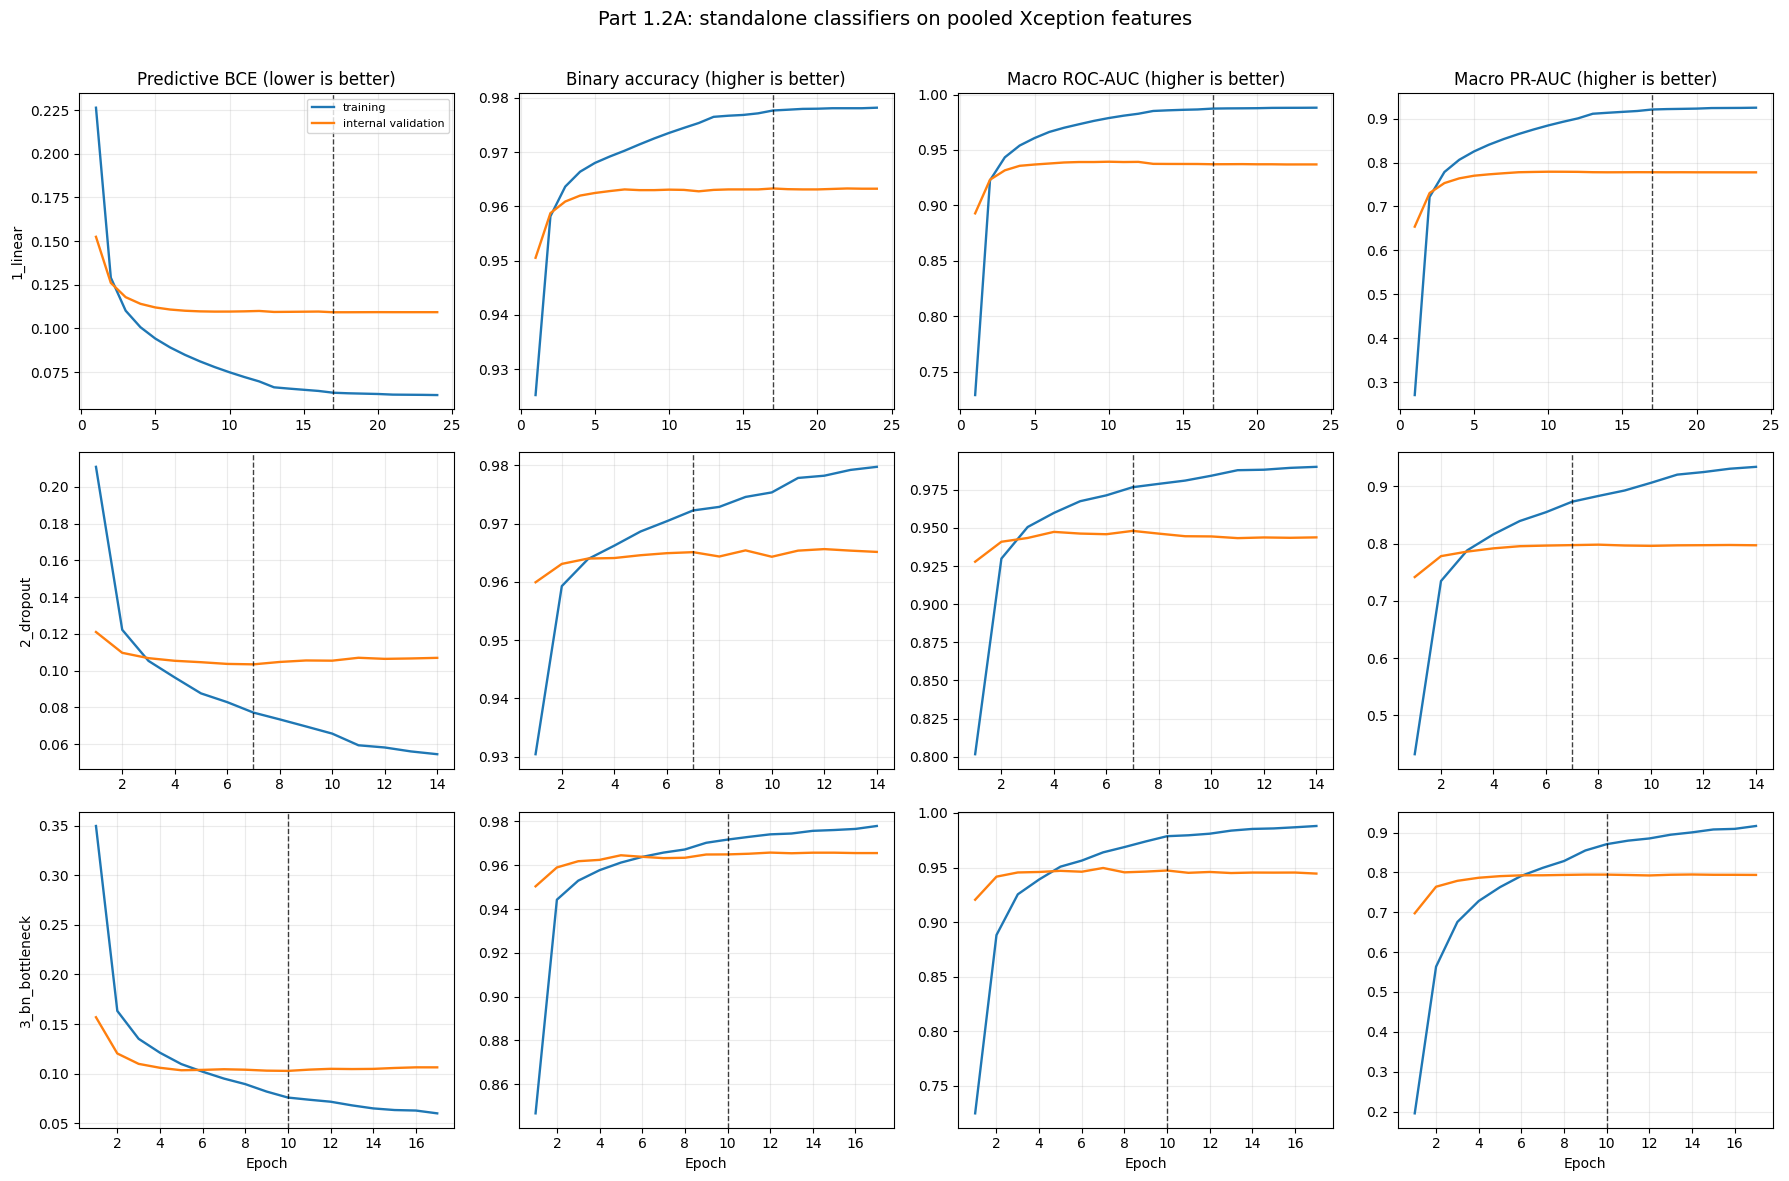


=== Standalone Xception-feature head comparison ===
      iteration  parameters  epochs_run  best_epoch  predictive_bce  binary_accuracy  roc_auc  pr_auc  selected_by_internal_val_bce
3_bn_bottleneck      543060          17          10         0.10275          0.96492  0.94731 0.79445                          True
      2_dropout      529684          14           7         0.10339          0.96509  0.94806 0.79750                         False
       1_linear       40980          24          17         0.10927          0.96330  0.93712 0.77788                         False

=== Xception-feature head selection ===
Selection metric: lowest internal-validation predictive BCE
Selected iteration: 3_bn_bottleneck
Selected checkpoint: /kaggle/working/anndl_outputs/step07_feature_head_3_bn_bottleneck_best.keras
Selected predictive BCE: 0.10275
Selected ROC-AUC: 0.94731
Selected PR-AUC: 0.79445
Saved learning curves: /kaggle/working/anndl_outputs/step07_feature_head_learning_curves.png
Saved c

In [ ]:
#Step 07: Xception feature extraction with three standalone dense heads

import gc
import json
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf


# ---------------------------------------------------------------------------
# 1. Validate notebook state and preserve the scratch-model decision
# ---------------------------------------------------------------------------
required_objects = (
    "SEED",
    "OUTPUT_DIR",
    "N_CLASSES",
    "VOC_CLASSES",
    "CLASSIFICATION_IMAGE_SIZE",
    "train_ds",
    "val_ds",
    "test_ds",
)
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run Steps 01--06 before this cell. Missing objects: "
        + ", ".join(missing_objects)
    )

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

scratch_selection_path = OUTPUT_DIR / "step06_scratch_model_selection.json"
if not scratch_selection_path.exists():
    raise FileNotFoundError(
        "Step 06 scratch-model selection is missing. Run Step 06 first."
    )

with scratch_selection_path.open("r", encoding="utf-8") as file:
    scratch_selection_record = json.load(file)

# Release scratch models before loading ImageNet Xception.
for model_variable_name in (
    "baseline_model",
    "regularized_model",
    "residual_model",
):
    if model_variable_name in globals():
        del globals()[model_variable_name]
gc.collect()
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)


# ---------------------------------------------------------------------------
# 2. Configuration and output paths
# ---------------------------------------------------------------------------
FEATURE_HEAD_MAX_EPOCHS = 40
FEATURE_HEAD_EARLY_STOPPING_PATIENCE = 7
FEATURE_HEAD_INITIAL_LEARNING_RATE = 1e-3

feature_cache_path = OUTPUT_DIR / "step07_xception_pooled_features.npz"
feature_extractor_summary_path = (
    OUTPUT_DIR / "step07_xception_feature_extractor_summary.txt"
)
feature_comparison_path = OUTPUT_DIR / "step07_feature_head_comparison.csv"
feature_selection_path = OUTPUT_DIR / "step07_feature_head_selection.json"
feature_figure_path = OUTPUT_DIR / "step07_feature_head_learning_curves.png"


# ---------------------------------------------------------------------------
# 3. Extract aligned pooled Xception features
# ---------------------------------------------------------------------------
feature_extractor = keras.applications.Xception(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(*CLASSIFICATION_IMAGE_SIZE, 3),
    name="xception_feature_extractor",
)
feature_extractor.trainable = False

summary_lines = []
feature_extractor.summary(print_fn=summary_lines.append)
feature_extractor_summary_path.write_text(
    "\n".join(summary_lines),
    encoding="utf-8",
)


def extract_aligned_features(dataset, split_name):
    """Extract pooled features and the labels from the same batches.

    Collecting both arrays in the same loop prevents feature-label mismatch
    even when the training dataset reshuffles its examples.
    """

    feature_batches = []
    label_batches = []

    print(f"Extracting {split_name} Xception features ...")
    for batch_index, (batch_images, batch_labels) in enumerate(dataset, start=1):
        batch_images = tf.cast(batch_images, tf.float32)
        preprocessed_images = keras.applications.xception.preprocess_input(
            batch_images
        )
        batch_features = feature_extractor(
            preprocessed_images,
            training=False,
        )

        feature_batches.append(np.asarray(batch_features, dtype=np.float32))
        label_batches.append(np.asarray(batch_labels, dtype=np.float32))

        if batch_index % 50 == 0:
            print(f"  processed {batch_index} batches")

    features = np.concatenate(feature_batches, axis=0)
    labels = np.concatenate(label_batches, axis=0)

    if features.ndim != 2 or features.shape[1] != 2048:
        raise RuntimeError(
            f"Unexpected {split_name} feature shape: {features.shape}"
        )
    if labels.shape != (features.shape[0], N_CLASSES):
        raise RuntimeError(
            f"Feature-label mismatch for {split_name}: "
            f"features={features.shape}, labels={labels.shape}"
        )
    if not np.isfinite(features).all() or not np.isfinite(labels).all():
        raise RuntimeError(f"Non-finite values found in {split_name} arrays.")
    if not set(np.unique(labels).tolist()).issubset({0.0, 1.0}):
        raise RuntimeError(f"Non-binary labels found in {split_name} arrays.")

    return features, labels


# Probe Xception-specific preprocessing: raw [0, 255] pixels must map to
# approximately [-1, 1] exactly once.
probe_images, _ = next(iter(val_ds.take(1)))
preprocessed_probe = keras.applications.xception.preprocess_input(
    tf.cast(probe_images, tf.float32)
)
preprocessed_min = float(tf.reduce_min(preprocessed_probe).numpy())
preprocessed_max = float(tf.reduce_max(preprocessed_probe).numpy())
assert -1.0001 <= preprocessed_min <= preprocessed_max <= 1.0001

train_features, train_feature_labels = extract_aligned_features(
    train_ds,
    "training",
)
val_features, val_feature_labels = extract_aligned_features(
    val_ds,
    "internal-validation",
)

# Cache only development-set features. No final-holdout image is passed through
# Xception during model selection.
np.savez_compressed(
    feature_cache_path,
    train_features=train_features,
    train_labels=train_feature_labels,
    val_features=val_features,
    val_labels=val_feature_labels,
)

print("\n=== Part 1.2A: frozen Xception feature extraction ===")
print(f"Xception input shape: {feature_extractor.input_shape}")
print(f"Pooled feature dimension: {train_features.shape[1]:,}")
print(f"Training feature matrix: {train_features.shape}")
print(f"Internal-validation feature matrix: {val_features.shape}")
print(
    "Xception-preprocessed probe range: "
    f"[{preprocessed_min:.4f}, {preprocessed_max:.4f}]"
)
print("Feature-label alignment: verified batch-by-batch")
print("Data augmentation: not applicable to precomputed features")
print("Final holdout status: untouched (features not extracted)")
print(f"Saved feature cache: {feature_cache_path}")

del feature_extractor, probe_images, preprocessed_probe
gc.collect()
keras.backend.clear_session()


# ---------------------------------------------------------------------------
# 4. Define three standalone dense-head iterations
# ---------------------------------------------------------------------------
def build_feature_head(iteration_id, feature_dimension):
    """Build one of three increasingly regularised dense classifiers."""

    inputs = keras.Input(shape=(feature_dimension,), name="pooled_features")

    if iteration_id == "1_linear":
        # Tests how linearly separable the ImageNet representation already is.
        x = inputs

    elif iteration_id == "2_dropout":
        # Adds task-specific nonlinear capacity with dropout.
        x = keras.layers.Dense(
            256,
            activation="relu",
            kernel_initializer="he_normal",
            name="hidden_256",
        )(inputs)
        x = keras.layers.Dropout(
            0.45,
            seed=SEED + 11,
            name="dropout_045",
        )(x)

    elif iteration_id == "3_bn_bottleneck":
        # Adds normalisation and a smaller bottleneck while constraining weights.
        l2_regularizer = keras.regularizers.l2(1e-4)
        x = keras.layers.Dense(
            256,
            use_bias=False,
            kernel_initializer="he_normal",
            kernel_regularizer=l2_regularizer,
            name="hidden_256",
        )(inputs)
        x = keras.layers.BatchNormalization(name="hidden_256_bn")(x)
        x = keras.layers.Activation("relu", name="hidden_256_relu")(x)
        x = keras.layers.Dropout(
            0.50,
            seed=SEED + 12,
            name="dropout_050",
        )(x)
        x = keras.layers.Dense(
            64,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=l2_regularizer,
            name="bottleneck_64",
        )(x)
        x = keras.layers.Dropout(
            0.25,
            seed=SEED + 13,
            name="dropout_025",
        )(x)

    else:
        raise ValueError(f"Unknown feature-head iteration: {iteration_id}")

    outputs = keras.layers.Dense(
        N_CLASSES,
        activation="sigmoid",
        name="multilabel_probabilities",
    )(x)

    model = keras.Model(
        inputs,
        outputs,
        name=f"xception_features_{iteration_id}",
    )
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=FEATURE_HEAD_INITIAL_LEARNING_RATE
        ),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            # Predictive BCE excludes any regularisation penalty and makes all
            # three heads directly comparable.
            keras.metrics.BinaryCrossentropy(name="bce"),
            keras.metrics.BinaryAccuracy(
                name="binary_accuracy",
                threshold=0.5,
            ),
            keras.metrics.AUC(
                name="roc_auc",
                curve="ROC",
                multi_label=True,
                num_labels=N_CLASSES,
            ),
            keras.metrics.AUC(
                name="pr_auc",
                curve="PR",
                multi_label=True,
                num_labels=N_CLASSES,
            ),
        ],
    )
    return model


feature_head_specs = [
    {
        "iteration": "1_linear",
        "design": "sigmoid output directly on pooled Xception features",
    },
    {
        "iteration": "2_dropout",
        "design": "256-unit ReLU hidden layer with 0.45 dropout",
    },
    {
        "iteration": "3_bn_bottleneck",
        "design": (
            "batch-normalised 256-unit layer, dropout, and 64-unit bottleneck"
        ),
    },
]


# ---------------------------------------------------------------------------
# 5. Train, checkpoint, and evaluate each head on internal validation only
# ---------------------------------------------------------------------------
feature_head_records = []
feature_head_histories = {}

for spec_index, spec in enumerate(feature_head_specs, start=1):
    iteration_id = spec["iteration"]
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED + 100 + spec_index)

    feature_head = build_feature_head(
        iteration_id,
        feature_dimension=train_features.shape[1],
    )

    checkpoint_path = (
        OUTPUT_DIR / f"step07_feature_head_{iteration_id}_best.keras"
    )
    history_path = OUTPUT_DIR / f"step07_feature_head_{iteration_id}_history.csv"
    summary_path = OUTPUT_DIR / f"step07_feature_head_{iteration_id}_summary.txt"

    model_summary_lines = []
    feature_head.summary(print_fn=model_summary_lines.append)
    summary_path.write_text("\n".join(model_summary_lines), encoding="utf-8")

    callbacks = [
        keras.callbacks.TerminateOnNaN(),
        keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_bce",
            mode="min",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_bce",
            mode="min",
            factor=0.3,
            patience=3,
            min_delta=1e-4,
            min_lr=1e-6,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_bce",
            mode="min",
            min_delta=1e-4,
            patience=FEATURE_HEAD_EARLY_STOPPING_PATIENCE,
            restore_best_weights=False,
            verbose=1,
        ),
    ]

    print(f"\n=== Training feature-head iteration {iteration_id} ===")
    print(f"Design: {spec['design']}")
    print(f"Parameters: {feature_head.count_params():,}")

    history = feature_head.fit(
        train_features,
        train_feature_labels,
        validation_data=(val_features, val_feature_labels),
        batch_size=64,
        epochs=FEATURE_HEAD_MAX_EPOCHS,
        shuffle=True,
        callbacks=callbacks,
        verbose=1,
    )

    history_df = pd.DataFrame(history.history)
    history_df.index = np.arange(1, len(history_df) + 1)
    history_df.index.name = "epoch"
    history_df.to_csv(history_path)

    required_history_columns = {
        "bce",
        "val_bce",
        "binary_accuracy",
        "val_binary_accuracy",
        "roc_auc",
        "val_roc_auc",
        "pr_auc",
        "val_pr_auc",
    }
    missing_history_columns = required_history_columns - set(history_df)
    if missing_history_columns:
        raise RuntimeError(
            f"Unexpected history for {iteration_id}; missing: "
            + ", ".join(sorted(missing_history_columns))
        )

    best_epoch = int(history_df["val_bce"].idxmin())
    epochs_run = int(len(history_df))

    best_feature_head = keras.models.load_model(checkpoint_path)
    best_internal_metrics = best_feature_head.evaluate(
        val_features,
        val_feature_labels,
        batch_size=64,
        verbose=0,
        return_dict=True,
    )
    best_internal_metrics = {
        key: float(value) for key, value in best_internal_metrics.items()
    }

    feature_head_records.append(
        {
            "iteration": iteration_id,
            "design": spec["design"],
            "parameters": int(feature_head.count_params()),
            "epochs_run": epochs_run,
            "best_epoch": best_epoch,
            "predictive_bce": best_internal_metrics["bce"],
            "binary_accuracy": best_internal_metrics["binary_accuracy"],
            "roc_auc": best_internal_metrics["roc_auc"],
            "pr_auc": best_internal_metrics["pr_auc"],
            "checkpoint": str(checkpoint_path),
            "history": str(history_path),
        }
    )
    feature_head_histories[iteration_id] = history_df.copy()

    print(f"Best internal-validation BCE epoch: {best_epoch}")
    print(f"Best-checkpoint predictive BCE: {best_internal_metrics['bce']:.5f}")
    print(
        "Best-checkpoint binary accuracy: "
        f"{best_internal_metrics['binary_accuracy']:.5f}"
    )
    print(f"Best-checkpoint ROC-AUC: {best_internal_metrics['roc_auc']:.5f}")
    print(f"Best-checkpoint PR-AUC: {best_internal_metrics['pr_auc']:.5f}")

    del feature_head, best_feature_head, history
    gc.collect()


# ---------------------------------------------------------------------------
# 6. Plot all three experiments and select by internal-validation BCE
# ---------------------------------------------------------------------------
metric_specs = [
    ("bce", "Predictive BCE (lower is better)"),
    ("binary_accuracy", "Binary accuracy (higher is better)"),
    ("roc_auc", "Macro ROC-AUC (higher is better)"),
    ("pr_auc", "Macro PR-AUC (higher is better)"),
]

figure, axes = plt.subplots(
    len(feature_head_specs),
    len(metric_specs),
    figsize=(18, 12),
    squeeze=False,
)

for row_index, spec in enumerate(feature_head_specs):
    iteration_id = spec["iteration"]
    history_df = feature_head_histories[iteration_id]
    best_epoch = int(history_df["val_bce"].idxmin())

    for column_index, (metric_name, metric_title) in enumerate(metric_specs):
        axis = axes[row_index, column_index]
        axis.plot(
            history_df.index,
            history_df[metric_name],
            label="training",
            linewidth=1.7,
        )
        axis.plot(
            history_df.index,
            history_df[f"val_{metric_name}"],
            label="internal validation",
            linewidth=1.7,
        )
        axis.axvline(
            best_epoch,
            color="black",
            linestyle="--",
            linewidth=1.0,
            alpha=0.75,
        )
        if row_index == 0:
            axis.set_title(metric_title)
        if column_index == 0:
            axis.set_ylabel(iteration_id)
        if row_index == len(feature_head_specs) - 1:
            axis.set_xlabel("Epoch")
        axis.grid(alpha=0.25)
        if row_index == 0 and column_index == 0:
            axis.legend(fontsize=8)

figure.suptitle(
    "Part 1.2A: standalone classifiers on pooled Xception features",
    fontsize=14,
)
figure.tight_layout(rect=(0, 0, 1, 0.97))
figure.savefig(feature_figure_path, dpi=180, bbox_inches="tight")
plt.show()

feature_comparison_df = pd.DataFrame(feature_head_records).sort_values(
    "predictive_bce",
    ascending=True,
).reset_index(drop=True)
selected_record = feature_comparison_df.iloc[0].to_dict()

feature_comparison_df["selected_by_internal_val_bce"] = (
    feature_comparison_df["iteration"] == selected_record["iteration"]
)
feature_comparison_df.to_csv(feature_comparison_path, index=False)

selection_record = {
    "selection_metric": "lowest internal-validation predictive BCE",
    "selected_iteration": selected_record["iteration"],
    "selected_checkpoint": selected_record["checkpoint"],
    "selected_internal_validation_metrics": {
        "bce": float(selected_record["predictive_bce"]),
        "binary_accuracy": float(selected_record["binary_accuracy"]),
        "roc_auc": float(selected_record["roc_auc"]),
        "pr_auc": float(selected_record["pr_auc"]),
    },
    "scratch_model_retained_separately": scratch_selection_record,
    "final_holdout_used": False,
}
with feature_selection_path.open("w", encoding="utf-8") as file:
    json.dump(selection_record, file, indent=2)

display_columns = [
    "iteration",
    "parameters",
    "epochs_run",
    "best_epoch",
    "predictive_bce",
    "binary_accuracy",
    "roc_auc",
    "pr_auc",
    "selected_by_internal_val_bce",
]

print("\n=== Standalone Xception-feature head comparison ===")
print(
    feature_comparison_df[display_columns].to_string(
        index=False,
        float_format=lambda value: f"{value:.5f}",
    )
)

print("\n=== Xception-feature head selection ===")
print("Selection metric: lowest internal-validation predictive BCE")
print(f"Selected iteration: {selected_record['iteration']}")
print(f"Selected checkpoint: {selected_record['checkpoint']}")
print(f"Selected predictive BCE: {selected_record['predictive_bce']:.5f}")
print(f"Selected ROC-AUC: {selected_record['roc_auc']:.5f}")
print(f"Selected PR-AUC: {selected_record['pr_auc']:.5f}")
print(f"Saved learning curves: {feature_figure_path}")
print(f"Saved comparison table: {feature_comparison_path}")
print(f"Saved selection record: {feature_selection_path}")
print("FINAL HOLDOUT REMAINS UNTOUCHED.")


=== Step 08 configuration ===
Step 07-selected dense architecture: 3_bn_bottleneck
Part 1.2B head initialisation: fresh weights
Input image size: (180, 180)
Xception-preprocessed probe range: [-1.0000, 1.0000]
Augmentation: flip, rotation, zoom, translation, contrast
Final holdout status: untouched

=== Part 1.2B: extended classifier with frozen Xception ===
Total parameters: 21,404,540
Frozen Xception parameters: 20,861,480
Classifier-head parameters: 543,060
Trainable parameters: 542,548
Initial learning rate: 0.0003
Saved model summary: /kaggle/working/anndl_outputs/step08_extended_frozen_summary.txt
Epoch 1/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - bce: 0.6424 - binary_accuracy: 0.6494 - loss: 0.7065 - pr_auc: 0.1099 - roc_auc: 0.5994
Epoch 1: val_bce improved from None to 0.21597, saving model to /kaggle/working/anndl_outputs/step08_extended_frozen_best.keras

Epoch 1: finished saving model to /kaggle/working/anndl_outputs/step08_extended_frozen_best.keras
143/143 ━━━━━━━━━━


=== Part 1.2C: fine-tune Xception's last block ===
Starting checkpoint: /kaggle/working/anndl_outputs/step08_extended_frozen_best.keras
Last-block boundary: block14_sepconv1
Unfrozen Xception parameter layers: block14_sepconv1, block14_sepconv2
Xception BatchNormalization layers kept frozen: True
Trainable Xception parameters: 4,741,632
Total trainable parameters including head: 5,284,180
Initial fine-tuning learning rate: 1e-05
Saved model summary: /kaggle/working/anndl_outputs/step08_finetuned_summary.txt
Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - bce: 0.1039 - binary_accuracy: 0.9616 - loss: 0.1445 - pr_auc: 0.7821 - roc_auc: 0.9581
Epoch 1: val_bce improved from None to 0.10049, saving model to /kaggle/working/anndl_outputs/step08_finetuned_best.keras

Epoch 1: finished saving model to /kaggle/working/anndl_outputs/step08_finetuned_best.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 30s 168ms/step - bce: 0.1029 - binary_accuracy: 0.9624 - loss: 0.1435 - pr_auc: 0.7783 - roc_auc: 

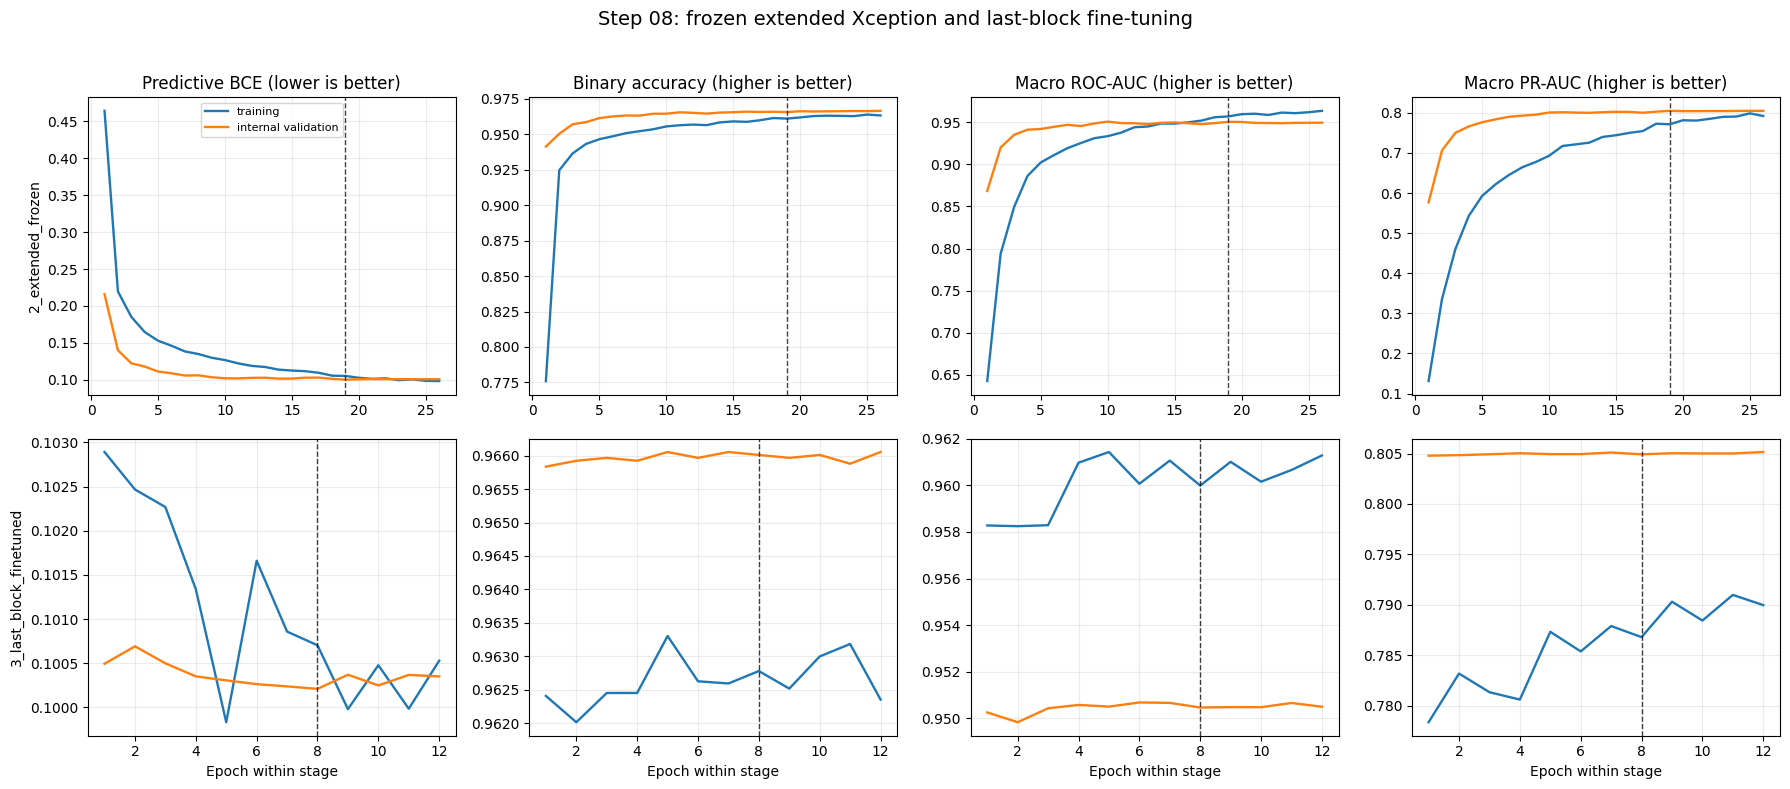


=== All Xception approaches ===
              approach  total_pipeline_parameters  trainable_parameters  best_epoch  predictive_bce  binary_accuracy  roc_auc  pr_auc  selected_by_internal_val_bce
     2_extended_frozen                   21404540                542548          19         0.10021          0.96570  0.95068 0.80487                          True
3_last_block_finetuned                   21404540               5284180           8         0.10021          0.96601  0.95047 0.80492                         False
 1_standalone_features                   21404540                542548          10         0.10275          0.96492  0.94731 0.79445                         False

=== Fine-tuned minus extended-frozen (internal validation) ===
predictive_bce: +0.00000 (lower is better)
binary_accuracy: +0.00031 (higher is better)
roc_auc: -0.00022 (higher is better)
pr_auc: +0.00006 (higher is better)

=== Xception approach selection ===
Selection metric: lowest internal-validation pred

In [ ]:
#Step 08: extend frozen Xception, then fine-tune

import gc
import hashlib
import json
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf


# ---------------------------------------------------------------------------
# 1. Validate notebook
# ---------------------------------------------------------------------------
required_objects = (
    "SEED",
    "OUTPUT_DIR",
    "N_CLASSES",
    "VOC_CLASSES",
    "CLASSIFICATION_IMAGE_SIZE",
    "train_ds",
    "val_ds",
    "test_ds",
)
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run Steps 01--07 before this cell. Missing objects: "
        + ", ".join(missing_objects)
    )

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

feature_selection_path = OUTPUT_DIR / "step07_feature_head_selection.json"
feature_comparison_path = OUTPUT_DIR / "step07_feature_head_comparison.csv"
scratch_selection_path = OUTPUT_DIR / "step06_scratch_model_selection.json"
scratch_comparison_path = OUTPUT_DIR / "step06_all_scratch_iterations.csv"

required_step_files = (
    feature_selection_path,
    feature_comparison_path,
    scratch_selection_path,
    scratch_comparison_path,
)
missing_step_files = [str(path) for path in required_step_files if not path.exists()]
if missing_step_files:
    raise FileNotFoundError(
        "Step 06/07 records are missing. Complete Step 07 first. Missing: "
        + ", ".join(missing_step_files)
    )

with feature_selection_path.open("r", encoding="utf-8") as file:
    feature_selection_record = json.load(file)
with scratch_selection_path.open("r", encoding="utf-8") as file:
    scratch_selection_record = json.load(file)

selected_head_iteration = feature_selection_record["selected_iteration"]
supported_head_iterations = {
    "1_linear",
    "2_dropout",
    "3_bn_bottleneck",
}
if selected_head_iteration not in supported_head_iterations:
    raise RuntimeError(
        "Unsupported Step 07 head selection: " + str(selected_head_iteration)
    )

selected_feature_head_checkpoint = Path(
    feature_selection_record["selected_checkpoint"]
)
if not selected_feature_head_checkpoint.exists():
    raise FileNotFoundError(
        "The selected Step 07 head checkpoint is missing: "
        f"{selected_feature_head_checkpoint}"
    )

feature_comparison_df = pd.read_csv(feature_comparison_path)
selected_feature_rows = feature_comparison_df.loc[
    feature_comparison_df["iteration"] == selected_head_iteration
]
if len(selected_feature_rows) != 1:
    raise RuntimeError(
        "Step 07 comparison must contain exactly one selected head row."
    )
selected_feature_row = selected_feature_rows.iloc[0].to_dict()

scratch_comparison_df = pd.read_csv(scratch_comparison_path)
selected_scratch_iteration = scratch_selection_record["selected_iteration"]
selected_scratch_rows = scratch_comparison_df.loc[
    scratch_comparison_df["iteration"] == selected_scratch_iteration
]
if len(selected_scratch_rows) != 1:
    raise RuntimeError(
        "Step 06 comparison must contain exactly one selected scratch row."
    )
selected_scratch_row = selected_scratch_rows.iloc[0].to_dict()

# Step 07's cached matrices are no longer needed. Releasing them leaves more
# host memory available for end-to-end image training.
for object_name in (
    "train_features",
    "train_feature_labels",
    "val_features",
    "val_feature_labels",
    "feature_head_histories",
    "feature_comparison_df",
    "feature_head_records",
    "scratch_comparison_df",
):
    if object_name in globals():
        del globals()[object_name]
gc.collect()
keras.backend.clear_session()
keras.utils.set_random_seed(SEED + 800)


# ---------------------------------------------------------------------------
# 2. Configuration and output paths
# ---------------------------------------------------------------------------
FROZEN_MAX_EPOCHS = 30
FROZEN_EARLY_STOPPING_PATIENCE = 7
FROZEN_INITIAL_LEARNING_RATE = 3e-4

FINE_TUNE_MAX_EPOCHS = 20
FINE_TUNE_EARLY_STOPPING_PATIENCE = 5
FINE_TUNE_INITIAL_LEARNING_RATE = 1e-5
FINE_TUNE_LAST_BLOCK_START = "block14_sepconv1"

frozen_checkpoint_path = OUTPUT_DIR / "step08_extended_frozen_best.keras"
frozen_history_path = OUTPUT_DIR / "step08_extended_frozen_history.csv"
frozen_summary_path = OUTPUT_DIR / "step08_extended_frozen_summary.txt"
frozen_metrics_path = OUTPUT_DIR / "step08_extended_frozen_metrics.json"

fine_tuned_checkpoint_path = OUTPUT_DIR / "step08_finetuned_best.keras"
fine_tuned_history_path = OUTPUT_DIR / "step08_finetuned_history.csv"
fine_tuned_summary_path = OUTPUT_DIR / "step08_finetuned_summary.txt"
fine_tuned_metrics_path = OUTPUT_DIR / "step08_finetuned_metrics.json"

step08_figure_path = OUTPUT_DIR / "step08_frozen_vs_finetuned_learning_curves.png"
xception_comparison_path = OUTPUT_DIR / "step08_xception_approach_comparison.csv"
xception_selection_path = OUTPUT_DIR / "step08_xception_selection.json"
all_candidates_path = OUTPUT_DIR / "step08_all_classification_candidates.csv"
global_selection_path = OUTPUT_DIR / "step08_global_classification_selection.json"


# ---------------------------------------------------------------------------
# 3. Reusable model, metric, callback, and audit helpers
# ---------------------------------------------------------------------------
def compile_multilabel_model(model, optimizer):
    """Compile a 20-label sigmoid classifier with comparable metrics."""

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            # Predictive BCE excludes any regularisation penalties that may be
            # included in Keras's total ``loss`` value.
            keras.metrics.BinaryCrossentropy(name="bce"),
            keras.metrics.BinaryAccuracy(
                name="binary_accuracy",
                threshold=0.5,
            ),
            keras.metrics.AUC(
                name="roc_auc",
                curve="ROC",
                multi_label=True,
                num_labels=N_CLASSES,
            ),
            keras.metrics.AUC(
                name="pr_auc",
                curve="PR",
                multi_label=True,
                num_labels=N_CLASSES,
            ),
        ],
    )


def add_selected_dense_head(pooled_features, iteration_id):
    """Rebuild the Step 07-selected head with fresh weights.

    Part 1.2B is a distinct image-model experiment. It reuses the selected
    architecture, not the already-trained standalone-head weights.
    """

    x = pooled_features

    if iteration_id == "1_linear":
        pass

    elif iteration_id == "2_dropout":
        x = keras.layers.Dense(
            256,
            activation="relu",
            kernel_initializer="he_normal",
            name="transfer_hidden_256",
        )(x)
        x = keras.layers.Dropout(
            0.45,
            seed=SEED + 811,
            name="transfer_dropout_045",
        )(x)

    elif iteration_id == "3_bn_bottleneck":
        l2_regularizer = keras.regularizers.l2(1e-4)
        x = keras.layers.Dense(
            256,
            use_bias=False,
            kernel_initializer="he_normal",
            kernel_regularizer=l2_regularizer,
            name="transfer_hidden_256",
        )(x)
        x = keras.layers.BatchNormalization(name="transfer_hidden_256_bn")(x)
        x = keras.layers.Activation(
            "relu",
            name="transfer_hidden_256_relu",
        )(x)
        x = keras.layers.Dropout(
            0.50,
            seed=SEED + 812,
            name="transfer_dropout_050",
        )(x)
        x = keras.layers.Dense(
            64,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=l2_regularizer,
            name="transfer_bottleneck_64",
        )(x)
        x = keras.layers.Dropout(
            0.25,
            seed=SEED + 813,
            name="transfer_dropout_025",
        )(x)

    else:
        raise ValueError(f"Unknown selected head: {iteration_id}")

    return keras.layers.Dense(
        N_CLASSES,
        activation="sigmoid",
        name="multilabel_probabilities",
    )(x)


def build_extended_xception(iteration_id):
    """Build the Part 1.2B image classifier with a frozen Xception base."""

    augmentation = keras.Sequential(
        [
            keras.layers.RandomFlip(
                "horizontal",
                seed=SEED + 801,
            ),
            keras.layers.RandomRotation(
                factor=0.05,
                fill_mode="reflect",
                seed=SEED + 802,
            ),
            keras.layers.RandomZoom(
                height_factor=(-0.10, 0.10),
                width_factor=(-0.10, 0.10),
                fill_mode="reflect",
                seed=SEED + 803,
            ),
            keras.layers.RandomTranslation(
                height_factor=0.05,
                width_factor=0.05,
                fill_mode="reflect",
                seed=SEED + 804,
            ),
            keras.layers.RandomContrast(
                factor=0.10,
                seed=SEED + 805,
            ),
        ],
        name="xception_augmentation",
    )

    convolutional_base = keras.applications.Xception(
        weights="imagenet",
        include_top=False,
        pooling=None,
        input_shape=(*CLASSIFICATION_IMAGE_SIZE, 3),
        name="xception_conv_base",
    )
    convolutional_base.trainable = False

    inputs = keras.Input(
        shape=(*CLASSIFICATION_IMAGE_SIZE, 3),
        name="image",
    )
    x = augmentation(inputs)

    # Xception preprocess_input maps raw [0, 255] RGB pixels to [-1, 1].
    # A serialisable Rescaling layer performs that exact affine transform.
    x = keras.layers.Rescaling(
        scale=1.0 / 127.5,
        offset=-1.0,
        name="xception_preprocessing",
    )(x)

    # training=False keeps Xception BatchNorm statistics in inference mode.
    # This remains deliberate during last-block fine-tuning as recommended for
    # small datasets; ordinary convolutional weights still receive gradients.
    x = convolutional_base(x, training=False)
    x = keras.layers.GlobalAveragePooling2D(
        name="xception_global_average_pooling"
    )(x)
    outputs = add_selected_dense_head(x, iteration_id)

    model = keras.Model(
        inputs,
        outputs,
        name="voc2012_extended_xception",
    )
    compile_multilabel_model(
        model,
        keras.optimizers.Adam(
            learning_rate=FROZEN_INITIAL_LEARNING_RATE
        ),
    )
    return model, convolutional_base


def parameter_count(variables):
    """Return the number of scalar parameters in a variable sequence."""

    return int(sum(np.prod(tuple(variable.shape)) for variable in variables))


def weights_fingerprint(layers):
    """Hash ordered layer weights to audit frozen/unfrozen boundaries."""

    digest = hashlib.sha256()
    for layer in layers:
        for weight in layer.weights:
            array = np.ascontiguousarray(weight.numpy())
            digest.update(str(array.shape).encode("utf-8"))
            digest.update(str(array.dtype).encode("utf-8"))
            digest.update(memoryview(array).cast("B"))
    return digest.hexdigest()


def callbacks_for_stage(
    checkpoint_path,
    patience,
    plateau_patience,
    minimum_learning_rate,
):
    """Create fresh callbacks for one training stage."""

    return [
        keras.callbacks.TerminateOnNaN(),
        keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_bce",
            mode="min",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_bce",
            mode="min",
            factor=0.3,
            patience=plateau_patience,
            min_delta=1e-4,
            min_lr=minimum_learning_rate,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_bce",
            mode="min",
            min_delta=1e-4,
            patience=patience,
            restore_best_weights=False,
            verbose=1,
        ),
    ]


def history_to_frame(history, output_path):
    """Validate and save a Keras History object."""

    history_frame = pd.DataFrame(history.history)
    history_frame.index = np.arange(1, len(history_frame) + 1)
    history_frame.index.name = "epoch"

    required_columns = {
        "loss",
        "val_loss",
        "bce",
        "val_bce",
        "binary_accuracy",
        "val_binary_accuracy",
        "roc_auc",
        "val_roc_auc",
        "pr_auc",
        "val_pr_auc",
    }
    missing_columns = required_columns - set(history_frame)
    if missing_columns:
        raise RuntimeError(
            "Unexpected Keras history; missing: "
            + ", ".join(sorted(missing_columns))
        )
    if not np.isfinite(history_frame[list(required_columns)].to_numpy()).all():
        raise RuntimeError("Non-finite values were found in the training history.")

    history_frame.to_csv(output_path)
    return history_frame


def evaluate_checkpoint(checkpoint_path):
    """Load a best checkpoint and evaluate internal validation once."""

    model = keras.models.load_model(checkpoint_path)
    metrics = model.evaluate(
        val_ds,
        verbose=0,
        return_dict=True,
    )
    metrics = {key: float(value) for key, value in metrics.items()}
    required_metrics = {"loss", "bce", "binary_accuracy", "roc_auc", "pr_auc"}
    if required_metrics - set(metrics):
        raise RuntimeError(
            f"Checkpoint metrics are incomplete for {checkpoint_path}."
        )
    if not all(np.isfinite(value) for value in metrics.values()):
        raise RuntimeError(f"Non-finite checkpoint metrics: {checkpoint_path}")
    return model, metrics


def diagnose_history(history_frame):
    """Summarise the validation-BCE minimum and any later rebound."""

    best_epoch = int(history_frame["val_bce"].idxmin())
    best_position = history_frame.index.get_loc(best_epoch)
    best_validation_bce = float(history_frame.loc[best_epoch, "val_bce"])
    last_validation_bce = float(history_frame["val_bce"].iloc[-1])
    validation_rebound = last_validation_bce - best_validation_bce
    training_change = float(
        history_frame["bce"].iloc[-1]
        - history_frame["bce"].iloc[best_position]
    )
    return {
        "epochs_run": int(len(history_frame)),
        "best_epoch": best_epoch,
        "best_validation_bce": best_validation_bce,
        "last_validation_bce": last_validation_bce,
        "validation_bce_rebound": validation_rebound,
        "training_bce_change_after_best_epoch": training_change,
        "overfitting_pattern_observed": bool(
            validation_rebound > 1e-4 and training_change < -1e-4
        ),
    }


# ---------------------------------------------------------------------------
# 4. Part 1.2B - train an extended classifier with frozen Xception
# ---------------------------------------------------------------------------
extended_frozen_model, frozen_xception_base = build_extended_xception(
    selected_head_iteration
)
assert extended_frozen_model.output_shape == (None, N_CLASSES)
assert frozen_xception_base.trainable is False
assert parameter_count(frozen_xception_base.trainable_weights) == 0

# Verify that raw shared images are mapped to Xception's expected range once.
probe_images, _ = next(iter(val_ds.take(1)))
preprocessing_probe_model = keras.Model(
    extended_frozen_model.input,
    extended_frozen_model.get_layer("xception_preprocessing").output,
)
preprocessed_probe = preprocessing_probe_model(probe_images, training=False)
preprocessed_min = float(tf.reduce_min(preprocessed_probe).numpy())
preprocessed_max = float(tf.reduce_max(preprocessed_probe).numpy())
assert -1.0001 <= preprocessed_min <= preprocessed_max <= 1.0001

del preprocessing_probe_model, probe_images, preprocessed_probe
gc.collect()

frozen_base_fingerprint_before = weights_fingerprint(
    frozen_xception_base.layers
)
frozen_total_parameters = int(extended_frozen_model.count_params())
frozen_trainable_parameters = parameter_count(
    extended_frozen_model.trainable_weights
)
frozen_base_parameters = int(frozen_xception_base.count_params())
classifier_head_parameters = frozen_total_parameters - frozen_base_parameters

summary_lines = []
extended_frozen_model.summary(print_fn=summary_lines.append, expand_nested=True)
frozen_summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

print("=== Step 08 configuration ===")
print(f"Step 07-selected dense architecture: {selected_head_iteration}")
print("Part 1.2B head initialisation: fresh weights")
print(f"Input image size: {CLASSIFICATION_IMAGE_SIZE}")
print(
    "Xception-preprocessed probe range: "
    f"[{preprocessed_min:.4f}, {preprocessed_max:.4f}]"
)
print("Augmentation: flip, rotation, zoom, translation, contrast")
print("Final holdout status: untouched")

print("\n=== Part 1.2B: extended classifier with frozen Xception ===")
print(f"Total parameters: {frozen_total_parameters:,}")
print(f"Frozen Xception parameters: {frozen_base_parameters:,}")
print(f"Classifier-head parameters: {classifier_head_parameters:,}")
print(f"Trainable parameters: {frozen_trainable_parameters:,}")
print(f"Initial learning rate: {FROZEN_INITIAL_LEARNING_RATE:g}")
print(f"Saved model summary: {frozen_summary_path}")

frozen_history = extended_frozen_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FROZEN_MAX_EPOCHS,
    callbacks=callbacks_for_stage(
        checkpoint_path=frozen_checkpoint_path,
        patience=FROZEN_EARLY_STOPPING_PATIENCE,
        plateau_patience=3,
        minimum_learning_rate=1e-6,
    ),
    verbose=1,
)

frozen_history_df = history_to_frame(
    frozen_history,
    frozen_history_path,
)
frozen_diagnosis = diagnose_history(frozen_history_df)

frozen_base_fingerprint_after = weights_fingerprint(
    frozen_xception_base.layers
)
if frozen_base_fingerprint_after != frozen_base_fingerprint_before:
    raise RuntimeError(
        "Xception weights changed during the frozen-base stage."
    )

best_frozen_model, frozen_internal_metrics = evaluate_checkpoint(
    frozen_checkpoint_path
)

frozen_metrics_record = {
    "stage": "2_extended_frozen",
    "selected_dense_architecture": selected_head_iteration,
    "head_initialisation": "fresh weights",
    "xception_imagenet_weights": True,
    "xception_base_trainable": False,
    "xception_batchnorm_training_mode": False,
    "total_parameters": frozen_total_parameters,
    "base_parameters": frozen_base_parameters,
    "classifier_head_parameters": classifier_head_parameters,
    "trainable_parameters": frozen_trainable_parameters,
    "preprocessed_probe_range": [preprocessed_min, preprocessed_max],
    "training_diagnosis": frozen_diagnosis,
    "internal_validation_metrics_at_best_checkpoint": frozen_internal_metrics,
    "base_weights_unchanged": True,
    "checkpoint": str(frozen_checkpoint_path),
    "history": str(frozen_history_path),
    "final_holdout_used": False,
}
with frozen_metrics_path.open("w", encoding="utf-8") as file:
    json.dump(frozen_metrics_record, file, indent=2)

print("\n=== Frozen-Xception training diagnosis ===")
print(f"Epochs run: {frozen_diagnosis['epochs_run']}")
print(f"Best internal-validation BCE epoch: {frozen_diagnosis['best_epoch']}")
print(
    "Best internal-validation BCE: "
    f"{frozen_diagnosis['best_validation_bce']:.5f}"
)
print(
    "Last-epoch internal-validation BCE: "
    f"{frozen_diagnosis['last_validation_bce']:.5f}"
)
print(
    "Validation-BCE rebound after best epoch: "
    f"{frozen_diagnosis['validation_bce_rebound']:+.5f}"
)
print(
    "Overfitting pattern observed: "
    f"{frozen_diagnosis['overfitting_pattern_observed']}"
)
print("Frozen-base weight audit passed: True")

print("\n=== Frozen-Xception best-checkpoint metrics ===")
for metric_name in ("bce", "binary_accuracy", "roc_auc", "pr_auc", "loss"):
    print(f"{metric_name}: {frozen_internal_metrics[metric_name]:.5f}")


# ---------------------------------------------------------------------------
# 5. Part 1.2C - fine-tune only Xception's last convolutional block
# ---------------------------------------------------------------------------
# The best Part 1.2B checkpoint, rather than its last epoch, is the mandatory
# starting point for Part 1.2C.
fine_tuned_model = best_frozen_model
del best_frozen_model
del extended_frozen_model, frozen_xception_base, frozen_history
gc.collect()

fine_tune_xception_base = fine_tuned_model.get_layer("xception_conv_base")
layer_names = [layer.name for layer in fine_tune_xception_base.layers]
if FINE_TUNE_LAST_BLOCK_START not in layer_names:
    raise RuntimeError(
        "Could not locate Xception's last block boundary: "
        f"{FINE_TUNE_LAST_BLOCK_START}"
    )

last_block_start_index = layer_names.index(FINE_TUNE_LAST_BLOCK_START)
fine_tune_xception_base.trainable = True

for layer_index, layer in enumerate(fine_tune_xception_base.layers):
    in_last_block = layer_index >= last_block_start_index
    # BatchNorm remains frozen and is also called with training=False in the
    # functional graph. This protects small-dataset fine-tuning from unstable
    # moving-statistic updates.
    layer.trainable = bool(
        in_last_block
        and not isinstance(layer, keras.layers.BatchNormalization)
    )

unfrozen_parameter_layers = [
    layer.name
    for layer in fine_tune_xception_base.layers
    if layer.trainable_weights
]
if not unfrozen_parameter_layers:
    raise RuntimeError("No Xception parameter layer was unfrozen.")
if any(
    isinstance(layer, keras.layers.BatchNormalization) and layer.trainable
    for layer in fine_tune_xception_base.layers
):
    raise RuntimeError("An Xception BatchNormalization layer is trainable.")

frozen_prefix_layers = fine_tune_xception_base.layers[:last_block_start_index]
last_block_layers = fine_tune_xception_base.layers[last_block_start_index:]
frozen_prefix_fingerprint_before = weights_fingerprint(frozen_prefix_layers)
last_block_fingerprint_before = weights_fingerprint(last_block_layers)

# Changing trainable flags requires recompilation. RMSprop and a very small
# learning rate follow the project hint and lecture fine-tuning procedure.
compile_multilabel_model(
    fine_tuned_model,
    keras.optimizers.RMSprop(
        learning_rate=FINE_TUNE_INITIAL_LEARNING_RATE
    ),
)

fine_tuned_total_parameters = int(fine_tuned_model.count_params())
fine_tuned_trainable_parameters = parameter_count(
    fine_tuned_model.trainable_weights
)
fine_tuned_base_trainable_parameters = parameter_count(
    fine_tune_xception_base.trainable_weights
)

fine_tuned_summary_lines = []
fine_tuned_model.summary(
    print_fn=fine_tuned_summary_lines.append,
    expand_nested=True,
)
fine_tuned_summary_path.write_text(
    "\n".join(fine_tuned_summary_lines),
    encoding="utf-8",
)

print("\n=== Part 1.2C: fine-tune Xception's last block ===")
print(f"Starting checkpoint: {frozen_checkpoint_path}")
print(f"Last-block boundary: {FINE_TUNE_LAST_BLOCK_START}")
print(
    "Unfrozen Xception parameter layers: "
    + ", ".join(unfrozen_parameter_layers)
)
print("Xception BatchNormalization layers kept frozen: True")
print(f"Trainable Xception parameters: {fine_tuned_base_trainable_parameters:,}")
print(f"Total trainable parameters including head: {fine_tuned_trainable_parameters:,}")
print(f"Initial fine-tuning learning rate: {FINE_TUNE_INITIAL_LEARNING_RATE:g}")
print(f"Saved model summary: {fine_tuned_summary_path}")

fine_tuned_history = fine_tuned_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_MAX_EPOCHS,
    callbacks=callbacks_for_stage(
        checkpoint_path=fine_tuned_checkpoint_path,
        patience=FINE_TUNE_EARLY_STOPPING_PATIENCE,
        plateau_patience=2,
        minimum_learning_rate=1e-7,
    ),
    verbose=1,
)

fine_tuned_history_df = history_to_frame(
    fine_tuned_history,
    fine_tuned_history_path,
)
fine_tuned_diagnosis = diagnose_history(fine_tuned_history_df)

frozen_prefix_fingerprint_after = weights_fingerprint(frozen_prefix_layers)
last_block_fingerprint_after = weights_fingerprint(last_block_layers)
if frozen_prefix_fingerprint_after != frozen_prefix_fingerprint_before:
    raise RuntimeError(
        "A frozen Xception layer changed during last-block fine-tuning."
    )
if last_block_fingerprint_after == last_block_fingerprint_before:
    raise RuntimeError(
        "Xception's unfrozen last-block weights did not change."
    )

# Release the last-epoch model before loading the independent best checkpoint.
del fine_tuned_model, fine_tune_xception_base, fine_tuned_history
del frozen_prefix_layers, last_block_layers
gc.collect()
keras.backend.clear_session()

best_fine_tuned_model, fine_tuned_internal_metrics = evaluate_checkpoint(
    fine_tuned_checkpoint_path
)
best_fine_tuned_base = best_fine_tuned_model.get_layer("xception_conv_base")
best_prefix_fingerprint = weights_fingerprint(
    best_fine_tuned_base.layers[:last_block_start_index]
)
best_last_block_fingerprint = weights_fingerprint(
    best_fine_tuned_base.layers[last_block_start_index:]
)
if best_prefix_fingerprint != frozen_prefix_fingerprint_before:
    raise RuntimeError("Best fine-tuned checkpoint changed the frozen prefix.")
if best_last_block_fingerprint == last_block_fingerprint_before:
    raise RuntimeError("Best fine-tuned checkpoint did not update the last block.")

del best_fine_tuned_model, best_fine_tuned_base
gc.collect()

fine_tuned_metrics_record = {
    "stage": "3_last_block_finetuned",
    "starting_checkpoint": str(frozen_checkpoint_path),
    "last_block_start_layer": FINE_TUNE_LAST_BLOCK_START,
    "unfrozen_parameter_layers": unfrozen_parameter_layers,
    "xception_batchnorm_trainable": False,
    "xception_batchnorm_training_mode": False,
    "optimizer": "RMSprop",
    "initial_learning_rate": FINE_TUNE_INITIAL_LEARNING_RATE,
    "total_parameters": fine_tuned_total_parameters,
    "base_parameters": frozen_base_parameters,
    "classifier_head_parameters": classifier_head_parameters,
    "trainable_xception_parameters": fine_tuned_base_trainable_parameters,
    "trainable_parameters": fine_tuned_trainable_parameters,
    "training_diagnosis": fine_tuned_diagnosis,
    "internal_validation_metrics_at_best_checkpoint": fine_tuned_internal_metrics,
    "frozen_prefix_weights_unchanged": True,
    "last_block_weights_changed": True,
    "checkpoint": str(fine_tuned_checkpoint_path),
    "history": str(fine_tuned_history_path),
    "final_holdout_used": False,
}
with fine_tuned_metrics_path.open("w", encoding="utf-8") as file:
    json.dump(fine_tuned_metrics_record, file, indent=2)

print("\n=== Fine-tuning diagnosis ===")
print(f"Epochs run: {fine_tuned_diagnosis['epochs_run']}")
print(f"Best internal-validation BCE epoch: {fine_tuned_diagnosis['best_epoch']}")
print(
    "Best internal-validation BCE: "
    f"{fine_tuned_diagnosis['best_validation_bce']:.5f}"
)
print(
    "Last-epoch internal-validation BCE: "
    f"{fine_tuned_diagnosis['last_validation_bce']:.5f}"
)
print(
    "Validation-BCE rebound after best epoch: "
    f"{fine_tuned_diagnosis['validation_bce_rebound']:+.5f}"
)
print(
    "Overfitting pattern observed: "
    f"{fine_tuned_diagnosis['overfitting_pattern_observed']}"
)
print("Frozen-prefix weight audit passed: True")
print("Last-block weight-change audit passed: True")

print("\n=== Fine-tuned best-checkpoint metrics ===")
for metric_name in ("bce", "binary_accuracy", "roc_auc", "pr_auc", "loss"):
    print(f"{metric_name}: {fine_tuned_internal_metrics[metric_name]:.5f}")


# ---------------------------------------------------------------------------
# 6. Plot the two image-model stages
# ---------------------------------------------------------------------------
metric_specs = [
    ("bce", "Predictive BCE (lower is better)"),
    ("binary_accuracy", "Binary accuracy (higher is better)"),
    ("roc_auc", "Macro ROC-AUC (higher is better)"),
    ("pr_auc", "Macro PR-AUC (higher is better)"),
]
stage_histories = [
    (
        "2_extended_frozen",
        frozen_history_df,
        frozen_diagnosis["best_epoch"],
    ),
    (
        "3_last_block_finetuned",
        fine_tuned_history_df,
        fine_tuned_diagnosis["best_epoch"],
    ),
]

figure, axes = plt.subplots(
    len(stage_histories),
    len(metric_specs),
    figsize=(18, 8),
    squeeze=False,
)

for row_index, (stage_name, history_frame, best_epoch) in enumerate(
    stage_histories
):
    for column_index, (metric_name, metric_title) in enumerate(metric_specs):
        axis = axes[row_index, column_index]
        axis.plot(
            history_frame.index,
            history_frame[metric_name],
            label="training",
            linewidth=1.7,
        )
        axis.plot(
            history_frame.index,
            history_frame[f"val_{metric_name}"],
            label="internal validation",
            linewidth=1.7,
        )
        axis.axvline(
            best_epoch,
            color="black",
            linestyle="--",
            linewidth=1.0,
            alpha=0.75,
        )
        if row_index == 0:
            axis.set_title(metric_title)
        if column_index == 0:
            axis.set_ylabel(stage_name)
        if row_index == len(stage_histories) - 1:
            axis.set_xlabel("Epoch within stage")
        axis.grid(alpha=0.25)
        if row_index == 0 and column_index == 0:
            axis.legend(fontsize=8)

figure.suptitle(
    "Step 08: frozen extended Xception and last-block fine-tuning",
    fontsize=14,
)
figure.tight_layout(rect=(0, 0, 1, 0.96))
figure.savefig(step08_figure_path, dpi=180, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------------
# 7. Compare all Xception approaches and preserve a validation-only decision
# ---------------------------------------------------------------------------
standalone_metrics = feature_selection_record[
    "selected_internal_validation_metrics"
]
selected_feature_head_for_count = keras.models.load_model(
    selected_feature_head_checkpoint,
    compile=False,
)
standalone_head_total_parameters = int(
    selected_feature_head_for_count.count_params()
)
standalone_head_trainable_parameters = parameter_count(
    selected_feature_head_for_count.trainable_weights
)
if standalone_head_total_parameters != int(selected_feature_row["parameters"]):
    raise RuntimeError(
        "Step 07 head parameter count does not match its saved comparison."
    )
del selected_feature_head_for_count
gc.collect()

standalone_total_parameters = int(
    frozen_base_parameters + standalone_head_total_parameters
)

xception_records = [
    {
        "approach": "1_standalone_features",
        "head_architecture": selected_head_iteration,
        "total_pipeline_parameters": standalone_total_parameters,
        "trainable_parameters": standalone_head_trainable_parameters,
        "best_epoch": int(selected_feature_row["best_epoch"]),
        "predictive_bce": float(standalone_metrics["bce"]),
        "binary_accuracy": float(standalone_metrics["binary_accuracy"]),
        "roc_auc": float(standalone_metrics["roc_auc"]),
        "pr_auc": float(standalone_metrics["pr_auc"]),
        "checkpoint": str(selected_feature_head_checkpoint),
        "model_input": "pooled Xception features",
    },
    {
        "approach": "2_extended_frozen",
        "head_architecture": selected_head_iteration,
        "total_pipeline_parameters": frozen_total_parameters,
        "trainable_parameters": frozen_trainable_parameters,
        "best_epoch": frozen_diagnosis["best_epoch"],
        "predictive_bce": frozen_internal_metrics["bce"],
        "binary_accuracy": frozen_internal_metrics["binary_accuracy"],
        "roc_auc": frozen_internal_metrics["roc_auc"],
        "pr_auc": frozen_internal_metrics["pr_auc"],
        "checkpoint": str(frozen_checkpoint_path),
        "model_input": "images",
    },
    {
        "approach": "3_last_block_finetuned",
        "head_architecture": selected_head_iteration,
        "total_pipeline_parameters": fine_tuned_total_parameters,
        "trainable_parameters": fine_tuned_trainable_parameters,
        "best_epoch": fine_tuned_diagnosis["best_epoch"],
        "predictive_bce": fine_tuned_internal_metrics["bce"],
        "binary_accuracy": fine_tuned_internal_metrics["binary_accuracy"],
        "roc_auc": fine_tuned_internal_metrics["roc_auc"],
        "pr_auc": fine_tuned_internal_metrics["pr_auc"],
        "checkpoint": str(fine_tuned_checkpoint_path),
        "model_input": "images",
    },
]

xception_comparison_df = pd.DataFrame(xception_records).sort_values(
    "predictive_bce",
    ascending=True,
).reset_index(drop=True)
xception_selected_record = xception_comparison_df.iloc[0].to_dict()
xception_comparison_df["selected_by_internal_val_bce"] = (
    xception_comparison_df["approach"]
    == xception_selected_record["approach"]
)
xception_comparison_df.to_csv(xception_comparison_path, index=False)

xception_selection_record = {
    "selection_metric": "lowest internal-validation predictive BCE",
    "selected_approach": xception_selected_record["approach"],
    "selected_checkpoint": xception_selected_record["checkpoint"],
    "selected_model_input": xception_selected_record["model_input"],
    "selected_internal_validation_metrics": {
        "bce": float(xception_selected_record["predictive_bce"]),
        "binary_accuracy": float(xception_selected_record["binary_accuracy"]),
        "roc_auc": float(xception_selected_record["roc_auc"]),
        "pr_auc": float(xception_selected_record["pr_auc"]),
    },
    "final_holdout_used": False,
}
with xception_selection_path.open("w", encoding="utf-8") as file:
    json.dump(xception_selection_record, file, indent=2)


# ---------------------------------------------------------------------------
# 8. Compare the best scratch model with all pretrained approaches
# ---------------------------------------------------------------------------
scratch_checkpoint = scratch_selection_record["selected_checkpoint"]

scratch_record = {
    "candidate": selected_scratch_iteration,
    "family": "scratch CNN",
    "predictive_bce": float(selected_scratch_row["predictive_bce"]),
    "binary_accuracy": float(selected_scratch_row["binary_accuracy"]),
    "roc_auc": float(selected_scratch_row["roc_auc"]),
    "pr_auc": float(selected_scratch_row["pr_auc"]),
    "checkpoint": scratch_checkpoint,
    "model_input": "images",
}

pretrained_candidate_records = []
for record in xception_records:
    pretrained_candidate_records.append(
        {
            "candidate": record["approach"],
            "family": "pretrained Xception",
            "predictive_bce": record["predictive_bce"],
            "binary_accuracy": record["binary_accuracy"],
            "roc_auc": record["roc_auc"],
            "pr_auc": record["pr_auc"],
            "checkpoint": record["checkpoint"],
            "model_input": record["model_input"],
        }
    )

all_candidates_df = pd.DataFrame(
    [scratch_record] + pretrained_candidate_records
).sort_values("predictive_bce", ascending=True).reset_index(drop=True)
global_selected_record = all_candidates_df.iloc[0].to_dict()
all_candidates_df["selected_by_internal_val_bce"] = (
    all_candidates_df["candidate"] == global_selected_record["candidate"]
)
all_candidates_df.to_csv(all_candidates_path, index=False)

global_selection_record = {
    "selection_metric": "lowest internal-validation predictive BCE",
    "selected_candidate": global_selected_record["candidate"],
    "selected_family": global_selected_record["family"],
    "selected_checkpoint": global_selected_record["checkpoint"],
    "selected_model_input": global_selected_record["model_input"],
    "selected_internal_validation_metrics": {
        "bce": float(global_selected_record["predictive_bce"]),
        "binary_accuracy": float(global_selected_record["binary_accuracy"]),
        "roc_auc": float(global_selected_record["roc_auc"]),
        "pr_auc": float(global_selected_record["pr_auc"]),
    },
    "final_holdout_used": False,
}
with global_selection_path.open("w", encoding="utf-8") as file:
    json.dump(global_selection_record, file, indent=2)

display_columns = [
    "approach",
    "total_pipeline_parameters",
    "trainable_parameters",
    "best_epoch",
    "predictive_bce",
    "binary_accuracy",
    "roc_auc",
    "pr_auc",
    "selected_by_internal_val_bce",
]

print("\n=== All Xception approaches ===")
print(
    xception_comparison_df[display_columns].to_string(
        index=False,
        float_format=lambda value: f"{value:.5f}",
    )
)

print("\n=== Fine-tuned minus extended-frozen (internal validation) ===")
for metric_name, better_direction in (
    ("predictive_bce", "lower is better"),
    ("binary_accuracy", "higher is better"),
    ("roc_auc", "higher is better"),
    ("pr_auc", "higher is better"),
):
    delta = (
        xception_records[2][metric_name]
        - xception_records[1][metric_name]
    )
    print(f"{metric_name}: {delta:+.5f} ({better_direction})")

print("\n=== Xception approach selection ===")
print("Selection metric: lowest internal-validation predictive BCE")
print(f"Selected approach: {xception_selected_record['approach']}")
print(f"Selected checkpoint: {xception_selected_record['checkpoint']}")
print(
    "Selected predictive BCE: "
    f"{xception_selected_record['predictive_bce']:.5f}"
)
print(f"Selected ROC-AUC: {xception_selected_record['roc_auc']:.5f}")
print(f"Selected PR-AUC: {xception_selected_record['pr_auc']:.5f}")

print("\n=== All classification candidates ===")
print(
    all_candidates_df[
        [
            "candidate",
            "family",
            "predictive_bce",
            "binary_accuracy",
            "roc_auc",
            "pr_auc",
            "selected_by_internal_val_bce",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.5f}",
    )
)

print("\n=== Global classification selection before final holdout ===")
print("Selection metric: lowest internal-validation predictive BCE")
print(f"Selected candidate: {global_selected_record['candidate']}")
print(f"Selected family: {global_selected_record['family']}")
print(f"Selected checkpoint: {global_selected_record['checkpoint']}")
print(f"Saved learning curves: {step08_figure_path}")
print(f"Saved Xception comparison: {xception_comparison_path}")
print(f"Saved Xception selection: {xception_selection_path}")
print(f"Saved all-candidate comparison: {all_candidates_path}")
print(f"Saved global selection: {global_selection_path}")
print("FINAL HOLDOUT REMAINS UNTOUCHED.")


### Discussion — feature extraction, frozen transfer learning, and fine-tuning

Three dense heads were compared on pooled 2,048-dimensional Xception features. The batch-normalised bottleneck head achieved the lowest internal-validation BCE (0.10275), so that architecture was carried into the image-level transfer-learning experiments. Extending the frozen Xception base improved BCE to 0.10021, PR-AUC to 0.80487, and ROC-AUC to 0.95068.

Fine-tuning only Xception block 14 produced essentially no further gain: BCE remained 0.10021, PR-AUC changed by only +0.00006, and ROC-AUC by -0.00022. Following the predeclared lowest-BCE rule, the simpler frozen-Xception model was selected. This result suggests that the pretrained visual features already transferred well to VOC2012 and that unfreezing the last block added computation without a meaningful validation benefit.


=== Step 09 pre-evaluation lock ===
Selected candidate: 2_extended_frozen
Selected family: pretrained Xception
Selected checkpoint: /kaggle/working/anndl_outputs/step08_extended_frozen_best.keras
Checkpoint SHA-256: 3404dd45eb7c842aadc0ec90865b5b9c718966a6cebccd915802392007531444
Selection source: internal-validation predictive BCE only
Decision threshold: fixed at 0.50 (no holdout tuning)
Expected holdout images: 5,823
Expected holdout batches: 182
FINAL HOLDOUT ACCESS NOW BEGINS: do not interrupt this cell.
  processed 50 holdout batches
  processed 100 holdout batches
  processed 150 holdout batches


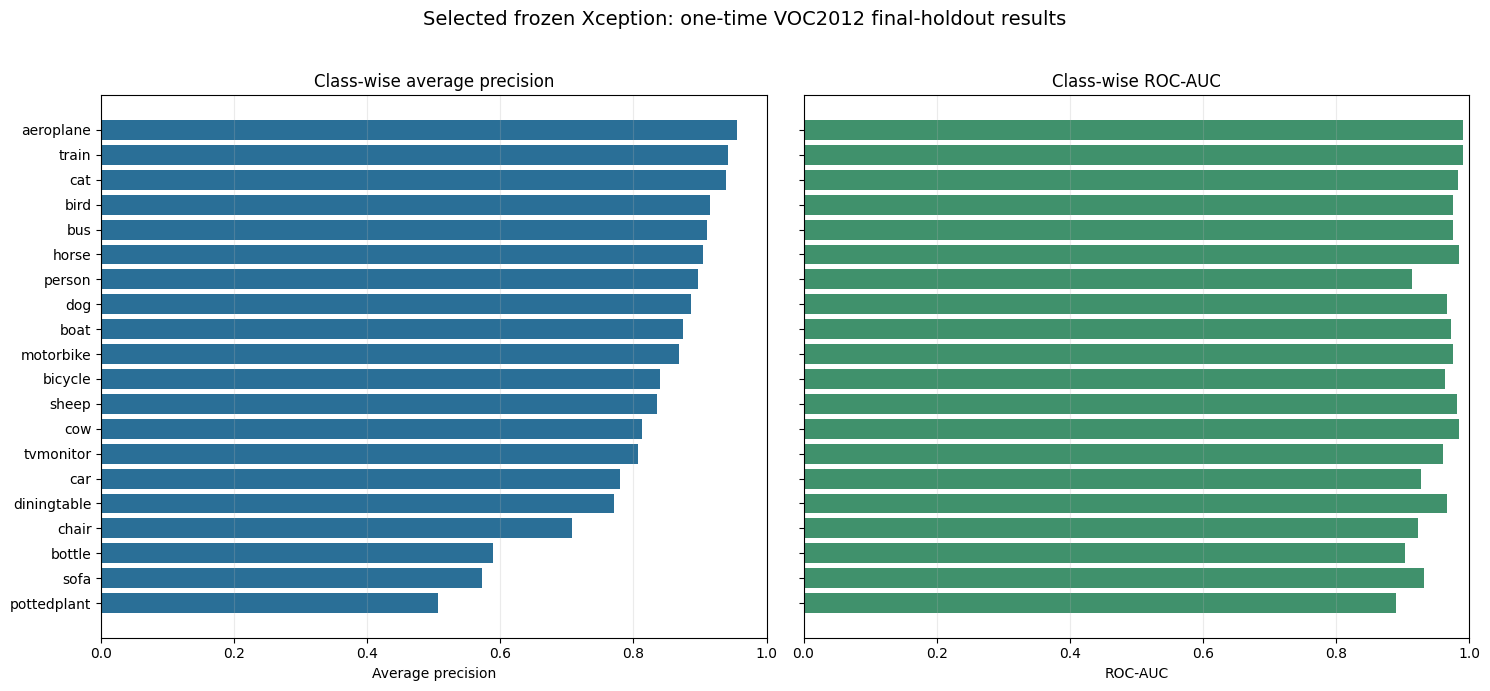

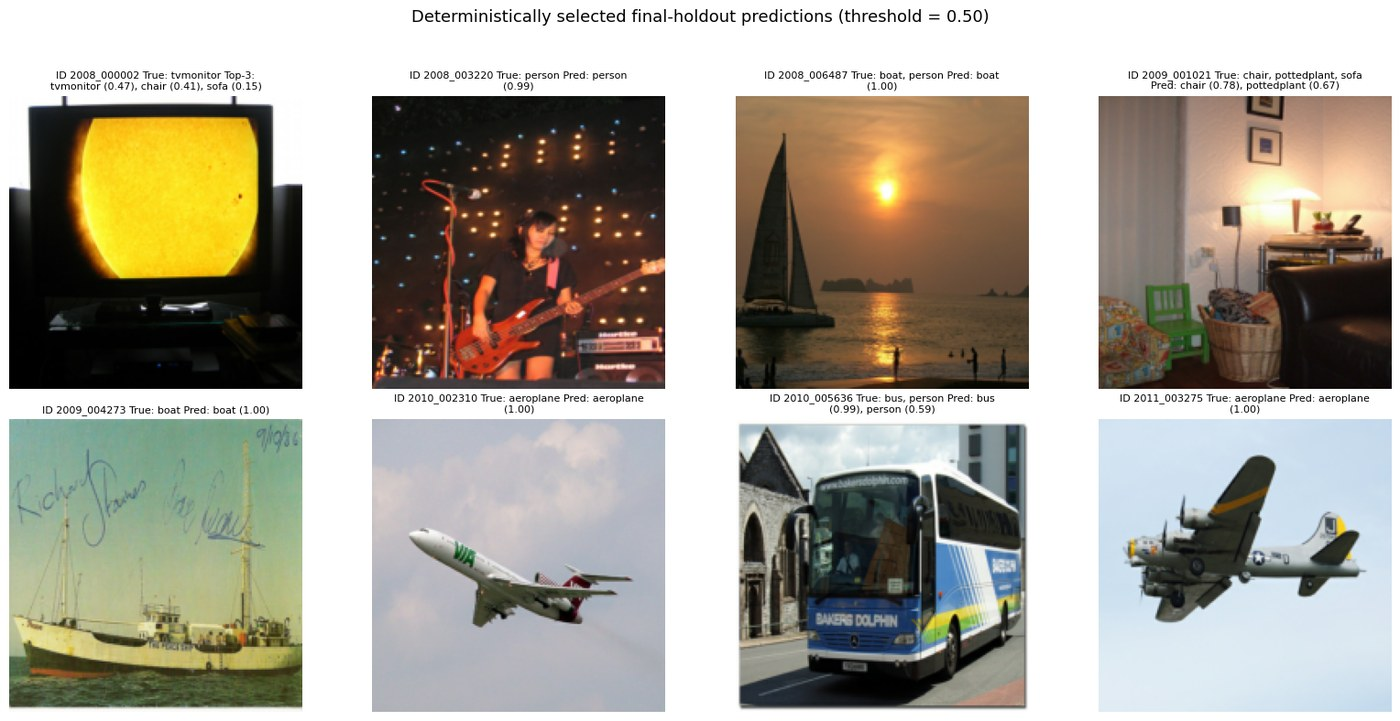


=== One-time final-holdout evaluation ===
Selected candidate: 2_extended_frozen
Final-holdout images: 5,823
Final-holdout batches: 182
Inference time: 34.1 seconds
bce: 0.09539
binary_accuracy: 0.96698
roc_auc: 0.95471
pr_auc: 0.81444

=== Supplementary fixed-threshold metrics ===
macro_average_precision: 0.81558
micro_average_precision: 0.84331
micro_precision_at_0_5: 0.86634
micro_recall_at_0_5: 0.66893
micro_f1_at_0_5: 0.75494
macro_f1_at_0_5: 0.74254
hamming_loss_at_0_5: 0.03302
exact_match_ratio_at_0_5: 0.54783

=== Final holdout minus internal validation ===
predictive_bce: -0.00482 (lower is better)
binary_accuracy: +0.00127 (higher is better)
roc_auc: +0.00403 (higher is better)
pr_auc: +0.00958 (higher is better)

=== Five strongest classes by average precision ===
    class  support  average_precision  roc_auc  f1_at_0_5
aeroplane      348            0.95553  0.99141    0.91190
    train      275            0.94268  0.99097    0.86406
      cat      544            0.93869  0

In [ ]:
#Step 09: evaluate the selected classifier on the final holdout exactly once.


import hashlib
import json
import math
import textwrap
import time
from datetime import datetime, timezone
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    hamming_loss,
    precision_recall_fscore_support,
    roc_auc_score,
)


# ---------------------------------------------------------------------------
# 1. Validate the locked Step 08 selection and the notebook state
# ---------------------------------------------------------------------------
required_objects = (
    "OUTPUT_DIR",
    "N_CLASSES",
    "VOC_CLASSES",
    "CLASSIFICATION_IMAGE_SIZE",
    "CLASSIFICATION_BATCH_SIZE",
    "test_ds",
    "test_ids",
    "test_labels",
)
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run Steps 01--08 before this cell. Missing objects: "
        + ", ".join(missing_objects)
    )

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

selection_path = OUTPUT_DIR / "step08_global_classification_selection.json"
candidate_comparison_path = (
    OUTPUT_DIR / "step08_all_classification_candidates.csv"
)

prediction_cache_path = OUTPUT_DIR / "step09_final_holdout_predictions.npz"
evaluation_guard_path = OUTPUT_DIR / "step09_FINAL_HOLDOUT_EVALUATION.lock"
final_record_path = OUTPUT_DIR / "step09_final_holdout_evaluation.json"
comparison_output_path = (
    OUTPUT_DIR / "step09_internal_validation_vs_final_holdout.csv"
)
per_class_output_path = OUTPUT_DIR / "step09_final_holdout_per_class.csv"
class_figure_path = OUTPUT_DIR / "step09_final_holdout_class_metrics.png"
qualitative_figure_path = (
    OUTPUT_DIR / "step09_final_holdout_prediction_examples.png"
)

if final_record_path.exists():
    raise RuntimeError(
        "Step 09 has already completed. The final holdout must not be "
        "evaluated again. Use the saved Step 09 artifacts for reporting."
    )

if not selection_path.exists() or not candidate_comparison_path.exists():
    raise FileNotFoundError(
        "Step 08 selection artifacts are missing. Complete Step 08 first."
    )

with selection_path.open("r", encoding="utf-8") as file:
    selection_record = json.load(file)

candidate_comparison = pd.read_csv(candidate_comparison_path)
selected_mask = (
    candidate_comparison["selected_by_internal_val_bce"]
    .astype(str)
    .str.lower()
    .eq("true")
)
selected_rows = candidate_comparison.loc[selected_mask]
if len(selected_rows) != 1:
    raise RuntimeError(
        "Step 08 comparison must identify exactly one selected classifier."
    )

selected_row = selected_rows.iloc[0]
selected_candidate = str(selection_record["selected_candidate"])
selected_family = str(selection_record["selected_family"])
selected_model_input = str(selection_record["selected_model_input"])
selected_checkpoint = Path(selection_record["selected_checkpoint"])
internal_validation_metrics = selection_record[
    "selected_internal_validation_metrics"
]

if bool(selection_record.get("final_holdout_used", True)):
    raise RuntimeError(
        "The Step 08 record does not certify an untouched final holdout."
    )
if selected_candidate != str(selected_row["candidate"]):
    raise RuntimeError("Step 08 selection JSON and comparison CSV disagree.")
if selected_family != str(selected_row["family"]):
    raise RuntimeError("Selected model-family records disagree.")
if selected_model_input != "images":
    raise RuntimeError(
        "The globally selected checkpoint is not an image-input model."
    )
if selected_candidate != "2_extended_frozen":
    raise RuntimeError(
        "Expected Step 08 to select 2_extended_frozen, but found: "
        f"{selected_candidate}. Stop and review the Step 08 output."
    )
if not selected_checkpoint.exists():
    raise FileNotFoundError(
        f"Selected Step 08 checkpoint is missing: {selected_checkpoint}"
    )

test_ids_array = np.asarray(test_ids).astype(str)
test_labels_array = np.asarray(test_labels, dtype=np.float32)
expected_holdout_size = len(test_ids_array)
expected_holdout_batches = math.ceil(
    expected_holdout_size / int(CLASSIFICATION_BATCH_SIZE)
)

if test_labels_array.shape != (expected_holdout_size, N_CLASSES):
    raise RuntimeError("Final-holdout label array has an unexpected shape.")
if len(set(test_ids_array.tolist())) != expected_holdout_size:
    raise RuntimeError("Duplicate final-holdout image IDs were found.")
if not np.all(test_labels_array.sum(axis=0) > 0):
    raise RuntimeError("At least one class is absent from the final holdout.")


def sha256_file(file_path, chunk_size=1024 * 1024):
    """Return a reproducible fingerprint for the locked model checkpoint."""

    digest = hashlib.sha256()
    with Path(file_path).open("rb") as file:
        while True:
            chunk = file.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


checkpoint_sha256 = sha256_file(selected_checkpoint)


# ---------------------------------------------------------------------------
# 2. Make one model pass over the holdout
# ---------------------------------------------------------------------------
sample_count = min(8, expected_holdout_size)
sample_indices = np.linspace(
    0,
    expected_holdout_size - 1,
    num=sample_count,
    dtype=int,
)

loaded_from_prediction_cache = prediction_cache_path.exists()
evaluation_started_at = None
evaluation_seconds = None
observed_holdout_batches = None

if loaded_from_prediction_cache:
    with np.load(prediction_cache_path, allow_pickle=False) as cache:
        final_y_true = cache["y_true"].astype(np.float32)
        final_y_probability = cache["y_probability"].astype(np.float32)
        cached_test_ids = cache["test_ids"].astype(str)
        cached_class_names = cache["class_names"].astype(str)
        cached_checkpoint_sha256 = str(cache["checkpoint_sha256"].item())
        sample_indices = cache["sample_indices"].astype(int)
        sampled_images = cache["sampled_images"].astype(np.uint8)
        evaluation_seconds = float(cache["evaluation_seconds"].item())
        observed_holdout_batches = int(cache["observed_batches"].item())

    if not np.array_equal(cached_test_ids, test_ids_array):
        raise RuntimeError("Cached prediction IDs do not match the holdout IDs.")
    if not np.array_equal(cached_class_names, np.asarray(VOC_CLASSES)):
        raise RuntimeError("Cached class ordering does not match VOC_CLASSES.")
    if cached_checkpoint_sha256 != checkpoint_sha256:
        raise RuntimeError(
            "The selected checkpoint differs from the one used to create "
            "the cached final-holdout predictions."
        )
    print(
        "Recovered the completed one-time prediction pass from cache; "
        "the final-holdout images will not be passed through the model again."
    )

else:
    if evaluation_guard_path.exists():
        raise RuntimeError(
            "A previous Step 09 run began but did not create a complete "
            "prediction cache. Do not re-evaluate the final holdout. Inspect "
            "the earlier error and the lock file before taking any action."
        )

    selected_model = keras.models.load_model(
        selected_checkpoint,
        compile=False,
    )
    if selected_model.input_shape != (
        None,
        *CLASSIFICATION_IMAGE_SIZE,
        3,
    ):
        raise RuntimeError(
            f"Unexpected selected-model input shape: {selected_model.input_shape}"
        )
    if selected_model.output_shape != (None, N_CLASSES):
        raise RuntimeError(
            f"Unexpected selected-model output shape: {selected_model.output_shape}"
        )

    evaluation_started_at = datetime.now(timezone.utc).isoformat()
    guard_record = {
        "status": "started",
        "started_at_utc": evaluation_started_at,
        "selected_candidate": selected_candidate,
        "selected_checkpoint": str(selected_checkpoint),
        "selected_checkpoint_sha256": checkpoint_sha256,
        "policy": "one selected model; one sequential final-holdout pass",
    }
    evaluation_guard_path.write_text(
        json.dumps(guard_record, indent=2),
        encoding="utf-8",
    )

    print("=== Step 09 pre-evaluation lock ===")
    print(f"Selected candidate: {selected_candidate}")
    print(f"Selected family: {selected_family}")
    print(f"Selected checkpoint: {selected_checkpoint}")
    print(f"Checkpoint SHA-256: {checkpoint_sha256}")
    print("Selection source: internal-validation predictive BCE only")
    print("Decision threshold: fixed at 0.50 (no holdout tuning)")
    print(f"Expected holdout images: {expected_holdout_size:,}")
    print(f"Expected holdout batches: {expected_holdout_batches:,}")
    print("FINAL HOLDOUT ACCESS NOW BEGINS: do not interrupt this cell.")

    true_batches = []
    probability_batches = []
    sampled_images = np.empty(
        (sample_count, *CLASSIFICATION_IMAGE_SIZE, 3),
        dtype=np.uint8,
    )
    sample_slot_by_index = {
        int(global_index): slot
        for slot, global_index in enumerate(sample_indices)
    }
    captured_sample_slots = set()
    global_offset = 0
    observed_holdout_batches = 0
    evaluation_start_clock = time.perf_counter()

    # This is the only traversal of test_ds in the entire model-development
    # workflow. We deliberately do not call model.evaluate() and model.predict()
    # separately, which would expose the holdout twice.
    for batch_number, (batch_images, batch_labels) in enumerate(
        test_ds,
        start=1,
    ):
        batch_probabilities = selected_model(
            batch_images,
            training=False,
        ).numpy()

        batch_labels_numpy = batch_labels.numpy().astype(np.float32)
        batch_probabilities = np.asarray(
            batch_probabilities,
            dtype=np.float32,
        )

        if batch_probabilities.shape != batch_labels_numpy.shape:
            raise RuntimeError(
                "Prediction and label shapes disagree in final-holdout batch "
                f"{batch_number}."
            )
        if not np.isfinite(batch_probabilities).all():
            raise RuntimeError("Non-finite final-holdout predictions found.")
        if np.any(batch_probabilities < 0.0) or np.any(
            batch_probabilities > 1.0
        ):
            raise RuntimeError("Predicted probabilities fall outside [0, 1].")

        true_batches.append(batch_labels_numpy)
        probability_batches.append(batch_probabilities)

        batch_size = len(batch_labels_numpy)
        for global_index in range(global_offset, global_offset + batch_size):
            if global_index in sample_slot_by_index:
                local_index = global_index - global_offset
                slot = sample_slot_by_index[global_index]
                sampled_images[slot] = np.clip(
                    batch_images[local_index].numpy(),
                    0.0,
                    255.0,
                ).astype(np.uint8)
                captured_sample_slots.add(slot)

        global_offset += batch_size
        observed_holdout_batches = batch_number
        if batch_number % 50 == 0:
            print(f"  processed {batch_number} holdout batches")

    evaluation_seconds = time.perf_counter() - evaluation_start_clock
    final_y_true = np.concatenate(true_batches, axis=0)
    final_y_probability = np.concatenate(probability_batches, axis=0)

    if captured_sample_slots != set(range(sample_count)):
        raise RuntimeError("Not all deterministic display examples were captured.")
    if global_offset != expected_holdout_size:
        raise RuntimeError(
            f"Expected {expected_holdout_size} holdout rows, observed {global_offset}."
        )
    if observed_holdout_batches != expected_holdout_batches:
        raise RuntimeError(
            "Observed final-holdout batch count differs from the expected count."
        )
    if not np.array_equal(final_y_true, test_labels_array):
        raise RuntimeError(
            "Final-holdout label order does not match test_ids/test_labels."
        )

    # Cache immediately after the single complete model pass. All remaining
    # calculations operate only on these arrays, never on test_ds.
    np.savez_compressed(
        prediction_cache_path,
        y_true=final_y_true,
        y_probability=final_y_probability,
        test_ids=test_ids_array,
        class_names=np.asarray(VOC_CLASSES),
        checkpoint_sha256=np.asarray(checkpoint_sha256),
        sample_indices=sample_indices,
        sampled_images=sampled_images,
        evaluation_seconds=np.asarray(evaluation_seconds),
        observed_batches=np.asarray(observed_holdout_batches),
    )

    guard_record.update(
        {
            "status": "predictions_cached",
            "completed_model_pass_at_utc": datetime.now(
                timezone.utc
            ).isoformat(),
            "observed_images": int(len(final_y_true)),
            "observed_batches": int(observed_holdout_batches),
            "prediction_cache": str(prediction_cache_path),
        }
    )
    evaluation_guard_path.write_text(
        json.dumps(guard_record, indent=2),
        encoding="utf-8",
    )

    del selected_model, true_batches, probability_batches
    keras.backend.clear_session()


# Validate cached or newly created arrays before calculating any result.
if final_y_true.shape != (expected_holdout_size, N_CLASSES):
    raise RuntimeError("Final-holdout targets have an unexpected shape.")
if final_y_probability.shape != (expected_holdout_size, N_CLASSES):
    raise RuntimeError("Final-holdout predictions have an unexpected shape.")
if not np.array_equal(final_y_true, test_labels_array):
    raise RuntimeError("Final-holdout target alignment check failed.")
if not np.isfinite(final_y_probability).all():
    raise RuntimeError("Final-holdout prediction cache contains non-finite values.")
if np.any(final_y_probability < 0.0) or np.any(
    final_y_probability > 1.0
):
    raise RuntimeError("Cached probabilities fall outside [0, 1].")


# ---------------------------------------------------------------------------
# 3. Calculate locked
# ---------------------------------------------------------------------------
DECISION_THRESHOLD = 0.50
final_y_predicted = (final_y_probability >= DECISION_THRESHOLD).astype(np.int8)
final_y_true_int = final_y_true.astype(np.int8)


def keras_metric_value(metric):
    """Calculate a metric using the same definition as Steps 04--08."""

    metric.update_state(final_y_true, final_y_probability)
    value = float(metric.result().numpy())
    metric.reset_state()
    return value


comparable_final_metrics = {
    "bce": keras_metric_value(keras.metrics.BinaryCrossentropy()),
    "binary_accuracy": keras_metric_value(
        keras.metrics.BinaryAccuracy(threshold=DECISION_THRESHOLD)
    ),
    "roc_auc": keras_metric_value(
        keras.metrics.AUC(
            curve="ROC",
            multi_label=True,
            num_labels=N_CLASSES,
        )
    ),
    "pr_auc": keras_metric_value(
        keras.metrics.AUC(
            curve="PR",
            multi_label=True,
            num_labels=N_CLASSES,
        )
    ),
}

micro_precision, micro_recall, micro_f1, _ = (
    precision_recall_fscore_support(
        final_y_true_int,
        final_y_predicted,
        average="micro",
        zero_division=0,
    )
)
macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        final_y_true_int,
        final_y_predicted,
        average="macro",
        zero_division=0,
    )
)
sample_precision, sample_recall, sample_f1, _ = (
    precision_recall_fscore_support(
        final_y_true_int,
        final_y_predicted,
        average="samples",
        zero_division=0,
    )
)

supplementary_final_metrics = {
    "decision_threshold": DECISION_THRESHOLD,
    "exact_macro_roc_auc": float(
        roc_auc_score(
            final_y_true_int,
            final_y_probability,
            average="macro",
        )
    ),
    "macro_average_precision": float(
        average_precision_score(
            final_y_true_int,
            final_y_probability,
            average="macro",
        )
    ),
    "micro_average_precision": float(
        average_precision_score(
            final_y_true_int,
            final_y_probability,
            average="micro",
        )
    ),
    "micro_precision_at_0_5": float(micro_precision),
    "micro_recall_at_0_5": float(micro_recall),
    "micro_f1_at_0_5": float(micro_f1),
    "macro_precision_at_0_5": float(macro_precision),
    "macro_recall_at_0_5": float(macro_recall),
    "macro_f1_at_0_5": float(macro_f1),
    "sample_precision_at_0_5": float(sample_precision),
    "sample_recall_at_0_5": float(sample_recall),
    "sample_f1_at_0_5": float(sample_f1),
    "hamming_loss_at_0_5": float(
        hamming_loss(final_y_true_int, final_y_predicted)
    ),
    "exact_match_ratio_at_0_5": float(
        accuracy_score(final_y_true_int, final_y_predicted)
    ),
}

class_precision, class_recall, class_f1, class_support = (
    precision_recall_fscore_support(
        final_y_true_int,
        final_y_predicted,
        average=None,
        zero_division=0,
    )
)

per_class_records = []
for class_index, class_name in enumerate(VOC_CLASSES):
    class_true = final_y_true_int[:, class_index]
    class_probability = final_y_probability[:, class_index]
    class_prediction = final_y_predicted[:, class_index]

    per_class_records.append(
        {
            "class": class_name,
            "support": int(class_support[class_index]),
            "prevalence": float(class_true.mean()),
            "predicted_positive_rate_at_0_5": float(class_prediction.mean()),
            "precision_at_0_5": float(class_precision[class_index]),
            "recall_at_0_5": float(class_recall[class_index]),
            "f1_at_0_5": float(class_f1[class_index]),
            "roc_auc": float(roc_auc_score(class_true, class_probability)),
            "average_precision": float(
                average_precision_score(class_true, class_probability)
            ),
        }
    )

per_class_metrics = pd.DataFrame(per_class_records)
per_class_metrics.to_csv(per_class_output_path, index=False)

validation_holdout_comparison = pd.DataFrame(
    [
        {
            "split": "internal_validation",
            "n_images": int(len(val_ids)) if "val_ids" in globals() else np.nan,
            "predictive_bce": float(internal_validation_metrics["bce"]),
            "binary_accuracy": float(
                internal_validation_metrics["binary_accuracy"]
            ),
            "roc_auc": float(internal_validation_metrics["roc_auc"]),
            "pr_auc": float(internal_validation_metrics["pr_auc"]),
        },
        {
            "split": "final_holdout",
            "n_images": int(expected_holdout_size),
            "predictive_bce": comparable_final_metrics["bce"],
            "binary_accuracy": comparable_final_metrics["binary_accuracy"],
            "roc_auc": comparable_final_metrics["roc_auc"],
            "pr_auc": comparable_final_metrics["pr_auc"],
        },
    ]
)
validation_holdout_comparison.to_csv(comparison_output_path, index=False)

generalization_deltas = {
    metric_name: (
        comparable_final_metrics[final_name]
        - float(internal_validation_metrics[validation_name])
    )
    for metric_name, final_name, validation_name in (
        ("predictive_bce", "bce", "bce"),
        ("binary_accuracy", "binary_accuracy", "binary_accuracy"),
        ("roc_auc", "roc_auc", "roc_auc"),
        ("pr_auc", "pr_auc", "pr_auc"),
    )
}


# ---------------------------------------------------------------------------
# 4. Create bounded figures 
# ---------------------------------------------------------------------------
plot_frame = per_class_metrics.sort_values(
    "average_precision",
    ascending=True,
).reset_index(drop=True)
plot_positions = np.arange(len(plot_frame))

figure, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
axes[0].barh(
    plot_positions,
    plot_frame["average_precision"],
    color="#2a6f97",
)
axes[0].set_xlabel("Average precision")
axes[0].set_title("Class-wise average precision")
axes[0].set_xlim(0.0, 1.0)

axes[1].barh(
    plot_positions,
    plot_frame["roc_auc"],
    color="#40916c",
)
axes[1].set_xlabel("ROC-AUC")
axes[1].set_title("Class-wise ROC-AUC")
axes[1].set_xlim(0.0, 1.0)

axes[0].set_yticks(plot_positions)
axes[0].set_yticklabels(plot_frame["class"])
for axis in axes:
    axis.grid(axis="x", alpha=0.25)

figure.suptitle(
    "Selected frozen Xception: one-time VOC2012 final-holdout results",
    fontsize=14,
)
figure.tight_layout(rect=(0, 0, 1, 0.96))
figure.savefig(class_figure_path, dpi=180, bbox_inches="tight")
plt.show()


figure, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = np.asarray(axes).reshape(-1)

for slot, axis in enumerate(axes):
    if slot >= sample_count:
        axis.axis("off")
        continue

    sample_index = int(sample_indices[slot])
    true_indices = np.flatnonzero(final_y_true_int[sample_index] == 1)
    predicted_indices = np.flatnonzero(
        final_y_predicted[sample_index] == 1
    )
    true_names = [VOC_CLASSES[index] for index in true_indices]

    if len(predicted_indices) == 0:
        predicted_indices = np.argsort(
            final_y_probability[sample_index]
        )[-3:][::-1]
        prediction_prefix = "Top-3"
    else:
        predicted_indices = predicted_indices[
            np.argsort(
                final_y_probability[sample_index, predicted_indices]
            )[::-1]
        ]
        prediction_prefix = "Pred"

    predicted_text = ", ".join(
        f"{VOC_CLASSES[index]} "
        f"({final_y_probability[sample_index, index]:.2f})"
        for index in predicted_indices[:4]
    )
    title = (
        f"ID {test_ids_array[sample_index]}\n"
        f"True: {', '.join(true_names)}\n"
        f"{prediction_prefix}: {predicted_text}"
    )

    axis.imshow(sampled_images[slot])
    axis.set_title(textwrap.fill(title, width=46), fontsize=8)
    axis.axis("off")

figure.suptitle(
    "Deterministically selected final-holdout predictions (threshold = 0.50)",
    fontsize=13,
)
figure.tight_layout(rect=(0, 0, 1, 0.95))
figure.savefig(qualitative_figure_path, dpi=180, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------------
# 5. Save the immutable final result and lock classification development
# ---------------------------------------------------------------------------
final_evaluation_record = {
    "status": "completed_and_classification_locked",
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "selected_candidate": selected_candidate,
    "selected_family": selected_family,
    "selection_metric": selection_record["selection_metric"],
    "selected_checkpoint": str(selected_checkpoint),
    "selected_checkpoint_sha256": checkpoint_sha256,
    "selection_used_final_holdout": False,
    "final_holdout_policy": {
        "model_count_evaluated": 1,
        "dataset_traversals_for_inference": 1,
        "threshold": DECISION_THRESHOLD,
        "threshold_selected_on_holdout": False,
        "model_or_epoch_selected_on_holdout": False,
        "loaded_from_prediction_cache_during_this_run": bool(
            loaded_from_prediction_cache
        ),
    },
    "final_holdout": {
        "source": "official PASCAL VOC2012 validation split",
        "notebook_variable": "test_ds",
        "n_images": int(expected_holdout_size),
        "n_batches": int(observed_holdout_batches),
        "inference_seconds": float(evaluation_seconds),
    },
    "internal_validation_metrics_at_selection": {
        key: float(value)
        for key, value in internal_validation_metrics.items()
    },
    "final_holdout_metrics_comparable_to_steps_04_08": (
        comparable_final_metrics
    ),
    "supplementary_final_holdout_metrics": supplementary_final_metrics,
    "final_minus_internal_validation": generalization_deltas,
    "artifacts": {
        "prediction_cache": str(prediction_cache_path),
        "validation_holdout_comparison": str(comparison_output_path),
        "per_class_metrics": str(per_class_output_path),
        "class_metrics_figure": str(class_figure_path),
        "qualitative_predictions_figure": str(qualitative_figure_path),
        "evaluation_guard": str(evaluation_guard_path),
    },
}

with final_record_path.open("x", encoding="utf-8") as file:
    json.dump(final_evaluation_record, file, indent=2)

guard_record = {
    "status": "completed_and_locked",
    "completed_at_utc": final_evaluation_record["completed_at_utc"],
    "selected_candidate": selected_candidate,
    "selected_checkpoint": str(selected_checkpoint),
    "selected_checkpoint_sha256": checkpoint_sha256,
    "observed_images": int(expected_holdout_size),
    "observed_batches": int(observed_holdout_batches),
    "prediction_cache": str(prediction_cache_path),
    "final_record": str(final_record_path),
    "instruction": "Do not evaluate any classifier on test_ds again.",
}
evaluation_guard_path.write_text(
    json.dumps(guard_record, indent=2),
    encoding="utf-8",
)

print("\n=== One-time final-holdout evaluation ===")
print(f"Selected candidate: {selected_candidate}")
print(f"Final-holdout images: {expected_holdout_size:,}")
print(f"Final-holdout batches: {observed_holdout_batches:,}")
print(f"Inference time: {evaluation_seconds:.1f} seconds")
for metric_name, metric_value in comparable_final_metrics.items():
    print(f"{metric_name}: {metric_value:.5f}")

print("\n=== Supplementary fixed-threshold metrics ===")
for metric_name in (
    "macro_average_precision",
    "micro_average_precision",
    "micro_precision_at_0_5",
    "micro_recall_at_0_5",
    "micro_f1_at_0_5",
    "macro_f1_at_0_5",
    "hamming_loss_at_0_5",
    "exact_match_ratio_at_0_5",
):
    print(
        f"{metric_name}: "
        f"{supplementary_final_metrics[metric_name]:.5f}"
    )

print("\n=== Final holdout minus internal validation ===")
for metric_name, delta in generalization_deltas.items():
    direction = "lower is better" if metric_name == "predictive_bce" else (
        "higher is better"
    )
    print(f"{metric_name}: {delta:+.5f} ({direction})")

print("\n=== Five strongest classes by average precision ===")
print(
    per_class_metrics.nlargest(5, "average_precision")[
        ["class", "support", "average_precision", "roc_auc", "f1_at_0_5"]
    ].to_string(index=False, float_format=lambda value: f"{value:.5f}")
)

print("\n=== Five weakest classes by average precision ===")
print(
    per_class_metrics.nsmallest(5, "average_precision")[
        ["class", "support", "average_precision", "roc_auc", "f1_at_0_5"]
    ].to_string(index=False, float_format=lambda value: f"{value:.5f}")
)

print(f"\nSaved prediction cache: {prediction_cache_path}")
print(f"Saved final evaluation: {final_record_path}")
print(f"Saved validation/holdout comparison: {comparison_output_path}")
print(f"Saved per-class metrics: {per_class_output_path}")
print(f"Saved class metrics figure: {class_figure_path}")
print(f"Saved qualitative predictions: {qualitative_figure_path}")
print("FINAL HOLDOUT EVALUATED: exactly one selected model, one model pass.")
print("CLASSIFICATION PART IS NOW LOCKED: do not tune or compare models again.")


### Final classification interpretation

The locked frozen-Xception classifier was evaluated once on 5,823 holdout images at the fixed 0.50 threshold. It achieved BCE 0.09539, binary accuracy 0.96698, ROC-AUC 0.95471, and PR-AUC 0.81444; the small validation-to-holdout changes support stable generalisation. At threshold 0.50, micro-F1 was 0.75494 and exact-match accuracy was 0.54783, the latter being deliberately strict because every label for an image must be correct.

Performance varied by class. Aeroplane, train, cat, bird, and bus had the strongest average precision, whereas potted plant, sofa, bottle, chair, and dining table were weaker. The qualitative predictions and per-class figure should therefore be read alongside the aggregate metrics rather than treating the single overall accuracy as a complete description.


# 2. Image segmentation

## Preprocessing


### Step 10 — Preprocessing, mask inspection and split audit

=== Step 10 segmentation protocol ===
Task: binary semantic segmentation (background versus object)
Raw mask values 1--20: merged into foreground class 1
Raw mask value 0: background class 0
Raw mask value 255: ignored with zero pixel weight
Image/mask size: (128, 128)
Batch size: 16
Final segmentation holdout: official VOC segmentation val split

=== Source image/mask integrity ===
Official segmentation train pool: 1,464
Official segmentation final holdout: 1,449
Audited JPEG/PNG pairs: 2,913
Missing JPEGs: 0
Missing PNG masks: 0
Dimension mismatches: 0
Masks with invalid values: 0
Masks with no foreground: 0

=== Leakage-safe segmentation split ===
              split  n_images  mean_foreground_%_valid  median_foreground_%_valid  mean_void_%  mean_semantic_classes_per_mask
              train      1171                   26.998                     21.890        5.518                           1.482
internal_validation       293                   27.693                     23.811      

2026-08-02 15:26:18.508794: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}



=== Segmentation pipeline probe (training only) ===
Images: (16, 128, 128, 3), dtype=float32
Masks: (16, 128, 128, 1), values=[0.0, 1.0]
Pixel weights: (16, 128, 128, 1), values=[0.0, 1.0]
Image range: [0.0000, 1.0000]
Valid pixels in probe batch: 91.77%


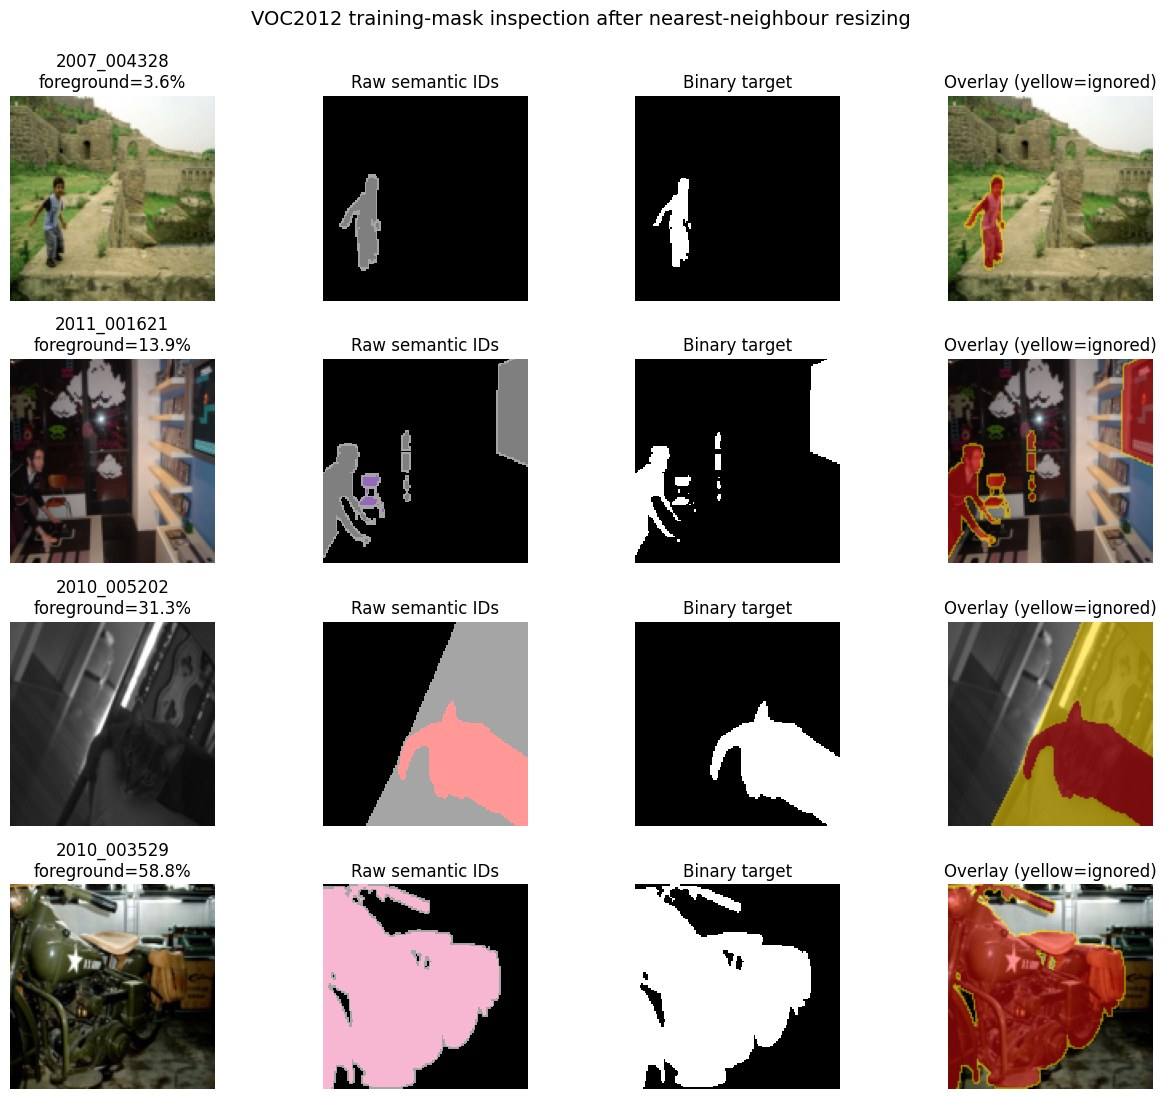

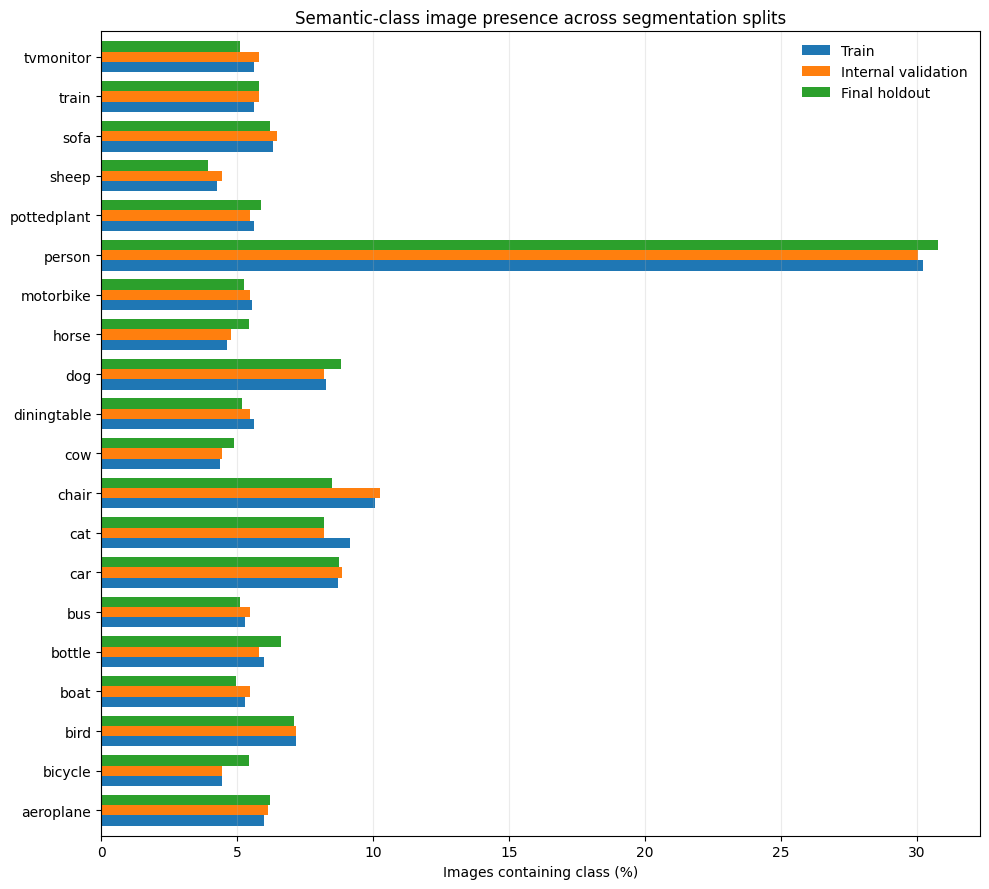


=== Saved Step 10 artifacts ===
Mask audit: /kaggle/working/anndl_outputs/step10_segmentation_mask_audit.csv
Split summary: /kaggle/working/anndl_outputs/step10_segmentation_split_summary.csv
Class presence: /kaggle/working/anndl_outputs/step10_segmentation_class_presence.csv
Split assignment: /kaggle/working/anndl_outputs/step10_segmentation_split_assignment.csv
Split record: /kaggle/working/anndl_outputs/step10_segmentation_split_record.json
Mask-inspection figure: /kaggle/working/anndl_outputs/step10_segmentation_mask_examples.png
Class-presence figure: /kaggle/working/anndl_outputs/step10_segmentation_class_presence.png
SEGMENTATION DATA AUDIT PASSED: image/mask pairs and splits are valid.
FINAL SEGMENTATION HOLDOUT IS RESERVED: no model has traversed seg_test_ds.


In [ ]:
#Step 10: preprocess VOC2012 segmentation data and audit masks/splits

from pathlib import Path
import hashlib
import json

from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import tensorflow as tf


# ---------------------------------------------------------------------------
# 1. Validate the notebook state and lock the segmentation protocol
# ---------------------------------------------------------------------------
required_objects = (
    "SEED",
    "VOC_ROOT",
    "OUTPUT_DIR",
    "VOC_CLASSES",
    "iterative_multilabel_train_val_split",
)
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run Steps 01--09 before this cell. Missing objects: "
        + ", ".join(missing_objects)
    )

VOC_ROOT = Path(VOC_ROOT)
OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEGMENTATION_IMAGE_SIZE = (128, 128)
SEGMENTATION_BATCH_SIZE = 16
SEGMENTATION_INTERNAL_VAL_FRACTION = 0.20
SEGMENTATION_N_SEMANTIC_CLASSES = 20
SEGMENTATION_VOID_VALUE = 255

print("=== Step 10 segmentation protocol ===")
print("Task: binary semantic segmentation (background versus object)")
print("Raw mask values 1--20: merged into foreground class 1")
print("Raw mask value 0: background class 0")
print("Raw mask value 255: ignored with zero pixel weight")
print(f"Image/mask size: {SEGMENTATION_IMAGE_SIZE}")
print(f"Batch size: {SEGMENTATION_BATCH_SIZE}")
print("Final segmentation holdout: official VOC segmentation val split")


# ---------------------------------------------------------------------------
# 2. Read official IDs and verify the image--mask pairing contract
# ---------------------------------------------------------------------------
def read_segmentation_ids(file_path):
    """Read non-empty VOC image identifiers without filename suffixes."""
    file_path = Path(file_path)
    if not file_path.is_file():
        raise FileNotFoundError(f"Required split file is missing: {file_path}")
    return [line.split()[0] for line in file_path.read_text().splitlines() if line.strip()]


segmentation_split_dir = VOC_ROOT / "ImageSets" / "Segmentation"
official_seg_train_ids = read_segmentation_ids(segmentation_split_dir / "train.txt")
official_seg_holdout_ids = read_segmentation_ids(segmentation_split_dir / "val.txt")
official_seg_trainval_ids = read_segmentation_ids(
    segmentation_split_dir / "trainval.txt"
)

assert len(official_seg_train_ids) == len(set(official_seg_train_ids)), (
    "Duplicate IDs exist in the official segmentation train split."
)
assert len(official_seg_holdout_ids) == len(set(official_seg_holdout_ids)), (
    "Duplicate IDs exist in the official segmentation val split."
)
assert len(official_seg_trainval_ids) == len(set(official_seg_trainval_ids)), (
    "Duplicate IDs exist in the official segmentation trainval split."
)
assert set(official_seg_train_ids).isdisjoint(official_seg_holdout_ids), (
    "Official segmentation train/val overlap found."
)
assert set(official_seg_trainval_ids) == (
    set(official_seg_train_ids) | set(official_seg_holdout_ids)
), "The official trainval IDs are not exactly train union val."

available_segmentation_mask_ids = {
    path.stem for path in (VOC_ROOT / "SegmentationClass").glob("*.png")
}
assert available_segmentation_mask_ids == set(official_seg_trainval_ids), (
    "SegmentationClass PNG files do not exactly match the official trainval IDs."
)


# ---------------------------------------------------------------------------
# 3. Inspect every source pair before resizing or target conversion
# ---------------------------------------------------------------------------
allowed_raw_values = set(range(SEGMENTATION_N_SEMANTIC_CLASSES + 1)) | {
    SEGMENTATION_VOID_VALUE
}
segmentation_audit_rows = []
segmentation_presence_by_id = {}
invalid_mask_values_by_id = {}
missing_image_ids = []
missing_mask_ids = []
dimension_mismatch_ids = []
empty_valid_region_ids = []
empty_foreground_ids = []


def inspect_segmentation_pair(image_id, official_split):
    """Return source-level integrity and pixel-composition statistics."""
    image_path = VOC_ROOT / "JPEGImages" / f"{image_id}.jpg"
    mask_path = VOC_ROOT / "SegmentationClass" / f"{image_id}.png"

    if not image_path.is_file():
        missing_image_ids.append(image_id)
        return
    if not mask_path.is_file():
        missing_mask_ids.append(image_id)
        return

    with Image.open(image_path) as image:
        image_width, image_height = image.size
    with Image.open(mask_path) as mask_image:
        mask_array = np.asarray(mask_image, dtype=np.uint8)

    if mask_array.ndim != 2:
        raise ValueError(
            f"Mask {image_id} has shape {mask_array.shape}; expected a 2D indexed PNG."
        )

    mask_height, mask_width = mask_array.shape
    if (image_width, image_height) != (mask_width, mask_height):
        dimension_mismatch_ids.append(image_id)

    raw_values = set(np.unique(mask_array).astype(int).tolist())
    invalid_values = sorted(raw_values - allowed_raw_values)
    if invalid_values:
        invalid_mask_values_by_id[image_id] = invalid_values

    valid_pixels = mask_array != SEGMENTATION_VOID_VALUE
    foreground_pixels = (
        (mask_array >= 1)
        & (mask_array <= SEGMENTATION_N_SEMANTIC_CLASSES)
    )
    valid_pixel_count = int(valid_pixels.sum())
    foreground_pixel_count = int(foreground_pixels.sum())
    total_pixel_count = int(mask_array.size)

    if valid_pixel_count == 0:
        empty_valid_region_ids.append(image_id)
    if foreground_pixel_count == 0:
        empty_foreground_ids.append(image_id)

    present_class_ids = sorted(
        value
        for value in raw_values
        if 1 <= value <= SEGMENTATION_N_SEMANTIC_CLASSES
    )
    presence = np.zeros(SEGMENTATION_N_SEMANTIC_CLASSES, dtype=np.float32)
    if present_class_ids:
        presence[np.asarray(present_class_ids, dtype=int) - 1] = 1.0
    segmentation_presence_by_id[image_id] = presence

    segmentation_audit_rows.append(
        {
            "image_id": image_id,
            "official_split": official_split,
            "image_width": image_width,
            "image_height": image_height,
            "mask_width": mask_width,
            "mask_height": mask_height,
            "valid_pixel_fraction": (
                valid_pixel_count / total_pixel_count if total_pixel_count else np.nan
            ),
            "foreground_fraction_valid": (
                foreground_pixel_count / valid_pixel_count
                if valid_pixel_count
                else np.nan
            ),
            "void_fraction": (
                (total_pixel_count - valid_pixel_count) / total_pixel_count
                if total_pixel_count
                else np.nan
            ),
            "n_semantic_classes": len(present_class_ids),
            "semantic_class_ids": ",".join(map(str, present_class_ids)),
        }
    )


for current_id in official_seg_train_ids:
    inspect_segmentation_pair(current_id, "official_train_pool")
for current_id in official_seg_holdout_ids:
    inspect_segmentation_pair(current_id, "official_final_holdout")

segmentation_mask_audit = pd.DataFrame(segmentation_audit_rows)
expected_segmentation_pairs = len(official_seg_trainval_ids)

assert len(segmentation_mask_audit) == expected_segmentation_pairs, (
    "Not every official segmentation ID produced an audit row."
)
assert not missing_image_ids, f"Missing JPEG images: {missing_image_ids[:10]}"
assert not missing_mask_ids, f"Missing PNG masks: {missing_mask_ids[:10]}"
assert not dimension_mismatch_ids, (
    "Image/mask dimension mismatches: " + str(dimension_mismatch_ids[:10])
)
assert not invalid_mask_values_by_id, (
    "Invalid raw mask values found: " + str(dict(list(invalid_mask_values_by_id.items())[:5]))
)
assert not empty_valid_region_ids, (
    "Masks with no valid pixels: " + str(empty_valid_region_ids[:10])
)
assert not empty_foreground_ids, (
    "Masks with no foreground pixels: " + str(empty_foreground_ids[:10])
)

print("\n=== Source image/mask integrity ===")
print(f"Official segmentation train pool: {len(official_seg_train_ids):,}")
print(f"Official segmentation final holdout: {len(official_seg_holdout_ids):,}")
print(f"Audited JPEG/PNG pairs: {len(segmentation_mask_audit):,}")
print(f"Missing JPEGs: {len(missing_image_ids)}")
print(f"Missing PNG masks: {len(missing_mask_ids)}")
print(f"Dimension mismatches: {len(dimension_mismatch_ids)}")
print(f"Masks with invalid values: {len(invalid_mask_values_by_id)}")
print(f"Masks with no foreground: {len(empty_foreground_ids)}")


# ---------------------------------------------------------------------------
# 4. Split only the official training pool; reserve official val as holdout
# ---------------------------------------------------------------------------
official_seg_train_presence = np.vstack(
    [segmentation_presence_by_id[image_id] for image_id in official_seg_train_ids]
)
official_seg_holdout_presence = np.vstack(
    [segmentation_presence_by_id[image_id] for image_id in official_seg_holdout_ids]
)

seg_train_indices, seg_internal_val_indices = iterative_multilabel_train_val_split(
    official_seg_train_presence,
    val_fraction=SEGMENTATION_INTERNAL_VAL_FRACTION,
    seed=SEED,
)

seg_train_ids = np.asarray(official_seg_train_ids)[seg_train_indices]
seg_val_ids = np.asarray(official_seg_train_ids)[seg_internal_val_indices]
seg_test_ids = np.asarray(official_seg_holdout_ids)

seg_train_image_paths = np.asarray(
    [str(VOC_ROOT / "JPEGImages" / f"{image_id}.jpg") for image_id in seg_train_ids]
)
seg_val_image_paths = np.asarray(
    [str(VOC_ROOT / "JPEGImages" / f"{image_id}.jpg") for image_id in seg_val_ids]
)
seg_test_image_paths = np.asarray(
    [str(VOC_ROOT / "JPEGImages" / f"{image_id}.jpg") for image_id in seg_test_ids]
)

seg_train_mask_paths = np.asarray(
    [str(VOC_ROOT / "SegmentationClass" / f"{image_id}.png") for image_id in seg_train_ids]
)
seg_val_mask_paths = np.asarray(
    [str(VOC_ROOT / "SegmentationClass" / f"{image_id}.png") for image_id in seg_val_ids]
)
seg_test_mask_paths = np.asarray(
    [str(VOC_ROOT / "SegmentationClass" / f"{image_id}.png") for image_id in seg_test_ids]
)

assert set(seg_train_ids).isdisjoint(seg_val_ids), "Segmentation train/val leakage."
assert set(seg_train_ids).isdisjoint(seg_test_ids), "Segmentation train/test leakage."
assert set(seg_val_ids).isdisjoint(seg_test_ids), "Segmentation val/test leakage."
assert set(seg_train_ids) | set(seg_val_ids) == set(official_seg_train_ids)
assert len(seg_train_ids) + len(seg_val_ids) + len(seg_test_ids) == len(
    official_seg_trainval_ids
)


def presence_matrix_for_ids(image_id_array):
    return np.vstack(
        [segmentation_presence_by_id[str(image_id)] for image_id in image_id_array]
    )


seg_train_presence = presence_matrix_for_ids(seg_train_ids)
seg_val_presence = presence_matrix_for_ids(seg_val_ids)
seg_test_presence = presence_matrix_for_ids(seg_test_ids)

assert np.all(seg_train_presence.sum(axis=0) > 0), (
    "At least one semantic class is absent from segmentation training."
)
assert np.all(seg_val_presence.sum(axis=0) > 0), (
    "At least one semantic class is absent from segmentation internal validation."
)
assert np.all(seg_test_presence.sum(axis=0) > 0), (
    "At least one semantic class is absent from segmentation final holdout."
)

split_lookup = {
    **{str(image_id): "train" for image_id in seg_train_ids},
    **{str(image_id): "internal_validation" for image_id in seg_val_ids},
    **{str(image_id): "final_holdout" for image_id in seg_test_ids},
}
segmentation_mask_audit["model_split"] = segmentation_mask_audit["image_id"].map(
    split_lookup
)
assert segmentation_mask_audit["model_split"].notna().all()

split_order = ["train", "internal_validation", "final_holdout"]
split_summary_rows = []
for split_name in split_order:
    split_frame = segmentation_mask_audit.loc[
        segmentation_mask_audit["model_split"] == split_name
    ]
    split_summary_rows.append(
        {
            "split": split_name,
            "n_images": len(split_frame),
            "mean_foreground_%_valid": 100.0
            * split_frame["foreground_fraction_valid"].mean(),
            "median_foreground_%_valid": 100.0
            * split_frame["foreground_fraction_valid"].median(),
            "mean_void_%": 100.0 * split_frame["void_fraction"].mean(),
            "mean_semantic_classes_per_mask": split_frame[
                "n_semantic_classes"
            ].mean(),
        }
    )
segmentation_split_summary = pd.DataFrame(split_summary_rows)

segmentation_class_presence = pd.DataFrame({"class": VOC_CLASSES})
for split_name, presence_matrix in (
    ("train", seg_train_presence),
    ("internal_validation", seg_val_presence),
    ("final_holdout", seg_test_presence),
):
    segmentation_class_presence[f"{split_name}_n"] = presence_matrix.sum(
        axis=0
    ).astype(int)
    segmentation_class_presence[f"{split_name}_%"] = 100.0 * presence_matrix.mean(
        axis=0
    )

max_train_val_presence_gap_pp = float(
    np.max(np.abs(seg_train_presence.mean(axis=0) - seg_val_presence.mean(axis=0)))
    * 100.0
)

print("\n=== Leakage-safe segmentation split ===")
print(
    segmentation_split_summary.to_string(
        index=False, float_format=lambda value: f"{value:.3f}"
    )
)
print(
    "Maximum train-vs-internal-val semantic-class presence gap: "
    f"{max_train_val_presence_gap_pp:.3f} percentage points"
)

print("\n=== Per-class image presence ===")
print(
    segmentation_class_presence.to_string(
        index=False,
        formatters={
            "train_%": lambda value: f"{value:.2f}",
            "internal_validation_%": lambda value: f"{value:.2f}",
            "final_holdout_%": lambda value: f"{value:.2f}",
        },
    )
)


# ---------------------------------------------------------------------------
# 5. Build a correct image/mask/valid-pixel pipeline
# ---------------------------------------------------------------------------
def _python_path(path_value):
    """Convert a scalar NumPy/TensorFlow path value into a Python string."""
    if isinstance(path_value, np.ndarray):
        path_value = path_value.item()
    if isinstance(path_value, bytes):
        return path_value.decode("utf-8")
    return str(path_value)


def _load_binary_mask_with_pil(mask_path_value):
    """Preserve indexed PNG IDs, resize with nearest neighbour, and split void."""
    mask_path = _python_path(mask_path_value)
    target_height, target_width = SEGMENTATION_IMAGE_SIZE
    with Image.open(mask_path) as mask_image:
        resized_mask = np.asarray(
            mask_image.resize(
                (target_width, target_height),
                resample=Image.Resampling.NEAREST,
            ),
            dtype=np.uint8,
        )

    valid_weight = (resized_mask != SEGMENTATION_VOID_VALUE).astype(np.float32)
    binary_target = (
        (resized_mask >= 1)
        & (resized_mask <= SEGMENTATION_N_SEMANTIC_CLASSES)
    ).astype(np.float32)
    return binary_target[..., np.newaxis], valid_weight[..., np.newaxis]


def load_segmentation_example(image_path, mask_path):
    """Load one normalized image, binary target mask, and valid-pixel weight."""
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(
        tf.cast(image, tf.float32),
        SEGMENTATION_IMAGE_SIZE,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True,
    )
    # Normalize explicitly after resizing and clip tiny interpolation overshoots.
    image = tf.clip_by_value(image / 255.0, 0.0, 1.0)

    binary_mask, valid_weight = tf.numpy_function(
        _load_binary_mask_with_pil,
        [mask_path],
        Tout=(tf.float32, tf.float32),
    )
    binary_mask.set_shape((*SEGMENTATION_IMAGE_SIZE, 1))
    valid_weight.set_shape((*SEGMENTATION_IMAGE_SIZE, 1))
    image.set_shape((*SEGMENTATION_IMAGE_SIZE, 3))
    return image, binary_mask, valid_weight


def make_segmentation_dataset(image_path_array, mask_path_array, training):
    """Create a lazy Keras-compatible pixel-weighted tf.data pipeline."""
    image_path_array = np.asarray(image_path_array).astype(str)
    mask_path_array = np.asarray(mask_path_array).astype(str)
    if len(image_path_array) != len(mask_path_array):
        raise ValueError("Image and mask path counts do not match.")

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_path_array, mask_path_array)
    )
    dataset = dataset.map(
        load_segmentation_example,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True,
    )
    dataset = dataset.cache()
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(image_path_array),
            seed=SEED,
            reshuffle_each_iteration=True,
        )
    dataset = dataset.batch(SEGMENTATION_BATCH_SIZE, drop_remainder=False)
    return dataset.prefetch(tf.data.AUTOTUNE)


seg_train_ds = make_segmentation_dataset(
    seg_train_image_paths, seg_train_mask_paths, training=True
)
seg_val_ds = make_segmentation_dataset(
    seg_val_image_paths, seg_val_mask_paths, training=False
)
seg_test_ds = make_segmentation_dataset(
    seg_test_image_paths, seg_test_mask_paths, training=False
)

seg_batch_images, seg_batch_masks, seg_batch_weights = next(iter(seg_train_ds))
batch_mask_values = np.unique(seg_batch_masks.numpy())
batch_weight_values = np.unique(seg_batch_weights.numpy())

assert seg_batch_images.shape[1:] == (*SEGMENTATION_IMAGE_SIZE, 3)
assert seg_batch_masks.shape[1:] == (*SEGMENTATION_IMAGE_SIZE, 1)
assert seg_batch_weights.shape[1:] == (*SEGMENTATION_IMAGE_SIZE, 1)
seg_batch_min = float(tf.reduce_min(seg_batch_images))
seg_batch_max = float(tf.reduce_max(seg_batch_images))
assert seg_batch_min >= 0.0, f"Image minimum is outside [0, 1]: {seg_batch_min}"
assert seg_batch_max <= 1.0, f"Image maximum is outside [0, 1]: {seg_batch_max}"
assert set(batch_mask_values.tolist()).issubset({0.0, 1.0})
assert set(batch_weight_values.tolist()).issubset({0.0, 1.0})

print("\n=== Segmentation pipeline probe (training only) ===")
print(f"Images: {seg_batch_images.shape}, dtype={seg_batch_images.dtype.name}")
print(f"Masks: {seg_batch_masks.shape}, values={batch_mask_values.tolist()}")
print(
    f"Pixel weights: {seg_batch_weights.shape}, "
    f"values={batch_weight_values.tolist()}"
)
print(
    "Image range: "
    f"[{seg_batch_min:.4f}, {seg_batch_max:.4f}]"
)
print(
    "Valid pixels in probe batch: "
    f"{100.0 * float(tf.reduce_mean(seg_batch_weights)):.2f}%"
)


# ---------------------------------------------------------------------------
# 6. Save split and mask-inspection evidence
# ---------------------------------------------------------------------------
mask_audit_path = OUTPUT_DIR / "step10_segmentation_mask_audit.csv"
split_summary_path = OUTPUT_DIR / "step10_segmentation_split_summary.csv"
class_presence_path = OUTPUT_DIR / "step10_segmentation_class_presence.csv"
split_assignment_path = OUTPUT_DIR / "step10_segmentation_split_assignment.csv"
split_record_path = OUTPUT_DIR / "step10_segmentation_split_record.json"
mask_figure_path = OUTPUT_DIR / "step10_segmentation_mask_examples.png"
class_figure_path = OUTPUT_DIR / "step10_segmentation_class_presence.png"

segmentation_mask_audit.to_csv(mask_audit_path, index=False)
segmentation_split_summary.to_csv(split_summary_path, index=False)
segmentation_class_presence.to_csv(class_presence_path, index=False)
segmentation_mask_audit[
    ["image_id", "official_split", "model_split"]
].sort_values(["model_split", "image_id"]).to_csv(split_assignment_path, index=False)


def ids_sha256(image_id_array):
    payload = "\n".join(map(str, image_id_array)).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


segmentation_split_record = {
    "step": 10,
    "task": "binary semantic segmentation",
    "target_encoding": {
        "background": 0,
        "foreground_voc_ids": list(range(1, 21)),
        "void_ignored": SEGMENTATION_VOID_VALUE,
    },
    "image_size": list(SEGMENTATION_IMAGE_SIZE),
    "batch_size": SEGMENTATION_BATCH_SIZE,
    "split_policy": {
        "development_source": "ImageSets/Segmentation/train.txt",
        "internal_validation_fraction": SEGMENTATION_INTERNAL_VAL_FRACTION,
        "development_split_method": "deterministic iterative multilabel class-presence split",
        "final_holdout_source": "ImageSets/Segmentation/val.txt",
        "selection_uses_final_holdout": False,
    },
    "counts": {
        "train": int(len(seg_train_ids)),
        "internal_validation": int(len(seg_val_ids)),
        "final_holdout": int(len(seg_test_ids)),
    },
    "id_sha256": {
        "train": ids_sha256(seg_train_ids),
        "internal_validation": ids_sha256(seg_val_ids),
        "final_holdout": ids_sha256(seg_test_ids),
    },
    "source_audit": {
        "pairs_checked": int(len(segmentation_mask_audit)),
        "missing_images": int(len(missing_image_ids)),
        "missing_masks": int(len(missing_mask_ids)),
        "dimension_mismatches": int(len(dimension_mismatch_ids)),
        "invalid_value_masks": int(len(invalid_mask_values_by_id)),
        "empty_foreground_masks": int(len(empty_foreground_ids)),
    },
    "max_train_val_class_presence_gap_percentage_points": max_train_val_presence_gap_pp,
}
split_record_path.write_text(
    json.dumps(segmentation_split_record, indent=2), encoding="utf-8"
)


# Deterministic previews spanning the training foreground-size distribution.
training_audit = segmentation_mask_audit.loc[
    segmentation_mask_audit["model_split"] == "train"
].sort_values("foreground_fraction_valid")
preview_quantiles = (0.10, 0.35, 0.65, 0.90)
preview_positions = [
    int(round(quantile * (len(training_audit) - 1)))
    for quantile in preview_quantiles
]
preview_rows = training_audit.iloc[preview_positions]

semantic_colors = np.vstack(
    [
        np.array([[0.0, 0.0, 0.0, 1.0]]),
        plt.get_cmap("tab20")(np.linspace(0.0, 1.0, 20)),
        np.array([[0.65, 0.65, 0.65, 1.0]]),
    ]
)
semantic_cmap = ListedColormap(semantic_colors)

figure, axes = plt.subplots(len(preview_rows), 4, figsize=(13, 11))
target_height, target_width = SEGMENTATION_IMAGE_SIZE
for row_index, (_, preview_row) in enumerate(preview_rows.iterrows()):
    image_id = preview_row["image_id"]
    with Image.open(VOC_ROOT / "JPEGImages" / f"{image_id}.jpg") as image_file:
        preview_image = np.asarray(
            image_file.convert("RGB").resize(
                (target_width, target_height),
                resample=Image.Resampling.BILINEAR,
            ),
            dtype=np.uint8,
        )
    with Image.open(
        VOC_ROOT / "SegmentationClass" / f"{image_id}.png"
    ) as mask_file:
        preview_raw_mask = np.asarray(
            mask_file.resize(
                (target_width, target_height),
                resample=Image.Resampling.NEAREST,
            ),
            dtype=np.uint8,
        )

    preview_foreground = (
        (preview_raw_mask >= 1)
        & (preview_raw_mask <= SEGMENTATION_N_SEMANTIC_CLASSES)
    )
    preview_void = preview_raw_mask == SEGMENTATION_VOID_VALUE
    semantic_display = np.where(preview_void, 21, preview_raw_mask)

    overlay = preview_image.astype(np.float32) / 255.0
    overlay[preview_foreground] = (
        0.55 * overlay[preview_foreground] + 0.45 * np.array([1.0, 0.05, 0.05])
    )
    overlay[preview_void] = (
        0.45 * overlay[preview_void] + 0.55 * np.array([1.0, 0.85, 0.0])
    )

    axes[row_index, 0].imshow(preview_image)
    axes[row_index, 0].set_title(
        f"{image_id}\nforeground={100.0 * preview_row['foreground_fraction_valid']:.1f}%"
    )
    axes[row_index, 1].imshow(
        semantic_display,
        cmap=semantic_cmap,
        vmin=0,
        vmax=21,
        interpolation="nearest",
    )
    axes[row_index, 1].set_title("Raw semantic IDs")
    axes[row_index, 2].imshow(
        preview_foreground, cmap="gray", vmin=0, vmax=1, interpolation="nearest"
    )
    axes[row_index, 2].set_title("Binary target")
    axes[row_index, 3].imshow(np.clip(overlay, 0.0, 1.0))
    axes[row_index, 3].set_title("Overlay (yellow=ignored)")

    for column_index in range(4):
        axes[row_index, column_index].axis("off")

figure.suptitle(
    "VOC2012 training-mask inspection after nearest-neighbour resizing",
    fontsize=14,
    y=0.995,
)
plt.tight_layout()
plt.savefig(mask_figure_path, dpi=180, bbox_inches="tight")
plt.show()

class_plot = segmentation_class_presence.set_index("class")[[
    "train_%",
    "internal_validation_%",
    "final_holdout_%",
]]
axis = class_plot.plot.barh(figsize=(10, 9), width=0.78)
axis.set_title("Semantic-class image presence across segmentation splits")
axis.set_xlabel("Images containing class (%)")
axis.set_ylabel("")
axis.grid(axis="x", alpha=0.25)
axis.legend(["Train", "Internal validation", "Final holdout"], frameon=False)
plt.tight_layout()
plt.savefig(class_figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("\n=== Saved Step 10 artifacts ===")
print(f"Mask audit: {mask_audit_path}")
print(f"Split summary: {split_summary_path}")
print(f"Class presence: {class_presence_path}")
print(f"Split assignment: {split_assignment_path}")
print(f"Split record: {split_record_path}")
print(f"Mask-inspection figure: {mask_figure_path}")
print(f"Class-presence figure: {class_figure_path}")
print("SEGMENTATION DATA AUDIT PASSED: image/mask pairs and splits are valid.")
print("FINAL SEGMENTATION HOLDOUT IS RESERVED: no model has traversed seg_test_ds.")


## Segmentation model development


Model: "voc2012_segmentation_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder1_conv1 (Conv2D)         │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder1_conv2 (Conv2D)         │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder2_conv1 (Conv2D)         │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder2_conv2 (Conv2D)         │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder3_conv1 (Conv2D)         │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder3_conv2 (Conv2D)         │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_conv1 (Conv2D)       │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_conv2 (Conv2D)       │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ upsample3 (Conv2DTranspose)     │ (None, 32, 32, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder3_conv1 (Conv2D)         │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder3_conv2 (Conv2D)         │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ upsample2 (Conv2DTranspose)     │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder2_conv1 (Conv2D)         │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder2_conv2 (Conv2D)         │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ upsample1 (Conv2DTranspose)     │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder1_conv1 (Conv2D)         │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder1_conv2 (Conv2D)         │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ foreground_probability (Conv2D) │ (None, 128, 128, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,947,105 (7.43 MB)

 Trainable params: 1,947,105 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

...

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - binary_accuracy: 0.7283 - foreground_iou: 0.0223 - foreground_precision: 0.2493 - foreground_recall: 0.0295 - loss: 0.7857

2026-08-02 15:35:52.909140: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}



Epoch 1: val_foreground_iou improved from None to 0.00000, saving model to /kaggle/working/anndl_outputs/step11_segmentation_baseline_best.keras

Epoch 1: finished saving model to /kaggle/working/anndl_outputs/step11_segmentation_baseline_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - binary_accuracy: 0.7330 - foreground_iou: 0.0057 - foreground_precision: 0.2493 - foreground_recall: 0.0058 - loss: 0.6552 - val_binary_accuracy: 0.7273 - val_foreground_iou: 0.0000e+00 - val_foreground_precision: 0.0000e+00 - val_foreground_recall: 0.0000e+00 - val_loss: 0.5644 - learning_rate: 0.0010
Epoch 2/30
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - binary_accuracy: 0.7407 - foreground_iou: 0.0311 - foreground_precision: 0.3473 - foreground_recall: 0.0337 - loss: 0.5308
Epoch 2: val_foreground_iou improved from 0.00000 to 0.00553, saving model to /kaggle/working/anndl_outputs/step11_segmentation_baseline_best.keras

Epoch 2: finished saving model to /kaggle/working/anndl_outputs/step11_segme

/usr/local/lib/python3.12/dist-packages/keras/src/metrics/iou_metrics.py:114: UserWarning: You are passing weight as `float`, but dtype is `int`. This may result in an incorrect weight due to type casting Consider using integer weights.
  warnings.warn(


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - binary_accuracy: 0.7769 - foreground_iou: 0.4660 - foreground_precision: 0.5731 - foreground_recall: 0.7137 - loss: 0.4597

=== Selected baseline: internal-validation metrics ===
         binary_accuracy: 0.77695
          foreground_iou: 0.46599
    foreground_precision: 0.57314
       foreground_recall: 0.71368
                    loss: 0.45966


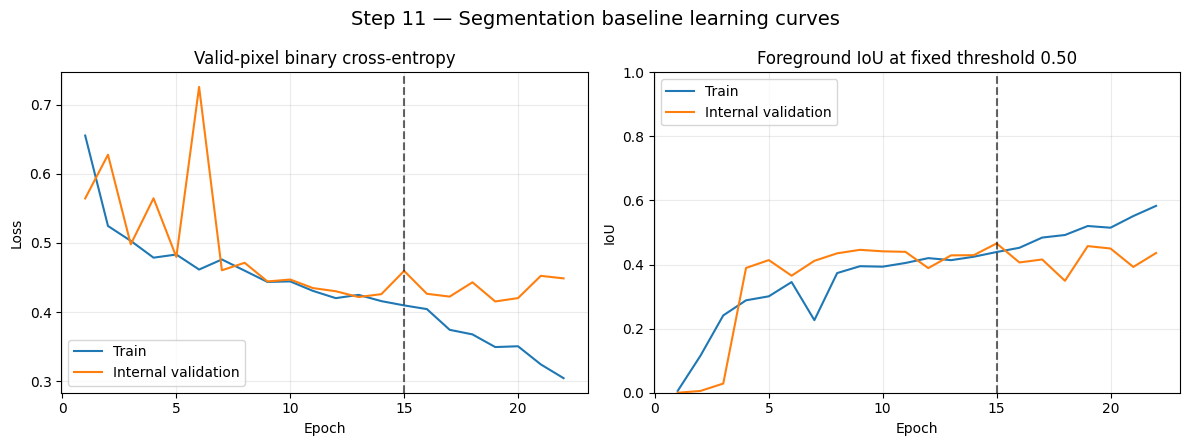

2026-08-02 15:38:10.567657: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


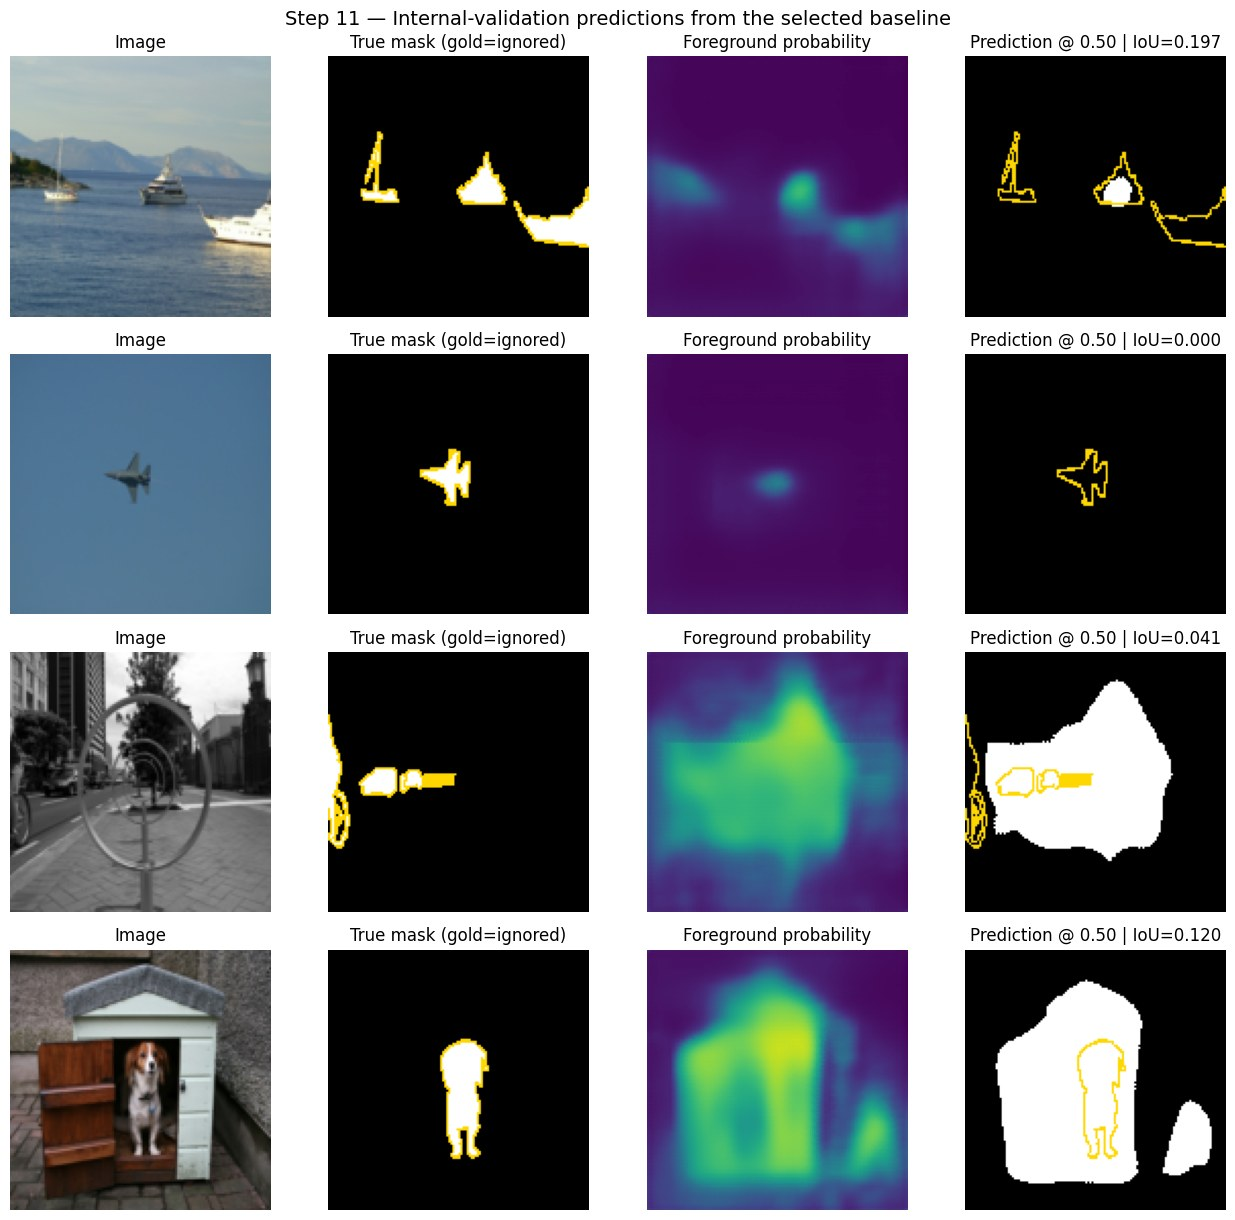


=== Saved Step 11 artifacts ===
Best model: /kaggle/working/anndl_outputs/step11_segmentation_baseline_best.keras
Model summary: /kaggle/working/anndl_outputs/step11_segmentation_baseline_summary.txt
Training history: /kaggle/working/anndl_outputs/step11_segmentation_baseline_history.csv
Validation metrics: /kaggle/working/anndl_outputs/step11_segmentation_baseline_metrics.json
Learning curves: /kaggle/working/anndl_outputs/step11_segmentation_baseline_curves.png
Validation examples: /kaggle/working/anndl_outputs/step11_segmentation_baseline_validation_examples.png
FINAL SEGMENTATION HOLDOUT REMAINS RESERVED: no evaluate or predict call used seg_test_ds.


In [ ]:
#Step 11: train and validate a simple binary-segmentation baseline

from pathlib import Path
import contextlib
import io
import json
import math

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import tensorflow as tf


# ---------------------------------------------------------------------------
# 1. Validate the Step 10 contract and protect 
# ---------------------------------------------------------------------------
required_objects = (
    "SEED",
    "OUTPUT_DIR",
    "SEGMENTATION_IMAGE_SIZE",
    "SEGMENTATION_BATCH_SIZE",
    "seg_train_ids",
    "seg_val_ids",
    "seg_train_ds",
    "seg_val_ds",
    "seg_test_ds",
)
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run the corrected Step 10 cell before Step 11. Missing objects: "
        + ", ".join(missing_objects)
    )

if globals().get("STEP11_SEGMENTATION_BASELINE_COMPLETED", False):
    raise RuntimeError(
        "Step 11 already completed in this session. Do not retrain the baseline."
    )

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

expected_train_batches = math.ceil(len(seg_train_ids) / SEGMENTATION_BATCH_SIZE)
expected_val_batches = math.ceil(len(seg_val_ids) / SEGMENTATION_BATCH_SIZE)
actual_train_batches = int(tf.data.experimental.cardinality(seg_train_ds).numpy())
actual_val_batches = int(tf.data.experimental.cardinality(seg_val_ds).numpy())

assert actual_train_batches == expected_train_batches, (
    actual_train_batches,
    expected_train_batches,
)
assert actual_val_batches == expected_val_batches, (
    actual_val_batches,
    expected_val_batches,
)

BASELINE_MAX_EPOCHS = 30
BASELINE_LEARNING_RATE = 1e-3
SEGMENTATION_FIXED_THRESHOLD = 0.50

baseline_checkpoint_path = OUTPUT_DIR / "step11_segmentation_baseline_best.keras"
baseline_history_path = OUTPUT_DIR / "step11_segmentation_baseline_history.csv"
baseline_metrics_path = OUTPUT_DIR / "step11_segmentation_baseline_metrics.json"
baseline_summary_path = OUTPUT_DIR / "step11_segmentation_baseline_summary.txt"
baseline_curves_path = OUTPUT_DIR / "step11_segmentation_baseline_curves.png"
baseline_predictions_path = (
    OUTPUT_DIR / "step11_segmentation_baseline_validation_examples.png"
)

print("=== Step 11 baseline protocol ===")
print("Model: simple encoder-decoder without skip connections")
print("Input: Step 10 images already normalized to [0, 1]")
print("Loss: valid-pixel binary cross-entropy")
print("Primary selection metric: internal-validation foreground IoU")
print(f"Fixed probability threshold: {SEGMENTATION_FIXED_THRESHOLD:.2f}")
print(f"Training images: {len(seg_train_ids):,} ({actual_train_batches} batches)")
print(
    f"Internal-validation images: {len(seg_val_ids):,} "
    f"({actual_val_batches} batches)"
)
print("Final holdout: reserved; seg_test_ds will not be traversed")


# ---------------------------------------------------------------------------
# 2. Build a deliberately simple encoder-decoder baseline
# ---------------------------------------------------------------------------
tf.keras.utils.set_random_seed(SEED)


def baseline_conv_block(x, filters, block_name):
    """Two same-resolution convolutions used in the baseline."""
    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu",
        kernel_initializer="he_normal",
        name=f"{block_name}_conv1",
    )(x)
    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu",
        kernel_initializer="he_normal",
        name=f"{block_name}_conv2",
    )(x)
    return x


def build_segmentation_baseline(input_shape):
    """Create an encoder-decoder with no skip connections or augmentation."""
    inputs = tf.keras.Input(shape=input_shape, name="image")

    x = baseline_conv_block(inputs, 32, "encoder1")
    x = tf.keras.layers.MaxPooling2D(2, name="pool1")(x)

    x = baseline_conv_block(x, 64, "encoder2")
    x = tf.keras.layers.MaxPooling2D(2, name="pool2")(x)

    x = baseline_conv_block(x, 128, "encoder3")
    x = tf.keras.layers.MaxPooling2D(2, name="pool3")(x)

    x = baseline_conv_block(x, 256, "bottleneck")

    x = tf.keras.layers.Conv2DTranspose(
        128, 3, strides=2, padding="same", activation="relu", name="upsample3"
    )(x)
    x = baseline_conv_block(x, 128, "decoder3")

    x = tf.keras.layers.Conv2DTranspose(
        64, 3, strides=2, padding="same", activation="relu", name="upsample2"
    )(x)
    x = baseline_conv_block(x, 64, "decoder2")

    x = tf.keras.layers.Conv2DTranspose(
        32, 3, strides=2, padding="same", activation="relu", name="upsample1"
    )(x)
    x = baseline_conv_block(x, 32, "decoder1")

    outputs = tf.keras.layers.Conv2D(
        1, 1, activation="sigmoid", name="foreground_probability"
    )(x)

    return tf.keras.Model(inputs, outputs, name="voc2012_segmentation_baseline")


segmentation_baseline_model = build_segmentation_baseline(
    (*SEGMENTATION_IMAGE_SIZE, 3)
)

assert segmentation_baseline_model.input_shape[1:] == (
    *SEGMENTATION_IMAGE_SIZE,
    3,
)
assert segmentation_baseline_model.output_shape[1:] == (
    *SEGMENTATION_IMAGE_SIZE,
    1,
)

# ``mean_with_sample_weight`` divides by the number of valid pixels rather than
# by all pixels, so zero-weight VOC boundary/void pixels are genuinely ignored.
segmentation_baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=BASELINE_LEARNING_RATE),
    loss=tf.keras.losses.BinaryCrossentropy(
        reduction="mean_with_sample_weight",
        name="valid_pixel_binary_crossentropy",
    ),
    weighted_metrics=[
        tf.keras.metrics.BinaryAccuracy(
            threshold=SEGMENTATION_FIXED_THRESHOLD,
            name="binary_accuracy",
        ),
        tf.keras.metrics.BinaryIoU(
            target_class_ids=[1],
            threshold=SEGMENTATION_FIXED_THRESHOLD,
            name="foreground_iou",
        ),
        tf.keras.metrics.Precision(
            thresholds=SEGMENTATION_FIXED_THRESHOLD,
            name="foreground_precision",
        ),
        tf.keras.metrics.Recall(
            thresholds=SEGMENTATION_FIXED_THRESHOLD,
            name="foreground_recall",
        ),
    ],
)

summary_buffer = io.StringIO()
with contextlib.redirect_stdout(summary_buffer):
    segmentation_baseline_model.summary()
baseline_summary_text = summary_buffer.getvalue()
baseline_summary_path.write_text(baseline_summary_text, encoding="utf-8")
print("\n=== Baseline model summary ===")
print(baseline_summary_text)


# ---------------------------------------------------------------------------
# 3. Train using only training and internal-validation data
# ---------------------------------------------------------------------------
baseline_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(baseline_checkpoint_path),
        monitor="val_foreground_iou",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_foreground_iou",
        mode="max",
        min_delta=1e-4,
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

segmentation_baseline_history = segmentation_baseline_model.fit(
    seg_train_ds,
    validation_data=seg_val_ds,
    epochs=BASELINE_MAX_EPOCHS,
    callbacks=baseline_callbacks,
    verbose=1,
)

baseline_history_df = pd.DataFrame(segmentation_baseline_history.history)
required_history_columns = {
    "loss",
    "val_loss",
    "foreground_iou",
    "val_foreground_iou",
}
missing_history_columns = required_history_columns - set(baseline_history_df.columns)
assert not missing_history_columns, missing_history_columns
assert np.isfinite(
    baseline_history_df[list(required_history_columns)].to_numpy()
).all(), "Non-finite values found in baseline training history."
baseline_history_df.index = np.arange(1, len(baseline_history_df) + 1)
baseline_history_df.index.name = "epoch"
baseline_history_df.to_csv(baseline_history_path)

best_epoch = int(baseline_history_df["val_foreground_iou"].idxmax())
best_history_val_iou = float(
    baseline_history_df.loc[best_epoch, "val_foreground_iou"]
)

print("\n=== Baseline training result ===")
print(f"Epochs completed: {len(baseline_history_df)} / {BASELINE_MAX_EPOCHS}")
print(f"Best epoch by internal-validation foreground IoU: {best_epoch}")
print(f"Best logged validation foreground IoU: {best_history_val_iou:.5f}")


# ---------------------------------------------------------------------------
# 4. Reload the selected checkpoint and evaluate internal validation only
# ---------------------------------------------------------------------------
assert baseline_checkpoint_path.exists(), "Best baseline checkpoint was not saved."
segmentation_baseline_model = tf.keras.models.load_model(
    baseline_checkpoint_path
)

baseline_validation_metrics = segmentation_baseline_model.evaluate(
    seg_val_ds,
    return_dict=True,
    verbose=1,
)
baseline_validation_metrics = {
    key: float(value) for key, value in baseline_validation_metrics.items()
}

assert all(np.isfinite(value) for value in baseline_validation_metrics.values())
assert abs(
    baseline_validation_metrics["foreground_iou"] - best_history_val_iou
) < 1e-4, (
    baseline_validation_metrics["foreground_iou"],
    best_history_val_iou,
)

baseline_result_record = {
    "step": 11,
    "model_key": "baseline_encoder_decoder",
    "model_name": segmentation_baseline_model.name,
    "architecture": "encoder_decoder_without_skip_connections",
    "input_shape": list(segmentation_baseline_model.input_shape[1:]),
    "output_shape": list(segmentation_baseline_model.output_shape[1:]),
    "trainable_parameters": int(
        np.sum(
            [
                np.prod(variable.shape)
                for variable in segmentation_baseline_model.trainable_weights
            ]
        )
    ),
    "selection_split": "internal_validation",
    "selection_metric": "foreground_iou_at_0.50",
    "fixed_threshold": SEGMENTATION_FIXED_THRESHOLD,
    "best_epoch": best_epoch,
    "epochs_completed": int(len(baseline_history_df)),
    "internal_validation_metrics": baseline_validation_metrics,
    "final_holdout_evaluated": False,
}
baseline_metrics_path.write_text(
    json.dumps(baseline_result_record, indent=2),
    encoding="utf-8",
)

segmentation_candidate_results = globals().get(
    "segmentation_candidate_results", {}
)
segmentation_candidate_results["baseline_encoder_decoder"] = baseline_result_record

print("\n=== Selected baseline: internal-validation metrics ===")
for metric_name, metric_value in baseline_validation_metrics.items():
    print(f"{metric_name:>24s}: {metric_value:.5f}")


# ---------------------------------------------------------------------------
# 5. Plot learning curves
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
epochs = baseline_history_df.index.to_numpy()

axes[0].plot(epochs, baseline_history_df["loss"], label="Train")
axes[0].plot(epochs, baseline_history_df["val_loss"], label="Internal validation")
axes[0].axvline(best_epoch, color="black", linestyle="--", alpha=0.6)
axes[0].set_title("Valid-pixel binary cross-entropy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(epochs, baseline_history_df["foreground_iou"], label="Train")
axes[1].plot(
    epochs,
    baseline_history_df["val_foreground_iou"],
    label="Internal validation",
)
axes[1].axvline(best_epoch, color="black", linestyle="--", alpha=0.6)
axes[1].set_title("Foreground IoU at fixed threshold 0.50")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IoU")
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.suptitle("Step 11 — Segmentation baseline learning curves", fontsize=14)
fig.tight_layout()
fig.savefig(baseline_curves_path, dpi=180, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------------
# 6. Inspect predictions on internal validation only
# ---------------------------------------------------------------------------
val_images, val_masks, val_weights = next(iter(seg_val_ds))
n_examples = min(4, int(val_images.shape[0]))
val_probabilities = segmentation_baseline_model.predict(
    val_images[:n_examples],
    verbose=0,
)

assert val_probabilities.shape == (
    n_examples,
    *SEGMENTATION_IMAGE_SIZE,
    1,
)
assert float(np.min(val_probabilities)) >= 0.0
assert float(np.max(val_probabilities)) <= 1.0

mask_cmap = ListedColormap(["black", "white", "gold"])
fig, axes = plt.subplots(n_examples, 4, figsize=(13, 3.1 * n_examples))
if n_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n_examples):
    image_array = val_images[row].numpy()
    true_mask = val_masks[row, ..., 0].numpy() >= 0.5
    valid_mask = val_weights[row, ..., 0].numpy() >= 0.5
    probability_map = val_probabilities[row, ..., 0]
    predicted_mask = probability_map >= SEGMENTATION_FIXED_THRESHOLD

    intersection = np.logical_and(true_mask, predicted_mask) & valid_mask
    union = np.logical_or(true_mask, predicted_mask) & valid_mask
    sample_iou = float(intersection.sum() / max(union.sum(), 1))

    true_display = np.where(valid_mask, true_mask.astype(np.uint8), 2)
    prediction_display = np.where(
        valid_mask, predicted_mask.astype(np.uint8), 2
    )

    axes[row, 0].imshow(image_array)
    axes[row, 0].set_title("Image")

    axes[row, 1].imshow(true_display, cmap=mask_cmap, vmin=0, vmax=2)
    axes[row, 1].set_title("True mask (gold=ignored)")

    axes[row, 2].imshow(probability_map, cmap="viridis", vmin=0.0, vmax=1.0)
    axes[row, 2].set_title("Foreground probability")

    axes[row, 3].imshow(prediction_display, cmap=mask_cmap, vmin=0, vmax=2)
    axes[row, 3].set_title(f"Prediction @ 0.50 | IoU={sample_iou:.3f}")

    for col in range(4):
        axes[row, col].axis("off")

fig.suptitle(
    "Step 11 — Internal-validation predictions from the selected baseline",
    fontsize=14,
)
fig.tight_layout()
fig.savefig(baseline_predictions_path, dpi=180, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------------
# 7. Save the handoff state 
# ---------------------------------------------------------------------------
STEP11_SEGMENTATION_BASELINE_COMPLETED = True

print("\n=== Saved Step 11 artifacts ===")
print(f"Best model: {baseline_checkpoint_path}")
print(f"Model summary: {baseline_summary_path}")
print(f"Training history: {baseline_history_path}")
print(f"Validation metrics: {baseline_metrics_path}")
print(f"Learning curves: {baseline_curves_path}")
print(f"Validation examples: {baseline_predictions_path}")
print(
    "FINAL SEGMENTATION HOLDOUT REMAINS RESERVED: "
    "no evaluate or predict call used seg_test_ds."
)


=== Step 12 U-Net protocol ===
Model: U-Net encoder-decoder with same-scale skip connections
Regularisation: batch normalisation, bottleneck dropout, training augmentation
Augmentation: shared horizontal flip plus mild image-only colour jitter
Input: Step 10 images already normalised to [0, 1]
Loss: valid-pixel binary cross-entropy (same as Step 11)
Primary selection metric: internal-validation foreground IoU
Fixed probability threshold: 0.50
Training images: 1,171 (74 batches)
Internal-validation images: 293 (19 batches)
Step 11 baseline validation foreground IoU: 0.46599
Final holdout: reserved; seg_test_ds will not be traversed
Training-only augmentation probe passed; masks and void weights remain aligned.


2026-08-02 15:47:33.537150: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}



=== U-Net model summary ===
Model: "voc2012_segmentation_unet"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder1_conv1      │ (None, 128, 128,  │        864 │ image[0][0]       │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder1_bn1        │ (None, 128, 128,  │        128 │ encoder1_conv1[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder1_r

E0000 00:00:1785685661.692592      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/voc2012_segmentation_unet_1/bottleneck_dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - binary_accuracy: 0.6810 - foreground_iou: 0.3042 - foreground_precision: 0.4309 - foreground_recall: 0.5114 - loss: 0.6077
Epoch 1: val_foreground_iou improved from None to 0.39306, saving model to /kaggle/working/anndl_outputs/step12_segmentation_unet_best.keras

Epoch 1: finished saving model to /kaggle/working/anndl_outputs/step12_segmentation_unet_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - binary_accuracy: 0.7259 - foreground_iou: 0.3218 - foreground_precision: 0.4813 - foreground_recall: 0.4928 - loss: 0.5532 - val_binary_accuracy: 0.6865 - val_foreground_iou: 0.3931 - val_foreground_precision: 0.4544 - val_foreground_recall: 0.7443 - val_loss: 0.6614 - learning_rate: 5.0000e-04
Epoch 2/40
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - binary_accuracy: 0.7648 - foreground_iou: 0.3519 - foreground_precision: 0.5898 - foreground_recall: 0.4661 - loss: 0.4843
Epoch 2: val_foreground_iou improved from 0.39306 to 0.42196, saving model 

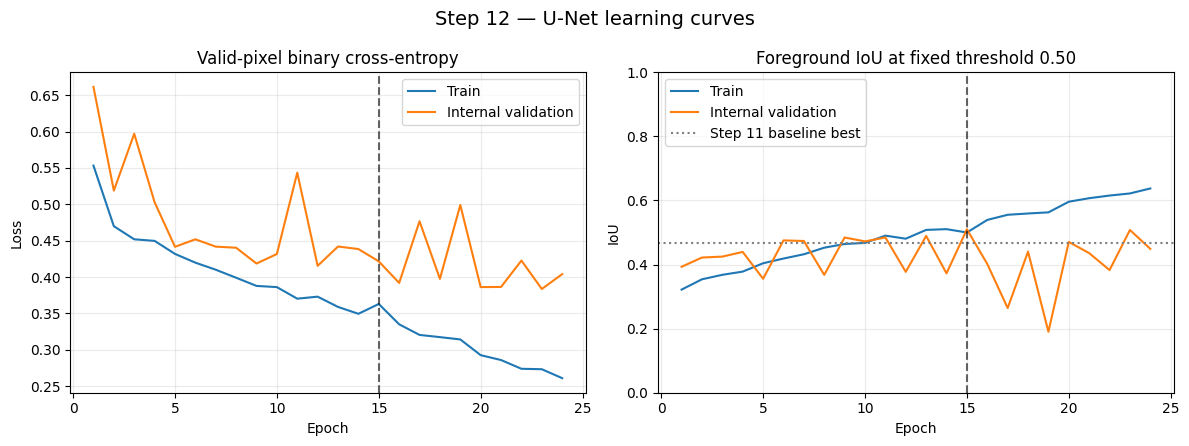

2026-08-02 15:52:23.697448: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


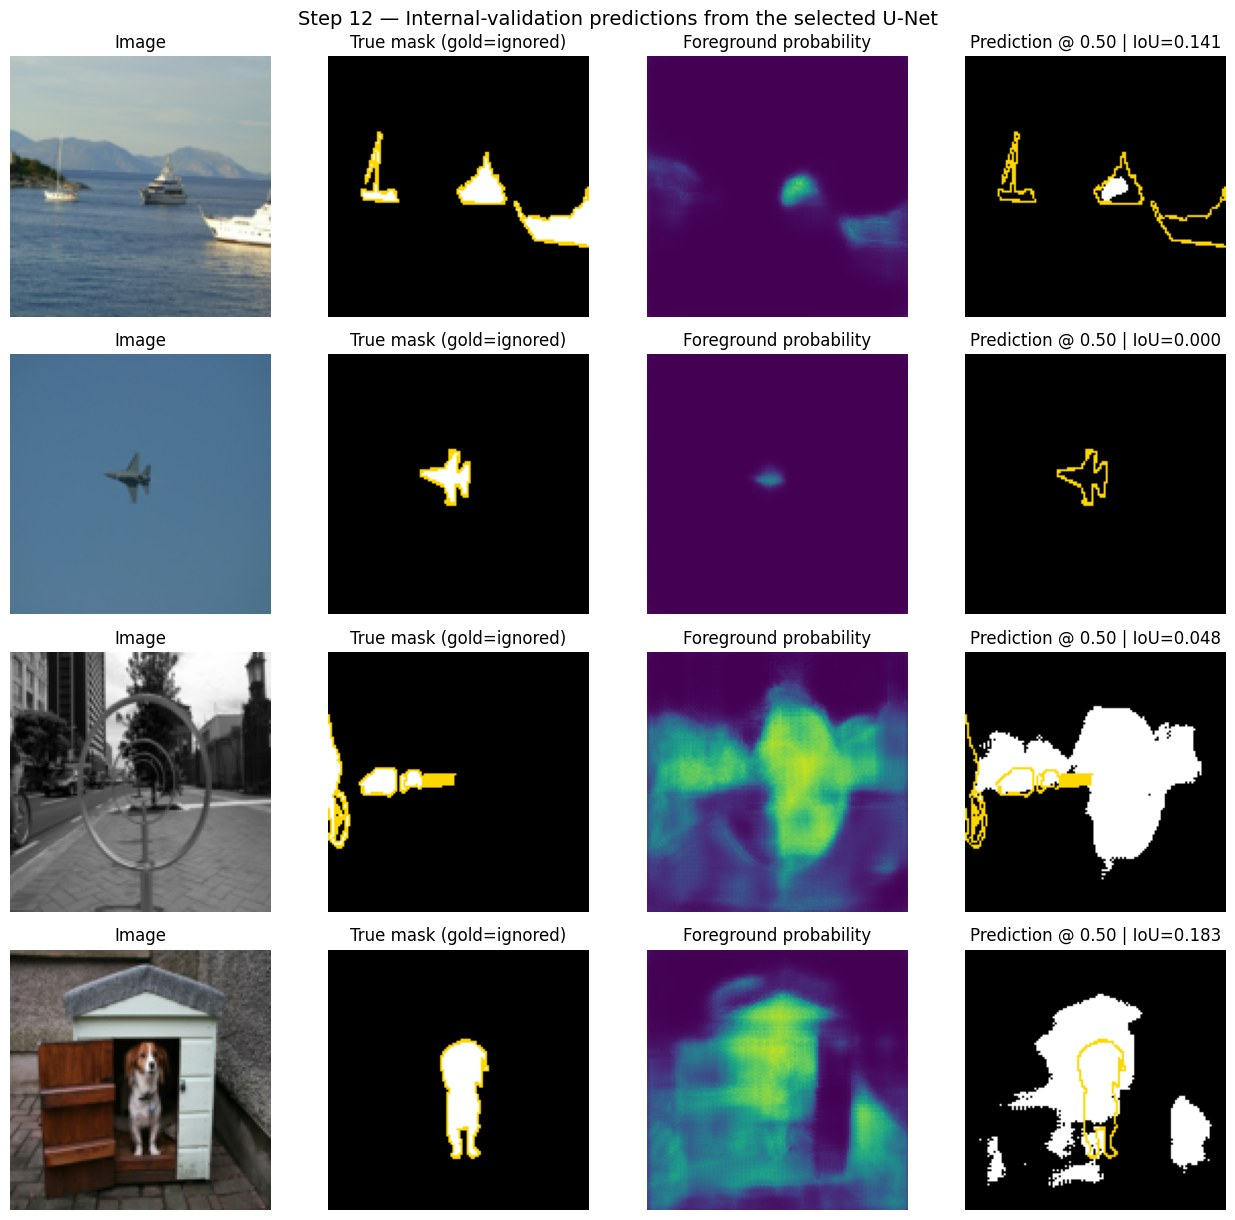


=== Saved Step 12 artifacts ===
Best model: /kaggle/working/anndl_outputs/step12_segmentation_unet_best.keras
Model summary: /kaggle/working/anndl_outputs/step12_segmentation_unet_summary.txt
Training history: /kaggle/working/anndl_outputs/step12_segmentation_unet_history.csv
Validation metrics: /kaggle/working/anndl_outputs/step12_segmentation_unet_metrics.json
Candidate comparison: /kaggle/working/anndl_outputs/step12_segmentation_candidate_comparison.csv
Learning curves: /kaggle/working/anndl_outputs/step12_segmentation_unet_curves.png
Validation examples: /kaggle/working/anndl_outputs/step12_segmentation_unet_validation_examples.png
FINAL SEGMENTATION HOLDOUT REMAINS RESERVED: no evaluate or predict call used seg_test_ds.


In [ ]:
#Step 12: train and validate an improved U-Net segmentation candidate

from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import tensorflow as tf


# ---------------------------------------------------------------------------
# 1. Validate the Step 11 handoff and lock the comparison protocol
# ---------------------------------------------------------------------------
required_objects = (
    "SEED",
    "OUTPUT_DIR",
    "SEGMENTATION_IMAGE_SIZE",
    "SEGMENTATION_BATCH_SIZE",
    "seg_train_ids",
    "seg_val_ids",
    "seg_train_ds",
    "seg_val_ds",
    "seg_test_ds",
    "segmentation_candidate_results",
)
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run the corrected Steps 10 and 11 before Step 12. Missing objects: "
        + ", ".join(missing_objects)
    )

if not globals().get("STEP11_SEGMENTATION_BASELINE_COMPLETED", False):
    raise RuntimeError("Step 11 must complete before the U-Net comparison.")

if "baseline_encoder_decoder" not in segmentation_candidate_results:
    raise RuntimeError("The Step 11 baseline result record is unavailable.")

if globals().get("STEP12_SEGMENTATION_UNET_COMPLETED", False):
    raise RuntimeError(
        "Step 12 already completed in this session. Do not retrain the U-Net."
    )

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

expected_train_batches = math.ceil(len(seg_train_ids) / SEGMENTATION_BATCH_SIZE)
expected_val_batches = math.ceil(len(seg_val_ids) / SEGMENTATION_BATCH_SIZE)
actual_train_batches = int(tf.data.experimental.cardinality(seg_train_ds).numpy())
actual_val_batches = int(tf.data.experimental.cardinality(seg_val_ds).numpy())
assert actual_train_batches == expected_train_batches
assert actual_val_batches == expected_val_batches

UNET_MAX_EPOCHS = 40
UNET_LEARNING_RATE = 5e-4
UNET_DROPOUT_RATE = 0.30
SEGMENTATION_FIXED_THRESHOLD = 0.50

unet_checkpoint_path = OUTPUT_DIR / "step12_segmentation_unet_best.keras"
unet_history_path = OUTPUT_DIR / "step12_segmentation_unet_history.csv"
unet_metrics_path = OUTPUT_DIR / "step12_segmentation_unet_metrics.json"
unet_summary_path = OUTPUT_DIR / "step12_segmentation_unet_summary.txt"
unet_curves_path = OUTPUT_DIR / "step12_segmentation_unet_curves.png"
unet_predictions_path = (
    OUTPUT_DIR / "step12_segmentation_unet_validation_examples.png"
)
unet_comparison_path = OUTPUT_DIR / "step12_segmentation_candidate_comparison.csv"

baseline_record = segmentation_candidate_results["baseline_encoder_decoder"]
baseline_val_iou = float(
    baseline_record["internal_validation_metrics"]["foreground_iou"]
)

print("=== Step 12 U-Net protocol ===")
print("Model: U-Net encoder-decoder with same-scale skip connections")
print("Regularisation: batch normalisation, bottleneck dropout, training augmentation")
print("Augmentation: shared horizontal flip plus mild image-only colour jitter")
print("Input: Step 10 images already normalised to [0, 1]")
print("Loss: valid-pixel binary cross-entropy (same as Step 11)")
print("Primary selection metric: internal-validation foreground IoU")
print(f"Fixed probability threshold: {SEGMENTATION_FIXED_THRESHOLD:.2f}")
print(f"Training images: {len(seg_train_ids):,} ({actual_train_batches} batches)")
print(
    f"Internal-validation images: {len(seg_val_ids):,} "
    f"({actual_val_batches} batches)"
)
print(f"Step 11 baseline validation foreground IoU: {baseline_val_iou:.5f}")
print("Final holdout: reserved; seg_test_ds will not be traversed")


# ---------------------------------------------------------------------------
# 2. Add leakage-safe training-only augmentation
# ---------------------------------------------------------------------------
def augment_segmentation_batch(images, masks, pixel_weights):
    """Apply one shared geometric transform and image-only colour jitter."""
    combined = tf.concat([images, masks, pixel_weights], axis=-1)
    combined = tf.image.random_flip_left_right(combined, seed=SEED + 1200)

    augmented_images = combined[..., :3]
    augmented_masks = combined[..., 3:4]
    augmented_weights = combined[..., 4:5]

    augmented_images = tf.image.random_brightness(
        augmented_images,
        max_delta=0.06,
        seed=SEED + 1201,
    )
    augmented_images = tf.image.random_contrast(
        augmented_images,
        lower=0.90,
        upper=1.10,
        seed=SEED + 1202,
    )
    augmented_images = tf.clip_by_value(augmented_images, 0.0, 1.0)

    augmented_images.set_shape((None, *SEGMENTATION_IMAGE_SIZE, 3))
    augmented_masks.set_shape((None, *SEGMENTATION_IMAGE_SIZE, 1))
    augmented_weights.set_shape((None, *SEGMENTATION_IMAGE_SIZE, 1))
    return augmented_images, augmented_masks, augmented_weights


seg_train_unet_ds = seg_train_ds.map(
    augment_segmentation_batch,
    num_parallel_calls=tf.data.AUTOTUNE,
    deterministic=True,
).prefetch(tf.data.AUTOTUNE)

augmentation_probe = next(iter(seg_train_unet_ds))
probe_images, probe_masks, probe_weights = augmentation_probe
assert float(tf.reduce_min(probe_images)) >= 0.0
assert float(tf.reduce_max(probe_images)) <= 1.0
assert set(np.unique(probe_masks.numpy()).tolist()).issubset({0.0, 1.0})
assert set(np.unique(probe_weights.numpy()).tolist()).issubset({0.0, 1.0})
print("Training-only augmentation probe passed; masks and void weights remain aligned.")


# ---------------------------------------------------------------------------
# 3. Build the improved U-Net candidate
# ---------------------------------------------------------------------------
tf.keras.utils.set_random_seed(SEED + 12)


def unet_conv_block(x, filters, block_name, dropout_rate=0.0):
    """Two Conv-BN-ReLU layers, with optional spatial dropout."""
    for convolution_index in (1, 2):
        x = tf.keras.layers.Conv2D(
            filters,
            3,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            name=f"{block_name}_conv{convolution_index}",
        )(x)
        x = tf.keras.layers.BatchNormalization(
            name=f"{block_name}_bn{convolution_index}"
        )(x)
        x = tf.keras.layers.Activation(
            "relu",
            name=f"{block_name}_relu{convolution_index}",
        )(x)
    if dropout_rate > 0.0:
        x = tf.keras.layers.SpatialDropout2D(
            dropout_rate,
            name=f"{block_name}_dropout",
        )(x)
    return x


def build_segmentation_unet(input_shape):
    """Create a three-level U-Net with encoder-to-decoder skip connections."""
    inputs = tf.keras.Input(shape=input_shape, name="image")

    encoder1 = unet_conv_block(inputs, 32, "encoder1")
    pooled1 = tf.keras.layers.MaxPooling2D(2, name="pool1")(encoder1)

    encoder2 = unet_conv_block(pooled1, 64, "encoder2")
    pooled2 = tf.keras.layers.MaxPooling2D(2, name="pool2")(encoder2)

    encoder3 = unet_conv_block(pooled2, 128, "encoder3")
    pooled3 = tf.keras.layers.MaxPooling2D(2, name="pool3")(encoder3)

    bottleneck = unet_conv_block(
        pooled3,
        256,
        "bottleneck",
        dropout_rate=UNET_DROPOUT_RATE,
    )

    decoder3 = tf.keras.layers.Conv2DTranspose(
        128,
        2,
        strides=2,
        padding="same",
        name="upsample3",
    )(bottleneck)
    decoder3 = tf.keras.layers.Concatenate(name="skip3")(
        [decoder3, encoder3]
    )
    decoder3 = unet_conv_block(decoder3, 128, "decoder3")

    decoder2 = tf.keras.layers.Conv2DTranspose(
        64,
        2,
        strides=2,
        padding="same",
        name="upsample2",
    )(decoder3)
    decoder2 = tf.keras.layers.Concatenate(name="skip2")(
        [decoder2, encoder2]
    )
    decoder2 = unet_conv_block(decoder2, 64, "decoder2")

    decoder1 = tf.keras.layers.Conv2DTranspose(
        32,
        2,
        strides=2,
        padding="same",
        name="upsample1",
    )(decoder2)
    decoder1 = tf.keras.layers.Concatenate(name="skip1")(
        [decoder1, encoder1]
    )
    decoder1 = unet_conv_block(decoder1, 32, "decoder1")

    outputs = tf.keras.layers.Conv2D(
        1,
        1,
        activation="sigmoid",
        name="foreground_probability",
    )(decoder1)
    return tf.keras.Model(inputs, outputs, name="voc2012_segmentation_unet")


segmentation_unet_model = build_segmentation_unet(
    (*SEGMENTATION_IMAGE_SIZE, 3)
)
assert segmentation_unet_model.input_shape[1:] == (
    *SEGMENTATION_IMAGE_SIZE,
    3,
)
assert segmentation_unet_model.output_shape[1:] == (
    *SEGMENTATION_IMAGE_SIZE,
    1,
)

segmentation_unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=UNET_LEARNING_RATE),
    loss=tf.keras.losses.BinaryCrossentropy(
        reduction="mean_with_sample_weight",
        name="valid_pixel_binary_crossentropy",
    ),
    weighted_metrics=[
        tf.keras.metrics.BinaryAccuracy(
            threshold=SEGMENTATION_FIXED_THRESHOLD,
            name="binary_accuracy",
            dtype="float32",
        ),
        tf.keras.metrics.BinaryIoU(
            target_class_ids=[1],
            threshold=SEGMENTATION_FIXED_THRESHOLD,
            name="foreground_iou",
            dtype="float32",
        ),
        tf.keras.metrics.Precision(
            thresholds=SEGMENTATION_FIXED_THRESHOLD,
            name="foreground_precision",
            dtype="float32",
        ),
        tf.keras.metrics.Recall(
            thresholds=SEGMENTATION_FIXED_THRESHOLD,
            name="foreground_recall",
            dtype="float32",
        ),
    ],
)

summary_lines = []
segmentation_unet_model.summary(print_fn=summary_lines.append)
unet_summary_text = "\n".join(summary_lines)
unet_summary_path.write_text(unet_summary_text, encoding="utf-8")
print("\n=== U-Net model summary ===")
print(unet_summary_text)


# ---------------------------------------------------------------------------
# 4. Train using training and internal-validation data only
# ---------------------------------------------------------------------------
unet_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(unet_checkpoint_path),
        monitor="val_foreground_iou",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_foreground_iou",
        mode="max",
        min_delta=1e-4,
        patience=9,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

segmentation_unet_history = segmentation_unet_model.fit(
    seg_train_unet_ds,
    validation_data=seg_val_ds,
    epochs=UNET_MAX_EPOCHS,
    callbacks=unet_callbacks,
    verbose=1,
)

unet_history_df = pd.DataFrame(segmentation_unet_history.history)
required_history_columns = {
    "loss",
    "val_loss",
    "foreground_iou",
    "val_foreground_iou",
}
missing_history_columns = required_history_columns - set(unet_history_df.columns)
assert not missing_history_columns, missing_history_columns
assert np.isfinite(
    unet_history_df[list(required_history_columns)].to_numpy()
).all(), "Non-finite values found in U-Net training history."
unet_history_df.index = np.arange(1, len(unet_history_df) + 1)
unet_history_df.index.name = "epoch"
unet_history_df.to_csv(unet_history_path)

best_epoch = int(unet_history_df["val_foreground_iou"].idxmax())
best_history_val_iou = float(
    unet_history_df.loc[best_epoch, "val_foreground_iou"]
)

print("\n=== U-Net training result ===")
print(f"Epochs completed: {len(unet_history_df)} / {UNET_MAX_EPOCHS}")
print(f"Best epoch by internal-validation foreground IoU: {best_epoch}")
print(f"Best logged validation foreground IoU: {best_history_val_iou:.5f}")


# ---------------------------------------------------------------------------
# 5. Reload the selected checkpoint and evaluate internal validation only
# ---------------------------------------------------------------------------
assert unet_checkpoint_path.exists(), "Best U-Net checkpoint was not saved."
segmentation_unet_model = tf.keras.models.load_model(unet_checkpoint_path)

unet_validation_metrics = segmentation_unet_model.evaluate(
    seg_val_ds,
    return_dict=True,
    verbose=1,
)
unet_validation_metrics = {
    key: float(value) for key, value in unet_validation_metrics.items()
}
assert all(np.isfinite(value) for value in unet_validation_metrics.values())
assert abs(
    unet_validation_metrics["foreground_iou"] - best_history_val_iou
) < 1e-4

unet_val_iou = float(unet_validation_metrics["foreground_iou"])
iou_delta = unet_val_iou - baseline_val_iou

unet_result_record = {
    "step": 12,
    "model_key": "unet_skip_connections",
    "model_name": segmentation_unet_model.name,
    "architecture": "unet_with_three_skip_connections",
    "input_shape": list(segmentation_unet_model.input_shape[1:]),
    "output_shape": list(segmentation_unet_model.output_shape[1:]),
    "trainable_parameters": int(
        np.sum(
            [
                np.prod(variable.shape)
                for variable in segmentation_unet_model.trainable_weights
            ]
        )
    ),
    "selection_split": "internal_validation",
    "selection_metric": "foreground_iou_at_0.50",
    "fixed_threshold": SEGMENTATION_FIXED_THRESHOLD,
    "best_epoch": best_epoch,
    "epochs_completed": int(len(unet_history_df)),
    "internal_validation_metrics": unet_validation_metrics,
    "baseline_validation_foreground_iou": baseline_val_iou,
    "foreground_iou_delta_vs_baseline": iou_delta,
    "final_holdout_evaluated": False,
}
unet_metrics_path.write_text(
    json.dumps(unet_result_record, indent=2),
    encoding="utf-8",
)
segmentation_candidate_results["unet_skip_connections"] = unet_result_record

comparison_frame = pd.DataFrame(
    [
        {
            "model": "Step 11 baseline encoder-decoder",
            "validation_foreground_iou": baseline_val_iou,
        },
        {
            "model": "Step 12 U-Net with skip connections",
            "validation_foreground_iou": unet_val_iou,
        },
    ]
)
comparison_frame["rank"] = comparison_frame[
    "validation_foreground_iou"
].rank(method="min", ascending=False).astype(int)
comparison_frame = comparison_frame.sort_values("rank")
comparison_frame.to_csv(unet_comparison_path, index=False)

print("\n=== Selected U-Net: internal-validation metrics ===")
for metric_name, metric_value in unet_validation_metrics.items():
    print(f"{metric_name:>24s}: {metric_value:.5f}")

print("\n=== Segmentation candidate comparison ===")
print(comparison_frame.to_string(index=False, float_format=lambda x: f"{x:.5f}"))
print(f"U-Net foreground-IoU change versus baseline: {iou_delta:+.5f}")


# ---------------------------------------------------------------------------
# 6. Plot learning curves
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
epochs = unet_history_df.index.to_numpy()

axes[0].plot(epochs, unet_history_df["loss"], label="Train")
axes[0].plot(epochs, unet_history_df["val_loss"], label="Internal validation")
axes[0].axvline(best_epoch, color="black", linestyle="--", alpha=0.6)
axes[0].set_title("Valid-pixel binary cross-entropy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(epochs, unet_history_df["foreground_iou"], label="Train")
axes[1].plot(
    epochs,
    unet_history_df["val_foreground_iou"],
    label="Internal validation",
)
axes[1].axhline(
    baseline_val_iou,
    color="tab:gray",
    linestyle=":",
    label="Step 11 baseline best",
)
axes[1].axvline(best_epoch, color="black", linestyle="--", alpha=0.6)
axes[1].set_title("Foreground IoU at fixed threshold 0.50")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IoU")
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.suptitle("Step 12 — U-Net learning curves", fontsize=14)
fig.tight_layout()
fig.savefig(unet_curves_path, dpi=180, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------------
# 7. Inspect the same deterministic internal-validation batch as Step 11
# ---------------------------------------------------------------------------
val_images, val_masks, val_weights = next(iter(seg_val_ds))
n_examples = min(4, int(val_images.shape[0]))
val_probabilities = segmentation_unet_model.predict(
    val_images[:n_examples],
    verbose=0,
)
assert val_probabilities.shape == (
    n_examples,
    *SEGMENTATION_IMAGE_SIZE,
    1,
)
assert float(np.min(val_probabilities)) >= 0.0
assert float(np.max(val_probabilities)) <= 1.0

mask_cmap = ListedColormap(["black", "white", "gold"])
fig, axes = plt.subplots(n_examples, 4, figsize=(13, 3.1 * n_examples))
if n_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n_examples):
    image_array = val_images[row].numpy()
    true_mask = val_masks[row, ..., 0].numpy() >= 0.5
    valid_mask = val_weights[row, ..., 0].numpy() >= 0.5
    probability_map = val_probabilities[row, ..., 0]
    predicted_mask = probability_map >= SEGMENTATION_FIXED_THRESHOLD

    intersection = np.logical_and(true_mask, predicted_mask) & valid_mask
    union = np.logical_or(true_mask, predicted_mask) & valid_mask
    sample_iou = float(intersection.sum() / max(union.sum(), 1))

    true_display = np.where(valid_mask, true_mask.astype(np.uint8), 2)
    prediction_display = np.where(
        valid_mask,
        predicted_mask.astype(np.uint8),
        2,
    )

    axes[row, 0].imshow(image_array)
    axes[row, 0].set_title("Image")
    axes[row, 1].imshow(true_display, cmap=mask_cmap, vmin=0, vmax=2)
    axes[row, 1].set_title("True mask (gold=ignored)")
    axes[row, 2].imshow(probability_map, cmap="viridis", vmin=0.0, vmax=1.0)
    axes[row, 2].set_title("Foreground probability")
    axes[row, 3].imshow(prediction_display, cmap=mask_cmap, vmin=0, vmax=2)
    axes[row, 3].set_title(f"Prediction @ 0.50 | IoU={sample_iou:.3f}")

    for column in range(4):
        axes[row, column].axis("off")

fig.suptitle(
    "Step 12 — Internal-validation predictions from the selected U-Net",
    fontsize=14,
)
fig.tight_layout()
fig.savefig(unet_predictions_path, dpi=180, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------------
# 8. Save the final holdout
# ---------------------------------------------------------------------------
STEP12_SEGMENTATION_UNET_COMPLETED = True

print("\n=== Saved Step 12 artifacts ===")
print(f"Best model: {unet_checkpoint_path}")
print(f"Model summary: {unet_summary_path}")
print(f"Training history: {unet_history_path}")
print(f"Validation metrics: {unet_metrics_path}")
print(f"Candidate comparison: {unet_comparison_path}")
print(f"Learning curves: {unet_curves_path}")
print(f"Validation examples: {unet_predictions_path}")
print(
    "FINAL SEGMENTATION HOLDOUT REMAINS RESERVED: "
    "no evaluate or predict call used seg_test_ds."
)


=== Step 13 final segmentation protocol ===
Winner selection source: internal validation only
Selection metric: foreground IoU at fixed threshold 0.50
Final holdout: official VOC segmentation validation split
Holdout policy: one inference pass; no tuning after inspection
Final-holdout images: 1,449
Final-holdout batches: 91

=== Locked model selection ===
           candidate_key                    model_name  internal_validation_foreground_iou  selection_threshold  rank  selected
   unet_skip_connections     voc2012_segmentation_unet                             0.51003              0.50000     1      True
baseline_encoder_decoder voc2012_segmentation_baseline                             0.46599              0.50000     2     False

Selected candidate: unet_skip_connections
Selected validation foreground IoU: 0.51003
Selected checkpoint: /kaggle/working/anndl_outputs/step12_segmentation_unet_best.keras


2026-08-02 16:03:46.872357: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}



=== Final segmentation holdout metrics ===
                        loss: 0.40969
             binary_accuracy: 0.81227
              foreground_iou: 0.51007
        foreground_precision: 0.62766
           foreground_recall: 0.73138
               foreground_f1: 0.67556
    foreground_dice_from_iou: 0.67556

=== Per-image foreground IoU distribution ===
                        mean: 0.49162
                      median: 0.52053
                         q25: 0.29835
                         q75: 0.69514
Validation-to-holdout foreground-IoU change: +0.00004


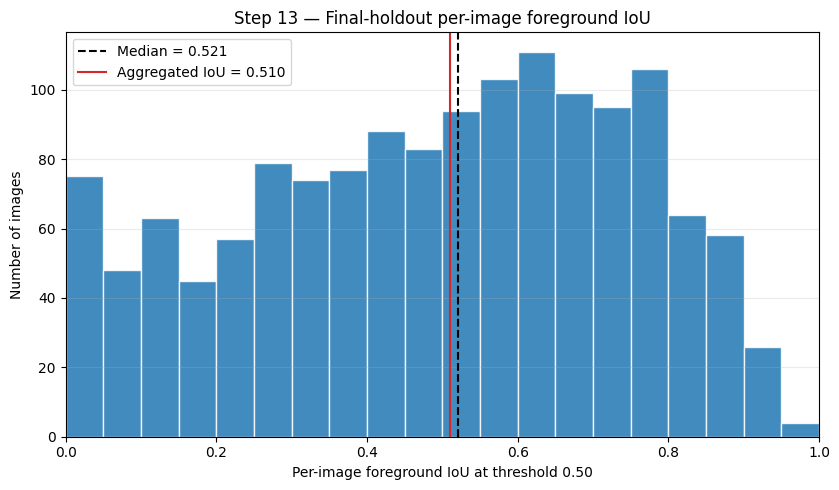

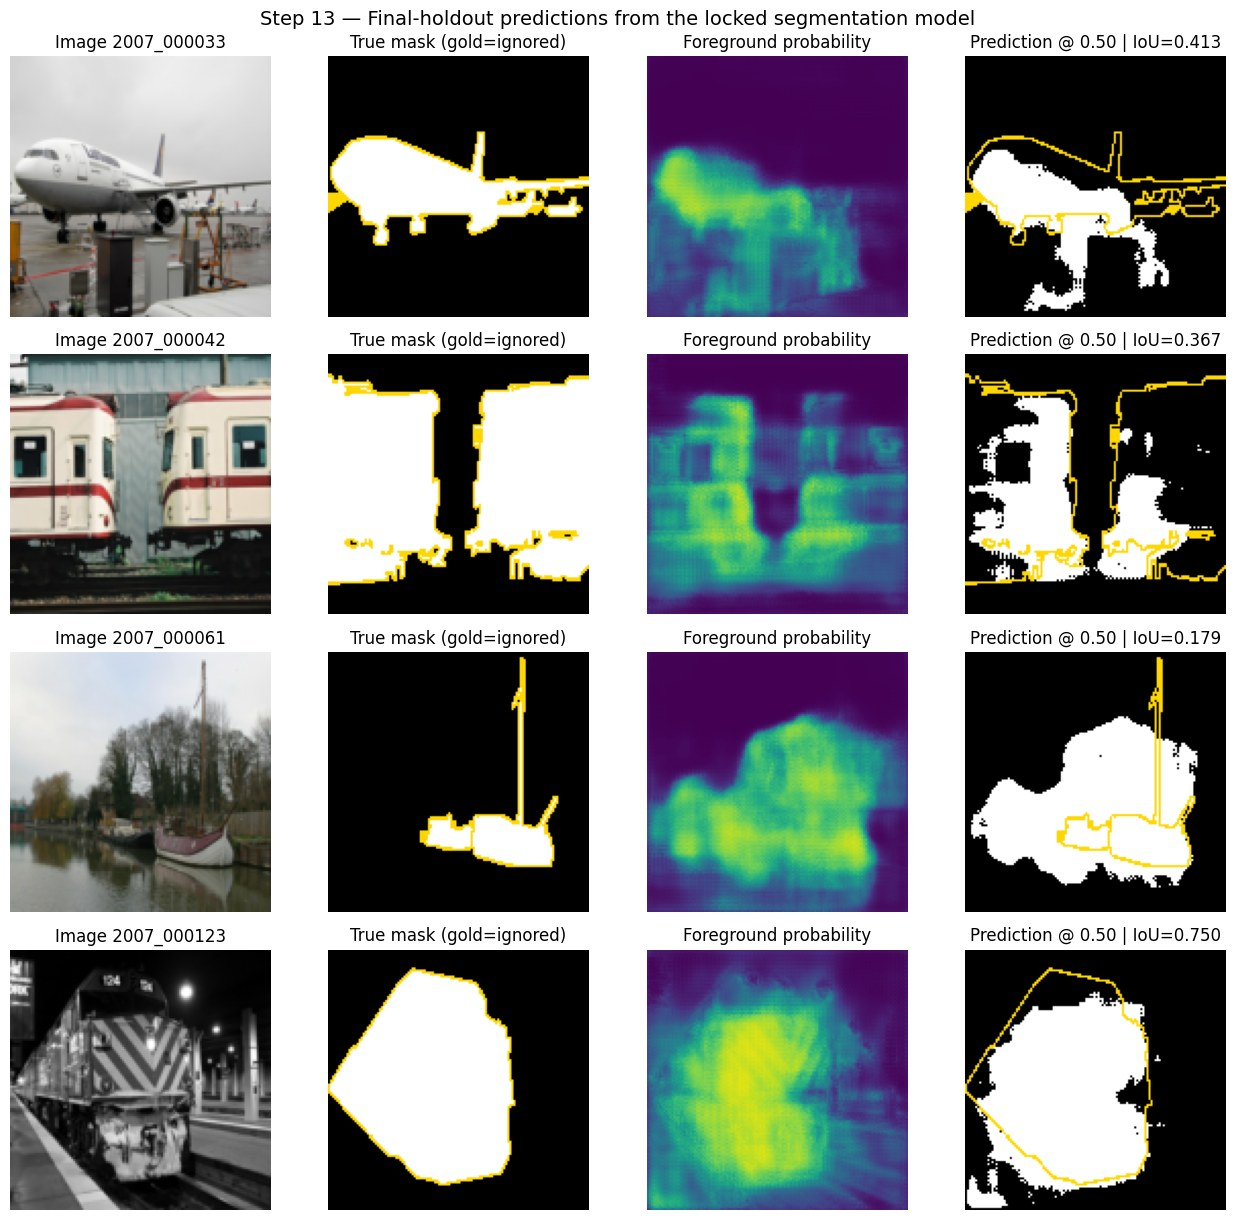


=== Saved Step 13 artifacts ===
Model selection: /kaggle/working/anndl_outputs/step13_segmentation_model_selection.csv
Final metrics: /kaggle/working/anndl_outputs/step13_segmentation_final_holdout_metrics.json
Per-image IoU: /kaggle/working/anndl_outputs/step13_segmentation_final_holdout_per_image.csv
IoU distribution: /kaggle/working/anndl_outputs/step13_segmentation_holdout_iou_distribution.png
Holdout examples: /kaggle/working/anndl_outputs/step13_segmentation_holdout_examples.png
FINAL SEGMENTATION HOLDOUT EVALUATION COMPLETED EXACTLY ONCE.
SEGMENTATION MODEL AND THRESHOLD ARE NOW LOCKED; DO NOT TUNE FURTHER.


In [ ]:
#Step 13: lock the segmentation winner and evaluate the final holdout once

from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import tensorflow as tf


# ---------------------------------------------------------------------------
# 1. Validate the handoff and lock the evaluation protocol
# ---------------------------------------------------------------------------
required_objects = (
    "OUTPUT_DIR",
    "SEGMENTATION_IMAGE_SIZE",
    "SEGMENTATION_BATCH_SIZE",
    "seg_test_ids",
    "seg_test_ds",
    "segmentation_candidate_results",
)
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run the corrected Steps 10, 11, and 12 first. Missing objects: "
        + ", ".join(missing_objects)
    )

if not globals().get("STEP11_SEGMENTATION_BASELINE_COMPLETED", False):
    raise RuntimeError("Step 11 baseline must complete before final evaluation.")
if not globals().get("STEP12_SEGMENTATION_UNET_COMPLETED", False):
    raise RuntimeError("Step 12 U-Net must complete before final evaluation.")
if globals().get("STEP13_SEGMENTATION_FINAL_EVALUATION_COMPLETED", False):
    raise RuntimeError(
        "Step 13 already completed in this session. Do not reevaluate the holdout."
    )

candidate_keys = ("baseline_encoder_decoder", "unet_skip_connections")
missing_candidates = [
    key for key in candidate_keys if key not in segmentation_candidate_results
]
if missing_candidates:
    raise RuntimeError(
        "Segmentation candidate records are incomplete: "
        + ", ".join(missing_candidates)
    )

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

final_metrics_path = OUTPUT_DIR / "step13_segmentation_final_holdout_metrics.json"
final_per_image_path = OUTPUT_DIR / "step13_segmentation_final_holdout_per_image.csv"
final_comparison_path = OUTPUT_DIR / "step13_segmentation_model_selection.csv"
final_distribution_path = OUTPUT_DIR / "step13_segmentation_holdout_iou_distribution.png"
final_examples_path = OUTPUT_DIR / "step13_segmentation_holdout_examples.png"

if final_metrics_path.exists():
    raise RuntimeError(
        "A Step 13 final-holdout result already exists. Do not run this cell again."
    )

SEGMENTATION_FIXED_THRESHOLD = 0.50
expected_test_batches = math.ceil(
    len(seg_test_ids) / SEGMENTATION_BATCH_SIZE
)
actual_test_batches = int(tf.data.experimental.cardinality(seg_test_ds).numpy())
assert actual_test_batches == expected_test_batches


# ---------------------------------------------------------------------------
# 2. Select the winner using internal validation only
# ---------------------------------------------------------------------------
selection_rows = []
for candidate_key in candidate_keys:
    record = segmentation_candidate_results[candidate_key]
    if record.get("final_holdout_evaluated", False):
        raise RuntimeError(
            f"Candidate {candidate_key!r} is marked as already holdout-evaluated."
        )
    validation_metrics = record.get("internal_validation_metrics", {})
    if "foreground_iou" not in validation_metrics:
        raise RuntimeError(
            f"Candidate {candidate_key!r} has no internal-validation IoU."
        )
    selection_rows.append(
        {
            "candidate_key": candidate_key,
            "model_name": record["model_name"],
            "internal_validation_foreground_iou": float(
                validation_metrics["foreground_iou"]
            ),
            "selection_threshold": float(record.get("fixed_threshold", 0.50)),
        }
    )

selection_frame = pd.DataFrame(selection_rows)
assert np.isfinite(
    selection_frame["internal_validation_foreground_iou"].to_numpy()
).all()
assert np.allclose(selection_frame["selection_threshold"], 0.50)

selection_frame["rank"] = selection_frame[
    "internal_validation_foreground_iou"
].rank(method="min", ascending=False).astype(int)
selection_frame = selection_frame.sort_values(
    ["rank", "candidate_key"]
).reset_index(drop=True)
selection_frame["selected"] = selection_frame["rank"].eq(1)

if int(selection_frame["selected"].sum()) != 1:
    raise RuntimeError(
        "The candidates are tied on validation IoU; final evaluation is blocked."
    )

selected_key = str(
    selection_frame.loc[selection_frame["selected"], "candidate_key"].iloc[0]
)
selected_record = segmentation_candidate_results[selected_key]
selected_validation_iou = float(
    selected_record["internal_validation_metrics"]["foreground_iou"]
)

checkpoint_by_candidate = {
    "baseline_encoder_decoder": OUTPUT_DIR
    / "step11_segmentation_baseline_best.keras",
    "unet_skip_connections": OUTPUT_DIR
    / "step12_segmentation_unet_best.keras",
}
selected_checkpoint_path = checkpoint_by_candidate[selected_key]
assert selected_checkpoint_path.exists(), (
    f"Selected checkpoint was not found: {selected_checkpoint_path}"
)

selection_frame.to_csv(final_comparison_path, index=False)

print("=== Step 13 final segmentation protocol ===")
print("Winner selection source: internal validation only")
print("Selection metric: foreground IoU at fixed threshold 0.50")
print("Final holdout: official VOC segmentation validation split")
print("Holdout policy: one inference pass; no tuning after inspection")
print(f"Final-holdout images: {len(seg_test_ids):,}")
print(f"Final-holdout batches: {actual_test_batches}")
print("\n=== Locked model selection ===")
print(
    selection_frame.to_string(
        index=False,
        float_format=lambda value: f"{value:.5f}",
    )
)
print(f"\nSelected candidate: {selected_key}")
print(f"Selected validation foreground IoU: {selected_validation_iou:.5f}")
print(f"Selected checkpoint: {selected_checkpoint_path}")


# ---------------------------------------------------------------------------
# 3. Traverse the final holdout exactly once
# ---------------------------------------------------------------------------
selected_model = tf.keras.models.load_model(selected_checkpoint_path)
assert selected_model.input_shape[1:] == (*SEGMENTATION_IMAGE_SIZE, 3)
assert selected_model.output_shape[1:] == (*SEGMENTATION_IMAGE_SIZE, 1)

final_binary_accuracy = tf.keras.metrics.BinaryAccuracy(
    threshold=SEGMENTATION_FIXED_THRESHOLD,
    name="binary_accuracy",
    dtype="float32",
)
final_foreground_iou = tf.keras.metrics.BinaryIoU(
    target_class_ids=[1],
    threshold=SEGMENTATION_FIXED_THRESHOLD,
    name="foreground_iou",
    dtype="float32",
)
final_foreground_precision = tf.keras.metrics.Precision(
    thresholds=SEGMENTATION_FIXED_THRESHOLD,
    name="foreground_precision",
    dtype="float32",
)
final_foreground_recall = tf.keras.metrics.Recall(
    thresholds=SEGMENTATION_FIXED_THRESHOLD,
    name="foreground_recall",
    dtype="float32",
)
final_metrics = (
    final_binary_accuracy,
    final_foreground_iou,
    final_foreground_precision,
    final_foreground_recall,
)

weighted_bce_sum = 0.0
valid_pixel_count = 0.0
per_image_rows = []
example_payload = None
image_offset = 0

for batch_index, (batch_images, batch_masks, batch_weights) in enumerate(
    seg_test_ds
):
    batch_probabilities = selected_model(batch_images, training=False)
    assert batch_probabilities.shape == batch_masks.shape
    assert float(tf.reduce_min(batch_probabilities)) >= 0.0
    assert float(tf.reduce_max(batch_probabilities)) <= 1.0

    for metric in final_metrics:
        metric.update_state(
            batch_masks,
            batch_probabilities,
            sample_weight=batch_weights,
        )

    clipped_probabilities = tf.clip_by_value(
        batch_probabilities,
        tf.keras.backend.epsilon(),
        1.0 - tf.keras.backend.epsilon(),
    )
    per_pixel_bce = -(
        batch_masks * tf.math.log(clipped_probabilities)
        + (1.0 - batch_masks) * tf.math.log(1.0 - clipped_probabilities)
    )
    weighted_bce_sum += float(tf.reduce_sum(per_pixel_bce * batch_weights))
    valid_pixel_count += float(tf.reduce_sum(batch_weights))

    true_foreground = batch_masks >= 0.5
    predicted_foreground = (
        batch_probabilities >= SEGMENTATION_FIXED_THRESHOLD
    )
    valid_pixels = batch_weights >= 0.5
    intersection = tf.reduce_sum(
        tf.cast(
            tf.logical_and(
                tf.logical_and(true_foreground, predicted_foreground),
                valid_pixels,
            ),
            tf.float32,
        ),
        axis=(1, 2, 3),
    )
    union = tf.reduce_sum(
        tf.cast(
            tf.logical_and(
                tf.logical_or(true_foreground, predicted_foreground),
                valid_pixels,
            ),
            tf.float32,
        ),
        axis=(1, 2, 3),
    )
    sample_ious = tf.math.divide_no_nan(intersection, union).numpy()

    current_batch_size = int(batch_images.shape[0])
    current_ids = np.asarray(seg_test_ids)[
        image_offset : image_offset + current_batch_size
    ]
    assert len(current_ids) == current_batch_size
    for image_id, sample_iou, sample_union in zip(
        current_ids,
        sample_ious,
        union.numpy(),
    ):
        per_image_rows.append(
            {
                "image_id": str(image_id),
                "foreground_iou_at_0.50": float(sample_iou),
                "valid_union_pixels": int(sample_union),
            }
        )

    if batch_index == 0:
        n_examples = min(4, current_batch_size)
        example_payload = (
            batch_images[:n_examples].numpy(),
            batch_masks[:n_examples].numpy(),
            batch_weights[:n_examples].numpy(),
            batch_probabilities[:n_examples].numpy(),
            current_ids[:n_examples].copy(),
        )

    image_offset += current_batch_size

assert image_offset == len(seg_test_ids)
assert len(per_image_rows) == len(seg_test_ids)
assert valid_pixel_count > 0.0
assert example_payload is not None

final_loss = weighted_bce_sum / valid_pixel_count
final_metric_values = {
    "loss": float(final_loss),
    "binary_accuracy": float(final_binary_accuracy.result().numpy()),
    "foreground_iou": float(final_foreground_iou.result().numpy()),
    "foreground_precision": float(final_foreground_precision.result().numpy()),
    "foreground_recall": float(final_foreground_recall.result().numpy()),
}
assert all(np.isfinite(value) for value in final_metric_values.values())

precision = final_metric_values["foreground_precision"]
recall = final_metric_values["foreground_recall"]
final_metric_values["foreground_f1"] = float(
    2.0 * precision * recall / max(precision + recall, 1e-12)
)
final_metric_values["foreground_dice_from_iou"] = float(
    2.0
    * final_metric_values["foreground_iou"]
    / (1.0 + final_metric_values["foreground_iou"])
)

per_image_frame = pd.DataFrame(per_image_rows)
per_image_frame.to_csv(final_per_image_path, index=False)
per_image_summary = {
    "mean": float(per_image_frame["foreground_iou_at_0.50"].mean()),
    "median": float(per_image_frame["foreground_iou_at_0.50"].median()),
    "q25": float(per_image_frame["foreground_iou_at_0.50"].quantile(0.25)),
    "q75": float(per_image_frame["foreground_iou_at_0.50"].quantile(0.75)),
}

print("\n=== Final segmentation holdout metrics ===")
for metric_name, metric_value in final_metric_values.items():
    print(f"{metric_name:>28s}: {metric_value:.5f}")
print("\n=== Per-image foreground IoU distribution ===")
for statistic_name, statistic_value in per_image_summary.items():
    print(f"{statistic_name:>28s}: {statistic_value:.5f}")
print(
    "Validation-to-holdout foreground-IoU change: "
    f"{final_metric_values['foreground_iou'] - selected_validation_iou:+.5f}"
)


# ---------------------------------------------------------------------------
# 4. Save two figures from the same inference pass
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.hist(
    per_image_frame["foreground_iou_at_0.50"],
    bins=np.linspace(0.0, 1.0, 21),
    color="tab:blue",
    edgecolor="white",
    alpha=0.85,
)
ax.axvline(
    per_image_summary["median"],
    color="black",
    linestyle="--",
    label=f"Median = {per_image_summary['median']:.3f}",
)
ax.axvline(
    final_metric_values["foreground_iou"],
    color="tab:red",
    linestyle="-",
    label=f"Aggregated IoU = {final_metric_values['foreground_iou']:.3f}",
)
ax.set_title("Step 13 — Final-holdout per-image foreground IoU")
ax.set_xlabel("Per-image foreground IoU at threshold 0.50")
ax.set_ylabel("Number of images")
ax.set_xlim(0.0, 1.0)
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(final_distribution_path, dpi=180, bbox_inches="tight")
plt.show()

example_images, example_masks, example_weights, example_probabilities, example_ids = (
    example_payload
)
n_examples = len(example_ids)
mask_cmap = ListedColormap(["black", "white", "gold"])
fig, axes = plt.subplots(n_examples, 4, figsize=(13, 3.1 * n_examples))
if n_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n_examples):
    true_mask = example_masks[row, ..., 0] >= 0.5
    valid_mask = example_weights[row, ..., 0] >= 0.5
    probability_map = example_probabilities[row, ..., 0]
    predicted_mask = probability_map >= SEGMENTATION_FIXED_THRESHOLD

    intersection = np.logical_and(true_mask, predicted_mask) & valid_mask
    union = np.logical_or(true_mask, predicted_mask) & valid_mask
    sample_iou = float(intersection.sum() / max(union.sum(), 1))

    true_display = np.where(valid_mask, true_mask.astype(np.uint8), 2)
    prediction_display = np.where(
        valid_mask,
        predicted_mask.astype(np.uint8),
        2,
    )

    axes[row, 0].imshow(example_images[row])
    axes[row, 0].set_title(f"Image {example_ids[row]}")
    axes[row, 1].imshow(true_display, cmap=mask_cmap, vmin=0, vmax=2)
    axes[row, 1].set_title("True mask (gold=ignored)")
    axes[row, 2].imshow(probability_map, cmap="viridis", vmin=0.0, vmax=1.0)
    axes[row, 2].set_title("Foreground probability")
    axes[row, 3].imshow(prediction_display, cmap=mask_cmap, vmin=0, vmax=2)
    axes[row, 3].set_title(f"Prediction @ 0.50 | IoU={sample_iou:.3f}")

    for column in range(4):
        axes[row, column].axis("off")

fig.suptitle(
    "Step 13 — Final-holdout predictions from the locked segmentation model",
    fontsize=14,
)
fig.tight_layout()
fig.savefig(final_examples_path, dpi=180, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------------
# 5. Persist the final, no-more-tuning handoff
# ---------------------------------------------------------------------------
final_result_record = {
    "step": 13,
    "task": "binary_semantic_segmentation",
    "selected_candidate_key": selected_key,
    "selected_model_name": selected_record["model_name"],
    "selected_checkpoint": str(selected_checkpoint_path),
    "selection_split": "internal_validation",
    "selection_metric": "foreground_iou_at_0.50",
    "selected_internal_validation_foreground_iou": selected_validation_iou,
    "final_holdout_split": "official_voc2012_segmentation_val",
    "final_holdout_images": int(len(seg_test_ids)),
    "final_holdout_batches": int(actual_test_batches),
    "fixed_threshold": SEGMENTATION_FIXED_THRESHOLD,
    "final_holdout_metrics": final_metric_values,
    "per_image_iou_summary": per_image_summary,
    "holdout_inference_passes": 1,
    "post_holdout_tuning_allowed": False,
}
final_metrics_path.write_text(
    json.dumps(final_result_record, indent=2),
    encoding="utf-8",
)

segmentation_final_result = final_result_record
STEP13_SEGMENTATION_FINAL_EVALUATION_COMPLETED = True

print("\n=== Saved Step 13 artifacts ===")
print(f"Model selection: {final_comparison_path}")
print(f"Final metrics: {final_metrics_path}")
print(f"Per-image IoU: {final_per_image_path}")
print(f"IoU distribution: {final_distribution_path}")
print(f"Holdout examples: {final_examples_path}")
print("FINAL SEGMENTATION HOLDOUT EVALUATION COMPLETED EXACTLY ONCE.")
print("SEGMENTATION MODEL AND THRESHOLD ARE NOW LOCKED; DO NOT TUNE FURTHER.")


### Final segmentation interpretation

The task merges VOC object labels 1–20 into one foreground class, keeps 0 as background, and excludes void pixels (255) from the loss and metrics. The U-Net's skip connections improved internal-validation foreground IoU from 0.46599 for the baseline encoder-decoder to 0.51003, so the U-Net was locked before holdout evaluation.

On the 1,449-image holdout, the model achieved foreground IoU 0.51007, Dice/F1 0.67556, precision 0.62766, and recall 0.73138. The +0.00004 validation-to-holdout IoU change indicates a very stable aggregate result. The per-image median IoU was 0.52053, with an interquartile range from 0.29835 to 0.69514, showing substantial variation in image difficulty. Foreground IoU and Dice are preferred to pixel accuracy because background pixels are abundant and could otherwise make a weak foreground model look deceptively strong.


# 3. Object detection
## Detection data loading and annotation audit


## Preprocessing the data

Step 14 parses and audits the VOC XML bounding boxes, creates leakage-safe train/internal-validation/final-holdout partitions, and encodes easy objects in an 8 × 8 YOLO-style target with two prediction slots per grid cell. Difficult objects are retained for VOC-compatible evaluation handling. Grid collisions and their representational coverage are quantified explicitly below rather than hidden.


=== Step 14 object-detection protocol ===
Task: 20-class single-stage YOLO-style object detection
Image size: (256, 256)
Prediction grid: 8 x 8
Box slots per grid cell: 2
Box target: centre offsets plus square-root width/height
Difficult VOC objects: ignored for training targets and final AP
Development source: official VOC Main/train split
Final holdout: official VOC Main/val split
Holdout policy: prepare annotations now; infer exactly once after model lock

=== Detection source integrity ===
Audited JPEG/XML pairs: 11,540
Missing JPEGs: 0
Missing XML files: 0
Image/XML dimension mismatches: 0
Invalid labels or boxes: 0
Split overlaps: 0

=== Leakage-safe detection split and grid assignment ===
              split  n_images  total_boxes  easy_boxes  difficult_boxes  truncated_boxes mean_easy_boxes_per_image  images_without_easy_box  encoded_easy_boxes  collision_dropped_easy_boxes encoded_easy_box_%
              train      4574        12596       10855             1741             64

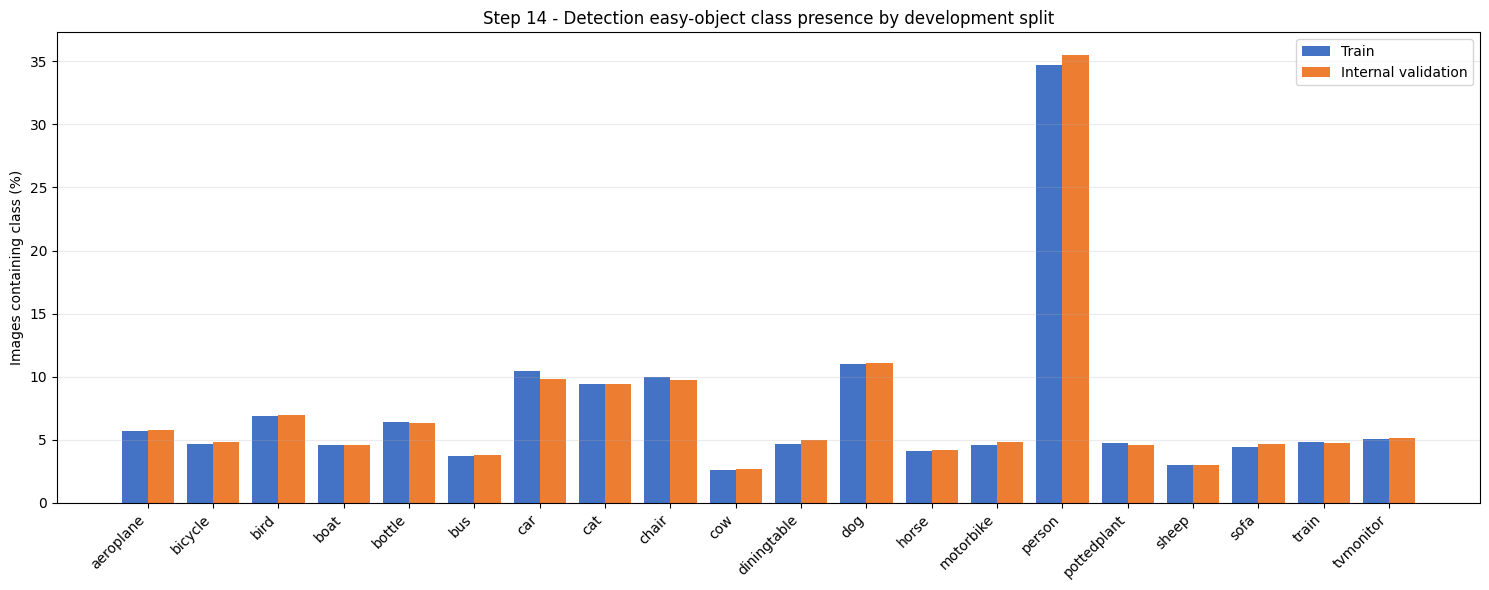

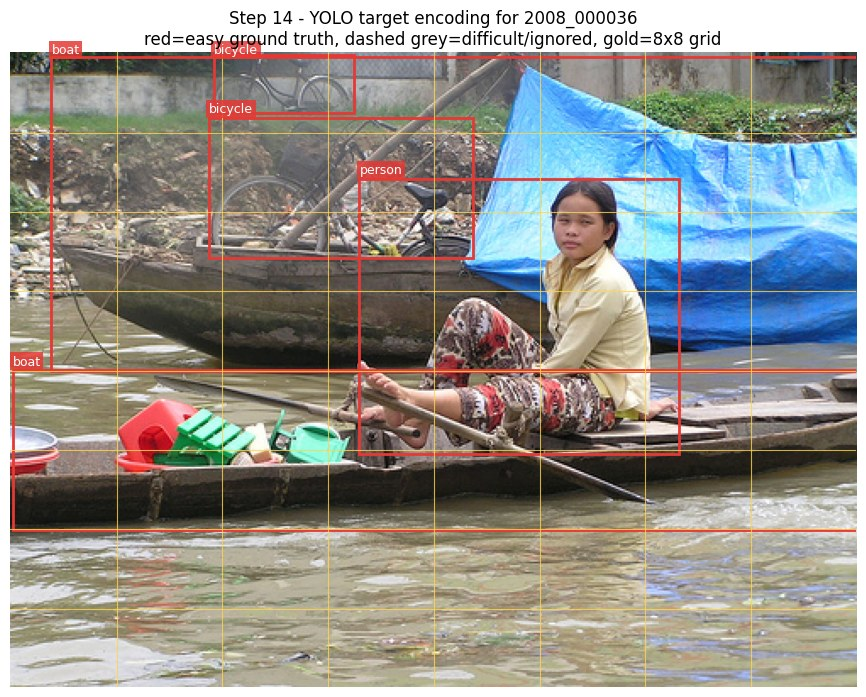


=== Saved Step 14 artifacts ===
Split summary: /kaggle/working/anndl_outputs/step14_detection_split_summary.csv
Class distribution: /kaggle/working/anndl_outputs/step14_detection_class_distribution.csv
Image/grid audit: /kaggle/working/anndl_outputs/step14_detection_image_audit.csv
Class-presence figure: /kaggle/working/anndl_outputs/step14_detection_class_presence.png
Target-encoding figure: /kaggle/working/anndl_outputs/step14_detection_target_encoding.png

DETECTION DATA AUDIT PASSED.
FINAL DETECTION HOLDOUT REMAINS RESERVED FOR ONE MODEL PASS.


In [ ]:
#Step 14: audit and preprocess VOC2012 object-detection data

from pathlib import Path
import math
import xml.etree.ElementTree as ET

from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import tensorflow as tf


# ---------------------------------------------------------------------------
# 1. Validate the handoff and lock the object-detection protocol
# ---------------------------------------------------------------------------
required_objects = (
    "SEED",
    "AUTOTUNE",
    "VOC_ROOT",
    "OUTPUT_DIR",
    "VOC_CLASSES",
    "CLASS_TO_INDEX",
    "train_ids",
    "val_ids",
    "test_ids",
)
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run Steps 01--13 first. Missing objects: "
        + ", ".join(missing_objects)
    )

if not globals().get("STEP13_SEGMENTATION_FINAL_EVALUATION_COMPLETED", False):
    raise RuntimeError(
        "Complete Step 13 before starting the object-detection section."
    )
if globals().get("STEP14_DETECTION_PREPROCESSING_COMPLETED", False):
    raise RuntimeError("Step 14 already completed in this notebook session.")

VOC_ROOT = Path(VOC_ROOT)
OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DETECTION_IMAGE_SIZE = (256, 256)
DETECTION_BATCH_SIZE = 16
DETECTION_GRID_SIZE = 8
DETECTION_BOX_SLOTS = 2
DETECTION_N_CLASSES = len(VOC_CLASSES)
DETECTION_TARGET_DEPTH = 6 + DETECTION_N_CLASSES  # 25 predictions + valid flag

assert DETECTION_N_CLASSES == 20
assert set(CLASS_TO_INDEX) == set(VOC_CLASSES)

print("=== Step 14 object-detection protocol ===")
print("Task: 20-class single-stage YOLO-style object detection")
print(f"Image size: {DETECTION_IMAGE_SIZE}")
print(f"Prediction grid: {DETECTION_GRID_SIZE} x {DETECTION_GRID_SIZE}")
print(f"Box slots per grid cell: {DETECTION_BOX_SLOTS}")
print("Box target: centre offsets plus square-root width/height")
print("Difficult VOC objects: ignored for training targets and final AP")
print("Development source: official VOC Main/train split")
print("Final holdout: official VOC Main/val split")
print("Holdout policy: prepare annotations now; infer exactly once after model lock")


# ---------------------------------------------------------------------------
# 2. Confirm that the existing classification IDs implement this split policy
# ---------------------------------------------------------------------------
def read_detection_split_ids(file_path):
    """Read non-empty VOC image IDs from an official split file."""
    file_path = Path(file_path)
    if not file_path.is_file():
        raise FileNotFoundError(f"Required split file is missing: {file_path}")
    return [
        line.split()[0]
        for line in file_path.read_text().splitlines()
        if line.strip()
    ]


main_split_dir = VOC_ROOT / "ImageSets" / "Main"
official_detection_train_ids = read_detection_split_ids(main_split_dir / "train.txt")
official_detection_holdout_ids = read_detection_split_ids(main_split_dir / "val.txt")

detection_train_ids = np.asarray(train_ids, dtype=str)
detection_val_ids = np.asarray(val_ids, dtype=str)
detection_test_ids = np.asarray(test_ids, dtype=str)

assert len(detection_train_ids) == len(set(detection_train_ids))
assert len(detection_val_ids) == len(set(detection_val_ids))
assert len(detection_test_ids) == len(set(detection_test_ids))
assert set(detection_train_ids).isdisjoint(detection_val_ids)
assert set(detection_train_ids).isdisjoint(detection_test_ids)
assert set(detection_val_ids).isdisjoint(detection_test_ids)
assert set(detection_train_ids) | set(detection_val_ids) == set(
    official_detection_train_ids
), "Detection development IDs do not reconstruct official Main/train."
assert set(detection_test_ids) == set(official_detection_holdout_ids), (
    "Detection final-holdout IDs do not match official Main/val."
)


# ---------------------------------------------------------------------------
# 3. Parse and audit every selected JPEG/XML pair
# ---------------------------------------------------------------------------
def parse_voc_detection_record(image_id, split_name):
    """Parse one VOC XML file into validated relative xywh boxes."""
    image_path = VOC_ROOT / "JPEGImages" / f"{image_id}.jpg"
    xml_path = VOC_ROOT / "Annotations" / f"{image_id}.xml"
    if not image_path.is_file():
        raise FileNotFoundError(f"Missing JPEG image: {image_path}")
    if not xml_path.is_file():
        raise FileNotFoundError(f"Missing XML annotation: {xml_path}")

    root = ET.parse(xml_path).getroot()
    size_node = root.find("size")
    if size_node is None:
        raise ValueError(f"Annotation {image_id} has no <size> node.")
    width = int(size_node.findtext("width", default="0"))
    height = int(size_node.findtext("height", default="0"))
    if width <= 0 or height <= 0:
        raise ValueError(f"Annotation {image_id} has invalid size {width}x{height}.")

    with Image.open(image_path) as image:
        jpeg_width, jpeg_height = image.size
    if (jpeg_width, jpeg_height) != (width, height):
        raise ValueError(
            f"Image/XML size mismatch for {image_id}: "
            f"JPEG={jpeg_width}x{jpeg_height}, XML={width}x{height}."
        )

    objects = []
    for object_node in root.findall("object"):
        label = object_node.findtext("name", default="").strip()
        if label not in CLASS_TO_INDEX:
            raise ValueError(f"Unknown VOC label {label!r} in {image_id}.")

        box_node = object_node.find("bndbox")
        if box_node is None:
            raise ValueError(f"Object in {image_id} has no bounding box.")

        xmin = float(box_node.findtext("xmin", default="nan"))
        ymin = float(box_node.findtext("ymin", default="nan"))
        xmax = float(box_node.findtext("xmax", default="nan"))
        ymax = float(box_node.findtext("ymax", default="nan"))
        raw_box = np.asarray([xmin, ymin, xmax, ymax], dtype=np.float64)
        if not np.isfinite(raw_box).all():
            raise ValueError(f"Non-finite bounding box in {image_id}: {raw_box}")
        if not (0.0 <= xmin < xmax <= width and 0.0 <= ymin < ymax <= height):
            raise ValueError(
                f"Out-of-range bounding box in {image_id}: {raw_box.tolist()} "
                f"for image {width}x{height}."
            )

        # This follows the relative xywh convention in the professor's template.
        relative_x = xmin / width
        relative_y = ymin / height
        relative_width = (xmax - xmin) / width
        relative_height = (ymax - ymin) / height
        centre_x = relative_x + 0.5 * relative_width
        centre_y = relative_y + 0.5 * relative_height

        relative_values = np.asarray(
            [relative_x, relative_y, relative_width, relative_height,
             centre_x, centre_y],
            dtype=np.float64,
        )
        if not np.isfinite(relative_values).all():
            raise ValueError(f"Invalid relative box in {image_id}.")
        if not (
            0.0 <= relative_x < 1.0
            and 0.0 <= relative_y < 1.0
            and 0.0 < relative_width <= 1.0
            and 0.0 < relative_height <= 1.0
            and 0.0 < centre_x < 1.0
            and 0.0 < centre_y < 1.0
        ):
            raise ValueError(
                f"Relative box failed validation in {image_id}: "
                f"{relative_values.tolist()}"
            )

        objects.append(
            {
                "label": label,
                "class_index": int(CLASS_TO_INDEX[label]),
                "box_xywh": np.asarray(
                    [relative_x, relative_y, relative_width, relative_height],
                    dtype=np.float32,
                ),
                "centre_xy": np.asarray([centre_x, centre_y], dtype=np.float32),
                "area": float(relative_width * relative_height),
                "difficult": bool(
                    int(object_node.findtext("difficult", default="0"))
                ),
                "truncated": bool(
                    int(object_node.findtext("truncated", default="0"))
                ),
            }
        )

    if not objects:
        raise ValueError(f"Annotation {image_id} contains no objects.")

    return {
        "image_id": image_id,
        "split": split_name,
        "image_path": str(image_path),
        "width": width,
        "height": height,
        "objects": objects,
    }


detection_records_by_id = {}
detection_split_ids = {
    "train": detection_train_ids,
    "internal_validation": detection_val_ids,
    "final_holdout": detection_test_ids,
}

for split_name, split_image_ids in detection_split_ids.items():
    for image_id in split_image_ids:
        if image_id in detection_records_by_id:
            raise RuntimeError(f"Duplicate detection image ID: {image_id}")
        detection_records_by_id[image_id] = parse_voc_detection_record(
            image_id, split_name
        )

expected_record_count = sum(len(ids) for ids in detection_split_ids.values())
assert len(detection_records_by_id) == expected_record_count


# ---------------------------------------------------------------------------
# 4. Encode a two-slot YOLO-style grid target and quantify collisions
# ---------------------------------------------------------------------------
def encode_detection_target(record):
    """Encode one record and return target plus assignment diagnostics."""
    target = np.zeros(
        (
            DETECTION_GRID_SIZE,
            DETECTION_GRID_SIZE,
            DETECTION_BOX_SLOTS,
            DETECTION_TARGET_DEPTH,
        ),
        dtype=np.float32,
    )
    # Empty slots are valid negative objectness examples by default.
    target[..., -1] = 1.0

    objects_by_cell = {}
    difficult_cells = set()
    n_easy = 0
    n_difficult = 0

    for obj in record["objects"]:
        centre_x, centre_y = (float(value) for value in obj["centre_xy"])
        grid_x = min(DETECTION_GRID_SIZE - 1, int(centre_x * DETECTION_GRID_SIZE))
        grid_y = min(DETECTION_GRID_SIZE - 1, int(centre_y * DETECTION_GRID_SIZE))
        cell_key = (grid_y, grid_x)
        if obj["difficult"]:
            difficult_cells.add(cell_key)
            n_difficult += 1
        else:
            objects_by_cell.setdefault(cell_key, []).append(obj)
            n_easy += 1

    encoded_easy = 0
    dropped_easy = 0
    max_easy_in_one_cell = 0

    for (grid_y, grid_x), cell_objects in objects_by_cell.items():
        # Deterministic slot assignment: larger boxes first, then class index.
        cell_objects = sorted(
            cell_objects,
            key=lambda obj: (-obj["area"], obj["class_index"]),
        )
        max_easy_in_one_cell = max(max_easy_in_one_cell, len(cell_objects))
        assigned_objects = cell_objects[:DETECTION_BOX_SLOTS]
        dropped_easy += max(0, len(cell_objects) - DETECTION_BOX_SLOTS)

        for slot_index, obj in enumerate(assigned_objects):
            centre_x, centre_y = (float(value) for value in obj["centre_xy"])
            _, _, relative_width, relative_height = (
                float(value) for value in obj["box_xywh"]
            )
            target[grid_y, grid_x, slot_index, 0] = 1.0
            target[grid_y, grid_x, slot_index, 1] = (
                centre_x * DETECTION_GRID_SIZE - grid_x
            )
            target[grid_y, grid_x, slot_index, 2] = (
                centre_y * DETECTION_GRID_SIZE - grid_y
            )
            target[grid_y, grid_x, slot_index, 3] = np.sqrt(relative_width)
            target[grid_y, grid_x, slot_index, 4] = np.sqrt(relative_height)
            target[
                grid_y, grid_x, slot_index, 5 + obj["class_index"]
            ] = 1.0
            encoded_easy += 1

        if (grid_y, grid_x) in difficult_cells:
            for slot_index in range(len(assigned_objects), DETECTION_BOX_SLOTS):
                target[grid_y, grid_x, slot_index, -1] = 0.0

    for grid_y, grid_x in difficult_cells - set(objects_by_cell):
        target[grid_y, grid_x, :, -1] = 0.0

    positive_mask = target[..., 0] == 1.0
    if positive_mask.any():
        assert np.all(target[..., -1][positive_mask] == 1.0)
        assert np.allclose(target[..., 5:25][positive_mask].sum(axis=-1), 1.0)
        assert np.all((target[..., 1:3][positive_mask] >= 0.0))
        assert np.all((target[..., 1:3][positive_mask] < 1.0))
        assert np.all((target[..., 3:5][positive_mask] > 0.0))
        assert np.all((target[..., 3:5][positive_mask] <= 1.0))

    diagnostics = {
        "n_easy_boxes": n_easy,
        "n_difficult_boxes": n_difficult,
        "n_encoded_easy_boxes": encoded_easy,
        "n_dropped_easy_boxes": dropped_easy,
        "n_ignored_objectness_slots": int(np.sum(target[..., -1] == 0.0)),
        "max_easy_boxes_in_one_cell": max_easy_in_one_cell,
    }
    assert encoded_easy + dropped_easy == n_easy
    return target, diagnostics


def build_targets_and_audit(split_image_ids):
    """Encode targets in ID order and return image- and grid-level audits."""
    targets = []
    audit_rows = []
    for image_id in split_image_ids:
        record = detection_records_by_id[image_id]
        target, diagnostics = encode_detection_target(record)
        targets.append(target)

        easy_objects = [obj for obj in record["objects"] if not obj["difficult"]]
        difficult_objects = [obj for obj in record["objects"] if obj["difficult"]]
        audit_rows.append(
            {
                "image_id": image_id,
                "split": record["split"],
                "n_boxes": len(record["objects"]),
                "n_easy_boxes": len(easy_objects),
                "n_difficult_boxes": len(difficult_objects),
                "n_truncated_boxes": sum(
                    int(obj["truncated"]) for obj in record["objects"]
                ),
                **diagnostics,
            }
        )

    return np.stack(targets).astype(np.float32), pd.DataFrame(audit_rows)


detection_train_targets, detection_train_audit = build_targets_and_audit(
    detection_train_ids
)
detection_val_targets, detection_val_audit = build_targets_and_audit(
    detection_val_ids
)
detection_test_targets, detection_test_audit = build_targets_and_audit(
    detection_test_ids
)

detection_image_audit = pd.concat(
    [detection_train_audit, detection_val_audit, detection_test_audit],
    ignore_index=True,
)

expected_target_shape = (
    DETECTION_GRID_SIZE,
    DETECTION_GRID_SIZE,
    DETECTION_BOX_SLOTS,
    DETECTION_TARGET_DEPTH,
)
assert detection_train_targets.shape == (len(detection_train_ids), *expected_target_shape)
assert detection_val_targets.shape == (len(detection_val_ids), *expected_target_shape)
assert detection_test_targets.shape == (len(detection_test_ids), *expected_target_shape)


# ---------------------------------------------------------------------------
# 5. Produce split/class summaries without inspecting model predictions
# ---------------------------------------------------------------------------
def summarize_detection_split(split_name, split_image_ids):
    subset = detection_image_audit.loc[
        detection_image_audit["split"].eq(split_name)
    ]
    total_easy = int(subset["n_easy_boxes"].sum())
    total_encoded = int(subset["n_encoded_easy_boxes"].sum())
    total_dropped = int(subset["n_dropped_easy_boxes"].sum())
    return {
        "split": split_name,
        "n_images": len(split_image_ids),
        "total_boxes": int(subset["n_boxes"].sum()),
        "easy_boxes": total_easy,
        "difficult_boxes": int(subset["n_difficult_boxes"].sum()),
        "truncated_boxes": int(subset["n_truncated_boxes"].sum()),
        "mean_easy_boxes_per_image": float(subset["n_easy_boxes"].mean()),
        "images_without_easy_box": int(subset["n_easy_boxes"].eq(0).sum()),
        "encoded_easy_boxes": total_encoded,
        "collision_dropped_easy_boxes": total_dropped,
        "encoded_easy_box_%": (
            100.0 * total_encoded / total_easy if total_easy else np.nan
        ),
    }


detection_split_summary = pd.DataFrame(
    [
        summarize_detection_split("train", detection_train_ids),
        summarize_detection_split("internal_validation", detection_val_ids),
        summarize_detection_split("final_holdout", detection_test_ids),
    ]
)


def class_presence_and_box_counts(split_image_ids):
    presence = np.zeros((len(split_image_ids), DETECTION_N_CLASSES), dtype=np.float32)
    easy_box_counts = np.zeros(DETECTION_N_CLASSES, dtype=np.int64)
    difficult_box_counts = np.zeros(DETECTION_N_CLASSES, dtype=np.int64)

    for row_index, image_id in enumerate(split_image_ids):
        for obj in detection_records_by_id[image_id]["objects"]:
            class_index = obj["class_index"]
            if obj["difficult"]:
                difficult_box_counts[class_index] += 1
            else:
                presence[row_index, class_index] = 1.0
                easy_box_counts[class_index] += 1

    return presence, easy_box_counts, difficult_box_counts


train_detection_presence, train_easy_counts, train_difficult_counts = (
    class_presence_and_box_counts(detection_train_ids)
)
val_detection_presence, val_easy_counts, val_difficult_counts = (
    class_presence_and_box_counts(detection_val_ids)
)
test_detection_presence, test_easy_counts, test_difficult_counts = (
    class_presence_and_box_counts(detection_test_ids)
)

assert np.all(train_easy_counts > 0), "A class has no easy training box."
assert np.all(val_easy_counts > 0), "A class has no easy validation box."
assert np.all(test_easy_counts > 0), "A class has no easy holdout box."

detection_class_distribution = pd.DataFrame(
    {
        "class": VOC_CLASSES,
        "train_easy_boxes": train_easy_counts,
        "internal_validation_easy_boxes": val_easy_counts,
        "final_holdout_easy_boxes": test_easy_counts,
        "train_image_%": 100.0 * train_detection_presence.mean(axis=0),
        "internal_validation_image_%": 100.0 * val_detection_presence.mean(axis=0),
        "final_holdout_image_%": 100.0 * test_detection_presence.mean(axis=0),
        "train_difficult_boxes": train_difficult_counts,
        "internal_validation_difficult_boxes": val_difficult_counts,
        "final_holdout_difficult_boxes": test_difficult_counts,
    }
)

max_detection_internal_gap_pp = float(
    100.0
    * np.max(
        np.abs(
            train_detection_presence.mean(axis=0)
            - val_detection_presence.mean(axis=0)
        )
    )
)

development_easy_boxes = int(
    detection_split_summary.loc[
        detection_split_summary["split"].isin(["train", "internal_validation"]),
        "easy_boxes",
    ].sum()
)
development_dropped_boxes = int(
    detection_split_summary.loc[
        detection_split_summary["split"].isin(["train", "internal_validation"]),
        "collision_dropped_easy_boxes",
    ].sum()
)
development_represented_rate = (
    1.0 - development_dropped_boxes / development_easy_boxes
    if development_easy_boxes
    else np.nan
)

print("\n=== Detection source integrity ===")
print(f"Audited JPEG/XML pairs: {len(detection_records_by_id):,}")
print("Missing JPEGs: 0")
print("Missing XML files: 0")
print("Image/XML dimension mismatches: 0")
print("Invalid labels or boxes: 0")
print("Split overlaps: 0")

print("\n=== Leakage-safe detection split and grid assignment ===")
print(
    detection_split_summary.to_string(
        index=False,
        formatters={
            "mean_easy_boxes_per_image": lambda value: f"{value:.3f}",
            "encoded_easy_box_%": lambda value: f"{value:.3f}",
        },
    )
)
print(
    "Maximum train-vs-internal-validation easy-class presence gap: "
    f"{max_detection_internal_gap_pp:.3f} percentage points"
)
print(
    "Development easy boxes represented by the 8x8 two-slot target: "
    f"{100.0 * development_represented_rate:.3f}%"
)

print("\n=== Per-class detection distribution ===")
print(
    detection_class_distribution.to_string(
        index=False,
        formatters={
            "train_image_%": lambda value: f"{value:.2f}",
            "internal_validation_image_%": lambda value: f"{value:.2f}",
            "final_holdout_image_%": lambda value: f"{value:.2f}",
        },
    )
)


# ---------------------------------------------------------------------------
# 6. Build deterministic tf.data pipelines; do not iterate the holdout
# ---------------------------------------------------------------------------
detection_train_paths = np.asarray(
    [detection_records_by_id[image_id]["image_path"] for image_id in detection_train_ids]
)
detection_val_paths = np.asarray(
    [detection_records_by_id[image_id]["image_path"] for image_id in detection_val_ids]
)
detection_test_paths = np.asarray(
    [detection_records_by_id[image_id]["image_path"] for image_id in detection_test_ids]
)


def load_detection_image(image_path, target):
    """Decode, resize, and normalize an image while preserving its grid target."""
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(
        tf.cast(image, tf.float32),
        DETECTION_IMAGE_SIZE,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True,
    )
    image = tf.clip_by_value(image / 255.0, 0.0, 1.0)
    image.set_shape((*DETECTION_IMAGE_SIZE, 3))
    target.set_shape(expected_target_shape)
    return image, target


def build_detection_dataset(paths, targets, training):
    dataset = tf.data.Dataset.from_tensor_slices((paths, targets))
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=SEED,
            reshuffle_each_iteration=True,
        )
    dataset = dataset.map(
        load_detection_image,
        num_parallel_calls=AUTOTUNE,
        deterministic=not training,
    )
    dataset = dataset.batch(DETECTION_BATCH_SIZE, drop_remainder=False)
    return dataset.prefetch(AUTOTUNE)


det_train_ds = build_detection_dataset(
    detection_train_paths, detection_train_targets, training=True
)
det_val_ds = build_detection_dataset(
    detection_val_paths, detection_val_targets, training=False
)
det_test_ds = build_detection_dataset(
    detection_test_paths, detection_test_targets, training=False
)

expected_train_batches = math.ceil(len(detection_train_ids) / DETECTION_BATCH_SIZE)
expected_val_batches = math.ceil(len(detection_val_ids) / DETECTION_BATCH_SIZE)
expected_test_batches = math.ceil(len(detection_test_ids) / DETECTION_BATCH_SIZE)
assert int(tf.data.experimental.cardinality(det_train_ds).numpy()) == expected_train_batches
assert int(tf.data.experimental.cardinality(det_val_ds).numpy()) == expected_val_batches
assert int(tf.data.experimental.cardinality(det_test_ds).numpy()) == expected_test_batches

probe_images, probe_targets = next(iter(det_train_ds))
assert probe_images.shape[1:] == (*DETECTION_IMAGE_SIZE, 3)
assert probe_targets.shape[1:] == expected_target_shape
assert float(tf.reduce_min(probe_images)) >= 0.0
assert float(tf.reduce_max(probe_images)) <= 1.0
assert set(np.unique(probe_targets[..., 0].numpy()).tolist()).issubset({0.0, 1.0})
assert set(np.unique(probe_targets[..., -1].numpy()).tolist()).issubset({0.0, 1.0})

print("\n=== Detection pipeline probe ===")
print(f"Training batches: {expected_train_batches}")
print(f"Internal-validation batches: {expected_val_batches}")
print(f"Final-holdout batches: {expected_test_batches}")
print(f"Image batch shape: {tuple(probe_images.shape)}")
print(f"Target batch shape: {tuple(probe_targets.shape)}")
print(
    "Image range: "
    f"[{float(tf.reduce_min(probe_images)):.4f}, "
    f"{float(tf.reduce_max(probe_images)):.4f}]"
)
print("Objectness values: {0, 1}")
print("Validity values: {0, 1}")


# ---------------------------------------------------------------------------
# 7. Save bounded tables and figures
# ---------------------------------------------------------------------------
split_summary_path = OUTPUT_DIR / "step14_detection_split_summary.csv"
class_distribution_path = OUTPUT_DIR / "step14_detection_class_distribution.csv"
image_audit_path = OUTPUT_DIR / "step14_detection_image_audit.csv"
distribution_figure_path = OUTPUT_DIR / "step14_detection_class_presence.png"
encoding_figure_path = OUTPUT_DIR / "step14_detection_target_encoding.png"

detection_split_summary.to_csv(split_summary_path, index=False)
detection_class_distribution.to_csv(class_distribution_path, index=False)
detection_image_audit.to_csv(image_audit_path, index=False)

# Figure 1: easy-object image prevalence on the model-selection splits only.
class_positions = np.arange(DETECTION_N_CLASSES)
bar_width = 0.40
fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(
    class_positions - bar_width / 2,
    100.0 * train_detection_presence.mean(axis=0),
    width=bar_width,
    label="Train",
    color="#4472C4",
)
ax.bar(
    class_positions + bar_width / 2,
    100.0 * val_detection_presence.mean(axis=0),
    width=bar_width,
    label="Internal validation",
    color="#ED7D31",
)
ax.set_title("Step 14 - Detection easy-object class presence by development split")
ax.set_ylabel("Images containing class (%)")
ax.set_xticks(class_positions)
ax.set_xticklabels(VOC_CLASSES, rotation=45, ha="right")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(distribution_figure_path, dpi=180, bbox_inches="tight")
plt.show()

# Figure 2: a deterministic internal-validation example with its 8x8 grid.
candidate_ids = []
for image_id in detection_val_ids:
    record = detection_records_by_id[image_id]
    n_easy = sum(not obj["difficult"] for obj in record["objects"])
    if 2 <= n_easy <= 5:
        candidate_ids.append(image_id)
sample_detection_id = candidate_ids[0] if candidate_ids else detection_val_ids[0]
sample_record = detection_records_by_id[sample_detection_id]

with Image.open(sample_record["image_path"]) as sample_image_file:
    sample_image = np.asarray(sample_image_file.convert("RGB"))

fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(sample_image)
image_height, image_width = sample_image.shape[:2]
for obj in sample_record["objects"]:
    x, y, width, height = (float(value) for value in obj["box_xywh"])
    color = "#9E9E9E" if obj["difficult"] else "#E53935"
    line_style = "--" if obj["difficult"] else "-"
    ax.add_patch(
        Rectangle(
            (x * image_width, y * image_height),
            width * image_width,
            height * image_height,
            fill=False,
            edgecolor=color,
            linewidth=2.0,
            linestyle=line_style,
        )
    )
    ax.text(
        x * image_width,
        max(0.0, y * image_height - 3.0),
        obj["label"] + (" (difficult)" if obj["difficult"] else ""),
        color="white",
        fontsize=9,
        bbox={"facecolor": color, "alpha": 0.85, "pad": 2, "edgecolor": "none"},
    )

for grid_index in range(1, DETECTION_GRID_SIZE):
    ax.axvline(
        grid_index * image_width / DETECTION_GRID_SIZE,
        color="#FFD54F",
        linewidth=0.8,
        alpha=0.8,
    )
    ax.axhline(
        grid_index * image_height / DETECTION_GRID_SIZE,
        color="#FFD54F",
        linewidth=0.8,
        alpha=0.8,
    )

ax.set_title(
    f"Step 14 - YOLO target encoding for {sample_detection_id}\n"
    "red=easy ground truth, dashed grey=difficult/ignored, gold=8x8 grid"
)
ax.set_axis_off()
fig.tight_layout()
fig.savefig(encoding_figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("\n=== Saved Step 14 artifacts ===")
print(f"Split summary: {split_summary_path}")
print(f"Class distribution: {class_distribution_path}")
print(f"Image/grid audit: {image_audit_path}")
print(f"Class-presence figure: {distribution_figure_path}")
print(f"Target-encoding figure: {encoding_figure_path}")

STEP14_DETECTION_PREPROCESSING_COMPLETED = True

print("\nDETECTION DATA AUDIT PASSED.")
print("FINAL DETECTION HOLDOUT REMAINS RESERVED FOR ONE MODEL PASS.")


## Detection model development


=== Step 15 improved YOLO-style detector protocol ===
Development data: Step 14 train/internal-validation splits only
Backbone: ImageNet-pretrained Xception at 8x8 spatial resolution
Prediction: 8x8 grid, two box slots, 20 VOC classes
Warm-up: 6 epochs with frozen backbone
Fine-tuning: up to 20 epochs, early-stopping patience 6
Primary selection metric: VOC-style mAP@0.50
Post-processing: class-aware NMS at IoU 0.50
Difficult VOC objects: ignored in AP matching
Final detection holdout: reserved; no inference in this step

=== Detector architecture probe ===
Model output shape: (2, 8, 8, 2, 25)
Total parameters: 22,080,090
Warm-up trainable parameters: 1,217,074
Frozen Xception BatchNorm statistics: True
Initial loss components: total=5.54203, objectness=0.69314, box=0.37061, class=2.99584



=== Phase A: frozen-backbone warm-up ===
Epoch 1/6


E0000 00:00:1785688386.986714      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/voc2012_improved_yolo_trainer_1/voc2012_improved_yolo_1/detection_head_dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - box_loss: 0.2490 - class_loss: 1.7898 - loss: 3.4284 - objectness_loss: 0.3808
Epoch 01 validation mAP@0.50: 0.01692  [best checkpoint saved]
286/286 ━━━━━━━━━━━━━━━━━━━━ 60s 189ms/step - box_loss: 0.2345 - class_loss: 1.3068 - loss: 2.8104 - objectness_loss: 0.3177 - val_box_loss: 0.2551 - val_class_loss: 1.5215 - val_loss: 3.1170 - val_objectness_loss: 0.3051 - val_map50: 0.0169
Epoch 2/6
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - box_loss: 0.2064 - class_loss: 0.7815 - loss: 2.0989 - objectness_loss: 0.2695
Epoch 02 validation mAP@0.50: 0.14278  [best checkpoint saved]
286/286 ━━━━━━━━━━━━━━━━━━━━ 53s 184ms/step - box_loss: 0.2076 - class_loss: 0.7808 - loss: 2.0960 - objectness_loss: 0.2609 - val_box_loss: 0.2150 - val_class_loss: 0.9443 - val_loss: 2.3017 - val_objectness_loss: 0.2642 - val_map50: 0.1428
Epoch 3/6
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - box_loss: 0.1864 - class_loss: 0.5711 - loss: 1.7720 - objectness_loss: 0.249

E0000 00:00:1785688712.393679      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/voc2012_improved_yolo_trainer_1/voc2012_improved_yolo_1/detection_head_dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - box_loss: 0.1092 - class_loss: 0.1847 - loss: 0.9801 - objectness_loss: 0.2175
Epoch 07 validation mAP@0.50: 0.19987
286/286 ━━━━━━━━━━━━━━━━━━━━ 63s 198ms/step - box_loss: 0.1049 - class_loss: 0.1754 - loss: 0.9470 - objectness_loss: 0.2153 - val_box_loss: 0.2210 - val_class_loss: 1.0171 - val_loss: 2.4060 - val_objectness_loss: 0.2517 - val_map50: 0.1999
Epoch 8/26
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - box_loss: 0.0960 - class_loss: 0.1523 - loss: 0.8787 - objectness_loss: 0.2141
Epoch 08 validation mAP@0.50: 0.20166
286/286 ━━━━━━━━━━━━━━━━━━━━ 55s 192ms/step - box_loss: 0.0951 - class_loss: 0.1442 - loss: 0.8629 - objectness_loss: 0.2111 - val_box_loss: 0.2210 - val_class_loss: 1.0245 - val_loss: 2.4120 - val_objectness_loss: 0.2503 - val_map50: 0.2017
Epoch 9/26
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - box_loss: 0.0900 - class_loss: 0.1205 - loss: 0.8103 - objectness_loss: 0.2079
Epoch 09 validation mAP@0.50: 0.20388
286/286 

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 30 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



=== Restored best internal-validation detector ===
Best epoch: 4
Best phase: frozen_backbone_warmup
Validation loss: 2.33439
VOC-style mAP@0.50: 0.21395
Slot objectness precision@0.50: 0.17021
Slot objectness recall@0.50: 0.59196
Positive-slot class accuracy: 0.72285

=== Internal-validation AP@0.50 by VOC class ===
      class  validation_easy_ground_truth_boxes    ap50 terminal_precision terminal_recall
  aeroplane                                  80 0.46423            0.02481         0.72500
    bicycle                                  72 0.19010            0.02033         0.63889
       bird                                 107 0.12384            0.01309         0.47664
       boat                                  77 0.08923            0.00810         0.37662
     bottle                                 131 0.02597            0.00266         0.15267
        bus                                  52 0.45566            0.02510         0.71154
        car                                 

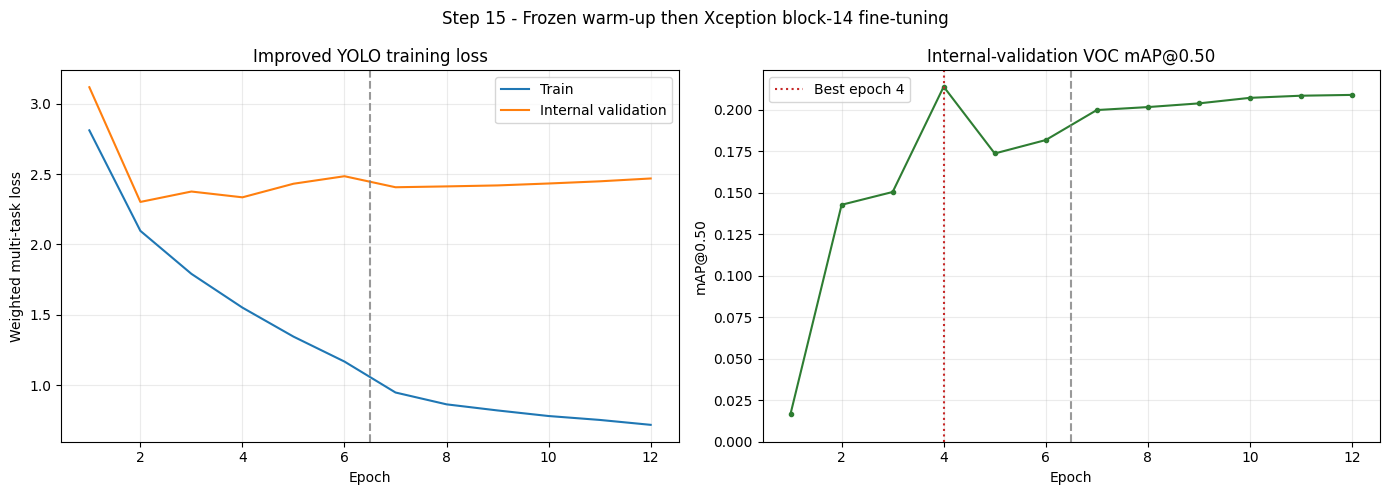

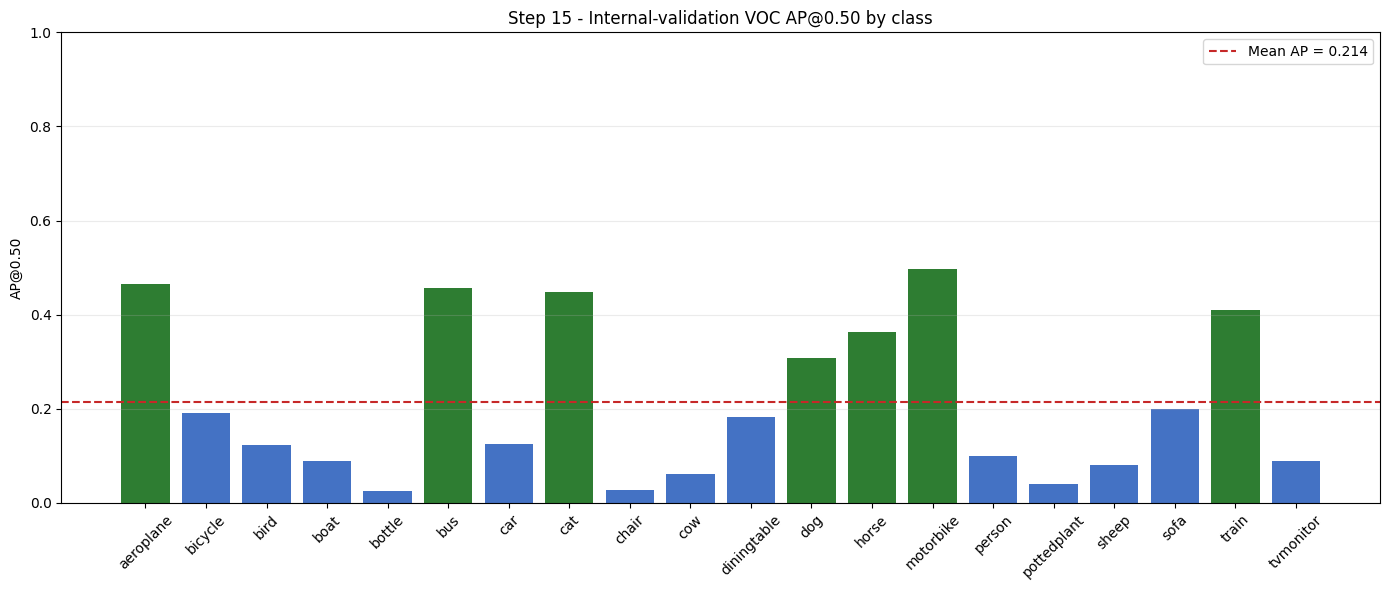

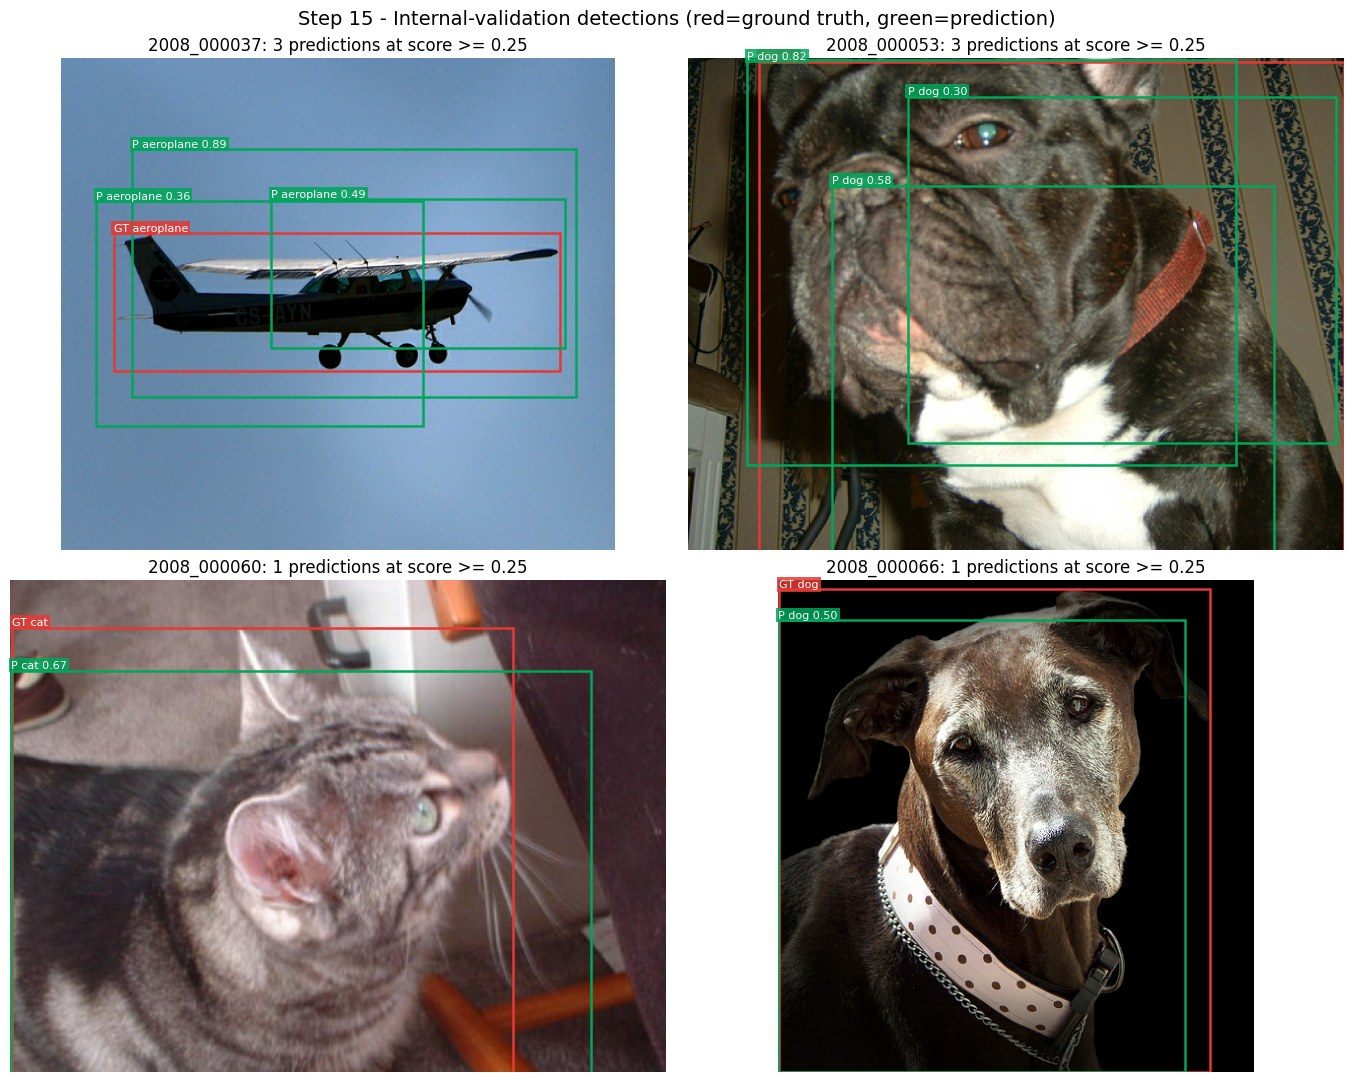


=== Saved Step 15 artifacts ===
Best weights: /kaggle/working/anndl_outputs/step15_yolo_detector_best.weights.h5
Model summary: /kaggle/working/anndl_outputs/step15_yolo_detector_summary.txt
Training history: /kaggle/working/anndl_outputs/step15_yolo_training_history.csv
Validation metrics: /kaggle/working/anndl_outputs/step15_yolo_internal_validation_metrics.json
Per-class AP: /kaggle/working/anndl_outputs/step15_yolo_internal_validation_ap50.csv
Learning curves: /kaggle/working/anndl_outputs/step15_yolo_learning_curves.png
Per-class AP figure: /kaggle/working/anndl_outputs/step15_yolo_per_class_ap50.png
Validation examples: /kaggle/working/anndl_outputs/step15_yolo_validation_examples.png

FINAL DETECTION HOLDOUT REMAINS RESERVED FOR ONE MODEL PASS.
DETECTOR SELECTED BY INTERNAL-VALIDATION mAP@0.50 ONLY.


In [ ]:
#Step 15: build, train, and validate the improved YOLO-style detector

from pathlib import Path
import gc
import json

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import tensorflow as tf


# ---------------------------------------------------------------------------
# 1. Validate the Step 14 handoff and lock the training/evaluation protocol
# ---------------------------------------------------------------------------
required_objects = (
    "SEED",
    "OUTPUT_DIR",
    "VOC_CLASSES",
    "DETECTION_IMAGE_SIZE",
    "DETECTION_GRID_SIZE",
    "DETECTION_BOX_SLOTS",
    "DETECTION_N_CLASSES",
    "DETECTION_TARGET_DEPTH",
    "detection_train_ids",
    "detection_val_ids",
    "detection_records_by_id",
    "train_easy_counts",
    "det_train_ds",
    "det_val_ds",
    "det_test_ds",
)
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run Steps 01--14 first. Missing objects: " + ", ".join(missing_objects)
    )

if not globals().get("STEP14_DETECTION_PREPROCESSING_COMPLETED", False):
    raise RuntimeError("Complete Step 14 before running Step 15.")
if globals().get("STEP15_DETECTION_TRAINING_COMPLETED", False):
    raise RuntimeError("Step 15 already completed in this notebook session.")

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert tuple(DETECTION_IMAGE_SIZE) == (256, 256)
assert DETECTION_GRID_SIZE == 8
assert DETECTION_BOX_SLOTS == 2
assert DETECTION_N_CLASSES == 20
assert DETECTION_TARGET_DEPTH == 26

WARMUP_EPOCHS = 6
TOTAL_EPOCHS = 26
FINE_TUNE_PATIENCE = 6
BOX_LOSS_WEIGHT = 5.0
NO_OBJECT_WEIGHT = 0.10
AP_IOU_THRESHOLD = 0.50
NMS_IOU_THRESHOLD = 0.50
AP_SCORE_FLOOR = 0.001
VISUAL_SCORE_THRESHOLD = 0.25
MAX_DETECTIONS_PER_IMAGE = 100
BEST_WEIGHTS_PATH = OUTPUT_DIR / "step15_yolo_detector_best.weights.h5"

tf.keras.utils.set_random_seed(SEED)

print("=== Step 15 improved YOLO-style detector protocol ===")
print("Development data: Step 14 train/internal-validation splits only")
print("Backbone: ImageNet-pretrained Xception at 8x8 spatial resolution")
print("Prediction: 8x8 grid, two box slots, 20 VOC classes")
print(f"Warm-up: {WARMUP_EPOCHS} epochs with frozen backbone")
print(
    "Fine-tuning: up to "
    f"{TOTAL_EPOCHS - WARMUP_EPOCHS} epochs, early-stopping patience "
    f"{FINE_TUNE_PATIENCE}"
)
print(f"Primary selection metric: VOC-style mAP@{AP_IOU_THRESHOLD:.2f}")
print(
    "Post-processing: class-aware NMS at IoU "
    f"{NMS_IOU_THRESHOLD:.2f}"
)
print("Difficult VOC objects: ignored in AP matching")
print("Final detection holdout: reserved; no inference in this step")


# ---------------------------------------------------------------------------
# 2. Class-balanced training constants and the YOLO loss
# ---------------------------------------------------------------------------
train_easy_counts_array = np.asarray(train_easy_counts, dtype=np.float32)
if train_easy_counts_array.shape != (DETECTION_N_CLASSES,):
    raise RuntimeError("Unexpected train_easy_counts shape.")
if np.any(train_easy_counts_array <= 0):
    raise RuntimeError("Every VOC class needs at least one easy training box.")

# Square-root inverse frequency moderates the very large VOC class imbalance
# without allowing a rare class to dominate the gradients.
median_class_count = float(np.median(train_easy_counts_array))
detection_class_weights_np = np.sqrt(
    median_class_count / train_easy_counts_array
)
detection_class_weights_np = np.clip(
    detection_class_weights_np, 0.50, 2.50
).astype(np.float32)
detection_class_weights = tf.constant(
    detection_class_weights_np, dtype=tf.float32
)


def yolo_loss_components(y_true, y_pred):
    """Return total, objectness, box, and class losses."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    object_true = y_true[..., 0]
    xy_true = y_true[..., 1:3]
    sqrt_wh_true = y_true[..., 3:5]
    class_true = y_true[..., 5:25]
    valid_objectness = y_true[..., 25]

    object_logits = y_pred[..., 0]
    xy_pred = tf.sigmoid(y_pred[..., 1:3])
    sqrt_wh_pred = tf.sigmoid(y_pred[..., 3:5])
    class_logits = y_pred[..., 5:25]

    positive = object_true * valid_objectness
    positive_count = tf.maximum(tf.reduce_sum(positive), 1.0)

    object_ce = tf.nn.sigmoid_cross_entropy_with_logits(
        labels=object_true, logits=object_logits
    )
    object_weights = valid_objectness * (
        positive + NO_OBJECT_WEIGHT * (1.0 - object_true)
    )
    objectness_loss = tf.math.divide_no_nan(
        tf.reduce_sum(object_ce * object_weights),
        tf.reduce_sum(object_weights),
    )

    coordinate_error = tf.reduce_sum(
        tf.square(xy_pred - xy_true)
        + tf.square(sqrt_wh_pred - sqrt_wh_true),
        axis=-1,
    )
    box_loss = tf.reduce_sum(coordinate_error * positive) / positive_count

    class_ce = tf.nn.softmax_cross_entropy_with_logits(
        labels=class_true, logits=class_logits
    )
    positive_class_weight = tf.reduce_sum(
        class_true * detection_class_weights, axis=-1
    )
    class_denominator = tf.maximum(
        tf.reduce_sum(positive * positive_class_weight), 1.0
    )
    class_loss = (
        tf.reduce_sum(class_ce * positive * positive_class_weight)
        / class_denominator
    )

    total_loss = (
        objectness_loss + BOX_LOSS_WEIGHT * box_loss + class_loss
    )
    return total_loss, objectness_loss, box_loss, class_loss


class YoloTrainingModel(tf.keras.Model):
    """Keras wrapper with transparent YOLO loss-component reporting."""

    def __init__(self, detector_network):
        super().__init__(name="voc2012_improved_yolo_trainer")
        self.detector_network = detector_network
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.object_loss_tracker = tf.keras.metrics.Mean(
            name="objectness_loss"
        )
        self.box_loss_tracker = tf.keras.metrics.Mean(name="box_loss")
        self.class_loss_tracker = tf.keras.metrics.Mean(name="class_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.object_loss_tracker,
            self.box_loss_tracker,
            self.class_loss_tracker,
        ]

    def call(self, inputs, training=False):
        return self.detector_network(inputs, training=training)

    def _update_trackers(self, losses, batch_size):
        for tracker, value in zip(self.metrics, losses):
            tracker.update_state(value, sample_weight=batch_size)

    def train_step(self, data):
        images, targets = data
        with tf.GradientTape() as tape:
            predictions = self(images, training=True)
            losses = yolo_loss_components(targets, predictions)
            regularization_loss = (
                tf.add_n(self.losses) if self.losses else 0.0
            )
            optimized_loss = losses[0] + regularization_loss

        trainable_variables = self.trainable_variables
        gradients = tape.gradient(optimized_loss, trainable_variables)
        gradient_variable_pairs = [
            (gradient, variable)
            for gradient, variable in zip(gradients, trainable_variables)
            if gradient is not None
        ]
        self.optimizer.apply_gradients(gradient_variable_pairs)
        batch_size = tf.cast(tf.shape(images)[0], tf.float32)
        reported_losses = (
            optimized_loss,
            losses[1],
            losses[2],
            losses[3],
        )
        self._update_trackers(reported_losses, batch_size)
        return {tracker.name: tracker.result() for tracker in self.metrics}

    def test_step(self, data):
        images, targets = data
        predictions = self(images, training=False)
        losses = yolo_loss_components(targets, predictions)
        regularization_loss = tf.add_n(self.losses) if self.losses else 0.0
        batch_size = tf.cast(tf.shape(images)[0], tf.float32)
        reported_losses = (
            losses[0] + regularization_loss,
            losses[1],
            losses[2],
            losses[3],
        )
        self._update_trackers(reported_losses, batch_size)
        return {tracker.name: tracker.result() for tracker in self.metrics}


# ---------------------------------------------------------------------------
# 3. Build a spatial Xception detector; keep BatchNorm inference statistics
# ---------------------------------------------------------------------------
gc.collect()
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

detector_inputs = tf.keras.Input(
    shape=(*DETECTION_IMAGE_SIZE, 3), name="detection_image"
)

# Photometric augmentation is target-safe.  Geometric augmentation is omitted
# here because it would also require transforming the encoded grid targets.
augmented = tf.keras.layers.RandomContrast(
    factor=0.10, seed=SEED, name="random_contrast"
)(detector_inputs)
augmented = tf.keras.layers.GaussianNoise(
    stddev=0.015, seed=SEED, name="gaussian_noise"
)(augmented)
augmented = tf.keras.layers.ReLU(
    max_value=1.0, name="clip_augmented_rgb"
)(augmented)
preprocessed = tf.keras.layers.Rescaling(
    scale=2.0, offset=-1.0, name="xception_preprocessing"
)(augmented)

detection_backbone = tf.keras.applications.Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(*DETECTION_IMAGE_SIZE, 3),
)
detection_backbone._name = "detection_xception_backbone"
detection_backbone.trainable = False

# training=False is intentional: even when the last convolutional block is
# fine-tuned, pretrained BatchNorm moving statistics remain frozen.
features = detection_backbone(preprocessed, training=False)
if tuple(features.shape[1:3]) != (
    DETECTION_GRID_SIZE,
    DETECTION_GRID_SIZE,
):
    raise RuntimeError(
        "Xception output does not match the locked 8x8 detection grid: "
        f"{features.shape}"
    )

x = tf.keras.layers.SeparableConv2D(
    512,
    3,
    padding="same",
    use_bias=False,
    depthwise_regularizer=tf.keras.regularizers.l2(1e-5),
    pointwise_regularizer=tf.keras.regularizers.l2(1e-5),
    name="detection_head_sepconv_1",
)(features)
x = tf.keras.layers.BatchNormalization(name="detection_head_bn_1")(x)
x = tf.keras.layers.Activation("relu", name="detection_head_relu_1")(x)
x = tf.keras.layers.SeparableConv2D(
    256,
    3,
    padding="same",
    use_bias=False,
    depthwise_regularizer=tf.keras.regularizers.l2(1e-5),
    pointwise_regularizer=tf.keras.regularizers.l2(1e-5),
    name="detection_head_sepconv_2",
)(x)
x = tf.keras.layers.BatchNormalization(name="detection_head_bn_2")(x)
x = tf.keras.layers.Activation("relu", name="detection_head_relu_2")(x)
x = tf.keras.layers.Dropout(0.25, seed=SEED, name="detection_head_dropout")(x)

prediction_depth = 5 + DETECTION_N_CLASSES
raw_output = tf.keras.layers.Conv2D(
    DETECTION_BOX_SLOTS * prediction_depth,
    1,
    padding="same",
    kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.01),
    bias_initializer="zeros",
    name="raw_detection_output",
)(x)
detector_outputs = tf.keras.layers.Reshape(
    (
        DETECTION_GRID_SIZE,
        DETECTION_GRID_SIZE,
        DETECTION_BOX_SLOTS,
        prediction_depth,
    ),
    name="grid_slot_predictions",
)(raw_output)

detector_network = tf.keras.Model(
    detector_inputs, detector_outputs, name="voc2012_improved_yolo"
)
detector_model = YoloTrainingModel(detector_network)

probe_images, probe_targets = next(iter(det_train_ds))
probe_predictions = detector_model(probe_images[:2], training=False)
assert tuple(probe_predictions.shape) == (
    2,
    DETECTION_GRID_SIZE,
    DETECTION_GRID_SIZE,
    DETECTION_BOX_SLOTS,
    prediction_depth,
)
probe_losses = yolo_loss_components(probe_targets[:2], probe_predictions)
assert all(np.isfinite(float(value.numpy())) for value in probe_losses)

total_parameters = int(detector_network.count_params())
trainable_warmup_parameters = int(
    np.sum([np.prod(variable.shape) for variable in detector_model.trainable_weights])
)

print("\n=== Detector architecture probe ===")
print(f"Model output shape: {tuple(probe_predictions.shape)}")
print(f"Total parameters: {total_parameters:,}")
print(f"Warm-up trainable parameters: {trainable_warmup_parameters:,}")
print("Frozen Xception BatchNorm statistics: True")
print(
    "Initial loss components: "
    f"total={float(probe_losses[0]):.5f}, "
    f"objectness={float(probe_losses[1]):.5f}, "
    f"box={float(probe_losses[2]):.5f}, "
    f"class={float(probe_losses[3]):.5f}"
)

summary_path = OUTPUT_DIR / "step15_yolo_detector_summary.txt"
with summary_path.open("w") as summary_file:
    detector_network.summary(
        print_fn=lambda line: summary_file.write(line + "\n")
    )


# ---------------------------------------------------------------------------
# 4. Decode predictions, apply class-aware NMS, and compute VOC-style AP
# ---------------------------------------------------------------------------
def sigmoid_np(values):
    values = np.asarray(values, dtype=np.float32)
    return 1.0 / (1.0 + np.exp(-np.clip(values, -30.0, 30.0)))


def softmax_np(values):
    values = np.asarray(values, dtype=np.float32)
    shifted = values - np.max(values, axis=-1, keepdims=True)
    exponentials = np.exp(shifted)
    return exponentials / np.sum(exponentials, axis=-1, keepdims=True)


def decode_and_nms(raw_predictions):
    """Decode an [N,8,8,2,25] tensor into class-aware detections."""
    raw_predictions = np.asarray(raw_predictions, dtype=np.float32)
    expected_shape = (
        DETECTION_GRID_SIZE,
        DETECTION_GRID_SIZE,
        DETECTION_BOX_SLOTS,
        prediction_depth,
    )
    if raw_predictions.shape[1:] != expected_shape:
        raise ValueError(
            f"Unexpected raw detection shape: {raw_predictions.shape}"
        )

    n_images = raw_predictions.shape[0]
    object_probability = sigmoid_np(raw_predictions[..., 0])
    xy_offset = sigmoid_np(raw_predictions[..., 1:3])
    relative_wh = np.square(sigmoid_np(raw_predictions[..., 3:5]))
    class_probability = softmax_np(raw_predictions[..., 5:25])

    grid_y, grid_x = np.meshgrid(
        np.arange(DETECTION_GRID_SIZE, dtype=np.float32),
        np.arange(DETECTION_GRID_SIZE, dtype=np.float32),
        indexing="ij",
    )
    grid_x = grid_x[None, :, :, None]
    grid_y = grid_y[None, :, :, None]
    centre_x = (grid_x + xy_offset[..., 0]) / DETECTION_GRID_SIZE
    centre_y = (grid_y + xy_offset[..., 1]) / DETECTION_GRID_SIZE
    width = relative_wh[..., 0]
    height = relative_wh[..., 1]

    x_min = np.clip(centre_x - 0.5 * width, 0.0, 1.0)
    y_min = np.clip(centre_y - 0.5 * height, 0.0, 1.0)
    x_max = np.clip(centre_x + 0.5 * width, 0.0, 1.0)
    y_max = np.clip(centre_y + 0.5 * height, 0.0, 1.0)

    boxes_yxyx = np.stack([y_min, x_min, y_max, x_max], axis=-1)
    boxes_yxyx = boxes_yxyx.reshape(n_images, -1, 1, 4)
    scores = (
        object_probability[..., None] * class_probability
    ).reshape(n_images, -1, DETECTION_N_CLASSES)

    nms = tf.image.combined_non_max_suppression(
        boxes=tf.convert_to_tensor(boxes_yxyx, dtype=tf.float32),
        scores=tf.convert_to_tensor(scores, dtype=tf.float32),
        max_output_size_per_class=50,
        max_total_size=MAX_DETECTIONS_PER_IMAGE,
        iou_threshold=NMS_IOU_THRESHOLD,
        score_threshold=AP_SCORE_FLOOR,
        clip_boxes=True,
    )

    nms_boxes = nms.nmsed_boxes.numpy()
    nms_scores = nms.nmsed_scores.numpy()
    nms_classes = nms.nmsed_classes.numpy().astype(np.int32)
    valid_detections = nms.valid_detections.numpy().astype(np.int32)

    detections = []
    for image_index in range(n_images):
        n_valid = int(valid_detections[image_index])
        # Convert yxyx back to xyxy for evaluation/plotting.
        boxes = nms_boxes[image_index, :n_valid]
        boxes_xyxy = boxes[:, [1, 0, 3, 2]]
        detections.append(
            {
                "boxes": boxes_xyxy.astype(np.float32),
                "scores": nms_scores[image_index, :n_valid].astype(np.float32),
                "classes": nms_classes[image_index, :n_valid],
            }
        )
    return detections


def relative_xywh_to_xyxy(box_xywh):
    x, y, width, height = (float(value) for value in box_xywh)
    return np.asarray([x, y, x + width, y + height], dtype=np.float32)


def box_iou_one_to_many(box, boxes):
    boxes = np.asarray(boxes, dtype=np.float32)
    if boxes.size == 0:
        return np.zeros(0, dtype=np.float32)
    intersection_xmin = np.maximum(box[0], boxes[:, 0])
    intersection_ymin = np.maximum(box[1], boxes[:, 1])
    intersection_xmax = np.minimum(box[2], boxes[:, 2])
    intersection_ymax = np.minimum(box[3], boxes[:, 3])
    intersection_width = np.maximum(0.0, intersection_xmax - intersection_xmin)
    intersection_height = np.maximum(0.0, intersection_ymax - intersection_ymin)
    intersection = intersection_width * intersection_height
    box_area = max(0.0, (box[2] - box[0]) * (box[3] - box[1]))
    boxes_area = np.maximum(0.0, boxes[:, 2] - boxes[:, 0]) * np.maximum(
        0.0, boxes[:, 3] - boxes[:, 1]
    )
    union = box_area + boxes_area - intersection
    return np.divide(
        intersection,
        union,
        out=np.zeros_like(intersection),
        where=union > 0.0,
    )


def all_points_interpolated_ap(recall, precision):
    augmented_recall = np.concatenate(([0.0], recall, [1.0]))
    augmented_precision = np.concatenate(([0.0], precision, [0.0]))
    for index in range(len(augmented_precision) - 2, -1, -1):
        augmented_precision[index] = max(
            augmented_precision[index], augmented_precision[index + 1]
        )
    change_indices = np.where(
        augmented_recall[1:] != augmented_recall[:-1]
    )[0]
    return float(
        np.sum(
            (augmented_recall[change_indices + 1] - augmented_recall[change_indices])
            * augmented_precision[change_indices + 1]
        )
    )


def prepare_validation_ground_truth():
    ground_truth = {
        class_index: {} for class_index in range(DETECTION_N_CLASSES)
    }
    positive_count = np.zeros(DETECTION_N_CLASSES, dtype=np.int64)
    for image_id in detection_val_ids:
        per_class_easy = {index: [] for index in range(DETECTION_N_CLASSES)}
        per_class_difficult = {index: [] for index in range(DETECTION_N_CLASSES)}
        for obj in detection_records_by_id[image_id]["objects"]:
            class_index = int(obj["class_index"])
            box = relative_xywh_to_xyxy(obj["box_xywh"])
            if obj["difficult"]:
                per_class_difficult[class_index].append(box)
            else:
                per_class_easy[class_index].append(box)
                positive_count[class_index] += 1
        for class_index in range(DETECTION_N_CLASSES):
            ground_truth[class_index][str(image_id)] = {
                "easy": np.asarray(
                    per_class_easy[class_index], dtype=np.float32
                ).reshape(-1, 4),
                "difficult": np.asarray(
                    per_class_difficult[class_index], dtype=np.float32
                ).reshape(-1, 4),
            }
    return ground_truth, positive_count


validation_ground_truth, validation_positive_count = (
    prepare_validation_ground_truth()
)
assert np.all(validation_positive_count > 0)


def voc_map50(detections):
    """Compute continuous VOC AP@0.50, ignoring difficult matches."""
    if len(detections) != len(detection_val_ids):
        raise ValueError("Detection count does not match internal validation IDs.")

    ap_per_class = np.zeros(DETECTION_N_CLASSES, dtype=np.float32)
    precision_per_class = np.zeros(DETECTION_N_CLASSES, dtype=np.float32)
    recall_per_class = np.zeros(DETECTION_N_CLASSES, dtype=np.float32)

    for class_index in range(DETECTION_N_CLASSES):
        predictions = []
        for image_id, image_detections in zip(detection_val_ids, detections):
            class_mask = image_detections["classes"] == class_index
            for box, score in zip(
                image_detections["boxes"][class_mask],
                image_detections["scores"][class_mask],
            ):
                predictions.append((float(score), str(image_id), box))
        predictions.sort(key=lambda item: item[0], reverse=True)

        matched_easy = {
            str(image_id): np.zeros(
                len(validation_ground_truth[class_index][str(image_id)]["easy"]),
                dtype=bool,
            )
            for image_id in detection_val_ids
        }
        true_positives = []
        false_positives = []

        for _, image_id, predicted_box in predictions:
            gt_entry = validation_ground_truth[class_index][image_id]
            easy_boxes = gt_entry["easy"]
            difficult_boxes = gt_entry["difficult"]
            all_boxes = np.concatenate([easy_boxes, difficult_boxes], axis=0)
            overlaps = box_iou_one_to_many(predicted_box, all_boxes)

            if overlaps.size == 0 or float(np.max(overlaps)) < AP_IOU_THRESHOLD:
                true_positives.append(0.0)
                false_positives.append(1.0)
                continue

            best_index = int(np.argmax(overlaps))
            if best_index >= len(easy_boxes):
                # A prediction whose best match is difficult is ignored, not FP.
                continue
            if not matched_easy[image_id][best_index]:
                matched_easy[image_id][best_index] = True
                true_positives.append(1.0)
                false_positives.append(0.0)
            else:
                true_positives.append(0.0)
                false_positives.append(1.0)

        if true_positives:
            cumulative_tp = np.cumsum(true_positives)
            cumulative_fp = np.cumsum(false_positives)
            recall = cumulative_tp / max(validation_positive_count[class_index], 1)
            precision = cumulative_tp / np.maximum(
                cumulative_tp + cumulative_fp, 1e-12
            )
            ap_per_class[class_index] = all_points_interpolated_ap(
                recall, precision
            )
            precision_per_class[class_index] = precision[-1]
            recall_per_class[class_index] = recall[-1]

    return {
        "map50": float(np.mean(ap_per_class)),
        "ap_per_class": ap_per_class,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
    }


def collect_internal_validation_predictions(model):
    raw_prediction_batches = []
    target_batches = []
    for images, targets in det_val_ds:
        raw_prediction_batches.append(
            model(images, training=False).numpy().astype(np.float32)
        )
        target_batches.append(targets.numpy().astype(np.float32))
    raw_predictions = np.concatenate(raw_prediction_batches, axis=0)
    raw_targets = np.concatenate(target_batches, axis=0)
    if len(raw_predictions) != len(detection_val_ids):
        raise RuntimeError("Internal-validation inference cardinality mismatch.")
    return raw_predictions, raw_targets


class ValidationMAPCallback(tf.keras.callbacks.Callback):
    """Select the best checkpoint by internal-validation mAP@0.50."""

    def __init__(self, weights_path, patience):
        super().__init__()
        self.weights_path = Path(weights_path)
        self.patience = int(patience)
        self.best_map50 = -np.inf
        self.best_epoch = None
        self.best_phase = None
        self.wait = 0
        self.phase = "not_set"
        self.allow_early_stop = False
        self.records = []

    def set_phase(self, phase, allow_early_stop):
        self.phase = str(phase)
        self.allow_early_stop = bool(allow_early_stop)
        self.wait = 0

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        raw_predictions, _ = collect_internal_validation_predictions(self.model)
        detections = decode_and_nms(raw_predictions)
        evaluation = voc_map50(detections)
        map50 = float(evaluation["map50"])
        logs["val_map50"] = map50

        improved = map50 > self.best_map50 + 1e-5
        if improved:
            self.best_map50 = map50
            self.best_epoch = int(epoch) + 1
            self.best_phase = self.phase
            self.wait = 0
            self.model.save_weights(self.weights_path)
        else:
            self.wait += 1

        record = {
            "epoch": int(epoch) + 1,
            "phase": self.phase,
            "loss": float(logs.get("loss", np.nan)),
            "val_loss": float(logs.get("val_loss", np.nan)),
            "objectness_loss": float(logs.get("objectness_loss", np.nan)),
            "val_objectness_loss": float(
                logs.get("val_objectness_loss", np.nan)
            ),
            "box_loss": float(logs.get("box_loss", np.nan)),
            "val_box_loss": float(logs.get("val_box_loss", np.nan)),
            "class_loss": float(logs.get("class_loss", np.nan)),
            "val_class_loss": float(logs.get("val_class_loss", np.nan)),
            "val_map50": map50,
            "is_best_so_far": bool(improved),
        }
        self.records.append(record)
        print(
            f"\nEpoch {epoch + 1:02d} validation mAP@0.50: {map50:.5f}"
            + ("  [best checkpoint saved]" if improved else "")
        )

        if self.allow_early_stop and self.wait >= self.patience:
            print(
                "Fine-tuning early stopping: internal-validation mAP@0.50 "
                f"did not improve for {self.patience} epochs."
            )
            self.model.stop_training = True


# ---------------------------------------------------------------------------
# 5. Train the head, then fine-tune Xception's final block
# ---------------------------------------------------------------------------
map_callback = ValidationMAPCallback(
    BEST_WEIGHTS_PATH, patience=FINE_TUNE_PATIENCE
)

detector_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3, clipnorm=5.0
    )
)
map_callback.set_phase("frozen_backbone_warmup", allow_early_stop=False)

print("\n=== Phase A: frozen-backbone warm-up ===")
detector_model.fit(
    det_train_ds,
    validation_data=det_val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=[map_callback],
    verbose=1,
)

# Unfreeze only Xception block 14 and keep every BatchNorm layer frozen.
try:
    fine_tune_start = next(
        index
        for index, layer in enumerate(detection_backbone.layers)
        if layer.name == "block14_sepconv1"
    )
except StopIteration as error:
    raise RuntimeError("Could not locate Xception block14_sepconv1.") from error

detection_backbone.trainable = True
for layer_index, layer in enumerate(detection_backbone.layers):
    layer.trainable = bool(
        layer_index >= fine_tune_start
        and not isinstance(layer, tf.keras.layers.BatchNormalization)
    )

trainable_finetune_parameters = int(
    np.sum([np.prod(variable.shape) for variable in detector_model.trainable_weights])
)
trainable_backbone_layers = [
    layer.name
    for layer in detection_backbone.layers
    if layer.trainable and layer.trainable_weights
]
if not trainable_backbone_layers:
    raise RuntimeError("No Xception layers were enabled for fine-tuning.")
if any(
    isinstance(layer, tf.keras.layers.BatchNormalization) and layer.trainable
    for layer in detection_backbone.layers
):
    raise RuntimeError("A pretrained Xception BatchNorm layer is trainable.")

detector_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5, clipnorm=5.0
    )
)
map_callback.set_phase("xception_block14_fine_tuning", allow_early_stop=True)

print("\n=== Phase B: Xception block-14 fine-tuning ===")
print(
    "Trainable Xception parameter layers: "
    + ", ".join(trainable_backbone_layers)
)
print(f"Fine-tuning trainable parameters: {trainable_finetune_parameters:,}")

detector_model.fit(
    det_train_ds,
    validation_data=det_val_ds,
    initial_epoch=WARMUP_EPOCHS,
    epochs=TOTAL_EPOCHS,
    callbacks=[map_callback],
    verbose=1,
)

if not BEST_WEIGHTS_PATH.is_file():
    raise RuntimeError("No best detector checkpoint was saved.")
detector_model.load_weights(BEST_WEIGHTS_PATH)


# ---------------------------------------------------------------------------
# 6. Evaluate the restored winner on internal validation only
# ---------------------------------------------------------------------------
restored_val_losses = detector_model.evaluate(
    det_val_ds, verbose=0, return_dict=True
)
restored_raw_predictions, restored_targets = (
    collect_internal_validation_predictions(detector_model)
)
restored_detections = decode_and_nms(restored_raw_predictions)
restored_map_evaluation = voc_map50(restored_detections)
restored_map50 = float(restored_map_evaluation["map50"])

if not np.isclose(restored_map50, map_callback.best_map50, atol=1e-6):
    raise RuntimeError(
        "Restored checkpoint mAP does not match the recorded best mAP: "
        f"{restored_map50:.8f} vs {map_callback.best_map50:.8f}"
    )

valid_mask = restored_targets[..., 25] == 1.0
object_true = restored_targets[..., 0] == 1.0
object_probability = sigmoid_np(restored_raw_predictions[..., 0])
object_predicted = object_probability >= 0.50

true_positive_objectness = int(
    np.sum(valid_mask & object_true & object_predicted)
)
false_positive_objectness = int(
    np.sum(valid_mask & (~object_true) & object_predicted)
)
false_negative_objectness = int(
    np.sum(valid_mask & object_true & (~object_predicted))
)
objectness_precision = true_positive_objectness / max(
    true_positive_objectness + false_positive_objectness, 1
)
objectness_recall = true_positive_objectness / max(
    true_positive_objectness + false_negative_objectness, 1
)

positive_mask = valid_mask & object_true
predicted_classes = np.argmax(
    restored_raw_predictions[..., 5:25], axis=-1
)
true_classes = np.argmax(restored_targets[..., 5:25], axis=-1)
positive_class_accuracy = float(
    np.mean(predicted_classes[positive_mask] == true_classes[positive_mask])
)

step15_metrics = {
    "best_epoch": int(map_callback.best_epoch),
    "best_phase": str(map_callback.best_phase),
    "internal_validation_map50": restored_map50,
    "internal_validation_loss": float(restored_val_losses["loss"]),
    "internal_validation_objectness_loss": float(
        restored_val_losses["objectness_loss"]
    ),
    "internal_validation_box_loss": float(restored_val_losses["box_loss"]),
    "internal_validation_class_loss": float(restored_val_losses["class_loss"]),
    "slot_objectness_precision_at_0_50": float(objectness_precision),
    "slot_objectness_recall_at_0_50": float(objectness_recall),
    "positive_slot_class_accuracy": positive_class_accuracy,
    "ap_iou_threshold": AP_IOU_THRESHOLD,
    "nms_iou_threshold": NMS_IOU_THRESHOLD,
    "ap_score_floor": AP_SCORE_FLOOR,
    "visual_score_threshold": VISUAL_SCORE_THRESHOLD,
}

step15_per_class_ap = pd.DataFrame(
    {
        "class": VOC_CLASSES,
        "validation_easy_ground_truth_boxes": validation_positive_count,
        "ap50": restored_map_evaluation["ap_per_class"],
        "terminal_precision": restored_map_evaluation["precision_per_class"],
        "terminal_recall": restored_map_evaluation["recall_per_class"],
    }
)

print("\n=== Restored best internal-validation detector ===")
print(f"Best epoch: {map_callback.best_epoch}")
print(f"Best phase: {map_callback.best_phase}")
print(f"Validation loss: {step15_metrics['internal_validation_loss']:.5f}")
print(f"VOC-style mAP@0.50: {restored_map50:.5f}")
print(f"Slot objectness precision@0.50: {objectness_precision:.5f}")
print(f"Slot objectness recall@0.50: {objectness_recall:.5f}")
print(f"Positive-slot class accuracy: {positive_class_accuracy:.5f}")

print("\n=== Internal-validation AP@0.50 by VOC class ===")
print(
    step15_per_class_ap.to_string(
        index=False,
        formatters={
            "ap50": lambda value: f"{value:.5f}",
            "terminal_precision": lambda value: f"{value:.5f}",
            "terminal_recall": lambda value: f"{value:.5f}",
        },
    )
)


# ---------------------------------------------------------------------------
# 7. Save bounded tables and internal-validation figures
# ---------------------------------------------------------------------------
step15_history = pd.DataFrame(map_callback.records)
history_path = OUTPUT_DIR / "step15_yolo_training_history.csv"
metrics_path = OUTPUT_DIR / "step15_yolo_internal_validation_metrics.json"
per_class_ap_path = OUTPUT_DIR / "step15_yolo_internal_validation_ap50.csv"
learning_curve_path = OUTPUT_DIR / "step15_yolo_learning_curves.png"
ap_figure_path = OUTPUT_DIR / "step15_yolo_per_class_ap50.png"
prediction_figure_path = OUTPUT_DIR / "step15_yolo_validation_examples.png"

step15_history.to_csv(history_path, index=False)
step15_per_class_ap.to_csv(per_class_ap_path, index=False)
with metrics_path.open("w") as metrics_file:
    json.dump(step15_metrics, metrics_file, indent=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(step15_history["epoch"], step15_history["loss"], label="Train")
axes[0].plot(
    step15_history["epoch"], step15_history["val_loss"], label="Internal validation"
)
axes[0].axvline(WARMUP_EPOCHS + 0.5, color="grey", linestyle="--", alpha=0.8)
axes[0].set_title("Improved YOLO training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Weighted multi-task loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    step15_history["epoch"],
    step15_history["val_map50"],
    marker="o",
    markersize=3,
    color="#2E7D32",
)
axes[1].axvline(WARMUP_EPOCHS + 0.5, color="grey", linestyle="--", alpha=0.8)
axes[1].axvline(
    map_callback.best_epoch,
    color="#C62828",
    linestyle=":",
    label=f"Best epoch {map_callback.best_epoch}",
)
axes[1].set_title("Internal-validation VOC mAP@0.50")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP@0.50")
axes[1].set_ylim(bottom=0.0)
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.suptitle("Step 15 - Frozen warm-up then Xception block-14 fine-tuning")
fig.tight_layout()
fig.savefig(learning_curve_path, dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
bar_colors = [
    "#2E7D32" if value >= restored_map50 else "#4472C4"
    for value in step15_per_class_ap["ap50"]
]
ax.bar(step15_per_class_ap["class"], step15_per_class_ap["ap50"], color=bar_colors)
ax.axhline(
    restored_map50,
    color="#C62828",
    linestyle="--",
    label=f"Mean AP = {restored_map50:.3f}",
)
ax.set_title("Step 15 - Internal-validation VOC AP@0.50 by class")
ax.set_ylabel("AP@0.50")
ax.set_ylim(0.0, 1.0)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(ap_figure_path, dpi=180, bbox_inches="tight")
plt.show()


def draw_relative_box(ax, box_xyxy, image_width, image_height, color, label, style="-"):
    x_min, y_min, x_max, y_max = (float(value) for value in box_xyxy)
    ax.add_patch(
        Rectangle(
            (x_min * image_width, y_min * image_height),
            (x_max - x_min) * image_width,
            (y_max - y_min) * image_height,
            fill=False,
            edgecolor=color,
            linewidth=1.8,
            linestyle=style,
        )
    )
    ax.text(
        x_min * image_width,
        max(0.0, y_min * image_height - 2.0),
        label,
        color="white",
        fontsize=8,
        bbox={"facecolor": color, "alpha": 0.85, "pad": 1.5, "edgecolor": "none"},
    )


# Deterministic examples: the first four validation images with 1--4 easy boxes.
example_indices = []
for index, image_id in enumerate(detection_val_ids):
    n_easy = sum(
        not obj["difficult"]
        for obj in detection_records_by_id[image_id]["objects"]
    )
    if 1 <= n_easy <= 4:
        example_indices.append(index)
    if len(example_indices) == 4:
        break
if len(example_indices) < 4:
    example_indices = list(range(min(4, len(detection_val_ids))))

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, example_index in zip(axes.flat, example_indices):
    image_id = str(detection_val_ids[example_index])
    record = detection_records_by_id[image_id]
    image = tf.io.decode_jpeg(tf.io.read_file(record["image_path"]), channels=3).numpy()
    image_height, image_width = image.shape[:2]
    ax.imshow(image)

    for obj in record["objects"]:
        if obj["difficult"]:
            continue
        gt_box = relative_xywh_to_xyxy(obj["box_xywh"])
        draw_relative_box(
            ax,
            gt_box,
            image_width,
            image_height,
            "#E53935",
            f"GT {obj['label']}",
        )

    detections = restored_detections[example_index]
    visible = np.where(detections["scores"] >= VISUAL_SCORE_THRESHOLD)[0][:8]
    for prediction_index in visible:
        class_index = int(detections["classes"][prediction_index])
        score = float(detections["scores"][prediction_index])
        draw_relative_box(
            ax,
            detections["boxes"][prediction_index],
            image_width,
            image_height,
            "#00A65A",
            f"P {VOC_CLASSES[class_index]} {score:.2f}",
        )

    ax.set_title(
        f"{image_id}: {len(visible)} predictions at score >= "
        f"{VISUAL_SCORE_THRESHOLD:.2f}"
    )
    ax.set_axis_off()

fig.suptitle(
    "Step 15 - Internal-validation detections (red=ground truth, green=prediction)",
    fontsize=14,
)
fig.tight_layout()
fig.savefig(prediction_figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("\n=== Saved Step 15 artifacts ===")
print(f"Best weights: {BEST_WEIGHTS_PATH}")
print(f"Model summary: {summary_path}")
print(f"Training history: {history_path}")
print(f"Validation metrics: {metrics_path}")
print(f"Per-class AP: {per_class_ap_path}")
print(f"Learning curves: {learning_curve_path}")
print(f"Per-class AP figure: {ap_figure_path}")
print(f"Validation examples: {prediction_figure_path}")

STEP15_DETECTION_TRAINING_COMPLETED = True
STEP15_DETECTION_MODEL_LOCKED = True

print("\nFINAL DETECTION HOLDOUT REMAINS RESERVED FOR ONE MODEL PASS.")
print("DETECTOR SELECTED BY INTERNAL-VALIDATION mAP@0.50 ONLY.")


=== Step 16 final object-detection protocol ===
Winner selection source: internal validation only
Selection metric: VOC-style mAP@0.50
Locked best epoch: 4
Locked best phase: frozen_backbone_warmup
Locked internal-validation mAP@0.50: 0.21395
Locked checkpoint: /kaggle/working/anndl_outputs/step15_yolo_detector_best.weights.h5
Post-processing locked: class-aware NMS at IoU 0.50
Difficult VOC objects: ignored in AP matching
Final-holdout images: 5,823
Final-holdout batches: 364
Holdout policy: exactly one detector inference pass; no tuning afterward
Final holdout inference: batch 50/364, images 800/5,823
Final holdout inference: batch 100/364, images 1,600/5,823
Final holdout inference: batch 150/364, images 2,400/5,823
Final holdout inference: batch 200/364, images 3,200/5,823
Final holdout inference: batch 250/364, images 4,000/5,823
Final holdout inference: batch 300/364, images 4,800/5,823
Final holdout inference: batch 350/364, images 5,600/5,823
Final holdout inference: batch 364/

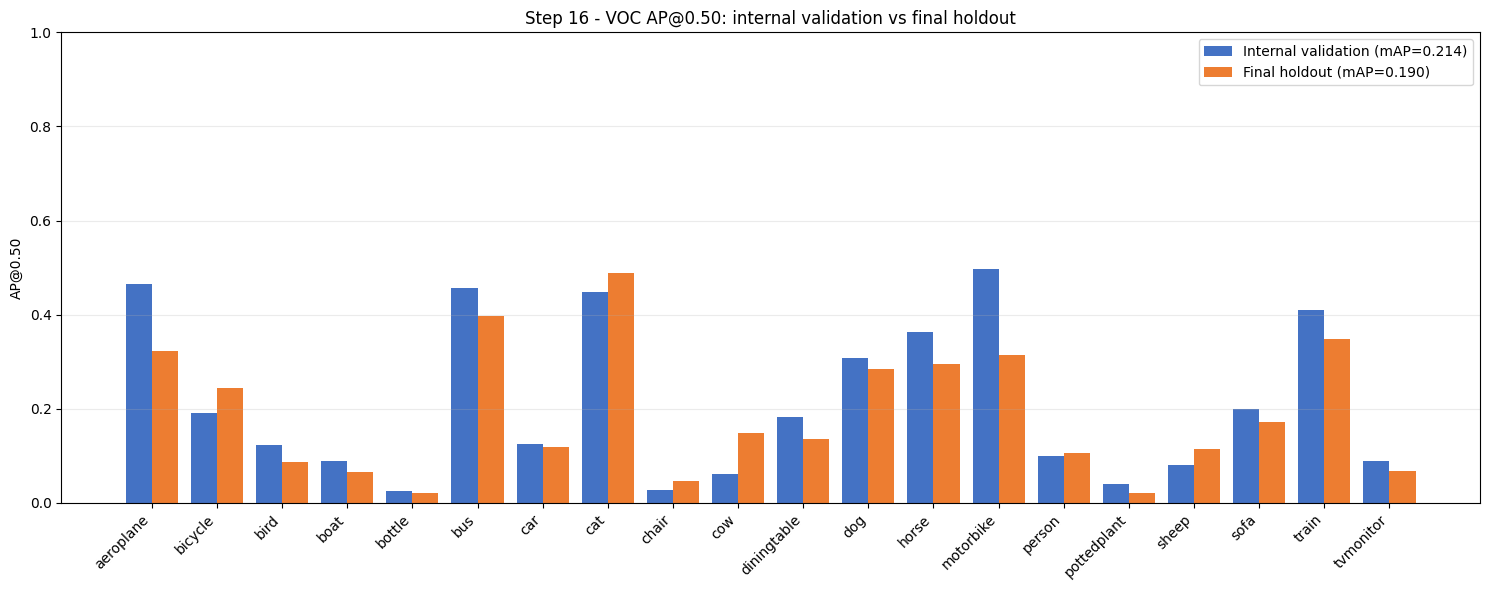

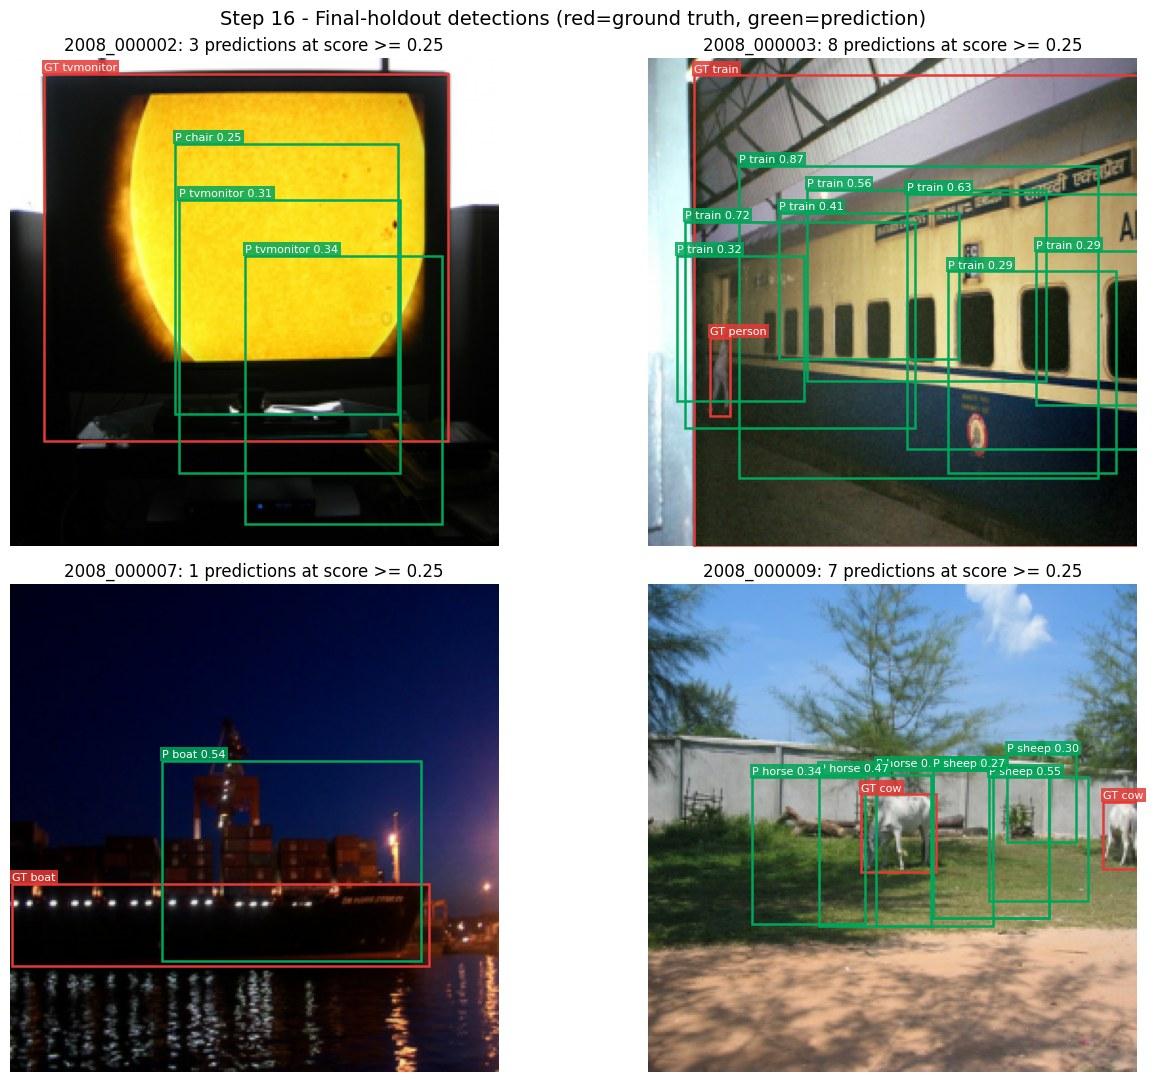


=== Saved Step 16 artifacts ===
Final metrics: /kaggle/working/anndl_outputs/step16_detection_final_holdout_metrics.json
Per-class AP: /kaggle/working/anndl_outputs/step16_detection_final_holdout_ap50.csv
Per-image summary: /kaggle/working/anndl_outputs/step16_detection_final_holdout_image_summary.csv
AP comparison figure: /kaggle/working/anndl_outputs/step16_detection_ap50_comparison.png
Final-holdout examples: /kaggle/working/anndl_outputs/step16_detection_holdout_examples.png

FINAL DETECTION HOLDOUT EVALUATION COMPLETED EXACTLY ONCE.
DETECTOR AND POST-PROCESSING ARE NOW LOCKED; DO NOT TUNE FURTHER.


In [ ]:
#Step 16: evaluate the locked detector on the final VOC holdout exactly once

from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf


# ---------------------------------------------------------------------------
# 1. Validate the locked handoff
# ---------------------------------------------------------------------------
required_objects = (
    "OUTPUT_DIR",
    "VOC_CLASSES",
    "DETECTION_N_CLASSES",
    "DETECTION_BATCH_SIZE",
    "detection_test_ids",
    "detection_records_by_id",
    "det_test_ds",
    "detector_model",
    "BEST_WEIGHTS_PATH",
    "step15_metrics",
    "step15_per_class_ap",
    "AP_IOU_THRESHOLD",
    "NMS_IOU_THRESHOLD",
    "AP_SCORE_FLOOR",
    "VISUAL_SCORE_THRESHOLD",
    "yolo_loss_components",
    "sigmoid_np",
    "decode_and_nms",
    "relative_xywh_to_xyxy",
    "box_iou_one_to_many",
    "all_points_interpolated_ap",
    "draw_relative_box",
)
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run Steps 01--15 first. Missing objects: " + ", ".join(missing_objects)
    )

if not globals().get("STEP15_DETECTION_TRAINING_COMPLETED", False):
    raise RuntimeError("Complete Step 15 before running Step 16.")
if not globals().get("STEP15_DETECTION_MODEL_LOCKED", False):
    raise RuntimeError("The Step 15 detector is not marked as locked.")
if globals().get("STEP16_DETECTION_FINAL_EVALUATION_COMPLETED", False):
    raise RuntimeError("Step 16 already completed in this notebook session.")
if int(globals().get("FINAL_DETECTION_HOLDOUT_PASS_COUNT", 0)) != 0:
    raise RuntimeError(
        "The final detection holdout pass has already started in this session."
    )

OUTPUT_DIR = Path(OUTPUT_DIR)
BEST_WEIGHTS_PATH = Path(BEST_WEIGHTS_PATH)
if not BEST_WEIGHTS_PATH.is_file():
    raise FileNotFoundError(f"Locked Step 15 weights not found: {BEST_WEIGHTS_PATH}")

final_detection_ids = np.asarray(detection_test_ids, dtype=str)
if len(final_detection_ids) == 0:
    raise RuntimeError("The final detection holdout is empty.")
if len(final_detection_ids) != len(set(final_detection_ids.tolist())):
    raise RuntimeError("Duplicate image IDs found in the final detection holdout.")

expected_holdout_batches = math.ceil(
    len(final_detection_ids) / int(DETECTION_BATCH_SIZE)
)
observed_cardinality = int(
    tf.data.experimental.cardinality(det_test_ds).numpy()
)
if observed_cardinality != expected_holdout_batches:
    raise RuntimeError(
        "Final-holdout batch cardinality mismatch: "
        f"{observed_cardinality} vs {expected_holdout_batches}."
    )

locked_internal_map50 = float(step15_metrics["internal_validation_map50"])
locked_best_epoch = int(step15_metrics["best_epoch"])
locked_best_phase = str(step15_metrics["best_phase"])

print("=== Step 16 final object-detection protocol ===")
print("Winner selection source: internal validation only")
print("Selection metric: VOC-style mAP@0.50")
print(f"Locked best epoch: {locked_best_epoch}")
print(f"Locked best phase: {locked_best_phase}")
print(f"Locked internal-validation mAP@0.50: {locked_internal_map50:.5f}")
print(f"Locked checkpoint: {BEST_WEIGHTS_PATH}")
print("Post-processing locked: class-aware NMS at IoU 0.50")
print("Difficult VOC objects: ignored in AP matching")
print(f"Final-holdout images: {len(final_detection_ids):,}")
print(f"Final-holdout batches: {expected_holdout_batches}")
print("Holdout policy: exactly one detector inference pass; no tuning afterward")


# ---------------------------------------------------------------------------
# 2. Build final-holdout ground truth image tensors
# ---------------------------------------------------------------------------
def prepare_final_ground_truth(image_ids):
    ground_truth = {
        class_index: {} for class_index in range(DETECTION_N_CLASSES)
    }
    easy_positive_count = np.zeros(DETECTION_N_CLASSES, dtype=np.int64)
    difficult_count = np.zeros(DETECTION_N_CLASSES, dtype=np.int64)

    for image_id in image_ids:
        image_id = str(image_id)
        per_class_easy = {
            index: [] for index in range(DETECTION_N_CLASSES)
        }
        per_class_difficult = {
            index: [] for index in range(DETECTION_N_CLASSES)
        }
        for obj in detection_records_by_id[image_id]["objects"]:
            class_index = int(obj["class_index"])
            box = relative_xywh_to_xyxy(obj["box_xywh"])
            if obj["difficult"]:
                per_class_difficult[class_index].append(box)
                difficult_count[class_index] += 1
            else:
                per_class_easy[class_index].append(box)
                easy_positive_count[class_index] += 1

        for class_index in range(DETECTION_N_CLASSES):
            ground_truth[class_index][image_id] = {
                "easy": np.asarray(
                    per_class_easy[class_index], dtype=np.float32
                ).reshape(-1, 4),
                "difficult": np.asarray(
                    per_class_difficult[class_index], dtype=np.float32
                ).reshape(-1, 4),
            }

    if np.any(easy_positive_count <= 0):
        raise RuntimeError("Every VOC class needs easy final-holdout objects.")
    return ground_truth, easy_positive_count, difficult_count


final_ground_truth, final_positive_count, final_difficult_count = (
    prepare_final_ground_truth(final_detection_ids)
)


def voc_map50_for_final_holdout(image_ids, detections):
    """Compute continuous VOC AP@0.50, ignoring difficult matches."""
    if len(detections) != len(image_ids):
        raise ValueError("Detection count does not match final-holdout IDs.")

    ap_per_class = np.zeros(DETECTION_N_CLASSES, dtype=np.float32)
    precision_per_class = np.zeros(DETECTION_N_CLASSES, dtype=np.float32)
    recall_per_class = np.zeros(DETECTION_N_CLASSES, dtype=np.float32)

    for class_index in range(DETECTION_N_CLASSES):
        predictions = []
        for image_id, image_detections in zip(image_ids, detections):
            image_id = str(image_id)
            class_mask = image_detections["classes"] == class_index
            for box, score in zip(
                image_detections["boxes"][class_mask],
                image_detections["scores"][class_mask],
            ):
                predictions.append((float(score), image_id, box))
        predictions.sort(key=lambda item: item[0], reverse=True)

        matched_easy = {
            str(image_id): np.zeros(
                len(final_ground_truth[class_index][str(image_id)]["easy"]),
                dtype=bool,
            )
            for image_id in image_ids
        }
        true_positives = []
        false_positives = []

        for _, image_id, predicted_box in predictions:
            gt_entry = final_ground_truth[class_index][image_id]
            easy_boxes = gt_entry["easy"]
            difficult_boxes = gt_entry["difficult"]
            all_boxes = np.concatenate([easy_boxes, difficult_boxes], axis=0)
            overlaps = box_iou_one_to_many(predicted_box, all_boxes)

            if overlaps.size == 0 or float(np.max(overlaps)) < AP_IOU_THRESHOLD:
                true_positives.append(0.0)
                false_positives.append(1.0)
                continue

            best_index = int(np.argmax(overlaps))
            if best_index >= len(easy_boxes):
                continue
            if not matched_easy[image_id][best_index]:
                matched_easy[image_id][best_index] = True
                true_positives.append(1.0)
                false_positives.append(0.0)
            else:
                true_positives.append(0.0)
                false_positives.append(1.0)

        if true_positives:
            cumulative_tp = np.cumsum(true_positives)
            cumulative_fp = np.cumsum(false_positives)
            recall = cumulative_tp / max(final_positive_count[class_index], 1)
            precision = cumulative_tp / np.maximum(
                cumulative_tp + cumulative_fp, 1e-12
            )
            ap_per_class[class_index] = all_points_interpolated_ap(
                recall, precision
            )
            precision_per_class[class_index] = precision[-1]
            recall_per_class[class_index] = recall[-1]

    return {
        "map50": float(np.mean(ap_per_class)),
        "ap_per_class": ap_per_class,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
    }


# Select visualization examples from annotations before seeing predictions.
example_indices = []
for index, image_id in enumerate(final_detection_ids):
    n_easy = sum(
        not obj["difficult"]
        for obj in detection_records_by_id[str(image_id)]["objects"]
    )
    if 1 <= n_easy <= 4:
        example_indices.append(index)
    if len(example_indices) == 4:
        break
if len(example_indices) < 4:
    example_indices = list(range(min(4, len(final_detection_ids))))
example_index_set = set(example_indices)


# ---------------------------------------------------------------------------
# 3. Traverse det_test_ds exactly once and retain all needed results
# ---------------------------------------------------------------------------
FINAL_DETECTION_HOLDOUT_PASS_COUNT = 1

final_detections = []
example_images = {}
loss_component_sums = {
    "loss": 0.0,
    "objectness_loss": 0.0,
    "box_loss": 0.0,
    "class_loss": 0.0,
}
true_positive_objectness = 0
false_positive_objectness = 0
false_negative_objectness = 0
positive_class_correct = 0
positive_class_total = 0
observed_images = 0

regularization_loss = (
    float(tf.add_n(detector_model.losses).numpy())
    if detector_model.losses
    else 0.0
)

for batch_index, (images, targets) in enumerate(det_test_ds, start=1):
    batch_start = observed_images
    batch_size = int(tf.shape(images)[0].numpy())
    batch_stop = batch_start + batch_size

    raw_predictions_tensor = detector_model(images, training=False)
    batch_losses = yolo_loss_components(targets, raw_predictions_tensor)
    batch_loss_values = {
        "loss": float(batch_losses[0].numpy()) + regularization_loss,
        "objectness_loss": float(batch_losses[1].numpy()),
        "box_loss": float(batch_losses[2].numpy()),
        "class_loss": float(batch_losses[3].numpy()),
    }
    for name, value in batch_loss_values.items():
        loss_component_sums[name] += value * batch_size

    raw_predictions = raw_predictions_tensor.numpy().astype(np.float32)
    target_values = targets.numpy().astype(np.float32)
    final_detections.extend(decode_and_nms(raw_predictions))

    valid_mask = target_values[..., 25] == 1.0
    object_true = target_values[..., 0] == 1.0
    object_predicted = sigmoid_np(raw_predictions[..., 0]) >= 0.50
    true_positive_objectness += int(
        np.sum(valid_mask & object_true & object_predicted)
    )
    false_positive_objectness += int(
        np.sum(valid_mask & (~object_true) & object_predicted)
    )
    false_negative_objectness += int(
        np.sum(valid_mask & object_true & (~object_predicted))
    )

    positive_mask = valid_mask & object_true
    predicted_classes = np.argmax(raw_predictions[..., 5:25], axis=-1)
    true_classes = np.argmax(target_values[..., 5:25], axis=-1)
    positive_class_correct += int(
        np.sum(predicted_classes[positive_mask] == true_classes[positive_mask])
    )
    positive_class_total += int(np.sum(positive_mask))

    for global_index in example_index_set:
        if batch_start <= global_index < batch_stop:
            example_images[global_index] = images[
                global_index - batch_start
            ].numpy()

    observed_images = batch_stop
    if batch_index % 50 == 0 or batch_index == expected_holdout_batches:
        print(
            f"Final holdout inference: batch {batch_index}/"
            f"{expected_holdout_batches}, images {observed_images:,}/"
            f"{len(final_detection_ids):,}"
        )

if observed_images != len(final_detection_ids):
    raise RuntimeError(
        f"Final-holdout image count mismatch: {observed_images} vs "
        f"{len(final_detection_ids)}."
    )
if len(final_detections) != len(final_detection_ids):
    raise RuntimeError("Final detection output cardinality mismatch.")
if set(example_images) != example_index_set:
    raise RuntimeError("Failed to retain all preselected visualization images.")


# ---------------------------------------------------------------------------
# 4. Calculate final metrics from the retained one-pass outputs
# ---------------------------------------------------------------------------
final_map_evaluation = voc_map50_for_final_holdout(
    final_detection_ids, final_detections
)
final_map50 = float(final_map_evaluation["map50"])

final_losses = {
    name: float(value / observed_images)
    for name, value in loss_component_sums.items()
}
objectness_precision = true_positive_objectness / max(
    true_positive_objectness + false_positive_objectness, 1
)
objectness_recall = true_positive_objectness / max(
    true_positive_objectness + false_negative_objectness, 1
)
positive_class_accuracy = positive_class_correct / max(
    positive_class_total, 1
)

step16_metrics = {
    "selected_model": "voc2012_improved_yolo",
    "selected_checkpoint": str(BEST_WEIGHTS_PATH),
    "best_epoch": locked_best_epoch,
    "best_phase": locked_best_phase,
    "internal_validation_map50": locked_internal_map50,
    "final_holdout_map50": final_map50,
    "validation_to_holdout_map50_change": (
        final_map50 - locked_internal_map50
    ),
    "final_holdout_loss": final_losses["loss"],
    "final_holdout_objectness_loss": final_losses["objectness_loss"],
    "final_holdout_box_loss": final_losses["box_loss"],
    "final_holdout_class_loss": final_losses["class_loss"],
    "slot_objectness_precision_at_0_50": float(objectness_precision),
    "slot_objectness_recall_at_0_50": float(objectness_recall),
    "positive_slot_class_accuracy": float(positive_class_accuracy),
    "final_holdout_images": int(observed_images),
    "final_holdout_easy_ground_truth_boxes": int(final_positive_count.sum()),
    "final_holdout_difficult_ground_truth_boxes": int(
        final_difficult_count.sum()
    ),
    "ap_iou_threshold": float(AP_IOU_THRESHOLD),
    "nms_iou_threshold": float(NMS_IOU_THRESHOLD),
    "ap_score_floor": float(AP_SCORE_FLOOR),
    "visual_score_threshold": float(VISUAL_SCORE_THRESHOLD),
    "holdout_inference_passes": int(FINAL_DETECTION_HOLDOUT_PASS_COUNT),
}

validation_ap_by_class = (
    step15_per_class_ap.set_index("class")
    .loc[list(VOC_CLASSES), "ap50"]
    .to_numpy(dtype=np.float32)
)
step16_per_class_ap = pd.DataFrame(
    {
        "class": VOC_CLASSES,
        "internal_validation_ap50": validation_ap_by_class,
        "final_holdout_easy_ground_truth_boxes": final_positive_count,
        "final_holdout_difficult_ground_truth_boxes": final_difficult_count,
        "final_holdout_ap50": final_map_evaluation["ap_per_class"],
        "ap50_change": (
            final_map_evaluation["ap_per_class"] - validation_ap_by_class
        ),
        "terminal_precision": final_map_evaluation["precision_per_class"],
        "terminal_recall": final_map_evaluation["recall_per_class"],
    }
)

print("\n=== Final detection holdout metrics ===")
print(f"Weighted multi-task loss: {final_losses['loss']:.5f}")
print(f"Objectness loss: {final_losses['objectness_loss']:.5f}")
print(f"Box loss: {final_losses['box_loss']:.5f}")
print(f"Class loss: {final_losses['class_loss']:.5f}")
print(f"VOC-style mAP@0.50: {final_map50:.5f}")
print(f"Slot objectness precision@0.50: {objectness_precision:.5f}")
print(f"Slot objectness recall@0.50: {objectness_recall:.5f}")
print(f"Positive-slot class accuracy: {positive_class_accuracy:.5f}")
print(
    "Validation-to-holdout mAP@0.50 change: "
    f"{final_map50 - locked_internal_map50:+.5f}"
)

print("\n=== Final-holdout AP@0.50 by VOC class ===")
print(
    step16_per_class_ap.to_string(
        index=False,
        formatters={
            "internal_validation_ap50": lambda value: f"{value:.5f}",
            "final_holdout_ap50": lambda value: f"{value:.5f}",
            "ap50_change": lambda value: f"{value:+.5f}",
            "terminal_precision": lambda value: f"{value:.5f}",
            "terminal_recall": lambda value: f"{value:.5f}",
        },
    )
)


# ---------------------------------------------------------------------------
# 5. Save bounded artifacts and figures model pass
# ---------------------------------------------------------------------------
metrics_path = OUTPUT_DIR / "step16_detection_final_holdout_metrics.json"
per_class_ap_path = OUTPUT_DIR / "step16_detection_final_holdout_ap50.csv"
image_summary_path = OUTPUT_DIR / "step16_detection_final_holdout_image_summary.csv"
comparison_figure_path = OUTPUT_DIR / "step16_detection_ap50_comparison.png"
examples_figure_path = OUTPUT_DIR / "step16_detection_holdout_examples.png"

step16_image_summary = pd.DataFrame(
    {
        "image_id": final_detection_ids,
        "easy_ground_truth_boxes": [
            sum(
                not obj["difficult"]
                for obj in detection_records_by_id[str(image_id)]["objects"]
            )
            for image_id in final_detection_ids
        ],
        "difficult_ground_truth_boxes": [
            sum(
                obj["difficult"]
                for obj in detection_records_by_id[str(image_id)]["objects"]
            )
            for image_id in final_detection_ids
        ],
        "nms_detections_at_ap_floor": [
            len(detections["scores"]) for detections in final_detections
        ],
        "visual_detections_at_score_threshold": [
            int(np.sum(detections["scores"] >= VISUAL_SCORE_THRESHOLD))
            for detections in final_detections
        ],
    }
)

with metrics_path.open("w") as metrics_file:
    json.dump(step16_metrics, metrics_file, indent=2)
step16_per_class_ap.to_csv(per_class_ap_path, index=False)
step16_image_summary.to_csv(image_summary_path, index=False)

class_positions = np.arange(DETECTION_N_CLASSES)
bar_width = 0.40
fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(
    class_positions - bar_width / 2,
    step16_per_class_ap["internal_validation_ap50"],
    width=bar_width,
    label=f"Internal validation (mAP={locked_internal_map50:.3f})",
    color="#4472C4",
)
ax.bar(
    class_positions + bar_width / 2,
    step16_per_class_ap["final_holdout_ap50"],
    width=bar_width,
    label=f"Final holdout (mAP={final_map50:.3f})",
    color="#ED7D31",
)
ax.set_title("Step 16 - VOC AP@0.50: internal validation vs final holdout")
ax.set_ylabel("AP@0.50")
ax.set_ylim(0.0, 1.0)
ax.set_xticks(class_positions)
ax.set_xticklabels(VOC_CLASSES, rotation=45, ha="right")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(comparison_figure_path, dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, example_index in zip(axes.flat, example_indices):
    image_id = str(final_detection_ids[example_index])
    image = example_images[example_index]
    image_height, image_width = image.shape[:2]
    ax.imshow(image)

    for obj in detection_records_by_id[image_id]["objects"]:
        if obj["difficult"]:
            continue
        draw_relative_box(
            ax,
            relative_xywh_to_xyxy(obj["box_xywh"]),
            image_width,
            image_height,
            "#E53935",
            f"GT {obj['label']}",
        )

    detections = final_detections[example_index]
    visible = np.where(
        detections["scores"] >= VISUAL_SCORE_THRESHOLD
    )[0][:8]
    for prediction_index in visible:
        class_index = int(detections["classes"][prediction_index])
        score = float(detections["scores"][prediction_index])
        draw_relative_box(
            ax,
            detections["boxes"][prediction_index],
            image_width,
            image_height,
            "#00A65A",
            f"P {VOC_CLASSES[class_index]} {score:.2f}",
        )

    ax.set_title(
        f"{image_id}: {len(visible)} predictions at score >= "
        f"{VISUAL_SCORE_THRESHOLD:.2f}"
    )
    ax.set_axis_off()

fig.suptitle(
    "Step 16 - Final-holdout detections (red=ground truth, green=prediction)",
    fontsize=14,
)
fig.tight_layout()
fig.savefig(examples_figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("\n=== Saved Step 16 artifacts ===")
print(f"Final metrics: {metrics_path}")
print(f"Per-class AP: {per_class_ap_path}")
print(f"Per-image summary: {image_summary_path}")
print(f"AP comparison figure: {comparison_figure_path}")
print(f"Final-holdout examples: {examples_figure_path}")

STEP16_DETECTION_FINAL_EVALUATION_COMPLETED = True
STEP16_DETECTION_MODEL_AND_POSTPROCESSING_LOCKED = True

print("\nFINAL DETECTION HOLDOUT EVALUATION COMPLETED EXACTLY ONCE.")
print("DETECTOR AND POST-PROCESSING ARE NOW LOCKED; DO NOT TUNE FURTHER.")


### Final object-detection interpretation

The detector improves the basic YOLO-style formulation with an ImageNet-pretrained Xception backbone, two prediction slots per 8×8 grid cell, class-aware non-maximum suppression, and VOC difficult-object handling. Model selection used internal-validation mAP@0.50. The best checkpoint occurred at frozen-backbone epoch 4 (mAP@0.50 = 0.21395); last-block fine-tuning did not surpass it and was therefore rejected.

The one-time 5,823-image holdout evaluation produced VOC mAP@0.50 = 0.19000, a decrease of 0.02395 from internal validation. Cat, bus, train, aeroplane, and motorbike were among the stronger classes, while bottle, potted plant, and chair remained difficult. Slot objectness recall (0.59776) exceeded precision (0.16975), indicating many false-positive proposals after the fixed post-processing rule. Detection is the weakest of the three tasks because it must jointly learn object presence, class, and localisation from a compact grid; these limitations are reported rather than tuning on the final holdout.


## Overall conclusion

Transfer learning with the locked frozen-Xception classifier produced the strongest classification result, while the U-Net materially improved foreground segmentation over the baseline encoder-decoder. The improved YOLO-style detector completed the required localisation task with VOC-compatible evaluation, although its lower mAP and false-positive burden make detection the clearest area for future improvement. Across all three tasks, model selection was confined to training and internal-validation data, and each official holdout was used only after the corresponding model and decision rule had been fixed.
